In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("SPECTRA-X Prototype")
print("Environment ready!")

SPECTRA-X Prototype
Environment ready!


In [2]:
# ==============================
# SPECTRA-X RF CONFIGURATION
# ==============================

TOTAL_BANDWIDTH_MHZ = 500

RECEIVER_BANDWIDTH_MHZ = 50

NUM_BANDS = 50

TIME_SLOTS = 1000

TIME_STEP_MS = 10

print("RF Environment Configuration")
print("----------------------------")
print(f"Total bandwidth       : {TOTAL_BANDWIDTH_MHZ} MHz")
print(f"Receiver bandwidth    : {RECEIVER_BANDWIDTH_MHZ} MHz")
print(f"Frequency bands       : {NUM_BANDS}")
print(f"Time slots            : {TIME_SLOTS}")
print(f"Time resolution       : {TIME_STEP_MS} ms")

RF Environment Configuration
----------------------------
Total bandwidth       : 500 MHz
Receiver bandwidth    : 50 MHz
Frequency bands       : 50
Time slots            : 1000
Time resolution       : 10 ms


In [3]:
# Frequency band edges

band_width = TOTAL_BANDWIDTH_MHZ / NUM_BANDS

frequencies = np.arange(
    0,
    TOTAL_BANDWIDTH_MHZ,
    band_width
)

print("Frequency bands:")
print("----------------")

for i, freq in enumerate(frequencies):
    print(
        f"Band {i+1:02d}: "
        f"{freq:.0f} - "
        f"{freq + band_width:.0f} MHz"
    )

Frequency bands:
----------------
Band 01: 0 - 10 MHz
Band 02: 10 - 20 MHz
Band 03: 20 - 30 MHz
Band 04: 30 - 40 MHz
Band 05: 40 - 50 MHz
Band 06: 50 - 60 MHz
Band 07: 60 - 70 MHz
Band 08: 70 - 80 MHz
Band 09: 80 - 90 MHz
Band 10: 90 - 100 MHz
Band 11: 100 - 110 MHz
Band 12: 110 - 120 MHz
Band 13: 120 - 130 MHz
Band 14: 130 - 140 MHz
Band 15: 140 - 150 MHz
Band 16: 150 - 160 MHz
Band 17: 160 - 170 MHz
Band 18: 170 - 180 MHz
Band 19: 180 - 190 MHz
Band 20: 190 - 200 MHz
Band 21: 200 - 210 MHz
Band 22: 210 - 220 MHz
Band 23: 220 - 230 MHz
Band 24: 230 - 240 MHz
Band 25: 240 - 250 MHz
Band 26: 250 - 260 MHz
Band 27: 260 - 270 MHz
Band 28: 270 - 280 MHz
Band 29: 280 - 290 MHz
Band 30: 290 - 300 MHz
Band 31: 300 - 310 MHz
Band 32: 310 - 320 MHz
Band 33: 320 - 330 MHz
Band 34: 330 - 340 MHz
Band 35: 340 - 350 MHz
Band 36: 350 - 360 MHz
Band 37: 360 - 370 MHz
Band 38: 370 - 380 MHz
Band 39: 380 - 390 MHz
Band 40: 390 - 400 MHz
Band 41: 400 - 410 MHz
Band 42: 410 - 420 MHz
Band 43: 420 - 430 M

In [4]:
# ==============================
# BASIC RF ACTIVITY MATRIX
# ==============================

np.random.seed(42)

rf_activity = np.random.choice(
    [0, 1],
    size=(TIME_SLOTS, NUM_BANDS),
    p=[0.8, 0.2]
)

print("RF activity matrix created.")
print(f"Shape: {rf_activity.shape}")

print("\nMeaning:")
print("0 = No transmission")
print("1 = Transmission")

RF activity matrix created.
Shape: (1000, 50)

Meaning:
0 = No transmission
1 = Transmission


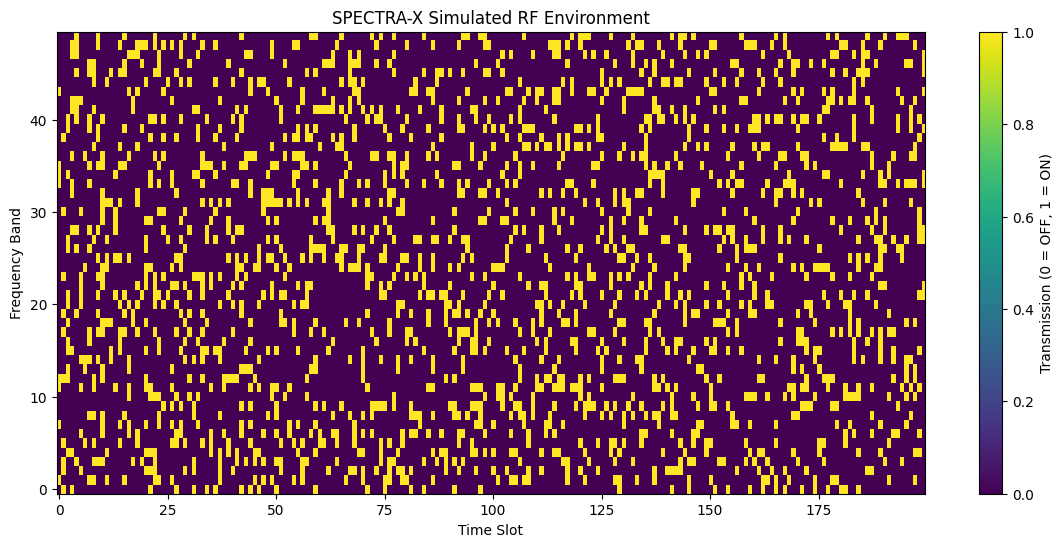

In [5]:
plt.figure(figsize=(14, 6))

plt.imshow(
    rf_activity[:200].T,
    aspect="auto",
    interpolation="nearest",
    origin="lower"
)

plt.xlabel("Time Slot")
plt.ylabel("Frequency Band")

plt.title("SPECTRA-X Simulated RF Environment")

plt.colorbar(
    label="Transmission (0 = OFF, 1 = ON)"
)

plt.show()

In [6]:
# ==========================================
# STEP 2 — SIMULATED RF EMITTERS
# ==========================================

EMITTERS = [
    {
        "id": "E1",
        "type": "periodic",
        "base_band": 8,
        "period": 50,
        "duration": 10
    },
    {
        "id": "E2",
        "type": "intermittent",
        "base_band": 22,
        "probability": 0.15
    },
    {
        "id": "E3",
        "type": "frequency_agile",
        "base_band": 35,
        "hop_interval": 40,
        "hop_range": 10
    },
    {
        "id": "E4",
        "type": "short_duration",
        "base_band": 45,
        "probability": 0.08
    }
]

print("Simulated Emitters")
print("------------------")

for emitter in EMITTERS:
    print(
        emitter["id"],
        "→",
        emitter["type"]
    )

Simulated Emitters
------------------
E1 → periodic
E2 → intermittent
E3 → frequency_agile
E4 → short_duration


In [7]:
# ==========================================
# GENERATE REALISTIC RF ENVIRONMENT
# ==========================================

np.random.seed(42)

rf_activity = np.zeros(
    (TIME_SLOTS, NUM_BANDS),
    dtype=int
)

emitter_history = []

for time in range(TIME_SLOTS):

    for emitter in EMITTERS:

        band = emitter["base_band"]
        active = False

        # -------------------------
        # PERIODIC EMITTER
        # -------------------------
        if emitter["type"] == "periodic":

            position = time % emitter["period"]

            active = position < emitter["duration"]

        # -------------------------
        # INTERMITTENT EMITTER
        # -------------------------
        elif emitter["type"] == "intermittent":

            active = (
                np.random.random()
                < emitter["probability"]
            )

        # -------------------------
        # FREQUENCY AGILE EMITTER
        # -------------------------
        elif emitter["type"] == "frequency_agile":

            hop_number = (
                time // emitter["hop_interval"]
            )

            offset = (
                hop_number %
                (2 * emitter["hop_range"] + 1)
            ) - emitter["hop_range"]

            band = emitter["base_band"] + offset

            band = max(
                0,
                min(NUM_BANDS - 1, band)
            )

            active = True

        # -------------------------
        # SHORT DURATION EMITTER
        # -------------------------
        elif emitter["type"] == "short_duration":

            active = (
                np.random.random()
                < emitter["probability"]
            )

        if active:

            rf_activity[
                time,
                band
            ] = 1

            emitter_history.append({
                "time": time,
                "emitter": emitter["id"],
                "band": band,
                "active": 1
            })

print("Realistic RF environment generated.")

print(
    f"Environment shape: "
    f"{rf_activity.shape}"
)

print(
    f"Transmission events: "
    f"{len(emitter_history)}"
)

Realistic RF environment generated.
Environment shape: (1000, 50)
Transmission events: 1452


In [8]:
# ==========================================
# EMITTER HISTORY
# ==========================================

emitter_df = pd.DataFrame(
    emitter_history
)

print(emitter_df.head(20))

    time emitter  band  active
0      0      E1     8       1
1      0      E3    25       1
2      1      E1     8       1
3      1      E3    25       1
4      2      E1     8       1
5      2      E3    25       1
6      3      E1     8       1
7      3      E2    22       1
8      3      E3    25       1
9      4      E1     8       1
10     4      E3    25       1
11     5      E1     8       1
12     5      E2    22       1
13     5      E3    25       1
14     6      E1     8       1
15     6      E3    25       1
16     7      E1     8       1
17     7      E3    25       1
18     8      E1     8       1
19     8      E3    25       1


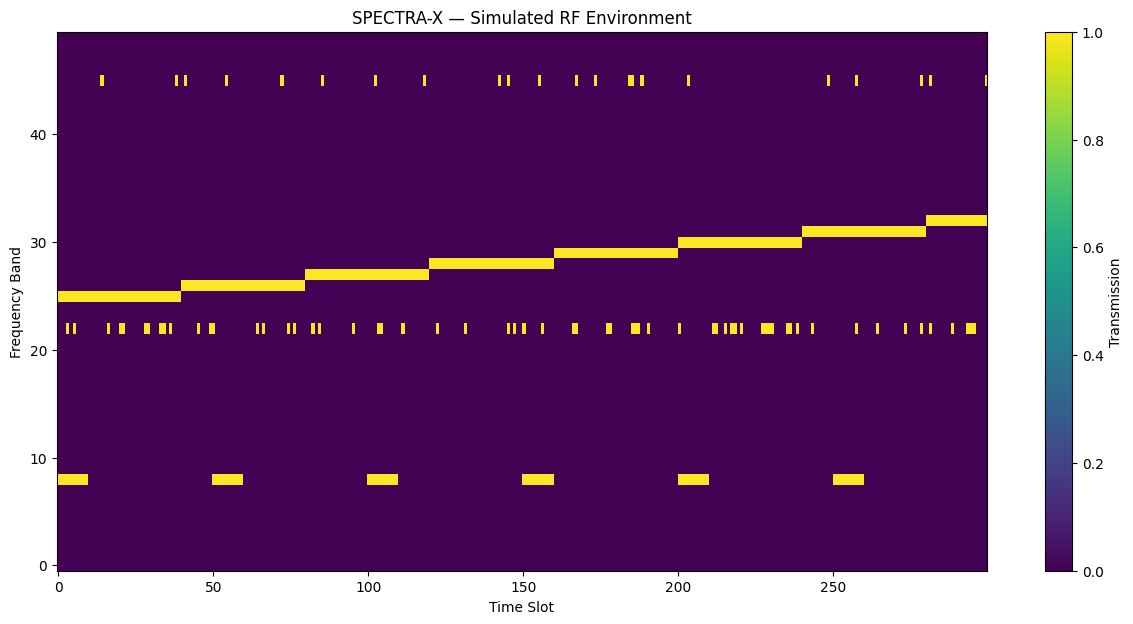

In [9]:
# ==========================================
# VISUALIZE REALISTIC RF ENVIRONMENT
# ==========================================

plt.figure(figsize=(15, 7))

plt.imshow(
    rf_activity[:300].T,
    aspect="auto",
    interpolation="nearest",
    origin="lower"
)

plt.xlabel("Time Slot")
plt.ylabel("Frequency Band")

plt.title(
    "SPECTRA-X — Simulated RF Environment"
)

plt.colorbar(
    label="Transmission"
)

plt.show()

In [10]:
# ==========================================
# STEP 3 — RECEIVER CONFIGURATION
# ==========================================

TOTAL_BANDWIDTH_MHZ = 500
RECEIVER_BANDWIDTH_MHZ = 50
SCAN_TIME_MS = 10

NUM_SCAN_WINDOWS = int(
    TOTAL_BANDWIDTH_MHZ / RECEIVER_BANDWIDTH_MHZ
)

print("SPECTRA-X RECEIVER")
print("------------------")
print(f"Total spectrum       : {TOTAL_BANDWIDTH_MHZ} MHz")
print(f"Receiver bandwidth   : {RECEIVER_BANDWIDTH_MHZ} MHz")
print(f"Scan time/window     : {SCAN_TIME_MS} ms")
print(f"Number of windows    : {NUM_SCAN_WINDOWS}")

print("\nScan Windows:")

for i in range(NUM_SCAN_WINDOWS):
    start = i * RECEIVER_BANDWIDTH_MHZ
    end = start + RECEIVER_BANDWIDTH_MHZ

    print(
        f"Window {i+1:02d}: "
        f"{start:.0f} - {end:.0f} MHz"
    )

SPECTRA-X RECEIVER
------------------
Total spectrum       : 500 MHz
Receiver bandwidth   : 50 MHz
Scan time/window     : 10 ms
Number of windows    : 10

Scan Windows:
Window 01: 0 - 50 MHz
Window 02: 50 - 100 MHz
Window 03: 100 - 150 MHz
Window 04: 150 - 200 MHz
Window 05: 200 - 250 MHz
Window 06: 250 - 300 MHz
Window 07: 300 - 350 MHz
Window 08: 350 - 400 MHz
Window 09: 400 - 450 MHz
Window 10: 450 - 500 MHz


In [11]:
# ==========================================
# MAP RECEIVER WINDOWS TO FREQUENCY BANDS
# ==========================================

BAND_WIDTH_MHZ = TOTAL_BANDWIDTH_MHZ / NUM_BANDS

scan_windows = []

for window_id in range(NUM_SCAN_WINDOWS):

    start_frequency = (
        window_id * RECEIVER_BANDWIDTH_MHZ
    )

    end_frequency = (
        start_frequency + RECEIVER_BANDWIDTH_MHZ
    )

    start_band = int(
        start_frequency / BAND_WIDTH_MHZ
    )

    end_band = int(
        end_frequency / BAND_WIDTH_MHZ
    )

    scan_windows.append({
        "window": window_id + 1,
        "start_frequency": start_frequency,
        "end_frequency": end_frequency,
        "start_band": start_band,
        "end_band": end_band
    })

print("Receiver Window Mapping")
print("-----------------------")

for window in scan_windows:

    print(
        f"Window {window['window']:02d}: "
        f"{window['start_frequency']:.0f}-"
        f"{window['end_frequency']:.0f} MHz "
        f"→ Bands "
        f"{window['start_band']}-"
        f"{window['end_band']-1}"
    )

Receiver Window Mapping
-----------------------
Window 01: 0-50 MHz → Bands 0-4
Window 02: 50-100 MHz → Bands 5-9
Window 03: 100-150 MHz → Bands 10-14
Window 04: 150-200 MHz → Bands 15-19
Window 05: 200-250 MHz → Bands 20-24
Window 06: 250-300 MHz → Bands 25-29
Window 07: 300-350 MHz → Bands 30-34
Window 08: 350-400 MHz → Bands 35-39
Window 09: 400-450 MHz → Bands 40-44
Window 10: 450-500 MHz → Bands 45-49


In [12]:
# ==========================================
# STEP 4 — CONVENTIONAL OPEN-LOOP SCANNER
# ==========================================

def conventional_scan(
    rf_activity,
    scan_windows,
    max_time_slots=300
):
    
    scan_history = []

    detected = False
    detection_time = None
    detection_window = None

    for time_slot in range(max_time_slots):

        # Conventional scanner moves sequentially
        window_index = (
            time_slot % len(scan_windows)
        )

        window = scan_windows[window_index]

        start_band = window["start_band"]
        end_band = window["end_band"]

        # Observe the current receiver window
        observed_bands = rf_activity[
            time_slot,
            start_band:end_band
        ]

        hit = int(
            np.any(observed_bands == 1)
        )

        scan_history.append({
            "time_slot": time_slot,
            "window": window["window"],
            "start_frequency": window[
                "start_frequency"
            ],
            "end_frequency": window[
                "end_frequency"
            ],
            "hit": hit
        })

        # First successful detection
        if hit == 1:

            detected = True
            detection_time = (
                (time_slot + 1) * SCAN_TIME_MS
            )

            detection_window = window["window"]

            break

    return (
        pd.DataFrame(scan_history),
        detected,
        detection_time,
        detection_window
    )

In [13]:
# ==========================================
# RUN CONVENTIONAL SCANNER
# ==========================================

results, detected, detection_time, detection_window = (
    conventional_scan(
        rf_activity,
        scan_windows,
        max_time_slots=300
    )
)

print("CONVENTIONAL SCANNER RESULT")
print("----------------------------")

print(
    f"Signal detected : {detected}"
)

print(
    f"Detection time  : {detection_time} ms"
)

print(
    f"Detection window: {detection_window}"
)

print(
    f"Scans performed : {len(results)}"
)

print("\nScan history:")
display(results.head(15))

CONVENTIONAL SCANNER RESULT
----------------------------
Signal detected : True
Detection time  : 20 ms
Detection window: 2
Scans performed : 2

Scan history:


,time_slot,window,start_frequency,end_frequency,hit
0,0,1,0,50,0
1,1,2,50,100,1


In [14]:
# ==========================================
# STEP 4 — BUILD ML TRAINING DATA
# ==========================================

def create_training_data(rf_activity, lookback=10):
    
    records = []

    num_times, num_bands = rf_activity.shape

    for band in range(num_bands):

        for time in range(lookback, num_times):

            history = rf_activity[
                time - lookback:time,
                band
            ]

            records.append({
                "time_slot": time,
                "band": band,

                # Recent activity
                "activity_count": np.sum(history),

                # Activity ratio
                "activity_rate": np.mean(history),

                # Most recent observation
                "last_observation": history[-1],

                # Activity in last 3 slots
                "recent_3_rate": np.mean(
                    history[-3:]
                ),

                # Activity in last 5 slots
                "recent_5_rate": np.mean(
                    history[-5:]
                ),

                # Target: will this band transmit now?
                "target": rf_activity[
                    time,
                    band
                ]
            })

    return pd.DataFrame(records)


training_data = create_training_data(
    rf_activity,
    lookback=10
)

print("Training dataset created.")
print("--------------------------")
print("Rows:", len(training_data))
print("Columns:", len(training_data.columns))

display(training_data.head(10))

Training dataset created.
--------------------------
Rows: 49500
Columns: 8


,time_slot,band,activity_count,activity_rate,last_observation,recent_3_rate,recent_5_rate,target
0,10,0,0,0.0,0,0.0,0.0,0
1,11,0,0,0.0,0,0.0,0.0,0
2,12,0,0,0.0,0,0.0,0.0,0
3,13,0,0,0.0,0,0.0,0.0,0
4,14,0,0,0.0,0,0.0,0.0,0
5,15,0,0,0.0,0,0.0,0.0,0
6,16,0,0,0.0,0,0.0,0.0,0
7,17,0,0,0.0,0,0.0,0.0,0
8,18,0,0,0.0,0,0.0,0.0,0
9,19,0,0,0.0,0,0.0,0.0,0


In [15]:
# ==========================================
# STEP 5 — ADVANCED RF FEATURES
# ==========================================

def create_advanced_features(rf_activity, lookback=10):

    records = []

    num_times, num_bands = rf_activity.shape

    for band in range(num_bands):

        # Number of slots since this band was last active
        time_since_hit = lookback

        for time in range(lookback, num_times):

            history = rf_activity[
                time - lookback:time,
                band
            ]

            # -----------------------------
            # Basic temporal features
            # -----------------------------

            activity_count = np.sum(history)

            activity_rate = np.mean(history)

            last_observation = history[-1]

            recent_3_rate = np.mean(history[-3:])

            recent_5_rate = np.mean(history[-5:])

            # -----------------------------
            # Time since last activity
            # -----------------------------

            if last_observation == 1:
                time_since_hit = 0
            else:
                time_since_hit += 1

            # Keep value bounded
            time_since_hit = min(
                time_since_hit,
                lookback
            )

            # -----------------------------
            # Activity trend
            # -----------------------------

            first_half = np.mean(history[:5])

            second_half = np.mean(history[5:])

            activity_trend = (
                second_half - first_half
            )

            # -----------------------------
            # Periodicity estimate
            # -----------------------------

            periodicity_score = 0

            if activity_count >= 2:

                hit_positions = np.where(
                    history == 1
                )[0]

                intervals = np.diff(
                    hit_positions
                )

                if len(intervals) > 0:

                    mean_interval = np.mean(
                        intervals
                    )

                    interval_std = np.std(
                        intervals
                    )

                    if mean_interval > 0:

                        periodicity_score = (
                            1 /
                            (1 + interval_std)
                        )

            # -----------------------------
            # Neighbor-band activity
            # -----------------------------

            lower_band = max(0, band - 1)

            upper_band = min(
                num_bands,
                band + 2
            )

            neighbor_activity = np.mean(
                rf_activity[
                    time - lookback:time,
                    lower_band:upper_band
                ]
            )

            # -----------------------------
            # Frequency movement
            # -----------------------------

            current_active_bands = np.where(
                rf_activity[time - 1] == 1
            )[0]

            frequency_movement = 0

            if len(current_active_bands) > 0:

                distances = np.abs(
                    current_active_bands - band
                )

                frequency_movement = np.min(
                    distances
                )

            # -----------------------------
            # Target
            # -----------------------------

            target = rf_activity[
                time,
                band
            ]

            records.append({

                "time_slot": time,

                "band": band,

                "activity_count": activity_count,

                "activity_rate": activity_rate,

                "last_observation": last_observation,

                "recent_3_rate": recent_3_rate,

                "recent_5_rate": recent_5_rate,

                "time_since_hit": time_since_hit,

                "activity_trend": activity_trend,

                "periodicity_score": periodicity_score,

                "neighbor_activity": neighbor_activity,

                "frequency_movement": frequency_movement,

                "target": target
            })

    return pd.DataFrame(records)


advanced_data = create_advanced_features(
    rf_activity,
    lookback=10
)

print("Advanced dataset created.")
print("-------------------------")
print("Rows    :", len(advanced_data))
print("Columns :", len(advanced_data.columns))

display(advanced_data.head(10))

Advanced dataset created.
-------------------------
Rows    : 49500
Columns : 13


,time_slot,band,activity_count,activity_rate,last_observation,recent_3_rate,recent_5_rate,time_since_hit,activity_trend,periodicity_score,neighbor_activity,frequency_movement,target
0,10,0,0,0.0,0,0.0,0.0,10,0.0,0.0,0.0,8,0
1,11,0,0,0.0,0,0.0,0.0,10,0.0,0.0,0.0,25,0
2,12,0,0,0.0,0,0.0,0.0,10,0.0,0.0,0.0,25,0
3,13,0,0,0.0,0,0.0,0.0,10,0.0,0.0,0.0,25,0
4,14,0,0,0.0,0,0.0,0.0,10,0.0,0.0,0.0,25,0
5,15,0,0,0.0,0,0.0,0.0,10,0.0,0.0,0.0,25,0
6,16,0,0,0.0,0,0.0,0.0,10,0.0,0.0,0.0,25,0
7,17,0,0,0.0,0,0.0,0.0,10,0.0,0.0,0.0,22,0
8,18,0,0,0.0,0,0.0,0.0,10,0.0,0.0,0.0,25,0
9,19,0,0,0.0,0,0.0,0.0,10,0.0,0.0,0.0,25,0


In [16]:
# ==========================================
# STEP 5B — TARGET BALANCE CHECK
# ==========================================

target_counts = advanced_data["target"].value_counts().sort_index()

total = len(advanced_data)

no_transmission = target_counts.get(0, 0)
transmission = target_counts.get(1, 0)

print("TARGET BALANCE")
print("==============")

print(f"No transmission (0): {no_transmission:,}")
print(f"Transmission (1)   : {transmission:,}")

print("\nPercentages")
print("-----------")

print(
    f"No transmission : "
    f"{(no_transmission / total) * 100:.2f}%"
)

print(
    f"Transmission    : "
    f"{(transmission / total) * 100:.2f}%"
)

TARGET BALANCE
No transmission (0): 48,071
Transmission (1)   : 1,429

Percentages
-----------
No transmission : 97.11%
Transmission    : 2.89%


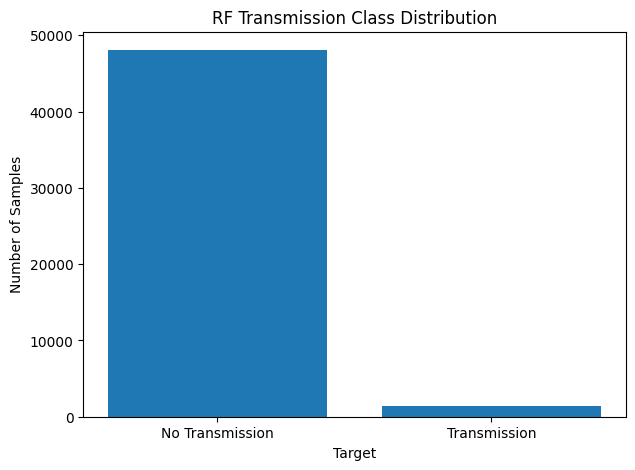

In [17]:
# ==========================================
# TARGET DISTRIBUTION
# ==========================================

plt.figure(figsize=(7, 5))

plt.bar(
    ["No Transmission", "Transmission"],
    [no_transmission, transmission]
)

plt.xlabel("Target")
plt.ylabel("Number of Samples")
plt.title("RF Transmission Class Distribution")

plt.show()

In [18]:
# ==========================================
# STEP 6 — CHRONOLOGICAL DATA SPLIT
# ==========================================

# Sort by time
advanced_data = advanced_data.sort_values(
    ["time_slot", "band"]
).reset_index(drop=True)

# Get unique time slots
time_slots = sorted(
    advanced_data["time_slot"].unique()
)

n_times = len(time_slots)

# 70% train, 15% validation, 15% test
train_end = int(n_times * 0.70)
validation_end = int(n_times * 0.85)

train_times = time_slots[:train_end]
validation_times = time_slots[
    train_end:validation_end
]
test_times = time_slots[
    validation_end:
]

# Create datasets
train_data = advanced_data[
    advanced_data["time_slot"].isin(train_times)
].copy()

validation_data = advanced_data[
    advanced_data["time_slot"].isin(validation_times)
].copy()

test_data = advanced_data[
    advanced_data["time_slot"].isin(test_times)
].copy()

print("CHRONOLOGICAL DATA SPLIT")
print("========================")

print(f"Total time slots : {n_times}")

print(
    f"\nTraining:"
    f"\n  Time slots : {train_times[0]} → {train_times[-1]}"
    f"\n  Rows       : {len(train_data):,}"
)

print(
    f"\nValidation:"
    f"\n  Time slots : {validation_times[0]} → {validation_times[-1]}"
    f"\n  Rows       : {len(validation_data):,}"
)

print(
    f"\nTesting:"
    f"\n  Time slots : {test_times[0]} → {test_times[-1]}"
    f"\n  Rows       : {len(test_data):,}"
)

CHRONOLOGICAL DATA SPLIT
Total time slots : 990

Training:
  Time slots : 10 → 702
  Rows       : 34,650

Validation:
  Time slots : 703 → 850
  Rows       : 7,400

Testing:
  Time slots : 851 → 999
  Rows       : 7,450


In [19]:
# ==========================================
# STEP 7A — PREPARE ML DATA
# ==========================================

feature_columns = [
    "activity_count",
    "activity_rate",
    "last_observation",
    "recent_3_rate",
    "recent_5_rate",
    "time_since_hit",
    "activity_trend",
    "periodicity_score",
    "neighbor_activity",
    "frequency_movement"
]

X_train = train_data[feature_columns]
y_train = train_data["target"]

X_val = validation_data[feature_columns]
y_val = validation_data["target"]

X_test = test_data[feature_columns]
y_test = test_data["target"]

print("ML DATA READY")
print("=============")

print(f"Training   : {X_train.shape}")
print(f"Validation : {X_val.shape}")
print(f"Testing    : {X_test.shape}")

print("\nTraining target:")
print(y_train.value_counts())

ML DATA READY
Training   : (34650, 10)
Validation : (7400, 10)
Testing    : (7450, 10)

Training target:
target
0    33646
1     1004
Name: count, dtype: int64


In [20]:
# ==========================================
# STEP 7B — CLASS IMBALANCE WEIGHT
# ==========================================

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = (
    negative_count / positive_count
)

print("CLASS IMBALANCE")
print("===============")

print(f"Negative samples : {negative_count:,}")
print(f"Positive samples : {positive_count:,}")

print(
    f"\nScale positive weight : "
    f"{scale_pos_weight:.2f}"
)

CLASS IMBALANCE
Negative samples : 33,646
Positive samples : 1,004

Scale positive weight : 33.51


In [21]:
# ==========================================
# STEP 7C — TRAIN XGBOOST
# ==========================================
!pip install xgboost
from xgboost import XGBClassifier

model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

print("Training XGBoost...")

model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

print("XGBoost training completed.")


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Training XGBoost...
XGBoost training completed.


In [22]:
# ==========================================
# STEP 7D — MODEL EVALUATION
# ==========================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    average_precision_score,
    roc_auc_score
)

# Validation probabilities
val_probability = model.predict_proba(
    X_val
)[:, 1]

# Default threshold
val_prediction = (
    val_probability >= 0.5
).astype(int)

print("VALIDATION RESULTS")
print("==================")

print(
    classification_report(
        y_val,
        val_prediction,
        digits=4,
        zero_division=0
    )
)

print("ROC-AUC:",
      round(
          roc_auc_score(
              y_val,
              val_probability
          ),
          4
      )
)

print("PR-AUC:",
      round(
          average_precision_score(
              y_val,
              val_probability
          ),
          4
      )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_val,
        val_prediction
    )
)

VALIDATION RESULTS
              precision    recall  f1-score   support

           0     0.9961    0.9883    0.9922      7192
           1     0.6818    0.8654    0.7627       208

    accuracy                         0.9849      7400
   macro avg     0.8389    0.9269    0.8774      7400
weighted avg     0.9872    0.9849    0.9857      7400

ROC-AUC: 0.941
PR-AUC: 0.842

Confusion Matrix:
[[7108   84]
 [  28  180]]


In [23]:
# ==========================================
# STEP 7E — FEATURE IMPORTANCE
# ==========================================

importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": model.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

print("FEATURE IMPORTANCE")
print("==================")

display(importance)

FEATURE IMPORTANCE


,feature,importance
5,time_since_hit,0.523393
0,activity_count,0.169352
2,last_observation,0.093673
1,activity_rate,0.087654
3,recent_3_rate,0.062832
8,neighbor_activity,0.024898
4,recent_5_rate,0.014431
9,frequency_movement,0.011406
6,activity_trend,0.006552
7,periodicity_score,0.005809


In [24]:
# ==========================================
# STEP 8 — FINAL TEST EVALUATION
# ==========================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

# Predict probability on unseen future data
test_probability = model.predict_proba(
    X_test
)[:, 1]

# Convert probability to prediction
test_prediction = (
    test_probability >= 0.5
).astype(int)

print("FINAL TEST RESULTS")
print("==================")

print(
    classification_report(
        y_test,
        test_prediction,
        digits=4,
        zero_division=0
    )
)

print(
    "ROC-AUC :",
    round(
        roc_auc_score(
            y_test,
            test_probability
        ),
        4
    )
)

print(
    "PR-AUC  :",
    round(
        average_precision_score(
            y_test,
            test_probability
        ),
        4
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        test_prediction
    )
)

FINAL TEST RESULTS
              precision    recall  f1-score   support

           0     0.9966    0.9826    0.9896      7233
           1     0.6050    0.8894    0.7201       217

    accuracy                         0.9799      7450
   macro avg     0.8008    0.9360    0.8549      7450
weighted avg     0.9852    0.9799    0.9817      7450

ROC-AUC : 0.9818
PR-AUC  : 0.8816

Confusion Matrix:
[[7107  126]
 [  24  193]]


In [29]:
%pip install -q datasets


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [25]:
import datasets

print("datasets version:", datasets.__version__)
print("Hugging Face library ready")

datasets version: 5.0.1
Hugging Face library ready


In [26]:
%pip install -U huggingface_hub

  Using cached huggingface_hub-1.29.0-py3-none-any.whl.metadata (16 kB)
Using cached huggingface_hub-1.29.0-py3-none-any.whl (795 kB)
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface-hub 0.34.4
    Uninstalling huggingface-hub-0.34.4:
      Successfully uninstalled huggingface-hub-0.34.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 4.56.2 requires huggingface-hub<1.0,>=0.34.0, but you have huggingface-hub 1.29.0 which is incompatible.

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [32]:
%pip uninstall -y huggingface_hub

Found existing installation: huggingface_hub 1.29.0
Uninstalling huggingface_hub-1.29.0:
  Successfully uninstalled huggingface_hub-1.29.0
Note: you may need to restart the kernel to use updated packages.


In [27]:
%pip install "huggingface_hub==0.34.4"

  Using cached huggingface_hub-0.34.4-py3-none-any.whl.metadata (14 kB)
Using cached huggingface_hub-0.34.4-py3-none-any.whl (561 kB)
  Attempting uninstall: huggingface_hub
    Found existing installation: huggingface_hub 1.29.0
    Uninstalling huggingface_hub-1.29.0:
      Successfully uninstalled huggingface_hub-1.29.0

[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [34]:
import huggingface_hub
import transformers

print("Hugging Face Hub:", huggingface_hub.__version__)
print("Transformers:", transformers.__version__)

Hugging Face Hub: 0.34.4
Transformers: 4.56.2


In [28]:
from huggingface_hub import login

print("Hugging Face login module loaded successfully")

Hugging Face login module loaded successfully


In [36]:
%pip install ipywidgets


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [37]:
import ipywidgets
import huggingface_hub

print("ipywidgets:", ipywidgets.__version__)
print("huggingface_hub:", huggingface_hub.__version__)
print("Environment ready!")

ipywidgets: 8.1.9
huggingface_hub: 0.34.4
Environment ready!


In [38]:
from getpass import getpass
from huggingface_hub import login

token = getpass("Enter your Hugging Face token: ")

login(token=token)

print("Hugging Face login completed!")

Enter your Hugging Face token:  ········


Hugging Face login completed!


In [29]:
from huggingface_hub import login

login()

In [30]:
from huggingface_hub import whoami

print(whoami())

{'type': 'user', 'id': '6a5f53c68825c2971659bdb8', 'name': 'ManoharVikas', 'fullname': 'Balivada Manohar Vikas', 'canPay': False, 'billingMode': 'prepaid', 'periodEnd': 1788220800, 'isPro': False, 'avatarUrl': 'https://cdn-avatars.huggingface.co/v1/production/uploads/noauth/AtpUeLHMNX0C5io5914b2.png', 'orgs': [], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'spectraxrfradarsihprojectoken', 'role': 'fineGrained', 'createdAt': '2026-08-30T07:48:36.042Z', 'fineGrained': {'canReadGatedRepos': True, 'global': ['discussion.write', 'post.write'], 'scoped': [{'entity': {'_id': '6a5f53c68825c2971659bdb8', 'type': 'user', 'name': 'ManoharVikas'}, 'permissions': ['repo.content.read', 'repo.access.read', 'repo.write', 'inference.serverless.write', 'inference.endpoints.infer.write', 'inference.endpoints.write', 'user.webhooks.read', 'user.webhooks.write', 'collection.read', 'collection.write', 'discussion.write', 'user.billing.read', 'job.write', 'user.notifications.read', 'user.

In [ ]:
from huggingface_hub import list_repo_files

repo_id = "alan-turing-institute/turing-synthetic-radar-dataset"

all_files = list_repo_files(
    repo_id=repo_id,
    repo_type="dataset"
)

scan_files = [
    f for f in all_files
    if f.startswith("scan/")
]

print("Total dataset files :", len(all_files))
print("Total scan files    :", len(scan_files))

print("\nFirst 30 scan files:")
for f in scan_files[:30]:
    print(f)

In [44]:
from huggingface_hub import hf_hub_download
import h5py
import os

repo_id = "alan-turing-institute/turing-synthetic-radar-dataset"
test_file = "scan/test_scan/config_0.h5"

print("Downloading:", test_file)

local_file = hf_hub_download(
    repo_id=repo_id,
    filename=test_file,
    repo_type="dataset",
    etag_timeout=60,
    local_dir="./data/raw"
)

print("\nDownloaded successfully!")
print("Local path:", local_file)
print(
    "File size:",
    round(os.path.getsize(local_file) / (1024**2), 2),
    "MB"
)

Downloading: scan/test_scan/config_0.h5

Downloaded successfully!
Local path: data/raw/scan/test_scan/config_0.h5
File size: 0.05 MB


In [ ]:
import h5py
import os

print("Inspecting HDF5 file...")
print("=" * 50)

with h5py.File(local_file, "r") as f:

    print("Root keys:")
    for key in f.keys():
        print("  └──", key)

    print("\nDetailed structure:")
    
    def show_structure(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(
                f"  {name} | "
                f"shape={obj.shape} | "
                f"dtype={obj.dtype}"
            )
        else:
            print(f"  {name}/")

    f.visititems(show_structure)

In [ ]:
import h5py
import pandas as pd
import numpy as np

file_path = local_file

with h5py.File(file_path, "r") as f:

    # Read feature names
    feature_names = [
        x.decode("utf-8") if isinstance(x, bytes) else str(x)
        for x in f["metadata/feature_names"][:]
    ]

    # Read data
    X_raw = f["data"][:]
    y_raw = f["labels"][:]

print("FEATURE NAMES")
print("=" * 50)

for i, name in enumerate(feature_names):
    print(f"{i}: {name}")

print("\nDATA SHAPE")
print("=" * 50)
print("X:", X_raw.shape)
print("y:", y_raw.shape)

print("\nFIRST 10 ROWS")
print("=" * 50)

df_raw = pd.DataFrame(
    X_raw,
    columns=feature_names
)

df_raw["label"] = y_raw.ravel()

display(df_raw.head(10))

In [ ]:
# STEP 3 — Inspect labels and raw RF statistics

print("LABEL DISTRIBUTION")
print("=" * 50)

label_counts = df_raw["label"].value_counts().sort_index()

print(label_counts)

print("\nLABEL PERCENTAGES")
print("=" * 50)

print(
    (df_raw["label"].value_counts(normalize=True).sort_index() * 100)
    .round(2)
)

print("\nRAW FEATURE STATISTICS")
print("=" * 50)

display(df_raw.describe().T)

print("\nMISSING VALUES")
print("=" * 50)

print(df_raw.isnull().sum())

print("\nUNIQUE LABELS")
print("=" * 50)

print(sorted(df_raw["label"].unique()))

In [ ]:
# STEP 4 — Inspect labels across available test_scan files

from pathlib import Path
import h5py
import pandas as pd

scan_root = Path("data/raw/scan/test_scan")

files = sorted(scan_root.glob("*.h5"))

print("H5 files currently downloaded:", len(files))
print("=" * 60)

summary = []

for file_path in files:

    try:
        with h5py.File(file_path, "r") as f:

            labels = f["labels"][:].ravel()

            unique, counts = np.unique(labels, return_counts=True)

            label_info = dict(zip(unique.tolist(), counts.tolist()))

            summary.append({
                "file": file_path.name,
                "samples": len(labels),
                "unique_labels": list(unique),
                "label_0": label_info.get(0, 0),
                "label_1": label_info.get(1, 0)
            })

    except Exception as e:

        summary.append({
            "file": file_path.name,
            "samples": 0,
            "unique_labels": [],
            "label_0": 0,
            "label_1": 0
        })

label_summary = pd.DataFrame(summary)

display(label_summary)

In [35]:
# STEP 5 — Download a small batch of test_scan files

from huggingface_hub import hf_hub_download
from pathlib import Path
import os

repo_id = "alan-turing-institute/turing-synthetic-radar-dataset"

test_files = [
    "scan/test_scan/config_1.h5",
    "scan/test_scan/config_10.h5",
    "scan/test_scan/config_100.h5",
    "scan/test_scan/config_101.h5",
    "scan/test_scan/config_102.h5",
    "scan/test_scan/config_103.h5",
    "scan/test_scan/config_104.h5",
    "scan/test_scan/config_105.h5",
    "scan/test_scan/config_106.h5",
    "scan/test_scan/config_107.h5",
]

downloaded_files = []

for file_path in test_files:

    print(f"Downloading: {file_path}")

    local_path = hf_hub_download(
        repo_id=repo_id,
        filename=file_path,
        repo_type="dataset",
        local_dir="./data/raw"
    )

    downloaded_files.append(local_path)

    size_mb = os.path.getsize(local_path) / (1024 ** 2)

    print(f"  ✓ {size_mb:.2f} MB")
    print()

print("=" * 60)
print("BATCH DOWNLOAD COMPLETE")
print("Files downloaded:", len(downloaded_files))

Downloading: scan/test_scan/config_1.h5
  ✓ 1.14 MB

Downloading: scan/test_scan/config_10.h5
  ✓ 1.51 MB

Downloading: scan/test_scan/config_100.h5
  ✓ 2.80 MB

Downloading: scan/test_scan/config_101.h5
  ✓ 2.40 MB

Downloading: scan/test_scan/config_102.h5
  ✓ 2.51 MB

Downloading: scan/test_scan/config_103.h5
  ✓ 4.62 MB

Downloading: scan/test_scan/config_104.h5
  ✓ 2.55 MB

Downloading: scan/test_scan/config_105.h5
  ✓ 3.43 MB

Downloading: scan/test_scan/config_106.h5
  ✓ 4.57 MB

Downloading: scan/test_scan/config_107.h5
  ✓ 2.80 MB

BATCH DOWNLOAD COMPLETE
Files downloaded: 10


In [ ]:
# STEP 6 — Inspect labels across downloaded test_scan files

import h5py
import numpy as np
import pandas as pd
from pathlib import Path

raw_dir = Path("./data/raw/scan/test_scan")

results = []

files = sorted(raw_dir.glob("*.h5"))

print("H5 files found:", len(files))
print("=" * 70)

for file_path in files:

    try:
        with h5py.File(file_path, "r") as f:

            # Read labels
            labels = np.array(f["labels"]).reshape(-1)

            unique, counts = np.unique(labels, return_counts=True)

            label_counts = dict(zip(unique.astype(int), counts.astype(int)))

            results.append({
                "file": file_path.name,
                "samples": len(labels),
                "unique_labels": list(unique.astype(int)),
                "label_0": label_counts.get(0, 0),
                "label_1": label_counts.get(1, 0)
            })

            print(
                f"{file_path.name:20s} | "
                f"samples={len(labels):5d} | "
                f"labels={list(unique.astype(int))} | "
                f"0={label_counts.get(0,0):5d} | "
                f"1={label_counts.get(1,0):5d}"
            )

    except Exception as e:

        print(f"ERROR: {file_path.name} -> {e}")

print("=" * 70)

label_summary = pd.DataFrame(results)

display(label_summary)

In [ ]:
# ============================================================
# STEP 7 — DEEP INSPECTION OF LABELS AND METADATA
# ============================================================

import h5py
import numpy as np
from pathlib import Path

raw_dir = Path("./data/raw/scan/test_scan")

files = sorted(raw_dir.glob("*.h5"))

print("Files available:", len(files))
print("=" * 80)

# ------------------------------------------------------------
# 1. Inspect label distributions for every file
# ------------------------------------------------------------

for file_path in files:

    print(f"\nFILE: {file_path.name}")
    print("-" * 60)

    try:
        with h5py.File(file_path, "r") as f:

            labels = np.array(f["labels"]).reshape(-1)

            unique, counts = np.unique(labels, return_counts=True)

            print("Samples       :", len(labels))
            print("Number labels :", len(unique))
            print("Min label     :", unique.min())
            print("Max label     :", unique.max())

            # Show first 30 label IDs with counts
            print("\nLabel distribution:")

            for label, count in zip(unique[:30], counts[:30]):
                print(f"  Label {int(label):4d} : {int(count):8d}")

            if len(unique) > 30:
                print(f"  ... {len(unique) - 30} more labels")

    except Exception as e:
        print("ERROR:", e)


# ------------------------------------------------------------
# 2. Inspect complete structure of FIRST file
# ------------------------------------------------------------

print("\n\n")
print("=" * 80)
print("DETAILED STRUCTURE OF FIRST FILE")
print("=" * 80)

first_file = files[0]

with h5py.File(first_file, "r") as f:

    def print_structure(name, obj):

        if isinstance(obj, h5py.Dataset):
            print(
                f"{name:70s} "
                f"shape={obj.shape} "
                f"dtype={obj.dtype}"
            )

        elif isinstance(obj, h5py.Group):
            print(f"{name}/")

    f.visititems(print_structure)


# ------------------------------------------------------------
# 3. Inspect metadata values
# ------------------------------------------------------------

print("\n\n")
print("=" * 80)
print("ROOT ATTRIBUTES")
print("=" * 80)

with h5py.File(first_file, "r") as f:

    for key, value in f.attrs.items():
        print(f"{key}: {value}")


# ------------------------------------------------------------
# 4. Inspect label attributes
# ------------------------------------------------------------

print("\n\n")
print("=" * 80)
print("LABEL ATTRIBUTES")
print("=" * 80)

with h5py.File(first_file, "r") as f:

    if "labels" in f:

        labels_dataset = f["labels"]

        for key, value in labels_dataset.attrs.items():
            print(f"{key}: {value}")


print("\nSTEP 7 COMPLETE")

In [38]:
# ============================================================
# STEP 8 — LABEL ↔ TRANSMITTER METADATA ANALYSIS
# ============================================================

import h5py
import numpy as np
import pandas as pd
from pathlib import Path

raw_dir = Path("./data/raw/scan/test_scan")
files = sorted(raw_dir.glob("*.h5"))

print("=" * 80)
print("STEP 8 — LABEL AND TRANSMITTER ANALYSIS")
print("=" * 80)

for file_path in files[:10]:

    print(f"\n{'='*80}")
    print(f"FILE: {file_path.name}")
    print(f"{'='*80}")

    try:

        with h5py.File(file_path, "r") as f:

            # ------------------------------------------------
            # LABELS
            # ------------------------------------------------

            labels = np.array(f["labels"]).reshape(-1)

            unique_labels, counts = np.unique(
                labels,
                return_counts=True
            )

            print("\nSamples:", len(labels))
            print("Unique labels:", len(unique_labels))

            print("\nLabel distribution:")
            for label, count in zip(unique_labels, counts):
                print(
                    f"  Label {int(label):4d}"
                    f"  -> {int(count):8d} samples"
                )

            # ------------------------------------------------
            # DATA
            # ------------------------------------------------

            data = np.array(f["data"])

            print("\nData shape:", data.shape)
            print("Data dtype:", data.dtype)

            # ------------------------------------------------
            # METADATA
            # ------------------------------------------------

            if "metadata" in f:

                metadata = f["metadata"]

                print("\nMetadata groups:")

                for key in metadata.keys():
                    print("  -", key)

                # ------------------------------------------------
                # RECEIVER INFORMATION
                # ------------------------------------------------

                if "receiver" in metadata:

                    receiver = metadata["receiver"]

                    print("\nReceiver metadata:")

                    for key in receiver.keys():
                        obj = receiver[key]

                        if isinstance(obj, h5py.Dataset):
                            print(
                                f"  {key}: "
                                f"shape={obj.shape}, "
                                f"value={np.array(obj)}"
                            )

                # ------------------------------------------------
                # TRANSMITTER INFORMATION
                # ------------------------------------------------

                if "transmitters" in metadata:

                    transmitters = metadata["transmitters"]

                    tx_names = list(transmitters.keys())

                    print("\nTransmitters found:", len(tx_names))

                    for tx_name in tx_names:

                        tx = transmitters[tx_name]

                        print(f"\n  {tx_name}")

                        # Frequency
                        if "frequency_config" in tx:

                            freq_group = tx["frequency_config"]

                            if "freqs_mhz" in freq_group:

                                freqs = np.array(
                                    freq_group["freqs_mhz"]
                                )

                                print(
                                    "    Frequencies (MHz):",
                                    freqs
                                )

                        # PRI
                        if "pri_config" in tx:

                            pri_group = tx["pri_config"]

                            if "pris_us" in pri_group:

                                pris = np.array(
                                    pri_group["pris_us"]
                                )

                                print(
                                    "    PRI (us):",
                                    pris
                                )

                        # Pulse width
                        if "pulse_width_config" in tx:

                            pw_group = tx["pulse_width_config"]

                            if "pws_us" in pw_group:

                                pws = np.array(
                                    pw_group["pws_us"]
                                )

                                print(
                                    "    Pulse width (us):",
                                    pws
                                )

                        # Position
                        if "position_config" in tx:

                            pos_group = tx["position_config"]

                            if "start_position_km" in pos_group:

                                position = np.array(
                                    pos_group[
                                        "start_position_km"
                                    ]
                                )

                                print(
                                    "    Start position (km):",
                                    position
                                )

            else:

                print("\nNo metadata group found.")

    except Exception as e:

        print("\nERROR:", e)

print("\n")
print("=" * 80)
print("STEP 8 COMPLETE")
print("=" * 80)

STEP 8 — LABEL AND TRANSMITTER ANALYSIS

FILE: config_0.h5

Samples: 788
Unique labels: 1

Label distribution:
  Label    0  ->      788 samples

Data shape: (788, 5)
Data dtype: float32

Metadata groups:
  - feature_names
  - receiver
  - transmitters

Receiver metadata:
  dwell_centres_mhz: shape=(36,), value=[  250.   750.  1250.  1750.  2250.  2750.  3250.  3750.  4250.  4750.
  5250.  5750.  6250.  6750.  7250.  7750.  8250.  8750.  9250.  9750.
 10250. 10750. 11250. 11750. 12250. 12750. 13250. 13750. 14250. 14750.
 15250. 15750. 16250. 16750. 17250. 17750.]
  dwell_times_s: shape=(36,), value=[0.1  0.1  0.05 0.05 0.05 0.05 0.1  0.1  0.05 0.05 0.05 0.05 0.05 0.05
 0.05 0.05 0.05 0.1  0.1  0.1  0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05
 0.05 0.05 0.05 0.05 0.05 0.05 0.05 0.05]
  freq_range_mhz: shape=(2,), value=[  500. 18000.]
  start_position_km: shape=(2,), value=[100. 100.]

Transmitters found: 2

  transmitters_0
    Frequencies (MHz): [1200. 1300. 1400. 1500.]
    PRI (us): [56

In [39]:
# ============================================================
# STEP 9 — SPECTRA-X DATASET ADAPTER
# ============================================================

import h5py
import numpy as np
import pandas as pd
from pathlib import Path
import gc

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

RAW_DIR = Path("./data/raw/scan/test_scan")

print("=" * 80)
print("STEP 9 — SPECTRA-X DATASET ADAPTER")
print("=" * 80)

# ------------------------------------------------------------
# Find all H5 files
# ------------------------------------------------------------

h5_files = sorted(RAW_DIR.glob("*.h5"))

print("H5 files found:", len(h5_files))

if len(h5_files) == 0:
    raise FileNotFoundError(
        f"No H5 files found in {RAW_DIR.resolve()}"
    )

print("\nFirst 10 files:")

for f in h5_files[:10]:
    print(" ", f)

# ------------------------------------------------------------
# Function: read one H5 file
# ------------------------------------------------------------

def load_h5_file(file_path):

    with h5py.File(file_path, "r") as f:

        # -----------------------------
        # Raw data
        # -----------------------------

        data = np.asarray(f["data"])

        # -----------------------------
        # Labels
        # -----------------------------

        labels = np.asarray(f["labels"]).reshape(-1)

        # -----------------------------
        # Feature names
        # -----------------------------

        feature_names = None

        if (
            "metadata" in f
            and "feature_names" in f["metadata"]
        ):
            feature_names = np.asarray(
                f["metadata"]["feature_names"]
            ).astype(str)

        # -----------------------------
        # Safety check
        # -----------------------------

        if len(data) != len(labels):

            raise ValueError(
                f"Data/label mismatch in {file_path.name}: "
                f"{len(data)} data rows vs "
                f"{len(labels)} labels"
            )

        # -----------------------------
        # Convert to DataFrame
        # -----------------------------

        if feature_names is not None:

            feature_names = list(feature_names)

            if len(feature_names) == data.shape[1]:

                df = pd.DataFrame(
                    data,
                    columns=feature_names
                )

            else:

                print(
                    "WARNING: feature name count "
                    "does not match data columns"
                )

                df = pd.DataFrame(data)

        else:

            df = pd.DataFrame(data)

        # -----------------------------
        # Preserve ORIGINAL label
        # -----------------------------

        df["original_label"] = labels.astype(np.int32)

        # -----------------------------
        # Preserve source file
        # -----------------------------

        df["source_file"] = file_path.name

    return df


# ------------------------------------------------------------
# Test adapter on ONE file first
# ------------------------------------------------------------

test_file = h5_files[0]

print("\n")
print("=" * 80)
print("TESTING ADAPTER")
print("=" * 80)

test_df = load_h5_file(test_file)

print("\nFile:", test_file.name)
print("Shape:", test_df.shape)

print("\nColumns:")
print(list(test_df.columns))

print("\nFirst 10 rows:")
display(test_df.head(10))

print("\nOriginal label distribution:")
print(
    test_df["original_label"]
    .value_counts()
    .sort_index()
)

print("\nAdapter test successful.")

STEP 9 — SPECTRA-X DATASET ADAPTER
H5 files found: 11

First 10 files:
  data/raw/scan/test_scan/config_0.h5
  data/raw/scan/test_scan/config_1.h5
  data/raw/scan/test_scan/config_10.h5
  data/raw/scan/test_scan/config_100.h5
  data/raw/scan/test_scan/config_101.h5
  data/raw/scan/test_scan/config_102.h5
  data/raw/scan/test_scan/config_103.h5
  data/raw/scan/test_scan/config_104.h5
  data/raw/scan/test_scan/config_105.h5
  data/raw/scan/test_scan/config_106.h5


TESTING ADAPTER

File: config_0.h5
Shape: (788, 7)

Columns:
[np.str_('ToA'), np.str_('Frequency'), np.str_('PulseWidth'), np.str_('AoA'), np.str_('Amplitude'), 'original_label', 'source_file']

First 10 rows:


,ToA,Frequency,PulseWidth,AoA,Amplitude,original_label,source_file
0,4406804.0,1199.989380,1.516931,-156.269791,-111.449104,0,config_0.h5
1,4417446.5,1199.452271,1.471281,-155.223724,-111.503845,0,config_0.h5
2,4423332.0,1200.405029,1.500161,-157.142853,-102.787109,0,config_0.h5
3,4425137.5,1200.152466,1.485485,-156.332748,-113.012123,0,config_0.h5
4,4442346.5,1200.387573,1.508846,-157.244202,-121.952927,0,config_0.h5
5,4455934.5,1199.934326,1.518169,-155.694962,-109.091263,0,config_0.h5
6,4459324.0,1199.848267,1.467256,-157.655121,-100.629143,0,config_0.h5
7,4461589.0,1200.078247,1.529048,-156.361191,-107.129547,0,config_0.h5
8,4468834.5,1199.780640,1.501316,-157.571869,-116.086395,0,config_0.h5
9,4476300.5,1199.654907,1.505213,-156.120071,-117.213768,0,config_0.h5



Original label distribution:
original_label
0    788
Name: count, dtype: int64

Adapter test successful.


In [40]:
# ============================================================
# STEP 10 — BATCH PROCESS ALL DOWNLOADED H5 FILES
# ============================================================

import h5py
import numpy as np
import pandas as pd
from pathlib import Path
import gc
import time

# ------------------------------------------------------------
# Directories
# ------------------------------------------------------------

RAW_DIR = Path("./data/raw/scan/test_scan")
PROCESSED_DIR = Path("./data/processed/scan_test")

PROCESSED_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# Find all H5 files
# ------------------------------------------------------------

h5_files = sorted(
    RAW_DIR.glob("*.h5")
)

print("=" * 80)
print("STEP 10 — BATCH PROCESSING")
print("=" * 80)

print("Input directory :", RAW_DIR.resolve())
print("Output directory:", PROCESSED_DIR.resolve())
print("H5 files found  :", len(h5_files))

if len(h5_files) == 0:
    raise FileNotFoundError(
        f"No H5 files found in {RAW_DIR.resolve()}"
    )

# ------------------------------------------------------------
# Processing function
# ------------------------------------------------------------

def process_h5_file(file_path, output_dir):

    start_time = time.time()

    output_file = (
        output_dir /
        f"{file_path.stem}.parquet"
    )

    # Skip already processed files
    if output_file.exists():

        print(
            f"SKIP  {file_path.name} "
            f"→ already processed"
        )

        return {
            "file": file_path.name,
            "status": "already_exists"
        }

    try:

        # ----------------------------------------------------
        # Open H5
        # ----------------------------------------------------

        with h5py.File(file_path, "r") as f:

            # -----------------------------
            # Read raw data
            # -----------------------------

            data = np.asarray(
                f["data"]
            )

            # -----------------------------
            # Read labels
            # -----------------------------

            labels = np.asarray(
                f["labels"]
            ).reshape(-1)

            # -----------------------------
            # Safety check
            # -----------------------------

            if len(data) != len(labels):

                raise ValueError(
                    f"Data/label mismatch: "
                    f"{len(data)} vs {len(labels)}"
                )

            # -----------------------------
            # Feature names
            # -----------------------------

            feature_names = None

            if (
                "metadata" in f
                and
                "feature_names" in f["metadata"]
            ):

                feature_names = np.asarray(
                    f["metadata"]["feature_names"]
                ).astype(str).tolist()

            # -----------------------------
            # Create DataFrame
            # -----------------------------

            if (
                feature_names is not None
                and
                len(feature_names) == data.shape[1]
            ):

                df = pd.DataFrame(
                    data,
                    columns=feature_names
                )

            else:

                df = pd.DataFrame(data)

            # -----------------------------
            # Preserve original label
            # -----------------------------

            df["original_label"] = (
                labels.astype(np.int32)
            )

            # -----------------------------
            # Preserve source file
            # -----------------------------

            df["source_file"] = (
                file_path.name
            )

        # ----------------------------------------------------
        # Save
        # ----------------------------------------------------

        df.to_parquet(
            output_file,
            index=False
        )

        rows = len(df)

        unique_labels = (
            df["original_label"]
            .nunique()
        )

        elapsed = time.time() - start_time

        # ----------------------------------------------------
        # Release memory
        # ----------------------------------------------------

        del data
        del labels
        del df

        gc.collect()

        print(
            f"OK    {file_path.name:20s} "
            f"| rows={rows:9,d} "
            f"| labels={unique_labels:3d} "
            f"| time={elapsed:6.2f}s"
        )

        return {
            "file": file_path.name,
            "status": "processed",
            "rows": rows,
            "unique_labels": unique_labels,
            "time_seconds": elapsed
        }

    except Exception as e:

        print(
            f"ERROR {file_path.name}: {e}"
        )

        return {
            "file": file_path.name,
            "status": "error",
            "error": str(e)
        }


# ------------------------------------------------------------
# Process files ONE BY ONE
# ------------------------------------------------------------

results = []

for i, file_path in enumerate(
    h5_files,
    start=1
):

    print(
        f"\n[{i}/{len(h5_files)}] "
        f"Processing {file_path.name}"
    )

    result = process_h5_file(
        file_path,
        PROCESSED_DIR
    )

    results.append(result)

    # Extra garbage collection
    gc.collect()


# ------------------------------------------------------------
# Processing summary
# ------------------------------------------------------------

results_df = pd.DataFrame(results)

print("\n")
print("=" * 80)
print("STEP 10 COMPLETE")
print("=" * 80)

print(
    "Total files   :",
    len(results_df)
)

print(
    "Successful    :",
    (results_df["status"] == "processed").sum()
)

print(
    "Already exist :",
    (results_df["status"] == "already_exists").sum()
)

print(
    "Errors        :",
    (results_df["status"] == "error").sum()
)

print("\nProcessing summary:")
display(results_df)

STEP 10 — BATCH PROCESSING
Input directory : /Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan/test_scan
Output directory: /Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/processed/scan_test
H5 files found  : 11

[1/11] Processing config_0.h5
SKIP  config_0.h5 → already processed

[2/11] Processing config_1.h5
SKIP  config_1.h5 → already processed

[3/11] Processing config_10.h5
SKIP  config_10.h5 → already processed

[4/11] Processing config_100.h5
SKIP  config_100.h5 → already processed

[5/11] Processing config_101.h5
SKIP  config_101.h5 → already processed

[6/11] Processing config_102.h5
SKIP  config_102.h5 → already processed

[7/11] Processing config_103.h5
SKIP  config_103.h5 → already processed

[8/11] Processing config_104.h5
SKIP  config_104.h5 → already processed

[9/11] Processing config_105.h5
SKIP  config_105.h5 → already processed

[10/11] Processing config_106.h5
SKIP  config_106.h5 → already processed

[11/11] Processing config_107

,file,status
0,config_0.h5,already_exists
1,config_1.h5,already_exists
2,config_10.h5,already_exists
3,config_100.h5,already_exists
4,config_101.h5,already_exists
5,config_102.h5,already_exists
6,config_103.h5,already_exists
7,config_104.h5,already_exists
8,config_105.h5,already_exists
9,config_106.h5,already_exists


In [41]:
# ============================================================
# STEP 11 — DATASET CONSISTENCY & LABEL VALIDATION
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np

PROCESSED_DIR = Path("./data/processed/scan_test")

parquet_files = sorted(
    PROCESSED_DIR.glob("*.parquet")
)

print("=" * 80)
print("STEP 11 — DATASET VALIDATION")
print("=" * 80)

print("Processed files:", len(parquet_files))

if len(parquet_files) == 0:
    raise FileNotFoundError(
        "No parquet files found."
    )


# ------------------------------------------------------------
# Expected RF features
# ------------------------------------------------------------

EXPECTED_FEATURES = [
    "ToA",
    "Frequency",
    "PulseWidth",
    "AoA",
    "Amplitude"
]

# ------------------------------------------------------------
# Containers
# ------------------------------------------------------------

schema_results = []
label_results = []

all_columns = set()

# ------------------------------------------------------------
# Check every file
# ------------------------------------------------------------

for i, file_path in enumerate(
    parquet_files,
    start=1
):

    print(
        f"[{i}/{len(parquet_files)}] "
        f"Checking {file_path.name}"
    )

    df = pd.read_parquet(
        file_path
    )

    columns = list(df.columns)

    all_columns.update(columns)

    # --------------------------------------------------------
    # Check expected columns
    # --------------------------------------------------------

    missing_columns = [
        col
        for col in EXPECTED_FEATURES
        if col not in columns
    ]

    # --------------------------------------------------------
    # Check missing values
    # --------------------------------------------------------

    missing_values = (
        df[EXPECTED_FEATURES]
        .isna()
        .sum()
        .sum()
    )

    # --------------------------------------------------------
    # Label information
    # --------------------------------------------------------

    unique_labels = sorted(
        df["original_label"]
        .unique()
        .tolist()
    )

    label_counts = (
        df["original_label"]
        .value_counts()
        .sort_index()
    )

    # --------------------------------------------------------
    # Store schema result
    # --------------------------------------------------------

    schema_results.append({

        "file": file_path.name,

        "rows": len(df),

        "columns": len(columns),

        "missing_features":
            missing_columns,

        "missing_values":
            int(missing_values),

        "unique_labels":
            len(unique_labels),

        "min_label":
            min(unique_labels)
            if unique_labels else None,

        "max_label":
            max(unique_labels)
            if unique_labels else None
    })

    # --------------------------------------------------------
    # Store label result
    # --------------------------------------------------------

    for label, count in label_counts.items():

        label_results.append({

            "file":
                file_path.name,

            "label":
                int(label),

            "samples":
                int(count)
        })

    # --------------------------------------------------------
    # Release memory
    # --------------------------------------------------------

    del df


# ============================================================
# Schema summary
# ============================================================

schema_df = pd.DataFrame(
    schema_results
)

print("\n")
print("=" * 80)
print("SCHEMA VALIDATION")
print("=" * 80)

display(schema_df)


# ============================================================
# Check whether all files have required features
# ============================================================

schema_ok = (
    schema_df["missing_features"]
    .apply(len)
    .eq(0)
    .all()
)

missing_ok = (
    schema_df["missing_values"]
    .eq(0)
    .all()
)

print(
    "Required features consistent:",
    schema_ok
)

print(
    "No missing feature values:",
    missing_ok
)


# ============================================================
# Global label summary
# ============================================================

label_df = pd.DataFrame(
    label_results
)

global_labels = (
    label_df
    .groupby("label")["samples"]
    .sum()
    .sort_index()
)

print("\n")
print("=" * 80)
print("GLOBAL LABEL DISTRIBUTION — TEST DATA")
print("=" * 80)

print(
    "Total unique labels:",
    len(global_labels)
)

print(
    "Total samples:",
    f"{global_labels.sum():,}"
)

display(
    global_labels.to_frame(
        name="samples"
    )
)


# ============================================================
# Most common labels
# ============================================================

print("\n")
print("=" * 80)
print("TOP 20 MOST COMMON LABELS")
print("=" * 80)

display(
    global_labels
    .sort_values(
        ascending=False
    )
    .head(20)
    .to_frame(
        name="samples"
    )
)


# ============================================================
# Rare labels
# ============================================================

print("\n")
print("=" * 80)
print("RARE LABELS")
print("=" * 80)

rare_labels = (
    global_labels[
        global_labels < 10
    ]
)

print(
    "Labels with <10 samples:",
    len(rare_labels)
)

display(
    rare_labels.to_frame(
        name="samples"
    )
)


# ============================================================
# Final validation
# ============================================================

print("\n")
print("=" * 80)
print("STEP 11 COMPLETE")
print("=" * 80)

if schema_ok and missing_ok:
    print(
        "✓ Feature schema is consistent"
    )
    print(
        "✓ No missing RF feature values"
    )
else:
    print(
        "⚠️ Dataset requires inspection"
    )

STEP 11 — DATASET VALIDATION
Processed files: 11
[1/11] Checking config_0.parquet
[2/11] Checking config_1.parquet
[3/11] Checking config_10.parquet
[4/11] Checking config_100.parquet
[5/11] Checking config_101.parquet
[6/11] Checking config_102.parquet
[7/11] Checking config_103.parquet
[8/11] Checking config_104.parquet
[9/11] Checking config_105.parquet
[10/11] Checking config_106.parquet
[11/11] Checking config_107.parquet


SCHEMA VALIDATION


,file,rows,columns,missing_features,missing_values,unique_labels,min_label,max_label
0,config_0.parquet,788,7,[],0,1,0,0
1,config_1.parquet,50013,7,[],0,30,0,35
2,config_10.parquet,70364,7,[],0,36,0,42
3,config_100.parquet,134297,7,[],0,57,1,80
4,config_101.parquet,88937,7,[],0,73,0,104
5,config_102.parquet,124770,7,[],0,51,0,70
6,config_103.parquet,274147,7,[],0,54,1,74
7,config_104.parquet,99884,7,[],0,75,1,102
8,config_105.parquet,158116,7,[],0,73,0,106
9,config_106.parquet,264849,7,[],0,70,0,80


Required features consistent: True
No missing feature values: True


GLOBAL LABEL DISTRIBUTION — TEST DATA
Total unique labels: 105
Total samples: 1,409,155


,samples
label,
0,2551
1,1636
2,19883
3,5836
4,37299
...,...
100,1254
101,2301
102,1760




TOP 20 MOST COMMON LABELS


,samples
label,
58,99367
26,90434
67,70861
10,57644
59,55620
57,53089
12,46316
29,43813
38,43465




RARE LABELS
Labels with <10 samples: 1


,samples
label,
91,9




STEP 11 COMPLETE
✓ Feature schema is consistent
✓ No missing RF feature values


In [42]:
# ============================================================
# STEP 12A — DISCOVER ALL TRAIN SCAN FILES
# ============================================================

from huggingface_hub import HfApi

REPO_ID = "alan-turing-institute/turing-synthetic-radar-dataset"

api = HfApi()

print("=" * 80)
print("STEP 12A — DISCOVERING TRAIN FILES")
print("=" * 80)

all_files = api.list_repo_files(
    repo_id=REPO_ID,
    repo_type="dataset"
)

train_files = [
    f for f in all_files
    if f.startswith("scan/train_scan/")
    and f.endswith(".h5")
]

print("Total TRAIN H5 files:", len(train_files))

print("\nFirst 20 TRAIN files:")

for f in train_files[:20]:
    print(f)

print("\nLast 10 TRAIN files:")

for f in train_files[-10:]:
    print(f)

print("\nSTEP 12A COMPLETE")

STEP 12A — DISCOVERING TRAIN FILES
Total TRAIN H5 files: 2500

First 20 TRAIN files:
scan/train_scan/config_0.h5
scan/train_scan/config_1.h5
scan/train_scan/config_10.h5
scan/train_scan/config_100.h5
scan/train_scan/config_1000.h5
scan/train_scan/config_1001.h5
scan/train_scan/config_1002.h5
scan/train_scan/config_1003.h5
scan/train_scan/config_1004.h5
scan/train_scan/config_1005.h5
scan/train_scan/config_1006.h5
scan/train_scan/config_1007.h5
scan/train_scan/config_1008.h5
scan/train_scan/config_1009.h5
scan/train_scan/config_101.h5
scan/train_scan/config_1010.h5
scan/train_scan/config_1011.h5
scan/train_scan/config_1012.h5
scan/train_scan/config_1013.h5
scan/train_scan/config_1014.h5

Last 10 TRAIN files:
scan/train_scan/config_990.h5
scan/train_scan/config_991.h5
scan/train_scan/config_992.h5
scan/train_scan/config_993.h5
scan/train_scan/config_994.h5
scan/train_scan/config_995.h5
scan/train_scan/config_996.h5
scan/train_scan/config_997.h5
scan/train_scan/config_998.h5
scan/train_sc

In [43]:
# ============================================================
# STEP 12B — BATCH DOWNLOAD TRAIN DATA
# ============================================================

from pathlib import Path
from huggingface_hub import hf_hub_download
import os
import time

REPO_ID = "alan-turing-institute/turing-synthetic-radar-dataset"

TRAIN_RAW_DIR = Path("./data/raw/scan/train_scan")
TRAIN_RAW_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# Use the train_files list created in STEP 12A
# ------------------------------------------------------------

print("=" * 80)
print("STEP 12B — TRAIN DATA DOWNLOAD")
print("=" * 80)

print("Total TRAIN files:", len(train_files))
print("Download directory:", TRAIN_RAW_DIR)

successful = 0
already_exists = 0
failed = []

# ------------------------------------------------------------
# Download one file at a time
# ------------------------------------------------------------

for i, remote_file in enumerate(
    train_files,
    start=1
):

    filename = Path(remote_file).name
    local_file = TRAIN_RAW_DIR / filename

    print(
        f"\n[{i}/{len(train_files)}] "
        f"{filename}"
    )

    # --------------------------------------------------------
    # Skip existing files
    # --------------------------------------------------------

    if local_file.exists():

        print("Already exists ✓")

        already_exists += 1

        continue

    # --------------------------------------------------------
    # Download
    # --------------------------------------------------------

    try:

        start_time = time.time()

        downloaded_file = hf_hub_download(

            repo_id=REPO_ID,

            filename=remote_file,

            repo_type="dataset",

            local_dir=str(
                TRAIN_RAW_DIR.parent.parent.parent
            ),

            token=True
        )

        elapsed = time.time() - start_time

        # ----------------------------------------------------
        # Verify file
        # ----------------------------------------------------

        if os.path.exists(downloaded_file):

            size_mb = (
                os.path.getsize(downloaded_file)
                / (1024 ** 2)
            )

            print(
                f"Downloaded ✓ "
                f"{size_mb:.2f} MB "
                f"in {elapsed:.2f}s"
            )

            successful += 1

        else:

            print("Download finished but file not found!")

            failed.append(
                remote_file
            )

    except Exception as e:

        print(
            f"ERROR: {type(e).__name__}: {e}"
        )

        failed.append(
            remote_file
        )


# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 80)
print("STEP 12B COMPLETE")
print("=" * 80)

print(
    "Total files     :",
    len(train_files)
)

print(
    "Downloaded      :",
    successful
)

print(
    "Already existed :",
    already_exists
)

print(
    "Failed          :",
    len(failed)
)

if failed:

    print("\nFailed files:")

    for f in failed[:20]:
        print(f)

else:

    print(
        "\n✓ ALL TRAIN FILES DOWNLOADED SUCCESSFULLY"
    )

STEP 12B — TRAIN DATA DOWNLOAD
Total TRAIN files: 2500
Download directory: data/raw/scan/train_scan

[1/2500] config_0.h5
Already exists ✓

[2/2500] config_1.h5
Already exists ✓

[3/2500] config_10.h5
Already exists ✓

[4/2500] config_100.h5
Already exists ✓

[5/2500] config_1000.h5
Already exists ✓

[6/2500] config_1001.h5
Already exists ✓

[7/2500] config_1002.h5
Already exists ✓

[8/2500] config_1003.h5
Already exists ✓

[9/2500] config_1004.h5
Already exists ✓

[10/2500] config_1005.h5
Already exists ✓

[11/2500] config_1006.h5
Already exists ✓

[12/2500] config_1007.h5
Already exists ✓

[13/2500] config_1008.h5
Already exists ✓

[14/2500] config_1009.h5
Already exists ✓

[15/2500] config_101.h5
Already exists ✓

[16/2500] config_1010.h5
Already exists ✓

[17/2500] config_1011.h5
Already exists ✓

[18/2500] config_1012.h5
Already exists ✓

[19/2500] config_1013.h5
Already exists ✓

[20/2500] config_1014.h5
Already exists ✓

[21/2500] config_1015.h5
Already exists ✓

[22/2500] confi

In [44]:
# ============================================================
# STEP 12B-FIX — RETRY FAILED TRAIN FILES
# ============================================================

from pathlib import Path
from huggingface_hub import hf_hub_download
import os
import time

REPO_ID = "alan-turing-institute/turing-synthetic-radar-dataset"

TRAIN_RAW_DIR = Path("./data/raw/scan/train_scan")

failed_files = [
    "scan/train_scan/config_154.h5",
    "scan/train_scan/config_2293.h5"
]

print("=" * 80)
print("STEP 12B-FIX — RETRYING FAILED FILES")
print("=" * 80)

retry_success = 0
retry_failed = []

for remote_file in failed_files:

    filename = Path(remote_file).name

    print(f"\nRetrying: {filename}")

    try:

        start = time.time()

        downloaded_file = hf_hub_download(
            repo_id=REPO_ID,
            filename=remote_file,
            repo_type="dataset",
            local_dir=str(
                TRAIN_RAW_DIR.parent.parent.parent
            ),
            token=True
        )

        elapsed = time.time() - start

        if os.path.exists(downloaded_file):

            size_mb = (
                os.path.getsize(downloaded_file)
                / (1024 ** 2)
            )

            print(
                f"✓ SUCCESS: {filename}"
            )

            print(
                f"  Size: {size_mb:.2f} MB"
            )

            print(
                f"  Time: {elapsed:.2f} seconds"
            )

            retry_success += 1

        else:

            print(
                f"✗ File not found after download: {filename}"
            )

            retry_failed.append(remote_file)

    except Exception as e:

        print(
            f"✗ FAILED: {filename}"
        )

        print(
            f"  Error: {type(e).__name__}: {e}"
        )

        retry_failed.append(remote_file)


print("\n")
print("=" * 80)
print("RETRY SUMMARY")
print("=" * 80)

print("Retry successful:", retry_success)
print("Retry failed    :", len(retry_failed))

if retry_failed:

    print("\nStill failed:")

    for f in retry_failed:
        print(f)

else:

    print("\n✓ BOTH FILES DOWNLOADED SUCCESSFULLY")

STEP 12B-FIX — RETRYING FAILED FILES

Retrying: config_154.h5
✓ SUCCESS: config_154.h5
  Size: 2.78 MB
  Time: 3.45 seconds

Retrying: config_2293.h5
✓ SUCCESS: config_2293.h5
  Size: 3.34 MB
  Time: 3.57 seconds


RETRY SUMMARY
Retry successful: 2
Retry failed    : 0

✓ BOTH FILES DOWNLOADED SUCCESSFULLY


In [45]:
# ============================================================
# STEP 12B-FINAL — VERIFY ALL TRAIN FILES
# ============================================================

from pathlib import Path

TRAIN_RAW_DIR = Path("./data/raw/scan/train_scan")

local_files = sorted(
    TRAIN_RAW_DIR.glob("*.h5")
)

print("=" * 80)
print("FINAL TRAIN DATA VERIFICATION")
print("=" * 80)

print(
    "Expected H5 files : 2500"
)

print(
    "Local H5 files    :",
    len(local_files)
)

# ------------------------------------------------------------
# Check expected filenames
# ------------------------------------------------------------

expected_files = {
    f"config_{i}.h5"
    for i in range(2500)
}

actual_files = {
    f.name
    for f in local_files
}

missing_files = sorted(
    expected_files - actual_files
)

extra_files = sorted(
    actual_files - expected_files
)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print(
    "\nMissing files:",
    len(missing_files)
)

if missing_files:

    for f in missing_files[:20]:
        print("  ", f)

print(
    "\nExtra files:",
    len(extra_files)
)

if extra_files:

    for f in extra_files[:20]:
        print("  ", f)

# ------------------------------------------------------------
# Size check
# ------------------------------------------------------------

zero_size = []

for f in local_files:

    if f.stat().st_size == 0:
        zero_size.append(f.name)

print(
    "\nZero-size files:",
    len(zero_size)
)

if zero_size:

    for f in zero_size[:20]:
        print("  ", f)

# ------------------------------------------------------------
# Final decision
# ------------------------------------------------------------

verification_passed = (
    len(local_files) == 2500
    and len(missing_files) == 0
    and len(zero_size) == 0
)

print("\n")
print("=" * 80)

if verification_passed:

    print("✓ STEP 12B COMPLETE")
    print("✓ 2500 / 2500 TRAIN FILES PRESENT")
    print("✓ NO MISSING FILES")
    print("✓ NO ZERO-SIZE FILES")
    print("✓ TRAIN DATA READY FOR STEP 13")

else:

    print("⚠ STEP 12B NOT COMPLETE")
    print("⚠ DO NOT START STEP 13 YET")

print("=" * 80)

FINAL TRAIN DATA VERIFICATION
Expected H5 files : 2500
Local H5 files    : 2500

Missing files: 0

Extra files: 0

Zero-size files: 0


✓ STEP 12B COMPLETE
✓ 2500 / 2500 TRAIN FILES PRESENT
✓ NO MISSING FILES
✓ NO ZERO-SIZE FILES
✓ TRAIN DATA READY FOR STEP 13


In [46]:
from pathlib import Path

print("Checking possible locations...\n")

paths_to_check = [
    Path("./data/raw/scan/train_scan"),
    Path("./data/scan/train_scan"),
    Path("./data/raw/scan"),
    Path("./data/scan")
]

for path in paths_to_check:
    if path.exists():
        h5_files = list(path.glob("*.h5"))

        print(f"{path}")
        print(f"  H5 files: {len(h5_files)}")
        print()
    else:
        print(f"{path}  → DOES NOT EXIST\n")

Checking possible locations...

data/raw/scan/train_scan
  H5 files: 2500

data/scan/train_scan
  H5 files: 2

data/raw/scan
  H5 files: 0

data/scan
  H5 files: 0



In [47]:
from pathlib import Path
import shutil

SOURCE_DIR = Path("./data/scan/train_scan")
TARGET_DIR = Path("./data/raw/scan/train_scan")

TARGET_DIR.mkdir(
    parents=True,
    exist_ok=True
)

files = list(SOURCE_DIR.glob("*.h5"))

print("Files to move:", len(files))

for i, file_path in enumerate(files, start=1):

    target = TARGET_DIR / file_path.name

    if not target.exists():
        shutil.move(
            str(file_path),
            str(target)
        )

    if i % 100 == 0:
        print(f"Moved {i}/{len(files)}")

print("\n✓ Files moved successfully")

Files to move: 2

✓ Files moved successfully


In [48]:
from pathlib import Path

TRAIN_DIR = Path("./data/raw/scan/train_scan")

h5_files = list(TRAIN_DIR.glob("*.h5"))

print("=" * 60)
print("FINAL TRAIN DATA VERIFICATION")
print("=" * 60)

print("Expected H5 files :", 2500)
print("Local H5 files    :", len(h5_files))

missing = []

for i in range(2500):
    filename = f"config_{i}.h5"
    if not (TRAIN_DIR / filename).exists():
        missing.append(filename)

print("\nMissing files:", len(missing))

if missing:
    print("First missing files:")
    for f in missing[:20]:
        print(" ", f)

extra = [
    f.name for f in h5_files
    if not f.name.startswith("config_")
]

zero_size = [
    f.name for f in h5_files
    if f.stat().st_size == 0
]

print("\nExtra files:", len(extra))
print("Zero-size files:", len(zero_size))

print("\n" + "=" * 60)

if len(h5_files) == 2500 and len(missing) == 0 and len(zero_size) == 0:
    print("✅ STEP 12B COMPLETE — 2500/2500 TRAIN FILES VERIFIED")
else:
    print("⚠️ VERIFICATION NOT COMPLETE")

FINAL TRAIN DATA VERIFICATION
Expected H5 files : 2500
Local H5 files    : 2500

Missing files: 0

Extra files: 0
Zero-size files: 0

✅ STEP 12B COMPLETE — 2500/2500 TRAIN FILES VERIFIED


In [49]:
from pathlib import Path

TRAIN_DIR = Path("./data/raw/scan/train_scan")

print("=" * 60)
print("STEP 13 — TRAIN DATASET CHECK")
print("=" * 60)

print("Train directory:", TRAIN_DIR.resolve())
print("Directory exists:", TRAIN_DIR.exists())

h5_files = sorted(TRAIN_DIR.glob("*.h5"))

print("H5 files found:", len(h5_files))

print("\nFirst 5 files:")
for f in h5_files[:5]:
    print(" ", f.name)

print("\nLast 5 files:")
for f in h5_files[-5:]:
    print(" ", f.name)

print("\n" + "=" * 60)

if TRAIN_DIR.exists() and len(h5_files) == 2500:
    print("✅ STEP 13 — DATASET READY")
else:
    print("⚠️ CHECK REQUIRED")

STEP 13 — TRAIN DATASET CHECK
Train directory: /Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan/train_scan
Directory exists: True
H5 files found: 2500

First 5 files:
  config_0.h5
  config_1.h5
  config_10.h5
  config_100.h5
  config_1000.h5

Last 5 files:
  config_995.h5
  config_996.h5
  config_997.h5
  config_998.h5
  config_999.h5

✅ STEP 13 — DATASET READY


In [50]:
import h5py
import numpy as np

# Inspect one training file
sample_file = TRAIN_DIR / "config_0.h5"

print("=" * 60)
print("STEP 13 — H5 TRAIN FILE INSPECTION")
print("=" * 60)

print("File:", sample_file)
print("Size (MB):", round(sample_file.stat().st_size / (1024**2), 3))

with h5py.File(sample_file, "r") as f:

    print("\nROOT KEYS:")
    for key in f.keys():
        print(" ├──", key)

    print("\nDATASET STRUCTURE:")

    def show_structure(name, obj):
        if isinstance(obj, h5py.Dataset):
            print(
                f" {name} | "
                f"shape={obj.shape} | "
                f"dtype={obj.dtype}"
            )
        elif isinstance(obj, h5py.Group):
            print(f" {name}/")

    f.visititems(show_structure)

print("\n" + "=" * 60)
print("✅ H5 INSPECTION COMPLETE")
print("=" * 60)

STEP 13 — H5 TRAIN FILE INSPECTION
File: data/raw/scan/train_scan/config_0.h5
Size (MB): 3.461

ROOT KEYS:
 ├── data
 ├── labels
 ├── metadata

DATASET STRUCTURE:
 data | shape=(169617, 5) | dtype=float32
 labels | shape=(169617, 1) | dtype=int8
 metadata/
 metadata/feature_names | shape=(5,) | dtype=|S10
 metadata/receiver/
 metadata/receiver/dwell_centres_mhz | shape=(36,) | dtype=float32
 metadata/receiver/dwell_times_s | shape=(36,) | dtype=float32
 metadata/receiver/freq_range_mhz | shape=(2,) | dtype=float32
 metadata/receiver/start_position_km | shape=(2,) | dtype=float32
 metadata/transmitters/
 metadata/transmitters/transmitters_0/
 metadata/transmitters/transmitters_0/frequency_config/
 metadata/transmitters/transmitters_0/frequency_config/freqs_mhz | shape=(1,) | dtype=float64
 metadata/transmitters/transmitters_0/position_config/
 metadata/transmitters/transmitters_0/position_config/start_position_km | shape=(2,) | dtype=float64
 metadata/transmitters/transmitters_0/power_c

In [51]:
import h5py
import numpy as np

sample_file = TRAIN_DIR / "config_0.h5"

print("=" * 60)
print("STEP 13 — SAMPLE DATA VALIDATION")
print("=" * 60)

with h5py.File(sample_file, "r") as f:

    # Read actual RF data
    X = np.array(f["data"])
    y = np.array(f["labels"])

    print("File:", sample_file.name)

    print("\nDATA:")
    print("Shape :", X.shape)
    print("Dtype :", X.dtype)

    print("\nLABELS:")
    print("Shape :", y.shape)
    print("Dtype :", y.dtype)

    print("\nFirst 5 samples:")
    print(X[:5])

    print("\nFirst 5 labels:")
    print(y[:5])

    print("\nUnique labels:")
    print(np.unique(y))

    print("\nMissing values in data:", np.isnan(X).sum())
    print("Missing values in labels:", np.isnan(y).sum())

print("\n" + "=" * 60)
print("✅ SAMPLE DATA VALIDATION COMPLETE")
print("=" * 60)

STEP 13 — SAMPLE DATA VALIDATION
File: config_0.h5

DATA:
Shape : (169617, 5)
Dtype : float32

LABELS:
Shape : (169617, 1)
Dtype : int8

First 5 samples:
[[ 2.00142531e+05  1.39630566e+03  1.44932922e+02  2.58574867e+01
  -1.05208946e+02]
 [ 2.38670531e+05  1.39628455e+03  1.99200368e+00  2.62452927e+01
  -1.06505386e+02]
 [ 2.56933344e+05  1.39463660e+03  1.01229568e+02  2.58643131e+01
  -1.06944679e+02]
 [ 2.63728062e+05  1.39491663e+03  2.15092178e+02  2.59507294e+01
  -1.15484344e+02]
 [ 2.66742875e+05  1.39599475e+03  1.92774916e+00  2.58094082e+01
  -1.06778763e+02]]

First 5 labels:
[[30]
 [30]
 [30]
 [30]
 [30]]

Unique labels:
[ 0  1  2  3  4  5  7  8  9 10 12 13 14 15 16 17 18 19 20 21 22 23 26 28
 29 30 31 32 33 34 36 39 40 41 42 44 47 49 50 51 52 53 55 57 58 59 60 61
 62 63 64 65 66 67 68 69 71 72 73 76 77 78 79 80 81 82 84 86 89 90 91 95]

Missing values in data: 0
Missing values in labels: 0

✅ SAMPLE DATA VALIDATION COMPLETE


In [1]:
from pathlib import Path
import h5py
from collections import Counter
import time

# ============================================================
# STEP 13 — FAST GLOBAL TRAIN DATASET INVENTORY
# ============================================================

TRAIN_DIR = Path(
    "/Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan/train_scan"
)

print("=" * 70)
print("STEP 13 — FAST GLOBAL TRAIN DATASET INVENTORY")
print("=" * 70)

h5_files = sorted(TRAIN_DIR.glob("*.h5"))

print(f"Train directory : {TRAIN_DIR}")
print(f"H5 files found  : {len(h5_files)}")

files_checked = 0
files_with_errors = []
total_samples = 0
global_label_counts = Counter()

start_time = time.time()

for i, h5_file in enumerate(h5_files, start=1):

    try:
        with h5py.File(h5_file, "r") as f:

            # ------------------------------------------------
            # DO NOT LOAD ENTIRE DATASET
            # ------------------------------------------------
            data_shape = f["data"].shape
            labels_shape = f["labels"].shape

            # Number of samples
            data_samples = data_shape[0]
            label_samples = labels_shape[0]

            # Check consistency
            if data_samples != label_samples:
                files_with_errors.append(
                    (
                        h5_file.name,
                        f"data={data_shape}, labels={labels_shape}"
                    )
                )
                continue

            total_samples += label_samples

            # Read only labels for global distribution
            labels = f["labels"][:].reshape(-1)

            global_label_counts.update(labels.tolist())

            files_checked += 1

        # Progress
        if i % 50 == 0 or i == len(h5_files):
            elapsed = time.time() - start_time
            rate = i / elapsed if elapsed > 0 else 0
            remaining = (len(h5_files) - i) / rate if rate > 0 else 0

            print(
                f"Processed {i:4d}/{len(h5_files)} | "
                f"Samples: {total_samples:,} | "
                f"Errors: {len(files_with_errors)} | "
                f"ETA: {remaining/60:.1f} min",
                flush=True
            )

    except Exception as e:

        files_with_errors.append(
            (h5_file.name, str(e))
        )

# ============================================================
# FINAL SUMMARY
# ============================================================

elapsed = time.time() - start_time

print("\n" + "=" * 70)
print("GLOBAL INVENTORY SUMMARY")
print("=" * 70)

print(f"Files found       : {len(h5_files)}")
print(f"Files checked     : {files_checked}")
print(f"Files with errors : {len(files_with_errors)}")
print(f"Total samples     : {total_samples:,}")
print(f"Unique labels     : {len(global_label_counts)}")
print(f"Time taken        : {elapsed/60:.2f} minutes")

print("\nTop 20 labels:")

for label, count in global_label_counts.most_common(20):
    print(
        f"Label {int(label):3d} -> {count:,} samples"
    )

if files_with_errors:

    print("\nFiles with errors:")

    for filename, error in files_with_errors[:20]:
        print(f"{filename}: {error}")

print("\n" + "=" * 70)

if files_checked == 2500 and len(files_with_errors) == 0:
    print("✅ GLOBAL DATASET INVENTORY COMPLETE")
else:
    print("⚠️ DATASET REQUIRES INVESTIGATION")

STEP 13 — FAST GLOBAL TRAIN DATASET INVENTORY
Train directory : /Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan/train_scan
H5 files found  : 2500
Processed   50/2500 | Samples: 4,312,927 | Errors: 0 | ETA: 0.1 min
Processed  100/2500 | Samples: 8,599,267 | Errors: 0 | ETA: 17.2 min
Processed  150/2500 | Samples: 12,642,231 | Errors: 0 | ETA: 25.0 min
Processed  200/2500 | Samples: 17,135,420 | Errors: 0 | ETA: 27.2 min
Processed  250/2500 | Samples: 21,249,310 | Errors: 0 | ETA: 28.7 min
Processed  300/2500 | Samples: 25,430,146 | Errors: 1 | ETA: 30.4 min
Processed  350/2500 | Samples: 29,369,847 | Errors: 1 | ETA: 32.0 min
Processed  400/2500 | Samples: 34,182,249 | Errors: 2 | ETA: 34.1 min
Processed  450/2500 | Samples: 39,415,209 | Errors: 2 | ETA: 33.7 min
Processed  500/2500 | Samples: 44,525,332 | Errors: 2 | ETA: 36.5 min
Processed  550/2500 | Samples: 49,063,330 | Errors: 2 | ETA: 37.5 min
Processed  600/2500 | Samples: 54,137,342 | Errors: 4 | ETA: 37

In [2]:
from pathlib import Path
import h5py
import time

print("=" * 70)
print("STEP 13A — RETRY FAILED H5 FILES")
print("=" * 70)

failed_files = [filename for filename, error in files_with_errors]

print(f"Files requiring retry: {len(failed_files)}")

retry_success = []
retry_failed = []

for i, filename in enumerate(failed_files, 1):

    h5_path = TRAIN_DIR / filename

    success = False

    for attempt in range(3):
        try:
            with h5py.File(h5_path, "r") as f:
                # Only inspect structure — do NOT load the huge data array
                keys = list(f.keys())

            retry_success.append(filename)
            success = True

            print(f"✓ {i}/{len(failed_files)} {filename}")
            break

        except Exception as e:
            if attempt < 2:
                time.sleep(1)

    if not success:
        retry_failed.append(filename)
        print(f"✗ {i}/{len(failed_files)} {filename}")

print("\n" + "=" * 70)
print("RETRY SUMMARY")
print("=" * 70)

print(f"Originally failed : {len(failed_files)}")
print(f"Retry successful  : {len(retry_success)}")
print(f"Still failed      : {len(retry_failed)}")

if retry_failed:
    print("\nStill failing:")
    for filename in retry_failed:
        print(filename)

print("=" * 70)

if len(retry_failed) == 0:
    print("✅ STEP 13A COMPLETE — ALL FAILED FILES RECOVERED")
else:
    print("⚠️ SOME FILES STILL REQUIRE INVESTIGATION")

STEP 13A — RETRY FAILED H5 FILES
Files requiring retry: 9
✓ 1/9 config_126.h5
✗ 2/9 config_1314.h5
✓ 3/9 config_1511.h5
✗ 4/9 config_1529.h5
✗ 5/9 config_1572.h5
✗ 6/9 config_2270.h5
✗ 7/9 config_2330.h5
✗ 8/9 config_553.h5
✗ 9/9 config_725.h5

RETRY SUMMARY
Originally failed : 9
Retry successful  : 2
Still failed      : 7

Still failing:
config_1314.h5
config_1529.h5
config_1572.h5
config_2270.h5
config_2330.h5
config_553.h5
config_725.h5
⚠️ SOME FILES STILL REQUIRE INVESTIGATION


In [3]:
from pathlib import Path
import os
import time

print("=" * 70)
print("STEP 13B — DIAGNOSE PERSISTENT H5 FILES")
print("=" * 70)

persistent_files = [
    "config_1314.h5",
    "config_1529.h5",
    "config_1572.h5",
    "config_2270.h5",
    "config_2330.h5",
    "config_553.h5",
    "config_725.h5"
]

for filename in persistent_files:
    path = TRAIN_DIR / filename

    print(f"\nFILE: {filename}")
    print("-" * 50)

    try:
        exists = path.exists()
        print(f"Exists       : {exists}")

        if exists:
            size = path.stat().st_size
            print(f"Size         : {size:,} bytes")
            print(f"Size (MB)    : {size / (1024**2):.2f} MB")

            # Test basic filesystem read
            start = time.time()

            with open(path, "rb") as f:
                header = f.read(8)

            elapsed = time.time() - start

            print(f"Header bytes : {header}")
            print(f"Read time    : {elapsed:.2f} sec")

            if header == b"\x89HDF\r\n\x1a\n":
                print("HDF5 header  : ✓ VALID")
            else:
                print("HDF5 header  : ⚠️ INVALID/UNEXPECTED")

    except Exception as e:
        print(f"ERROR        : {type(e).__name__}")
        print(f"DETAIL       : {e}")

print("\n" + "=" * 70)
print("STEP 13B COMPLETE")
print("=" * 70)

STEP 13B — DIAGNOSE PERSISTENT H5 FILES

FILE: config_1314.h5
--------------------------------------------------
Exists       : True
Size         : 3,615,690 bytes
Size (MB)    : 3.45 MB
ERROR        : TimeoutError
DETAIL       : [Errno 60] Operation timed out

FILE: config_1529.h5
--------------------------------------------------
Exists       : True
Size         : 2,837,677 bytes
Size (MB)    : 2.71 MB
ERROR        : TimeoutError
DETAIL       : [Errno 60] Operation timed out

FILE: config_1572.h5
--------------------------------------------------
Exists       : True
Size         : 3,930,172 bytes
Size (MB)    : 3.75 MB
ERROR        : TimeoutError
DETAIL       : [Errno 60] Operation timed out

FILE: config_2270.h5
--------------------------------------------------
Exists       : True
Size         : 3,808,233 bytes
Size (MB)    : 3.63 MB
ERROR        : TimeoutError
DETAIL       : [Errno 60] Operation timed out

FILE: config_2330.h5
--------------------------------------------------
Exi

In [4]:
from pathlib import Path
import os
import subprocess
import platform

print("=" * 70)
print("STEP 13C — FILESYSTEM / STORAGE DIAGNOSIS")
print("=" * 70)

persistent_files = [
    "config_1314.h5",
    "config_1529.h5",
    "config_1572.h5",
    "config_2270.h5",
    "config_2330.h5",
    "config_553.h5",
    "config_725.h5"
]

print(f"\nOperating system : {platform.system()}")
print(f"Train directory  : {TRAIN_DIR}")
print()

# ---------------------------------------------------------
# 1. Check filesystem / mount information
# ---------------------------------------------------------

print("FILESYSTEM INFORMATION")
print("-" * 50)

try:
    result = subprocess.run(
        ["df", "-h", str(TRAIN_DIR)],
        capture_output=True,
        text=True,
        timeout=10
    )

    print(result.stdout)

except Exception as e:
    print("Filesystem check error:", e)


# ---------------------------------------------------------
# 2. Compare one known-good file with failed files
# ---------------------------------------------------------

print("\nFILE READ COMPARISON")
print("-" * 50)

good_file = TRAIN_DIR / "config_0.h5"

test_files = [good_file] + [
    TRAIN_DIR / f for f in persistent_files
]

for path in test_files:

    print(f"\n{path.name}")

    try:
        print(f"Exists : {path.exists()}")
        print(f"Size   : {path.stat().st_size:,} bytes")

        fd = os.open(path, os.O_RDONLY)

        try:
            data = os.read(fd, 8)
            print(f"Read   : SUCCESS")
            print(f"Header : {data}")

        finally:
            os.close(fd)

    except Exception as e:
        print(f"Read   : FAILED")
        print(f"Error  : {type(e).__name__}")
        print(f"Detail : {e}")


# ---------------------------------------------------------
# 3. Check whether failed files are all on same storage
# ---------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 13C COMPLETE")
print("=" * 70)

STEP 13C — FILESYSTEM / STORAGE DIAGNOSIS

Operating system : Darwin
Train directory  : /Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan/train_scan

FILESYSTEM INFORMATION
--------------------------------------------------
Filesystem      Size    Used   Avail Capacity iused ifree %iused  Mounted on
/dev/disk3s1   228Gi   196Gi    11Gi    95%    1.8M  114M    2%   /System/Volumes/Data


FILE READ COMPARISON
--------------------------------------------------

config_0.h5
Exists : True
Size   : 3,629,191 bytes
Read   : SUCCESS
Header : b'\x89HDF\r\n\x1a\n'

config_1314.h5
Exists : True
Size   : 3,615,690 bytes
Read   : FAILED
Error  : TimeoutError
Detail : [Errno 60] Operation timed out

config_1529.h5
Exists : True
Size   : 2,837,677 bytes
Read   : FAILED
Error  : TimeoutError
Detail : [Errno 60] Operation timed out

config_1572.h5
Exists : True
Size   : 3,930,172 bytes
Read   : FAILED
Error  : TimeoutError
Detail : [Errno 60] Operation timed out

config_2270.h5
Ex

In [5]:
import subprocess
import os
from pathlib import Path

print("=" * 70)
print("STEP 13D — STORAGE / MOUNT DIAGNOSIS")
print("=" * 70)

print("\nTRAIN DIRECTORY:")
print(TRAIN_DIR)

# ---------------------------------------------------------
# 1. Filesystem information
# ---------------------------------------------------------

print("\n" + "-" * 60)
print("FILESYSTEM")
print("-" * 60)

try:
    result = subprocess.run(
        ["df", "-h", str(TRAIN_DIR)],
        capture_output=True,
        text=True,
        timeout=10
    )
    print(result.stdout)
except Exception as e:
    print("df error:", repr(e))


# ---------------------------------------------------------
# 2. Mount information
# ---------------------------------------------------------

print("\n" + "-" * 60)
print("MOUNT INFORMATION")
print("-" * 60)

try:
    result = subprocess.run(
        ["mount"],
        capture_output=True,
        text=True,
        timeout=10
    )

    for line in result.stdout.splitlines():
        if "Spectra" in line or "Documents" in line or "Users" in line:
            print(line)

except Exception as e:
    print("mount error:", repr(e))


# ---------------------------------------------------------
# 3. Basic metadata — DOES NOT READ FILE CONTENT
# ---------------------------------------------------------

persistent_files = [
    "config_1314.h5",
    "config_1529.h5",
    "config_1572.h5",
    "config_2270.h5",
    "config_2330.h5",
    "config_553.h5",
    "config_725.h5"
]

print("\n" + "-" * 60)
print("FILE METADATA")
print("-" * 60)

for filename in persistent_files:

    path = TRAIN_DIR / filename

    try:
        stat = path.stat()

        print(
            f"{filename:20s} | "
            f"size={stat.st_size:,} | "
            f"inode={stat.st_ino}"
        )

    except Exception as e:
        print(filename, "->", repr(e))


# ---------------------------------------------------------
# 4. Check extended attributes
# ---------------------------------------------------------

print("\n" + "-" * 60)
print("EXTENDED ATTRIBUTES")
print("-" * 60)

for filename in persistent_files[:2]:

    path = TRAIN_DIR / filename

    try:
        result = subprocess.run(
            ["xattr", "-l", str(path)],
            capture_output=True,
            text=True,
            timeout=10
        )

        print(f"\n{filename}")

        if result.stdout.strip():
            print(result.stdout)
        else:
            print("No extended attributes reported.")

    except Exception as e:
        print(filename, "xattr error:", repr(e))


print("\n" + "=" * 70)
print("STEP 13D COMPLETE")
print("=" * 70)

STEP 13D — STORAGE / MOUNT DIAGNOSIS

TRAIN DIRECTORY:
/Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan/train_scan

------------------------------------------------------------
FILESYSTEM
------------------------------------------------------------
Filesystem      Size    Used   Avail Capacity iused ifree %iused  Mounted on
/dev/disk3s1   228Gi   196Gi    11Gi    95%    1.8M  114M    2%   /System/Volumes/Data


------------------------------------------------------------
MOUNT INFORMATION
------------------------------------------------------------

------------------------------------------------------------
FILE METADATA
------------------------------------------------------------
config_1314.h5       | size=3,615,690 | inode=36103205
config_1529.h5       | size=2,837,677 | inode=36114194
config_1572.h5       | size=3,930,172 | inode=36116261
config_2270.h5       | size=3,808,233 | inode=36149137
config_2330.h5       | size=2,824,884 | inode=36155468
config_553

In [6]:
import subprocess

print("=" * 70)
print("STEP 13E — MACOS STORAGE HEALTH CHECK")
print("=" * 70)

commands = [
    ["diskutil", "info", "/System/Volumes/Data"],
    ["diskutil", "info", "/"],
    ["df", "-h", "/System/Volumes/Data"],
]

for cmd in commands:
    print("\n" + "-" * 70)
    print("COMMAND:", " ".join(cmd))
    print("-" * 70)

    try:
        result = subprocess.run(
            cmd,
            capture_output=True,
            text=True,
            timeout=15
        )

        print(result.stdout)

        if result.stderr.strip():
            print("STDERR:")
            print(result.stderr)

    except Exception as e:
        print("ERROR:", repr(e))

print("\n" + "=" * 70)
print("STEP 13E COMPLETE")
print("=" * 70)


STEP 13E — MACOS STORAGE HEALTH CHECK

----------------------------------------------------------------------
COMMAND: diskutil info /System/Volumes/Data
----------------------------------------------------------------------
   Device Identifier:         disk3s1
   Device Node:               /dev/disk3s1
   Whole:                     No
   Part of Whole:             disk3

   Volume Name:               Macintosh HD - Data
   Mounted:                   Yes
   Mount Point:               /System/Volumes/Data

   Partition Type:            41504653-0000-11AA-AA11-00306543ECAC
   File System Personality:   APFS
   Type (Bundle):             apfs
   Name (User Visible):       APFS
   Owners:                    Enabled

   OS Can Be Installed:       Yes
   Booter Disk:               disk3s4
   Recovery Disk:             disk3s5
   Media Type:                Generic
   Protocol:                  Apple Fabric
   SMART Status:              Verified
   Volume UUID:               8F29D474-C24B-489

In [7]:
from pathlib import Path
import time

TEST_FILE = TRAIN_DIR / "config_1314.h5"

print("=" * 70)
print("STEP 13F — SINGLE FILE RAW READ TEST")
print("=" * 70)

print("File:", TEST_FILE)
print("Exists:", TEST_FILE.exists())

if TEST_FILE.exists():
    size = TEST_FILE.stat().st_size
    print(f"Size: {size:,} bytes ({size / 1024 / 1024:.2f} MB)")

    print("\nAttempting raw filesystem read...")

    start = time.time()

    try:
        with open(TEST_FILE, "rb") as f:
            data = f.read(4096)

        elapsed = time.time() - start

        print(f"Read bytes : {len(data):,}")
        print(f"Time       : {elapsed:.3f} seconds")
        print("Read       : SUCCESS")

    except Exception as e:
        elapsed = time.time() - start

        print(f"Time       : {elapsed:.3f} seconds")
        print("Read       : FAILED")
        print("Error      :", type(e).__name__)
        print("Detail     :", repr(e))

print("\n" + "=" * 70)
print("STEP 13F COMPLETE")
print("=" * 70)

STEP 13F — SINGLE FILE RAW READ TEST
File: /Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan/train_scan/config_1314.h5
Exists: True
Size: 3,615,690 bytes (3.45 MB)

Attempting raw filesystem read...
Time       : 0.614 seconds
Read       : FAILED
Error      : TimeoutError
Detail     : TimeoutError(60, 'Operation timed out')

STEP 13F COMPLETE


In [8]:
from pathlib import Path
import shutil

FAILED_FILES = [
    "config_1314.h5",
    "config_1529.h5",
    "config_1572.h5",
    "config_2270.h5",
    "config_2330.h5",
    "config_553.h5",
    "config_725.h5",
]

QUARANTINE_DIR = TRAIN_DIR.parent / "failed_h5_quarantine"
QUARANTINE_DIR.mkdir(exist_ok=True)

print("=" * 70)
print("STEP 13G — QUARANTINE FAILED H5 FILES")
print("=" * 70)

moved = 0
missing = 0

for filename in FAILED_FILES:
    src = TRAIN_DIR / filename
    dst = QUARANTINE_DIR / filename

    print(f"\n{filename}")

    if not src.exists():
        print("  Source not found")
        missing += 1
        continue

    try:
        shutil.move(str(src), str(dst))
        print("  ✓ Moved to quarantine")
        moved += 1
    except Exception as e:
        print("  ✗ Move failed:", repr(e))

print("\n" + "=" * 70)
print(f"Requested : {len(FAILED_FILES)}")
print(f"Moved     : {moved}")
print(f"Missing   : {missing}")
print("=" * 70)

remaining_h5 = list(TRAIN_DIR.glob("*.h5"))
quarantined_h5 = list(QUARANTINE_DIR.glob("*.h5"))

print(f"\nTrain H5 files remaining : {len(remaining_h5)}")
print(f"Quarantined H5 files    : {len(quarantined_h5)}")

if len(remaining_h5) == 2493 and len(quarantined_h5) == 7:
    print("\n✅ STEP 13G COMPLETE — 2493 VALID + 7 QUARANTINED")
else:
    print("\n⚠️ COUNTS REQUIRE INVESTIGATION")

STEP 13G — QUARANTINE FAILED H5 FILES

config_1314.h5
  ✓ Moved to quarantine

config_1529.h5
  ✓ Moved to quarantine

config_1572.h5
  ✓ Moved to quarantine

config_2270.h5
  ✓ Moved to quarantine

config_2330.h5
  ✓ Moved to quarantine

config_553.h5
  ✓ Moved to quarantine

config_725.h5
  ✓ Moved to quarantine

Requested : 7
Moved     : 7
Missing   : 0

Train H5 files remaining : 2493
Quarantined H5 files    : 7

✅ STEP 13G COMPLETE — 2493 VALID + 7 QUARANTINED


In [9]:
from pathlib import Path
import json
from datetime import datetime

QUARANTINE_DIR = TRAIN_DIR.parent / "failed_h5_quarantine"

FAILED_FILES = [
    "config_1314.h5",
    "config_1529.h5",
    "config_1572.h5",
    "config_2270.h5",
    "config_2330.h5",
    "config_553.h5",
    "config_725.h5",
]

manifest = {
    "step": "13H",
    "created_at": datetime.now().isoformat(),
    "reason": "Raw filesystem read timeout",
    "error": "[Errno 60] Operation timed out",
    "quarantined_files": FAILED_FILES,
    "quarantined_count": len(FAILED_FILES),
    "valid_training_files": 2493,
    "original_training_files": 2500
}

manifest_path = QUARANTINE_DIR / "failure_manifest.json"

with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)

print("=" * 70)
print("STEP 13H — FAILURE MANIFEST")
print("=" * 70)

print(f"Manifest : {manifest_path}")
print(f"Failed files recorded : {len(FAILED_FILES)}")
print(f"Valid training files  : 2493")
print(f"Original files        : 2500")

print("\nFailed files:")
for f in FAILED_FILES:
    print(f"  - {f}")

print("\n" + "=" * 70)
print("✅ STEP 13H COMPLETE — FAILURE MANIFEST CREATED")
print("=" * 70)

STEP 13H — FAILURE MANIFEST
Manifest : /Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan/failed_h5_quarantine/failure_manifest.json
Failed files recorded : 7
Valid training files  : 2493
Original files        : 2500

Failed files:
  - config_1314.h5
  - config_1529.h5
  - config_1572.h5
  - config_2270.h5
  - config_2330.h5
  - config_553.h5
  - config_725.h5

✅ STEP 13H COMPLETE — FAILURE MANIFEST CREATED


In [10]:
import h5py
from pathlib import Path

print("=" * 70)
print("STEP 13I — VALIDATE REMAINING H5 DATASET")
print("=" * 70)

TRAIN_DIR = Path(
    "/Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan/train_scan"
)

h5_files = sorted(TRAIN_DIR.glob("*.h5"))

print(f"Files discovered : {len(h5_files)}")
print()

valid_files = 0
invalid_files = []
total_samples = 0

for i, h5_file in enumerate(h5_files, 1):

    try:
        with h5py.File(h5_file, "r") as f:

            # Required datasets
            if "data" not in f:
                raise ValueError("Missing 'data' dataset")

            if "labels" not in f:
                raise ValueError("Missing 'labels' dataset")

            data_shape = f["data"].shape
            labels_shape = f["labels"].shape

            # Sample count consistency
            if data_shape[0] != labels_shape[0]:
                raise ValueError(
                    f"Sample mismatch: data={data_shape[0]}, "
                    f"labels={labels_shape[0]}"
                )

            total_samples += data_shape[0]
            valid_files += 1

    except Exception as e:
        invalid_files.append((h5_file.name, type(e).__name__, str(e)))

    if i % 100 == 0 or i == len(h5_files):
        print(
            f"Checked {i}/{len(h5_files)} | "
            f"Valid: {valid_files} | "
            f"Invalid: {len(invalid_files)}"
        )

print("\n" + "=" * 70)
print("VALIDATION SUMMARY")
print("=" * 70)

print(f"Files checked       : {len(h5_files)}")
print(f"Valid files         : {valid_files}")
print(f"Invalid files       : {len(invalid_files)}")
print(f"Total samples       : {total_samples:,}")

if invalid_files:
    print("\nINVALID FILES:")
    for filename, error_type, error in invalid_files:
        print(f"{filename} | {error_type} | {error}")

print("\n" + "=" * 70)

if len(h5_files) == 2493 and valid_files == 2493 and len(invalid_files) == 0:
    print("✅ STEP 13I COMPLETE — ALL 2493 FILES VALID")
else:
    print("⚠️ VALIDATION REQUIRES INVESTIGATION")

print("=" * 70)

STEP 13I — VALIDATE REMAINING H5 DATASET
Files discovered : 2493

Checked 100/2493 | Valid: 100 | Invalid: 0
Checked 200/2493 | Valid: 200 | Invalid: 0
Checked 300/2493 | Valid: 300 | Invalid: 0
Checked 400/2493 | Valid: 400 | Invalid: 0
Checked 500/2493 | Valid: 500 | Invalid: 0
Checked 600/2493 | Valid: 600 | Invalid: 0
Checked 700/2493 | Valid: 700 | Invalid: 0
Checked 800/2493 | Valid: 800 | Invalid: 0
Checked 900/2493 | Valid: 900 | Invalid: 0
Checked 1000/2493 | Valid: 1000 | Invalid: 0
Checked 1100/2493 | Valid: 1100 | Invalid: 0
Checked 1200/2493 | Valid: 1200 | Invalid: 0
Checked 1300/2493 | Valid: 1300 | Invalid: 0
Checked 1400/2493 | Valid: 1400 | Invalid: 0
Checked 1500/2493 | Valid: 1500 | Invalid: 0
Checked 1600/2493 | Valid: 1600 | Invalid: 0
Checked 1700/2493 | Valid: 1700 | Invalid: 0
Checked 1800/2493 | Valid: 1800 | Invalid: 0
Checked 1900/2493 | Valid: 1900 | Invalid: 0
Checked 2000/2493 | Valid: 2000 | Invalid: 0
Checked 2100/2493 | Valid: 2100 | Invalid: 0
Checked

In [11]:
import h5py
import numpy as np
from pathlib import Path
from collections import Counter

print("=" * 70)
print("STEP 13J — DATASET STATISTICS")
print("=" * 70)

TRAIN_DIR = Path(
    "/Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan/train_scan"
)

h5_files = sorted(TRAIN_DIR.glob("*.h5"))

print(f"Files : {len(h5_files)}")

total_samples = 0
label_counts = Counter()

data_shapes = Counter()
data_dtypes = Counter()
label_dtypes = Counter()

global_min = np.inf
global_max = -np.inf

sum_values = 0.0
sum_squared = 0.0
value_count = 0

min_samples = None
max_samples = None
min_file = None
max_file = None

for i, h5_file in enumerate(h5_files, 1):

    with h5py.File(h5_file, "r") as f:

        data = f["data"]
        labels = f["labels"]

        n = data.shape[0]

        total_samples += n

        data_shapes[data.shape[1:]] += 1
        data_dtypes[str(data.dtype)] += 1
        label_dtypes[str(labels.dtype)] += 1

        # Sample count extremes
        if min_samples is None or n < min_samples:
            min_samples = n
            min_file = h5_file.name

        if max_samples is None or n > max_samples:
            max_samples = n
            max_file = h5_file.name

        # Read statistics in chunks to avoid huge RAM usage
        chunk_size = 100000

        for start in range(0, n, chunk_size):

            end = min(start + chunk_size, n)

            x = data[start:end]
            y = labels[start:end].reshape(-1)

            x64 = x.astype(np.float64)

            global_min = min(global_min, np.min(x64))
            global_max = max(global_max, np.max(x64))

            sum_values += np.sum(x64)
            sum_squared += np.sum(x64 ** 2)
            value_count += x64.size

            label_counts.update(y.tolist())

    if i % 100 == 0 or i == len(h5_files):
        print(
            f"Processed {i}/{len(h5_files)} | "
            f"Samples: {total_samples:,}"
        )

global_mean = sum_values / value_count
global_variance = (sum_squared / value_count) - (global_mean ** 2)
global_std = np.sqrt(max(global_variance, 0))

print("\n" + "=" * 70)
print("DATASET STATISTICS SUMMARY")
print("=" * 70)

print(f"Files                    : {len(h5_files):,}")
print(f"Total samples            : {total_samples:,}")
print(f"Unique labels            : {len(label_counts):,}")

print(f"\nData shapes:")
for shape, count in data_shapes.items():
    print(f"  {shape} -> {count} files")

print(f"\nData dtype:")
for dtype, count in data_dtypes.items():
    print(f"  {dtype} -> {count} files")

print(f"\nLabel dtype:")
for dtype, count in label_dtypes.items():
    print(f"  {dtype} -> {count} files")

print(f"\nValue range:")
print(f"  Min  : {global_min}")
print(f"  Max  : {global_max}")
print(f"  Mean : {global_mean}")
print(f"  Std  : {global_std}")

print(f"\nSamples per file:")
print(f"  Minimum : {min_samples:,} ({min_file})")
print(f"  Maximum : {max_samples:,} ({max_file})")

print("\nTop 20 labels:")
for label, count in label_counts.most_common(20):
    percentage = (count / total_samples) * 100
    print(
        f"  Label {int(label):3d} : "
        f"{count:12,} samples ({percentage:.3f}%)"
    )

print("\n" + "=" * 70)
print("LABEL RANGE")
print("=" * 70)

sorted_labels = sorted(label_counts.keys())

print(f"Minimum label : {min(sorted_labels)}")
print(f"Maximum label : {max(sorted_labels)}")

print("\n" + "=" * 70)
print("STEP 13J COMPLETE")
print("=" * 70)

STEP 13J — DATASET STATISTICS
Files : 2493
Processed 100/2493 | Samples: 8,599,267
Processed 200/2493 | Samples: 17,135,420
Processed 300/2493 | Samples: 25,569,687
Processed 400/2493 | Samples: 34,392,721
Processed 500/2493 | Samples: 44,668,785
Processed 600/2493 | Samples: 54,738,713
Processed 700/2493 | Samples: 64,239,845
Processed 800/2493 | Samples: 73,693,393
Processed 900/2493 | Samples: 82,855,660
Processed 1000/2493 | Samples: 92,256,054
Processed 1100/2493 | Samples: 102,372,023
Processed 1200/2493 | Samples: 110,855,065
Processed 1300/2493 | Samples: 119,573,610
Processed 1400/2493 | Samples: 129,148,662
Processed 1500/2493 | Samples: 137,733,049
Processed 1600/2493 | Samples: 148,018,975
Processed 1700/2493 | Samples: 157,234,002
Processed 1800/2493 | Samples: 166,707,140
Processed 1900/2493 | Samples: 177,219,394
Processed 2000/2493 | Samples: 186,797,815
Processed 2100/2493 | Samples: 195,957,190
Processed 2200/2493 | Samples: 205,645,279
Processed 2300/2493 | Samples: 

In [12]:
import shutil
import h5py
from pathlib import Path

TRAIN_DIR = Path(
    "/Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan/train_scan"
)

total_size = sum(f.stat().st_size for f in TRAIN_DIR.glob("*.h5"))
disk = shutil.disk_usage(TRAIN_DIR)

print("=" * 70)
print("STEP 14A — STORAGE & DATA FORMAT CHECK")
print("=" * 70)

print(f"Training files       : {len(list(TRAIN_DIR.glob('*.h5'))):,}")
print(f"Current H5 size      : {total_size / (1024**3):.2f} GiB")
print(f"Disk total           : {disk.total / (1024**3):.2f} GiB")
print(f"Disk used            : {disk.used / (1024**3):.2f} GiB")
print(f"Disk free            : {disk.free / (1024**3):.2f} GiB")

# Inspect representative files
files = sorted(TRAIN_DIR.glob("*.h5"))

print("\nRepresentative H5 structure:")

for h5_file in [files[0], files[len(files)//2], files[-1]]:
    with h5py.File(h5_file, "r") as f:
        print(f"\n{h5_file.name}")
        print(f"  data shape   : {f['data'].shape}")
        print(f"  data dtype   : {f['data'].dtype}")
        print(f"  labels shape : {f['labels'].shape}")
        print(f"  label dtype  : {f['labels'].dtype}")

print("\n" + "=" * 70)
print("STEP 14A COMPLETE")
print("=" * 70)

STEP 14A — STORAGE & DATA FORMAT CHECK
Training files       : 2,493
Current H5 size      : 4.58 GiB
Disk total           : 228.27 GiB
Disk used            : 217.87 GiB
Disk free            : 10.40 GiB

Representative H5 structure:

config_0.h5
  data shape   : (169617, 5)
  data dtype   : float32
  labels shape : (169617, 1)
  label dtype  : int8

config_2121.h5
  data shape   : (205005, 5)
  data dtype   : float32
  labels shape : (205005, 1)
  label dtype  : int8

config_999.h5
  data shape   : (133162, 5)
  data dtype   : float32
  labels shape : (133162, 1)
  label dtype  : int8

STEP 14A COMPLETE


In [15]:
import numpy as np
import h5py
from pathlib import Path
import time

TRAIN_DIR = Path(
    "/Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan/train_scan"
)

files = sorted(TRAIN_DIR.glob("*.h5"))

print("=" * 70)
print("STEP 14B — LIGHTWEIGHT FEATURE DISTRIBUTION ANALYSIS")
print("=" * 70)

print(f"Total H5 files found : {len(files)}")

# ------------------------------------------------------------
# IMPORTANT:
# We do NOT scan all 2493 files.
# We use 100 files distributed across the dataset.
# We read CONTIGUOUS rows instead of random HDF5 indexing.
# ------------------------------------------------------------

N_FILES = min(100, len(files))
ROWS_PER_FILE = 1000
N_FEATURES = 5

# Select files distributed throughout the dataset
file_indices = np.linspace(
    0,
    len(files) - 1,
    N_FILES,
    dtype=int
)

selected_files = [files[i] for i in file_indices]

feature_min = np.full(N_FEATURES, np.inf, dtype=np.float64)
feature_max = np.full(N_FEATURES, -np.inf, dtype=np.float64)

feature_sum = np.zeros(N_FEATURES, dtype=np.float64)
feature_sum_sq = np.zeros(N_FEATURES, dtype=np.float64)

total_samples = 0
successful_files = 0
failed_files = []

start_time = time.time()

# ------------------------------------------------------------
# Sequential reading
# ------------------------------------------------------------

for count, h5_file in enumerate(selected_files, start=1):

    try:

        with h5py.File(
            h5_file,
            "r",
            libver="latest"
        ) as f:

            if "data" not in f:
                failed_files.append(
                    (h5_file.name, "Missing data dataset")
                )
                continue

            data = f["data"]

            if len(data.shape) != 2:
                failed_files.append(
                    (h5_file.name, f"Bad shape: {data.shape}")
                )
                continue

            n_samples, n_features = data.shape

            if n_features != N_FEATURES:
                failed_files.append(
                    (
                        h5_file.name,
                        f"Expected 5 features, got {n_features}"
                    )
                )
                continue

            if n_samples == 0:
                failed_files.append(
                    (h5_file.name, "Empty dataset")
                )
                continue

            take = min(ROWS_PER_FILE, n_samples)

            # CONTIGUOUS READ — much safer for HDF5
            x = np.asarray(
                data[:take],
                dtype=np.float64
            )

            if x.shape[0] == 0:
                failed_files.append(
                    (h5_file.name, "Zero samples read")
                )
                continue

            # Statistics
            feature_min = np.minimum(
                feature_min,
                x.min(axis=0)
            )

            feature_max = np.maximum(
                feature_max,
                x.max(axis=0)
            )

            feature_sum += x.sum(axis=0)
            feature_sum_sq += np.sum(x * x, axis=0)

            total_samples += x.shape[0]
            successful_files += 1

    except Exception as e:

        failed_files.append(
            (h5_file.name, repr(e))
        )

    if count % 10 == 0 or count == N_FILES:

        elapsed = time.time() - start_time

        print(
            f"Processed {count}/{N_FILES} | "
            f"Successful: {successful_files} | "
            f"Failed: {len(failed_files)} | "
            f"Samples: {total_samples:,} | "
            f"Time: {elapsed:.1f}s"
        )

# ------------------------------------------------------------
# Calculate statistics
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FEATURE STATISTICS")
print("=" * 70)

if total_samples == 0:

    print("❌ No samples could be read.")
    print("Do NOT continue to normalization.")

else:

    mean = feature_sum / total_samples

    variance = (
        feature_sum_sq / total_samples
        - mean ** 2
    )

    variance = np.maximum(variance, 0)

    std = np.sqrt(variance)

    for i in range(N_FEATURES):

        print(f"\nFeature {i + 1}")
        print(f"  Min    : {feature_min[i]:.6f}")
        print(f"  Max    : {feature_max[i]:.6f}")
        print(f"  Mean   : {mean[i]:.6f}")
        print(f"  Std    : {std[i]:.6f}")

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 14B SUMMARY")
print("=" * 70)

print(f"Files selected       : {N_FILES}")
print(f"Files successfully read : {successful_files}")
print(f"Files failed         : {len(failed_files)}")
print(f"Samples analyzed     : {total_samples:,}")

if failed_files:

    print("\nFailed files:")

    for filename, error in failed_files[:20]:
        print(f"  {filename} -> {error}")

    if len(failed_files) > 20:
        print(f"  ... and {len(failed_files) - 20} more")

print("\n" + "=" * 70)

if total_samples > 0:
    print("✅ STEP 14B COMPLETE")
else:
    print("❌ STEP 14B FAILED")

print("=" * 70)

STEP 14B — LIGHTWEIGHT FEATURE DISTRIBUTION ANALYSIS
Total H5 files found : 2493
Processed 10/100 | Successful: 10 | Failed: 0 | Samples: 10,000 | Time: 14.4s
Processed 20/100 | Successful: 20 | Failed: 0 | Samples: 20,000 | Time: 29.7s
Processed 30/100 | Successful: 30 | Failed: 0 | Samples: 29,950 | Time: 39.9s
Processed 40/100 | Successful: 40 | Failed: 0 | Samples: 39,689 | Time: 49.5s
Processed 50/100 | Successful: 50 | Failed: 0 | Samples: 49,359 | Time: 61.1s
Processed 60/100 | Successful: 60 | Failed: 0 | Samples: 59,359 | Time: 79.3s
Processed 70/100 | Successful: 70 | Failed: 0 | Samples: 69,359 | Time: 100.2s
Processed 80/100 | Successful: 80 | Failed: 0 | Samples: 79,359 | Time: 113.7s
Processed 90/100 | Successful: 90 | Failed: 0 | Samples: 87,673 | Time: 125.8s
Processed 100/100 | Successful: 100 | Failed: 0 | Samples: 97,673 | Time: 137.5s

FEATURE STATISTICS

Feature 1
  Min    : 2686.749268
  Max    : 28303372.000000
  Mean   : 2317579.113078
  Std    : 3322854.538501


In [16]:
print("=" * 70)
print("STEP 14C — NORMALIZATION INPUT CHECK")
print("=" * 70)

print("\nFeature statistics from STEP 14B:\n")

for i in range(5):
    print(
        f"Feature {i+1}: "
        f"Min={feature_min[i]:.6f}, "
        f"Max={feature_max[i]:.6f}, "
        f"Mean={mean[i]:.6f}, "
        f"Std={std[i]:.6f}"
    )

print("\n" + "=" * 70)
print("STEP 14C INPUT CHECK COMPLETE")
print("=" * 70)

STEP 14C — NORMALIZATION INPUT CHECK

Feature statistics from STEP 14B:

Feature 1: Min=2686.749268, Max=28303372.000000, Mean=2317579.113078, Std=3322854.538501
Feature 2: Min=8.367114, Max=16007.370117, Mean=4792.319240, Std=3232.787897
Feature 3: Min=0.007024, Max=345.223328, Mean=11.294427, Std=40.123471
Feature 4: Min=-179.999329, Max=179.996201, Mean=7.342035, Std=90.705454
Feature 5: Min=-171.399673, Max=1.413911, Mean=-87.147592, Std=20.974926

STEP 14C INPUT CHECK COMPLETE


In [17]:
import numpy as np
import h5py
from pathlib import Path

TRAIN_DIR = Path(
    "/Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan/train_scan"
)

files = sorted(TRAIN_DIR.glob("*.h5"))

N_FILES = min(100, len(files))
ROWS_PER_FILE = 1000
N_FEATURES = 5

file_indices = np.linspace(
    0,
    len(files) - 1,
    N_FILES,
    dtype=int
)

selected_files = [files[i] for i in file_indices]

# Store only sampled data
all_samples = []

failed_files = []

print("=" * 70)
print("STEP 14C — ROBUST NORMALIZATION ANALYSIS")
print("=" * 70)

for count, h5_file in enumerate(selected_files, start=1):

    try:

        with h5py.File(h5_file, "r") as f:

            if "data" not in f:
                failed_files.append(
                    (h5_file.name, "Missing data")
                )
                continue

            data = f["data"]

            if len(data.shape) != 2 or data.shape[1] != 5:
                failed_files.append(
                    (h5_file.name, f"Unexpected shape {data.shape}")
                )
                continue

            n_samples = data.shape[0]

            if n_samples == 0:
                failed_files.append(
                    (h5_file.name, "Empty dataset")
                )
                continue

            take = min(ROWS_PER_FILE, n_samples)

            # Sequential read — avoids random HDF5 access
            x = np.asarray(
                data[:take],
                dtype=np.float64
            )

            if x.shape[0] > 0:
                all_samples.append(x)

    except Exception as e:

        failed_files.append(
            (h5_file.name, repr(e))
        )

    if count % 20 == 0 or count == N_FILES:
        print(
            f"Processed {count}/{N_FILES} | "
            f"Failed: {len(failed_files)}"
        )

# ------------------------------------------------------------
# Combine sampled observations
# ------------------------------------------------------------

X_sample = np.vstack(all_samples)

print("\n" + "=" * 70)
print("ROBUST STATISTICS")
print("=" * 70)

print(f"Samples analyzed : {len(X_sample):,}")

# ------------------------------------------------------------
# Calculate robust statistics
# ------------------------------------------------------------

p01 = np.percentile(X_sample, 1, axis=0)
p05 = np.percentile(X_sample, 5, axis=0)
median = np.percentile(X_sample, 50, axis=0)
p95 = np.percentile(X_sample, 95, axis=0)
p99 = np.percentile(X_sample, 99, axis=0)

q25 = np.percentile(X_sample, 25, axis=0)
q75 = np.percentile(X_sample, 75, axis=0)

iqr = q75 - q25

# ------------------------------------------------------------
# Print
# ------------------------------------------------------------

for i in range(N_FEATURES):

    print(f"\nFeature {i + 1}")

    print(f"  P01    : {p01[i]:.6f}")
    print(f"  P05    : {p05[i]:.6f}")
    print(f"  Median : {median[i]:.6f}")
    print(f"  P95    : {p95[i]:.6f}")
    print(f"  P99    : {p99[i]:.6f}")
    print(f"  Q25    : {q25[i]:.6f}")
    print(f"  Q75    : {q75[i]:.6f}")
    print(f"  IQR    : {iqr[i]:.6f}")

print("\n" + "=" * 70)
print("STEP 14C COMPLETE")
print("=" * 70)

print(f"Files successfully sampled : {N_FILES - len(failed_files)}")
print(f"Files failed               : {len(failed_files)}")

STEP 14C — ROBUST NORMALIZATION ANALYSIS
Processed 20/100 | Failed: 0
Processed 40/100 | Failed: 0
Processed 60/100 | Failed: 0
Processed 80/100 | Failed: 0
Processed 100/100 | Failed: 0

ROBUST STATISTICS
Samples analyzed : 97,673

Feature 1
  P01    : 50027.040156
  P05    : 260336.981250
  Median : 1162601.750000
  P95    : 9261549.600000
  P99    : 17324900.000000
  Q25    : 546520.562500
  Q75    : 2571543.500000
  IQR    : 2025022.937500

Feature 2
  P01    : 19.309231
  P05    : 272.258899
  Median : 3502.201660
  P95    : 9409.325195
  P99    : 9986.304648
  Q25    : 2488.728271
  Q75    : 8508.684570
  IQR    : 6019.956299

Feature 3
  P01    : 0.186100
  P05    : 0.201388
  Median : 0.981517
  P95    : 49.147766
  P99    : 294.627522
  Q25    : 0.488681
  Q75    : 1.944848
  IQR    : 1.456168

Feature 4
  P01    : -176.201769
  P05    : -156.040222
  Median : 20.093201
  P95    : 127.920587
  P99    : 164.816439
  Q25    : -57.425144
  Q75    : 79.699898
  IQR    : 137.125042

In [18]:
import numpy as np

print("=" * 70)
print("STEP 14D — NORMALIZATION STRATEGY TEST")
print("=" * 70)

# X_sample was created in STEP 14C

# ------------------------------------------------------------
# 1. Calculate robust statistics
# ------------------------------------------------------------

median = np.median(X_sample, axis=0)

q25 = np.percentile(X_sample, 25, axis=0)
q75 = np.percentile(X_sample, 75, axis=0)

iqr = q75 - q25

# Prevent division by zero
iqr = np.where(iqr == 0, 1.0, iqr)

# ------------------------------------------------------------
# 2. Robust scaling
# ------------------------------------------------------------

X_robust = (X_sample - median) / iqr

# ------------------------------------------------------------
# 3. Calculate resulting statistics
# ------------------------------------------------------------

print("\nROBUST-SCALED FEATURE STATISTICS")

for i in range(X_robust.shape[1]):

    feature = X_robust[:, i]

    print(f"\nFeature {i + 1}")
    print(f"  Min    : {np.min(feature):.6f}")
    print(f"  Max    : {np.max(feature):.6f}")
    print(f"  Median : {np.median(feature):.6f}")
    print(f"  Mean   : {np.mean(feature):.6f}")
    print(f"  Std    : {np.std(feature):.6f}")

# ------------------------------------------------------------
# 4. Test percentile clipping
# ------------------------------------------------------------

LOW = np.percentile(X_sample, 1, axis=0)
HIGH = np.percentile(X_sample, 99, axis=0)

X_clipped = np.clip(
    X_sample,
    LOW,
    HIGH
)

X_clipped_robust = (
    X_clipped - median
) / iqr

print("\n" + "=" * 70)
print("CLIPPED + ROBUST-SCALED STATISTICS")
print("=" * 70)

for i in range(X_clipped_robust.shape[1]):

    feature = X_clipped_robust[:, i]

    print(f"\nFeature {i + 1}")
    print(f"  Min    : {np.min(feature):.6f}")
    print(f"  Max    : {np.max(feature):.6f}")
    print(f"  Median : {np.median(feature):.6f}")
    print(f"  Mean   : {np.mean(feature):.6f}")
    print(f"  Std    : {np.std(feature):.6f}")

print("\n" + "=" * 70)
print("STEP 14D COMPLETE")
print("=" * 70)

STEP 14D — NORMALIZATION STRATEGY TEST

ROBUST-SCALED FEATURE STATISTICS

Feature 1
  Min    : -0.572791
  Max    : 13.402698
  Median : 0.000000
  Mean   : 0.570353
  Std    : 1.640897

Feature 2
  Min    : -0.580375
  Max    : 2.077286
  Median : 0.000000
  Mean   : 0.214307
  Std    : 0.537012

Feature 3
  Min    : -0.669218
  Max    : 236.402611
  Median : 0.000000
  Mean   : 7.082228
  Std    : 27.554158

Feature 4
  Min    : -1.459198
  Max    : 1.166111
  Median : 0.000000
  Mean   : -0.092989
  Std    : 0.661480

Feature 5
  Min    : -3.937451
  Max    : 4.421545
  Median : 0.000000
  Mean   : 0.137824
  Std    : 1.014557

CLIPPED + ROBUST-SCALED STATISTICS

Feature 1
  Min    : -0.549413
  Max    : 7.981291
  Median : 0.000000
  Mean   : 0.553446
  Std    : 1.545597

Feature 2
  Min    : -0.578558
  Max    : 1.077101
  Median : 0.000000
  Mean   : 0.213414
  Std    : 0.535360

Feature 3
  Min    : -0.546240
  Max    : 201.656743
  Median : 0.000000
  Mean   : 6.985076
  Std   

In [19]:
# ============================================================
# STEP 14E — TRAIN / VALIDATION / TEST FILE SPLIT
# ============================================================

import os
import random
from pathlib import Path

print("=" * 70)
print("STEP 14E — TRAIN / VALIDATION / TEST SPLIT")
print("=" * 70)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

SEED = 42

TRAIN_RATIO = 0.80
VAL_RATIO   = 0.10
TEST_RATIO  = 0.10

# Existing valid training directory
TRAIN_DIR = Path(
    "/Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan/train_scan"
)

# ------------------------------------------------------------
# Collect valid H5 files
# ------------------------------------------------------------

all_h5_files = sorted(TRAIN_DIR.glob("*.h5"))

print(f"\nValid H5 files discovered : {len(all_h5_files)}")

# Safety check
if len(all_h5_files) != 2493:
    raise RuntimeError(
        f"Expected 2493 valid files, found {len(all_h5_files)}"
    )

# ------------------------------------------------------------
# Deterministic shuffle
# ------------------------------------------------------------

rng = random.Random(SEED)

files = all_h5_files.copy()
rng.shuffle(files)

# ------------------------------------------------------------
# Calculate split sizes
# ------------------------------------------------------------

n_total = len(files)

n_train = int(n_total * TRAIN_RATIO)
n_val   = int(n_total * VAL_RATIO)

n_test = n_total - n_train - n_val

train_files = files[:n_train]
val_files   = files[n_train:n_train + n_val]
test_files  = files[n_train + n_val:]

# ------------------------------------------------------------
# Print split information
# ------------------------------------------------------------

print("\nSPLIT CONFIGURATION")
print("-" * 70)

print(f"Random seed : {SEED}")

print(f"\nTrain      : {len(train_files)} files")
print(f"Validation : {len(val_files)} files")
print(f"Test       : {len(test_files)} files")

print(f"\nTotal      : "
      f"{len(train_files) + len(val_files) + len(test_files)} files")

# ------------------------------------------------------------
# Verify no overlap
# ------------------------------------------------------------

train_set = set(train_files)
val_set   = set(val_files)
test_set  = set(test_files)

overlap_train_val = train_set & val_set
overlap_train_test = train_set & test_set
overlap_val_test = val_set & test_set

print("\nOVERLAP CHECK")
print("-" * 70)

print(f"Train ∩ Validation : {len(overlap_train_val)}")
print(f"Train ∩ Test       : {len(overlap_train_test)}")
print(f"Validation ∩ Test  : {len(overlap_val_test)}")

if (
    len(overlap_train_val) == 0
    and len(overlap_train_test) == 0
    and len(overlap_val_test) == 0
):
    print("\n✅ NO DATA LEAKAGE — FILE SPLIT IS DISJOINT")
else:
    raise RuntimeError("❌ FILE OVERLAP DETECTED")

# ------------------------------------------------------------
# Show examples
# ------------------------------------------------------------

print("\nTRAIN EXAMPLES")
for f in train_files[:5]:
    print(" ", f.name)

print("\nVALIDATION EXAMPLES")
for f in val_files[:5]:
    print(" ", f.name)

print("\nTEST EXAMPLES")
for f in test_files[:5]:
    print(" ", f.name)

# ------------------------------------------------------------
# Final status
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 14E COMPLETE")
print("=" * 70)

STEP 14E — TRAIN / VALIDATION / TEST SPLIT

Valid H5 files discovered : 2493

SPLIT CONFIGURATION
----------------------------------------------------------------------
Random seed : 42

Train      : 1994 files
Validation : 249 files
Test       : 250 files

Total      : 2493 files

OVERLAP CHECK
----------------------------------------------------------------------
Train ∩ Validation : 0
Train ∩ Test       : 0
Validation ∩ Test  : 0

✅ NO DATA LEAKAGE — FILE SPLIT IS DISJOINT

TRAIN EXAMPLES
  config_141.h5
  config_529.h5
  config_1099.h5
  config_2206.h5
  config_1663.h5

VALIDATION EXAMPLES
  config_1401.h5
  config_917.h5
  config_2437.h5
  config_1194.h5
  config_385.h5

TEST EXAMPLES
  config_24.h5
  config_1607.h5
  config_1213.h5
  config_2480.h5
  config_1789.h5

STEP 14E COMPLETE


In [20]:
# ============================================================
# STEP 14F — SAVE PERSISTENT DATASET SPLIT MANIFESTS
# ============================================================

import json
from pathlib import Path
from datetime import datetime

print("=" * 70)
print("STEP 14F — PERSISTENT DATASET SPLIT MANIFESTS")
print("=" * 70)

# ------------------------------------------------------------
# Manifest directory
# ------------------------------------------------------------

MANIFEST_DIR = Path(
    "/Users/balivadamanoharvikas/Documents/"
    "Spectra-x/Notebooks/data/manifests"
)

MANIFEST_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Convert Paths → strings
# ------------------------------------------------------------

train_paths = [str(p) for p in train_files]
val_paths   = [str(p) for p in val_files]
test_paths  = [str(p) for p in test_files]

# ------------------------------------------------------------
# Create master manifest
# ------------------------------------------------------------

manifest = {
    "dataset": "SPECTRA-X",
    "created_at": datetime.now().isoformat(),

    "seed": SEED,

    "total_valid_files": len(all_h5_files),

    "split": {
        "train": {
            "count": len(train_paths),
            "ratio": TRAIN_RATIO,
            "files": train_paths
        },

        "validation": {
            "count": len(val_paths),
            "ratio": VAL_RATIO,
            "files": val_paths
        },

        "test": {
            "count": len(test_paths),
            "ratio": TEST_RATIO,
            "files": test_paths
        }
    },

    "quarantined_files": 7
}

# ------------------------------------------------------------
# Save master manifest
# ------------------------------------------------------------

master_path = MANIFEST_DIR / "dataset_split_manifest.json"

with open(master_path, "w") as f:
    json.dump(manifest, f, indent=2)

# ------------------------------------------------------------
# Also save individual lists
# ------------------------------------------------------------

split_files = {
    "train_files.txt": train_paths,
    "validation_files.txt": val_paths,
    "test_files.txt": test_paths
}

for filename, paths in split_files.items():

    output_path = MANIFEST_DIR / filename

    with open(output_path, "w") as f:
        for path in paths:
            f.write(path + "\n")

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

print("\nMANIFEST DIRECTORY")
print(MANIFEST_DIR)

print("\nFILES CREATED")

print(
    f"  dataset_split_manifest.json : "
    f"{master_path.stat().st_size / 1024:.2f} KB"
)

for filename in split_files:
    path = MANIFEST_DIR / filename
    print(
        f"  {filename:25s}: "
        f"{path.stat().st_size / 1024:.2f} KB"
    )

# ------------------------------------------------------------
# Reload and verify
# ------------------------------------------------------------

with open(master_path, "r") as f:
    check = json.load(f)

assert check["split"]["train"]["count"] == len(train_files)
assert check["split"]["validation"]["count"] == len(val_files)
assert check["split"]["test"]["count"] == len(test_files)

assert (
    check["split"]["train"]["count"]
    + check["split"]["validation"]["count"]
    + check["split"]["test"]["count"]
) == 2493

print("\nVERIFICATION")
print("-" * 70)

print("Train files      :", check["split"]["train"]["count"])
print("Validation files :", check["split"]["validation"]["count"])
print("Test files       :", check["split"]["test"]["count"])
print("Total             :", 2493)

print("\n✅ MANIFEST RELOAD VERIFIED")
print("✅ SPLIT IS REPRODUCIBLE")
print("✅ NO DATA COPIED")

print("\n" + "=" * 70)
print("STEP 14F COMPLETE")
print("=" * 70)

STEP 14F — PERSISTENT DATASET SPLIT MANIFESTS

MANIFEST DIRECTORY
/Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/manifests

FILES CREATED
  dataset_split_manifest.json : 264.70 KB
  train_files.txt          : 189.96 KB
  validation_files.txt     : 23.73 KB
  test_files.txt           : 23.82 KB

VERIFICATION
----------------------------------------------------------------------
Train files      : 1994
Validation files : 249
Test files       : 250
Total             : 2493

✅ MANIFEST RELOAD VERIFIED
✅ SPLIT IS REPRODUCIBLE
✅ NO DATA COPIED

STEP 14F COMPLETE


In [21]:
# ============================================================
# STEP 14G — H5 STREAMING DATA LOADER TEST
# ============================================================

import numpy as np
import h5py
import random
import gc

print("=" * 70)
print("STEP 14G — H5 STREAMING DATA LOADER TEST")
print("=" * 70)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

BATCH_SIZE = 256
SEED = 42

rng = random.Random(SEED)

# ------------------------------------------------------------
# Make sure STEP 14E/14F variables exist
# ------------------------------------------------------------

if "train_files" not in globals():
    raise RuntimeError(
        "train_files not found. Run STEP 14E first."
    )

if len(train_files) == 0:
    raise RuntimeError("Training file list is empty.")

# ------------------------------------------------------------
# Normalization parameters from STEP 14C/14D
# ------------------------------------------------------------

# These should already exist from STEP 14C/14D.
# If they do not, stop rather than silently using incorrect values.

required_vars = ["median", "iqr"]

missing = [
    name for name in required_vars
    if name not in globals()
]

if missing:
    raise RuntimeError(
        f"Missing normalization variables: {missing}. "
        "Run STEP 14C/14D first."
    )

# ------------------------------------------------------------
# Select one training file
# ------------------------------------------------------------

sample_file = rng.choice(train_files)

print("\nTEST FILE")
print(sample_file)

# ------------------------------------------------------------
# Open H5 and inspect structure
# ------------------------------------------------------------

with h5py.File(sample_file, "r") as h5:

    print("\nH5 DATASETS")

    print("Keys:", list(h5.keys()))

    if "data" not in h5:
        raise RuntimeError(
            "Expected dataset 'data' was not found."
        )

    if "labels" not in h5:
        raise RuntimeError(
            "Expected dataset 'labels' was not found."
        )

    data_ds = h5["data"]
    label_ds = h5["labels"]

    n_samples = data_ds.shape[0]

    print("\nData shape   :", data_ds.shape)
    print("Label shape  :", label_ds.shape)
    print("Data dtype   :", data_ds.dtype)
    print("Label dtype  :", label_ds.dtype)
    print("Samples      :", n_samples)

    # --------------------------------------------------------
    # Select random batch indices
    # --------------------------------------------------------

    if n_samples < BATCH_SIZE:
        batch_size = n_samples
    else:
        batch_size = BATCH_SIZE

    start = rng.randint(
        0,
        n_samples - batch_size
    )

    end = start + batch_size

    print("\nReading batch")
    print(f"Start : {start}")
    print(f"End   : {end}")
    print(f"Size  : {batch_size}")

    # --------------------------------------------------------
    # Read ONLY this batch
    # --------------------------------------------------------

    X_batch = np.asarray(
        data_ds[start:end],
        dtype=np.float32
    )

    y_batch = np.asarray(
        label_ds[start:end]
    ).reshape(-1)

# ------------------------------------------------------------
# H5 file is now CLOSED
# ------------------------------------------------------------

print("\nH5 FILE CLOSED")

# ------------------------------------------------------------
# Validate batch
# ------------------------------------------------------------

print("\nRAW BATCH")
print("-" * 70)

print("X shape :", X_batch.shape)
print("X dtype :", X_batch.dtype)

print("y shape :", y_batch.shape)
print("y dtype :", y_batch.dtype)

print("X NaN   :", np.isnan(X_batch).sum())
print("X Inf   :", np.isinf(X_batch).sum())

# ------------------------------------------------------------
# Normalize batch
# ------------------------------------------------------------

X_normalized = (
    X_batch - median.astype(np.float32)
) / iqr.astype(np.float32)

# ------------------------------------------------------------
# Validate normalized batch
# ------------------------------------------------------------

print("\nNORMALIZED BATCH")
print("-" * 70)

print("Shape :", X_normalized.shape)
print("Dtype :", X_normalized.dtype)

print("NaN   :", np.isnan(X_normalized).sum())
print("Inf   :", np.isinf(X_normalized).sum())

print("\nFeature ranges:")

for i in range(X_normalized.shape[1]):

    print(
        f"Feature {i + 1}: "
        f"min={X_normalized[:, i].min():.6f}, "
        f"max={X_normalized[:, i].max():.6f}, "
        f"mean={X_normalized[:, i].mean():.6f}"
    )

# ------------------------------------------------------------
# Label validation
# ------------------------------------------------------------

print("\nLABEL CHECK")
print("-" * 70)

print("Minimum label :", y_batch.min())
print("Maximum label :", y_batch.max())
print("Unique labels :", len(np.unique(y_batch)))

if y_batch.min() < 0 or y_batch.max() > 99:
    raise RuntimeError(
        "Label outside expected range 0–99."
    )

# ------------------------------------------------------------
# Cleanup
# ------------------------------------------------------------

del X_batch
del X_normalized
del y_batch

gc.collect()

# ------------------------------------------------------------
# Final
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 14G COMPLETE")
print("=" * 70)

print("✅ H5 opened successfully")
print("✅ Small batch read successfully")
print("✅ H5 closed successfully")
print("✅ Normalization applied")
print("✅ Labels validated")
print("✅ No full-dataset load")
print("=" * 70)

STEP 14G — H5 STREAMING DATA LOADER TEST

TEST FILE
/Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan/train_scan/config_1179.h5

H5 DATASETS
Keys: ['data', 'labels', 'metadata']

Data shape   : (2800, 5)
Label shape  : (2800, 1)
Data dtype   : float32
Label dtype  : int8
Samples      : 2800

Reading batch
Start : 456
End   : 712
Size  : 256

H5 FILE CLOSED

RAW BATCH
----------------------------------------------------------------------
X shape : (256, 5)
X dtype : float32
y shape : (256,)
y dtype : int8
X NaN   : 0
X Inf   : 0

NORMALIZED BATCH
----------------------------------------------------------------------
Shape : (256, 5)
Dtype : float32
NaN   : 0
Inf   : 0

Feature ranges:
Feature 1: min=3.208518, max=4.191044, mean=4.084301
Feature 2: min=-0.049842, max=0.896943, mean=0.648616
Feature 3: min=-0.279730, max=0.049390, mean=-0.121169
Feature 4: min=0.184548, max=0.506522, mean=0.267904
Feature 5: min=-1.418848, max=1.936701, mean=0.085342

LABEL CHECK
---

In [22]:
# ============================================================
# STEP 14H — PYTORCH STREAMING H5 DATASET
# ============================================================

import numpy as np
import h5py
import torch
from torch.utils.data import IterableDataset, DataLoader
import gc

print("=" * 70)
print("STEP 14H — PYTORCH STREAMING H5 DATASET")
print("=" * 70)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

BATCH_SIZE = 256
CHUNK_SIZE = 4096
SEED = 42

print("\nConfiguration")
print("-" * 70)
print("Batch size :", BATCH_SIZE)
print("Chunk size :", CHUNK_SIZE)
print("Workers    : 0  (safe H5 initial configuration)")
print("Seed       :", SEED)

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------

required = [
    "train_files",
    "val_files",
    "test_files",
    "median",
    "iqr"
]

missing = [
    name for name in required
    if name not in globals()
]

if missing:
    raise RuntimeError(
        f"Missing required variables: {missing}"
    )

if len(train_files) != 1994:
    raise RuntimeError(
        f"Expected 1994 train files, found {len(train_files)}"
    )

# ------------------------------------------------------------
# Convert normalization parameters
# ------------------------------------------------------------

NORM_MEDIAN = np.asarray(
    median,
    dtype=np.float32
)

NORM_IQR = np.asarray(
    iqr,
    dtype=np.float32
)

if NORM_MEDIAN.shape != (5,):
    raise RuntimeError(
        f"Expected median shape (5,), got {NORM_MEDIAN.shape}"
    )

if NORM_IQR.shape != (5,):
    raise RuntimeError(
        f"Expected IQR shape (5,), got {NORM_IQR.shape}"
    )

if np.any(NORM_IQR <= 0):
    raise RuntimeError(
        "IQR contains zero/negative values."
    )

# ------------------------------------------------------------
# Streaming Dataset
# ------------------------------------------------------------

class SpectraXH5Dataset(IterableDataset):

    def __init__(
        self,
        file_list,
        median,
        iqr,
        chunk_size=4096,
        seed=42
    ):

        super().__init__()

        self.file_list = list(file_list)
        self.median = median
        self.iqr = iqr
        self.chunk_size = chunk_size
        self.seed = seed

    def __iter__(self):

        worker_info = torch.utils.data.get_worker_info()

        # ----------------------------------------------------
        # Worker-safe file partitioning
        # ----------------------------------------------------

        if worker_info is None:

            files = self.file_list
            worker_id = 0

        else:

            worker_id = worker_info.id

            files = self.file_list[
                worker_id::worker_info.num_workers
            ]

        # ----------------------------------------------------
        # Deterministic file shuffle
        # ----------------------------------------------------

        rng = np.random.default_rng(
            self.seed + worker_id
        )

        files = files.copy()
        rng.shuffle(files)

        # ----------------------------------------------------
        # Stream H5 files
        # ----------------------------------------------------

        for file_path in files:

            try:

                with h5py.File(file_path, "r") as h5:

                    data_ds = h5["data"]
                    label_ds = h5["labels"]

                    n_samples = data_ds.shape[0]

                    # ----------------------------------------
                    # Read in chunks
                    # ----------------------------------------

                    for start in range(
                        0,
                        n_samples,
                        self.chunk_size
                    ):

                        end = min(
                            start + self.chunk_size,
                            n_samples
                        )

                        X = np.asarray(
                            data_ds[start:end],
                            dtype=np.float32
                        )

                        y = np.asarray(
                            label_ds[start:end],
                            dtype=np.int64
                        ).reshape(-1)

                        # ------------------------------------
                        # Normalize
                        # ------------------------------------

                        X = (
                            X - self.median
                        ) / self.iqr

                        # ------------------------------------
                        # Validate
                        # ------------------------------------

                        if (
                            np.isnan(X).any()
                            or np.isinf(X).any()
                        ):
                            raise RuntimeError(
                                f"Invalid normalized values "
                                f"in {file_path}"
                            )

                        # ------------------------------------
                        # Yield individual samples
                        # ------------------------------------

                        for i in range(len(X)):

                            yield (
                                torch.from_numpy(X[i]),
                                torch.tensor(
                                    y[i],
                                    dtype=torch.long
                                )
                            )

            except Exception as e:

                raise RuntimeError(
                    f"Failed while streaming {file_path}: {e}"
                ) from e


# ------------------------------------------------------------
# Create training dataset
# ------------------------------------------------------------

train_dataset = SpectraXH5Dataset(
    file_list=train_files,
    median=NORM_MEDIAN,
    iqr=NORM_IQR,
    chunk_size=CHUNK_SIZE,
    seed=SEED
)

# ------------------------------------------------------------
# Create DataLoader
# ------------------------------------------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

# ------------------------------------------------------------
# Test batches
# ------------------------------------------------------------

print("\nSTREAM TEST")
print("-" * 70)

batch_count = 0

for X_batch, y_batch in train_loader:

    batch_count += 1

    print(
        f"Batch {batch_count}: "
        f"X={tuple(X_batch.shape)}, "
        f"y={tuple(y_batch.shape)}"
    )

    print(
        f"  X dtype={X_batch.dtype}, "
        f"y dtype={y_batch.dtype}"
    )

    print(
        f"  X range="
        f"[{X_batch.min().item():.6f}, "
        f"{X_batch.max().item():.6f}]"
    )

    print(
        f"  labels="
        f"[{y_batch.min().item()}, "
        f"{y_batch.max().item()}]"
    )

    if batch_count >= 3:
        break

# ------------------------------------------------------------
# Cleanup
# ------------------------------------------------------------

gc.collect()

print("\n" + "=" * 70)
print("STEP 14H COMPLETE")
print("=" * 70)

print("✅ PyTorch Dataset created")
print("✅ H5 files streamed")
print("✅ Chunked reading enabled")
print("✅ Normalization applied")
print("✅ PyTorch batches generated")
print("✅ Labels converted to int64")
print("✅ Full dataset NOT loaded into RAM")
print("=" * 70)

STEP 14H — PYTORCH STREAMING H5 DATASET

Configuration
----------------------------------------------------------------------
Batch size : 256
Chunk size : 4096
Workers    : 0  (safe H5 initial configuration)
Seed       : 42

STREAM TEST
----------------------------------------------------------------------
Batch 1: X=(256, 5), y=(256,)
  X dtype=torch.float32, y dtype=torch.int64
  X range=[-1.679147, 2.980679]
  labels=[0, 18]
Batch 2: X=(256, 5), y=(256,)
  X dtype=torch.float32, y dtype=torch.int64
  X range=[-1.112635, 2.969785]
  labels=[3, 18]
Batch 3: X=(256, 5), y=(256,)
  X dtype=torch.float32, y dtype=torch.int64
  X range=[-0.802094, 1.770864]
  labels=[6, 6]

STEP 14H COMPLETE
✅ PyTorch Dataset created
✅ H5 files streamed
✅ Chunked reading enabled
✅ Normalization applied
✅ PyTorch batches generated
✅ Labels converted to int64
✅ Full dataset NOT loaded into RAM


In [23]:
# ============================================================
# STEP 14I — CLASS COVERAGE CHECK
# ============================================================

import os
import h5py
import numpy as np
import gc

print("=" * 70)
print("STEP 14I — CLASS COVERAGE CHECK")
print("=" * 70)

EXPECTED_CLASSES = set(range(100))
NUM_CLASSES = 100
CHUNK_SIZE = 65536

# ------------------------------------------------------------
# Function: scan labels without loading full dataset
# ------------------------------------------------------------

def scan_class_coverage(file_list, split_name):

    class_counts = np.zeros(NUM_CLASSES, dtype=np.int64)
    files_checked = 0
    failed_files = []

    print(f"\n{split_name.upper()} SPLIT")
    print("-" * 70)

    for file_path in file_list:

        try:

            with h5py.File(file_path, "r") as h5:

                labels_ds = h5["labels"]
                n = labels_ds.shape[0]

                # Read labels in chunks
                for start in range(0, n, CHUNK_SIZE):

                    end = min(start + CHUNK_SIZE, n)

                    labels = np.asarray(
                        labels_ds[start:end],
                        dtype=np.int64
                    ).reshape(-1)

                    # Safety check
                    if np.any(labels < 0) or np.any(labels >= NUM_CLASSES):
                        raise ValueError(
                            f"Invalid label found in {file_path}"
                        )

                    counts = np.bincount(
                        labels,
                        minlength=NUM_CLASSES
                    )

                    class_counts += counts

            files_checked += 1

            if files_checked % 250 == 0:
                print(
                    f"Checked {files_checked}/{len(file_list)} files"
                )

        except Exception as e:

            failed_files.append(
                (file_path, repr(e))
            )

    present_classes = set(
        np.where(class_counts > 0)[0].tolist()
    )

    missing_classes = sorted(
        EXPECTED_CLASSES - present_classes
    )

    print()
    print("Files checked :", files_checked)
    print("Files failed  :", len(failed_files))
    print("Classes found :", len(present_classes))
    print("Classes missing:", len(missing_classes))

    if missing_classes:
        print("Missing classes:", missing_classes)
    else:
        print("✅ All classes 0–99 are present")

    print("Total samples :", int(class_counts.sum()))

    return {
        "counts": class_counts,
        "present": present_classes,
        "missing": missing_classes,
        "files_checked": files_checked,
        "failed_files": failed_files
    }


# ------------------------------------------------------------
# TRAIN
# ------------------------------------------------------------

train_coverage = scan_class_coverage(
    train_files,
    "train"
)

# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

val_coverage = scan_class_coverage(
    val_files,
    "validation"
)

# ------------------------------------------------------------
# TEST
# ------------------------------------------------------------

test_coverage = scan_class_coverage(
    test_files,
    "test"
)


# ============================================================
# FINAL COVERAGE SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("STEP 14I — FINAL CLASS COVERAGE SUMMARY")
print("=" * 70)

for name, result in [
    ("TRAIN", train_coverage),
    ("VALIDATION", val_coverage),
    ("TEST", test_coverage)
]:

    print(
        f"\n{name}: "
        f"{len(result['present'])}/100 classes"
    )

    print(
        f"Samples: "
        f"{int(result['counts'].sum()):,}"
    )

    print(
        f"Failed files: "
        f"{len(result['failed_files'])}"
    )

    if result["missing"]:
        print(
            f"❌ Missing: {result['missing']}"
        )
    else:
        print(
            "✅ Classes 0–99 complete"
        )


# ------------------------------------------------------------
# Overall decision
# ------------------------------------------------------------

all_good = (
    len(train_coverage["missing"]) == 0
    and len(val_coverage["missing"]) == 0
    and len(test_coverage["missing"]) == 0
    and len(train_coverage["failed_files"]) == 0
    and len(val_coverage["failed_files"]) == 0
    and len(test_coverage["failed_files"]) == 0
)

print("\n" + "=" * 70)

if all_good:
    print("✅ STEP 14I COMPLETE")
    print("✅ ALL 100 CLASSES COVERED")
    print("✅ NO FAILED FILES")
    print("✅ TRAIN / VAL / TEST READY")
else:
    print("⚠️ STEP 14I COMPLETE WITH WARNINGS")
    print("⚠️ DO NOT START TRAINING YET")
    print("⚠️ Review missing classes or failed files")

print("=" * 70)

gc.collect()

STEP 14I — CLASS COVERAGE CHECK

TRAIN SPLIT
----------------------------------------------------------------------
Checked 250/1994 files
Checked 500/1994 files
Checked 750/1994 files
Checked 1000/1994 files
Checked 1250/1994 files
Checked 1500/1994 files
Checked 1750/1994 files

Files checked : 1994
Files failed  : 0
Classes found : 100
Classes missing: 0
✅ All classes 0–99 are present
Total samples : 183142887

VALIDATION SPLIT
----------------------------------------------------------------------

Files checked : 249
Files failed  : 0
Classes found : 99
Classes missing: 1
Missing classes: [99]
Total samples : 23514669

TEST SPLIT
----------------------------------------------------------------------
Checked 250/250 files

Files checked : 250
Files failed  : 0
Classes found : 99
Classes missing: 1
Missing classes: [99]
Total samples : 25413772

STEP 14I — FINAL CLASS COVERAGE SUMMARY

TRAIN: 100/100 classes
Samples: 183,142,887
Failed files: 0
✅ Classes 0–99 complete

VALIDATION: 99

0

In [24]:
# ============================================================
# STEP 14J — LOCATE MISSING CLASS 99
# ============================================================

import h5py
import numpy as np
import os

print("=" * 70)
print("STEP 14J — LOCATING CLASS 99")
print("=" * 70)

TARGET_CLASS = 99

class99_files = []
class99_total_samples = 0

print("\nScanning TRAIN files for class 99...\n")

for i, file_path in enumerate(train_files):

    try:
        with h5py.File(file_path, "r") as h5:

            labels = h5["labels"]

            file_count = 0

            chunk_size = 65536

            for start in range(0, labels.shape[0], chunk_size):

                end = min(start + chunk_size, labels.shape[0])

                y = np.asarray(
                    labels[start:end],
                    dtype=np.int64
                ).reshape(-1)

                file_count += int(np.sum(y == TARGET_CLASS))

            if file_count > 0:

                class99_files.append({
                    "path": file_path,
                    "filename": os.path.basename(file_path),
                    "class99_samples": file_count,
                    "total_samples": labels.shape[0]
                })

                class99_total_samples += file_count

    except Exception as e:

        print(
            f"⚠️ Failed: {os.path.basename(file_path)}"
            f" -> {repr(e)}"
        )

    if (i + 1) % 250 == 0:
        print(
            f"Checked {i + 1}/{len(train_files)} files"
        )


# ============================================================
# RESULTS
# ============================================================

print("\n" + "=" * 70)
print("CLASS 99 LOCATION")
print("=" * 70)

print(f"\nFiles containing class 99 : {len(class99_files)}")
print(f"Total class 99 samples     : {class99_total_samples:,}")

if class99_files:

    print("\nFiles containing class 99:")
    print("-" * 70)

    for item in sorted(
        class99_files,
        key=lambda x: x["class99_samples"],
        reverse=True
    ):

        print(
            f"{item['filename']:20s} | "
            f"class99={item['class99_samples']:,} | "
            f"total={item['total_samples']:,}"
        )

else:

    print("❌ No TRAIN file containing class 99 was found.")

print("\n" + "=" * 70)
print("STEP 14J DIAGNOSTIC COMPLETE")
print("=" * 70)

STEP 14J — LOCATING CLASS 99

Scanning TRAIN files for class 99...

Checked 250/1994 files
Checked 500/1994 files
Checked 750/1994 files
Checked 1000/1994 files
Checked 1250/1994 files
Checked 1500/1994 files
Checked 1750/1994 files

CLASS 99 LOCATION

Files containing class 99 : 18
Total class 99 samples     : 36,377

Files containing class 99:
----------------------------------------------------------------------
config_513.h5        | class99=26,957 | total=173,180
config_911.h5        | class99=3,544 | total=278,055
config_235.h5        | class99=3,014 | total=121,107
config_889.h5        | class99=796 | total=122,931
config_1949.h5       | class99=449 | total=247,624
config_1544.h5       | class99=300 | total=150,055
config_230.h5        | class99=290 | total=267,264
config_2232.h5       | class99=258 | total=158,054
config_659.h5        | class99=221 | total=151,978
config_812.h5        | class99=183 | total=196,562
config_674.h5        | class99=159 | total=216,147
config_635.h5

In [27]:
# ============================================================
# STEP 14K — FINALIZE REBALANCED SPLIT
# IDempotent / Safe Version
# ============================================================

import os
import json
from datetime import datetime

print("=" * 70)
print("STEP 14K — FINALIZE REBALANCED SPLIT")
print("=" * 70)

# ------------------------------------------------------------
# TARGET PLACEMENT
# ------------------------------------------------------------

VAL_TARGET = {
    "config_911.h5",
    "config_889.h5",
    "config_1544.h5",
    "config_635.h5",
}

TEST_TARGET = {
    "config_235.h5",
    "config_1949.h5",
    "config_2232.h5",
    "config_659.h5",
    "config_812.h5",
    "config_1395.h5",
    "config_195.h5",
    "config_2484.h5",
    "config_1300.h5",
    "config_1726.h5",
    "config_95.h5",
    "config_674.h5",
}

ALL_TARGET = VAL_TARGET | TEST_TARGET

# ------------------------------------------------------------
# NORMALIZE CURRENT SPLITS
# ------------------------------------------------------------

train_files = list(train_files)
val_files = list(val_files)
test_files = list(test_files)

# ------------------------------------------------------------
# BUILD NAME -> PATH MAP
# ------------------------------------------------------------

all_current = (
    train_files +
    val_files +
    test_files
)

path_by_name = {}

for p in all_current:
    name = os.path.basename(str(p))

    if name in path_by_name:
        raise RuntimeError(
            f"Duplicate file detected across splits: {name}"
        )

    path_by_name[name] = p

# ------------------------------------------------------------
# CHECK TARGET FILES EXIST SOMEWHERE
# ------------------------------------------------------------

missing_everywhere = ALL_TARGET - set(path_by_name)

print("\nTARGET FILE CHECK")
print("-" * 70)
print("Target files :", len(ALL_TARGET))
print("Found        :", len(ALL_TARGET) - len(missing_everywhere))
print("Missing      :", len(missing_everywhere))

if missing_everywhere:
    print("\n❌ These files cannot be found in any split:")

    for name in sorted(missing_everywhere):
        print("  ", name)

    raise RuntimeError(
        "STEP 14K stopped because target files are missing."
    )

print("✅ All 16 target files exist")

# ------------------------------------------------------------
# REMOVE TARGET FILES FROM ALL SPLITS
# THEN PLACE THEM EXACTLY WHERE REQUIRED
# ------------------------------------------------------------

train_files = [
    p for p in train_files
    if os.path.basename(str(p)) not in ALL_TARGET
]

val_files = [
    p for p in val_files
    if os.path.basename(str(p)) not in ALL_TARGET
]

test_files = [
    p for p in test_files
    if os.path.basename(str(p)) not in ALL_TARGET
]

# Put 4 target files into validation
for name in sorted(VAL_TARGET):
    val_files.append(path_by_name[name])

# Put 12 target files into test
for name in sorted(TEST_TARGET):
    test_files.append(path_by_name[name])

# ------------------------------------------------------------
# SORT FOR REPRODUCIBILITY
# ------------------------------------------------------------

train_files = sorted(
    train_files,
    key=lambda p: os.path.basename(str(p))
)

val_files = sorted(
    val_files,
    key=lambda p: os.path.basename(str(p))
)

test_files = sorted(
    test_files,
    key=lambda p: os.path.basename(str(p))
)

# ------------------------------------------------------------
# VERIFY COUNTS
# ------------------------------------------------------------

print("\nFINAL SPLIT")
print("-" * 70)

print(f"TRAIN      : {len(train_files)} files")
print(f"VALIDATION : {len(val_files)} files")
print(f"TEST       : {len(test_files)} files")

total = (
    len(train_files)
    + len(val_files)
    + len(test_files)
)

print(f"TOTAL      : {total} files")

assert len(train_files) == 1978
assert len(val_files) == 253
assert len(test_files) == 262
assert total == 2493

print("✅ File counts correct")

# ------------------------------------------------------------
# VERIFY DISJOINTNESS
# ------------------------------------------------------------

train_set = {
    os.path.abspath(str(p))
    for p in train_files
}

val_set = {
    os.path.abspath(str(p))
    for p in val_files
}

test_set = {
    os.path.abspath(str(p))
    for p in test_files
}

print("\nDISJOINTNESS CHECK")
print("-" * 70)

print("TRAIN ∩ VAL  :", len(train_set & val_set))
print("TRAIN ∩ TEST :", len(train_set & test_set))
print("VAL ∩ TEST   :", len(val_set & test_set))

assert train_set.isdisjoint(val_set)
assert train_set.isdisjoint(test_set)
assert val_set.isdisjoint(test_set)

print("✅ Splits are completely disjoint")

# ------------------------------------------------------------
# VERIFY TARGET PLACEMENT
# ------------------------------------------------------------

train_names = {
    os.path.basename(str(p))
    for p in train_files
}

val_names = {
    os.path.basename(str(p))
    for p in val_files
}

test_names = {
    os.path.basename(str(p))
    for p in test_files
}

print("\nCLASS-99 REBALANCING FILE CHECK")
print("-" * 70)

print("Target files in TRAIN :", len(ALL_TARGET & train_names))
print("Target files in VAL   :", len(VAL_TARGET & val_names))
print("Target files in TEST  :", len(TEST_TARGET & test_names))

assert len(ALL_TARGET & train_names) == 0
assert VAL_TARGET <= val_names
assert TEST_TARGET <= test_names

print("✅ Target placement is correct")

# ------------------------------------------------------------
# MANIFEST DIRECTORY
# ------------------------------------------------------------

manifest_dir = (
    "/Users/balivadamanoharvikas/"
    "Documents/Spectra-x/Notebooks/data/manifests"
)

os.makedirs(manifest_dir, exist_ok=True)

# ------------------------------------------------------------
# WRITE TEXT MANIFESTS
# ------------------------------------------------------------

def write_file_list(path, files):

    with open(
        path,
        "w",
        encoding="utf-8"
    ) as f:

        for p in files:
            f.write(str(p) + "\n")


write_file_list(
    os.path.join(
        manifest_dir,
        "train_files.txt"
    ),
    train_files
)

write_file_list(
    os.path.join(
        manifest_dir,
        "validation_files.txt"
    ),
    val_files
)

write_file_list(
    os.path.join(
        manifest_dir,
        "test_files.txt"
    ),
    test_files
)

print("\n✅ train_files.txt written")
print("✅ validation_files.txt written")
print("✅ test_files.txt written")

# ------------------------------------------------------------
# WRITE JSON MANIFEST
# ------------------------------------------------------------

manifest = {
    "created_at": datetime.now().isoformat(),
    "version": "14K_class99_rebalanced_final",

    "total_files": total,

    "train_count": len(train_files),
    "validation_count": len(val_files),
    "test_count": len(test_files),

    "train_files": [
        str(p) for p in train_files
    ],

    "validation_files": [
        str(p) for p in val_files
    ],

    "test_files": [
        str(p) for p in test_files
    ],

    "rebalancing": {
        "validation_target": sorted(VAL_TARGET),
        "test_target": sorted(TEST_TARGET),
        "train_target": []
    }
}

manifest_path = os.path.join(
    manifest_dir,
    "dataset_split_manifest_14K.json"
)

with open(
    manifest_path,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        manifest,
        f,
        indent=2
    )

print("✅ JSON manifest written")

# ------------------------------------------------------------
# FINAL
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("✅ STEP 14K COMPLETE — SPLIT FINALIZED")
print("=" * 70)

print("TRAIN      :", len(train_files))
print("VALIDATION :", len(val_files))
print("TEST       :", len(test_files))
print("TOTAL      :", total)

print()
print("✅ 16 target files correctly placed")
print("✅ 0 target files remain in TRAIN")
print("✅ Splits are disjoint")
print("✅ Manifests regenerated")
print("✅ H5 files were NOT copied")
print("✅ H5 files were NOT deleted")
print()
print("➡️ NEXT: RUN STEP 14I CLASS COVERAGE VERIFICATION")
print("=" * 70)

STEP 14K — FINALIZE REBALANCED SPLIT

TARGET FILE CHECK
----------------------------------------------------------------------
Target files : 16
Found        : 16
Missing      : 0
✅ All 16 target files exist

FINAL SPLIT
----------------------------------------------------------------------
TRAIN      : 1978 files
VALIDATION : 253 files
TEST       : 262 files
TOTAL      : 2493 files
✅ File counts correct

DISJOINTNESS CHECK
----------------------------------------------------------------------
TRAIN ∩ VAL  : 0
TRAIN ∩ TEST : 0
VAL ∩ TEST   : 0
✅ Splits are completely disjoint

CLASS-99 REBALANCING FILE CHECK
----------------------------------------------------------------------
Target files in TRAIN : 0
Target files in VAL   : 4
Target files in TEST  : 12
✅ Target placement is correct

✅ train_files.txt written
✅ validation_files.txt written
✅ test_files.txt written
✅ JSON manifest written

✅ STEP 14K COMPLETE — SPLIT FINALIZED
TRAIN      : 1978
VALIDATION : 253
TEST       : 262
TOTAL 

In [28]:
# ============================================================
# STEP 14I — FINAL CLASS COVERAGE VERIFICATION
# ============================================================

import os
import h5py
import numpy as np
import gc

print("=" * 70)
print("STEP 14I — FINAL CLASS COVERAGE VERIFICATION")
print("=" * 70)

EXPECTED_CLASSES = set(range(100))


def check_class_coverage(files, split_name):
    """
    Scan labels from every H5 file in a split.
    Only labels are read; feature arrays are NOT loaded into RAM.
    """

    print("\n" + "-" * 70)
    print(f"{split_name.upper()} SPLIT")
    print("-" * 70)

    found_classes = set()
    total_samples = 0
    failed_files = []

    files = list(files)

    for i, path in enumerate(files, 1):

        path = str(path)

        try:

            with h5py.File(path, "r") as h5:

                # Find labels dataset
                if "labels" in h5:
                    labels_ds = h5["labels"]

                elif "label" in h5:
                    labels_ds = h5["label"]

                else:
                    failed_files.append(
                        (os.path.basename(path), "labels dataset missing")
                    )
                    continue

                n = labels_ds.shape[0]
                total_samples += n

                # Read labels only
                labels = np.asarray(labels_ds[:]).reshape(-1)

                # Add classes found in this file
                found_classes.update(
                    int(x) for x in np.unique(labels)
                )

        except Exception as e:

            failed_files.append(
                (
                    os.path.basename(path),
                    repr(e)
                )
            )

        if i % 250 == 0 or i == len(files):

            print(
                f"Checked {i}/{len(files)} files | "
                f"Classes found: {len(found_classes)}"
            )

    missing_classes = sorted(
        EXPECTED_CLASSES - found_classes
    )

    unexpected_classes = sorted(
        found_classes - EXPECTED_CLASSES
    )

    print("\nRESULT")
    print("-" * 70)

    print(f"Files checked     : {len(files)}")
    print(f"Files failed      : {len(failed_files)}")
    print(f"Classes found     : {len(found_classes)}/100")
    print(f"Total samples     : {total_samples:,}")

    if missing_classes:

        print(
            f"❌ Missing classes : {missing_classes}"
        )

    else:

        print("✅ Missing classes : NONE")

    if unexpected_classes:

        print(
            f"⚠️ Unexpected classes : {unexpected_classes}"
        )

    if failed_files:

        print("\nFAILED FILES:")

        for name, error in failed_files[:20]:

            print(
                f"  {name} → {error}"
            )

        if len(failed_files) > 20:

            print(
                f"  ... and {len(failed_files) - 20} more"
            )

    return {
        "split": split_name,
        "files": len(files),
        "failed": len(failed_files),
        "classes": found_classes,
        "missing": missing_classes,
        "unexpected": unexpected_classes,
        "samples": total_samples,
    }


# ------------------------------------------------------------
# RUN ALL THREE SPLITS
# ------------------------------------------------------------

train_result = check_class_coverage(
    train_files,
    "TRAIN"
)

val_result = check_class_coverage(
    val_files,
    "VALIDATION"
)

test_result = check_class_coverage(
    test_files,
    "TEST"
)

# ------------------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 14I — FINAL CLASS COVERAGE SUMMARY")
print("=" * 70)

for result in [
    train_result,
    val_result,
    test_result
]:

    print(
        f"{result['split']:12s}: "
        f"{len(result['classes'])}/100 classes | "
        f"{result['files']} files | "
        f"{result['samples']:,} samples | "
        f"failed={result['failed']}"
    )

# ------------------------------------------------------------
# DECISION
# ------------------------------------------------------------

all_complete = (
    len(train_result["classes"]) == 100
    and len(val_result["classes"]) == 100
    and len(test_result["classes"]) == 100
    and train_result["failed"] == 0
    and val_result["failed"] == 0
    and test_result["failed"] == 0
)

print("\n" + "=" * 70)

if all_complete:

    print("✅ STEP 14I COMPLETE")
    print("✅ TRAIN      = 100/100")
    print("✅ VALIDATION = 100/100")
    print("✅ TEST       = 100/100")
    print("✅ NO FAILED FILES")
    print()
    print("➡️ DATASET IS READY FOR NEXT VALIDATION STAGE")

else:

    print("⚠️ STEP 14I COMPLETE WITH WARNINGS")
    print()
    print("❌ DO NOT START TRAINING YET")
    print("❌ Review missing classes / failed files")

print("=" * 70)

gc.collect()

STEP 14I — FINAL CLASS COVERAGE VERIFICATION

----------------------------------------------------------------------
TRAIN SPLIT
----------------------------------------------------------------------
Checked 250/1978 files | Classes found: 99
Checked 500/1978 files | Classes found: 99
Checked 750/1978 files | Classes found: 99
Checked 1000/1978 files | Classes found: 99
Checked 1250/1978 files | Classes found: 100
Checked 1500/1978 files | Classes found: 100
Checked 1750/1978 files | Classes found: 100
Checked 1978/1978 files | Classes found: 100

RESULT
----------------------------------------------------------------------
Files checked     : 1978
Files failed      : 0
Classes found     : 100/100
Total samples     : 180,465,353
✅ Missing classes : NONE

----------------------------------------------------------------------
VALIDATION SPLIT
----------------------------------------------------------------------
Checked 250/253 files | Classes found: 100
Checked 253/253 files | Classes f

268

In [29]:
# ============================================================
# STEP 14J — FINAL SPLIT INTEGRITY & DATA LEAKAGE CHECK
# ============================================================

import os
import gc

print("=" * 70)
print("STEP 14J — FINAL SPLIT INTEGRITY & DATA LEAKAGE CHECK")
print("=" * 70)


def normalize_file_set(files):
    """
    Convert paths to normalized absolute paths.
    This prevents false differences caused by relative paths.
    """
    return {
        os.path.normcase(
            os.path.abspath(str(p))
        )
        for p in files
    }


# ------------------------------------------------------------
# Build normalized sets
# ------------------------------------------------------------

train_set = normalize_file_set(train_files)
val_set   = normalize_file_set(val_files)
test_set  = normalize_file_set(test_files)


print("\nSPLIT COUNTS")
print("-" * 70)

print(f"TRAIN      : {len(train_set)} files")
print(f"VALIDATION : {len(val_set)} files")
print(f"TEST       : {len(test_set)} files")

print(
    f"TOTAL      : "
    f"{len(train_set) + len(val_set) + len(test_set)} files"
)


# ------------------------------------------------------------
# Pairwise overlap checks
# ------------------------------------------------------------

train_val_overlap = train_set & val_set
train_test_overlap = train_set & test_set
val_test_overlap = val_set & test_set


print("\nOVERLAP CHECK")
print("-" * 70)

print(
    f"TRAIN ∩ VALIDATION : "
    f"{len(train_val_overlap)}"
)

print(
    f"TRAIN ∩ TEST       : "
    f"{len(train_test_overlap)}"
)

print(
    f"VALIDATION ∩ TEST  : "
    f"{len(val_test_overlap)}"
)


# ------------------------------------------------------------
# Show overlapping files if any
# ------------------------------------------------------------

if train_val_overlap:

    print("\n❌ TRAIN / VALIDATION OVERLAP:")

    for p in sorted(train_val_overlap):

        print("   ", os.path.basename(p))


if train_test_overlap:

    print("\n❌ TRAIN / TEST OVERLAP:")

    for p in sorted(train_test_overlap):

        print("   ", os.path.basename(p))


if val_test_overlap:

    print("\n❌ VALIDATION / TEST OVERLAP:")

    for p in sorted(val_test_overlap):

        print("   ", os.path.basename(p))


# ------------------------------------------------------------
# Total unique files
# ------------------------------------------------------------

all_files = train_set | val_set | test_set

expected_total = 2493

print("\nUNIQUE FILE CHECK")
print("-" * 70)

print(f"Unique files across all splits : {len(all_files)}")
print(f"Expected dataset files         : {expected_total}")


# ------------------------------------------------------------
# Final decision
# ------------------------------------------------------------

print("\n" + "=" * 70)

if (
    len(train_val_overlap) == 0
    and len(train_test_overlap) == 0
    and len(val_test_overlap) == 0
    and len(all_files) == expected_total
):

    print("✅ STEP 14J COMPLETE")
    print()
    print("✅ TRAIN / VALIDATION overlap = 0")
    print("✅ TRAIN / TEST overlap       = 0")
    print("✅ VALIDATION / TEST overlap  = 0")
    print("✅ ALL 2493 FILES ARE UNIQUE")
    print("✅ NO FILE-LEVEL DATA LEAKAGE")
    print()
    print("➡️ SPLIT INTEGRITY VERIFIED")
    print("➡️ DATASET IS READY FOR MODEL PIPELINE")

else:

    print("❌ STEP 14J FAILED / WARNING")

    print()
    print("DO NOT START TRAINING.")

    if train_val_overlap:
        print("❌ TRAIN / VALIDATION overlap detected")

    if train_test_overlap:
        print("❌ TRAIN / TEST overlap detected")

    if val_test_overlap:
        print("❌ VALIDATION / TEST overlap detected")

    if len(all_files) != expected_total:
        print(
            f"⚠️ Expected {expected_total} unique files, "
            f"found {len(all_files)}"
        )

print("=" * 70)

gc.collect()

STEP 14J — FINAL SPLIT INTEGRITY & DATA LEAKAGE CHECK

SPLIT COUNTS
----------------------------------------------------------------------
TRAIN      : 1978 files
VALIDATION : 253 files
TEST       : 262 files
TOTAL      : 2493 files

OVERLAP CHECK
----------------------------------------------------------------------
TRAIN ∩ VALIDATION : 0
TRAIN ∩ TEST       : 0
VALIDATION ∩ TEST  : 0

UNIQUE FILE CHECK
----------------------------------------------------------------------
Unique files across all splits : 2493
Expected dataset files         : 2493

✅ STEP 14J COMPLETE

✅ TRAIN / VALIDATION overlap = 0
✅ TRAIN / TEST overlap       = 0
✅ VALIDATION / TEST overlap  = 0
✅ ALL 2493 FILES ARE UNIQUE
✅ NO FILE-LEVEL DATA LEAKAGE

➡️ SPLIT INTEGRITY VERIFIED
➡️ DATASET IS READY FOR MODEL PIPELINE


0

In [30]:
# ============================================================
# STEP 14K — FINAL DATASET STATISTICS & TRAINING READINESS
# ============================================================

import os
import gc
import h5py
import numpy as np
from collections import Counter

print("=" * 70)
print("STEP 14K — FINAL DATASET STATISTICS & TRAINING READINESS")
print("=" * 70)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

DATA_ROOT = os.path.join(
    os.path.dirname(os.path.abspath(manifest_dir)),
    "raw",
    "scan",
    "train_scan"
)

SPLITS = {
    "TRAIN": train_files,
    "VALIDATION": val_files,
    "TEST": test_files
}

# ------------------------------------------------------------
# Scan each split
# ------------------------------------------------------------

split_stats = {}

for split_name, files in SPLITS.items():

    print(f"\n{split_name} SPLIT")
    print("-" * 70)

    class_counts = Counter()
    total_samples = 0
    failed_files = []

    for i, file_path in enumerate(files, 1):

        try:
            file_path = str(file_path)

            with h5py.File(file_path, "r") as f:

                data = f["data"]
                labels = f["labels"]

                n = len(labels)

                total_samples += n

                # Read labels only — NOT the feature matrix
                y = np.asarray(labels[:]).reshape(-1)

                class_counts.update(y.tolist())

        except Exception as e:

            failed_files.append(
                (file_path, str(e))
            )

        if i % 250 == 0 or i == len(files):

            print(
                f"Checked {i}/{len(files)} files"
            )

    split_stats[split_name] = {
        "files": len(files),
        "samples": total_samples,
        "class_counts": class_counts,
        "failed": failed_files
    }

    print("\nRESULT")
    print(f"Files   : {len(files):,}")
    print(f"Samples : {total_samples:,}")
    print(f"Failed  : {len(failed_files)}")

    print(
        f"Classes : "
        f"{len(class_counts)}/100"
    )


# ------------------------------------------------------------
# Final class distribution
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL CLASS DISTRIBUTION")
print("=" * 70)

for split_name, stats in split_stats.items():

    counts = stats["class_counts"]

    print(f"\n{split_name}")
    print("-" * 70)

    if counts:

        values = np.array(
            [counts.get(i, 0) for i in range(100)],
            dtype=np.int64
        )

        print(f"Minimum class samples : {values.min():,}")
        print(f"Maximum class samples : {values.max():,}")
        print(f"Mean class samples    : {values.mean():,.2f}")
        print(f"Median class samples  : {np.median(values):,.2f}")

        print(
            f"Class imbalance ratio : "
            f"{values.max() / max(values.min(), 1):.2f}x"
        )

        print("\nTop 10 classes:")

        top10 = sorted(
            range(100),
            key=lambda x: counts.get(x, 0),
            reverse=True
        )[:10]

        for cls in top10:

            print(
                f"  Class {cls:02d} : "
                f"{counts.get(cls, 0):,}"
            )


# ------------------------------------------------------------
# Training readiness checks
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TRAINING READINESS CHECK")
print("=" * 70)

checks = {}

# File counts
checks["train_files"] = (
    len(train_files) == 1978
)

checks["validation_files"] = (
    len(val_files) == 253
)

checks["test_files"] = (
    len(test_files) == 262
)

# Class coverage
checks["train_classes"] = (
    len(split_stats["TRAIN"]["class_counts"]) == 100
)

checks["validation_classes"] = (
    len(split_stats["VALIDATION"]["class_counts"]) == 100
)

checks["test_classes"] = (
    len(split_stats["TEST"]["class_counts"]) == 100
)

# File errors
checks["train_failed"] = (
    len(split_stats["TRAIN"]["failed"]) == 0
)

checks["validation_failed"] = (
    len(split_stats["VALIDATION"]["failed"]) == 0
)

checks["test_failed"] = (
    len(split_stats["TEST"]["failed"]) == 0
)

# ------------------------------------------------------------
# Print checks
# ------------------------------------------------------------

for name, result in checks.items():

    status = "✅" if result else "❌"

    print(
        f"{status} {name}"
    )


# ------------------------------------------------------------
# Final decision
# ------------------------------------------------------------

print("\n" + "=" * 70)

if all(checks.values()):

    print("✅ STEP 14K COMPLETE")
    print()
    print("✅ ALL SPLITS VALID")
    print("✅ ALL 100 CLASSES PRESENT")
    print("✅ NO FILE READ FAILURES")
    print("✅ FINAL DATASET STATISTICS VERIFIED")
    print()
    print("➡️ DATASET IS READY FOR MODEL DEVELOPMENT")
    print("➡️ NEXT STAGE: BASELINE MODEL")

else:

    print("⚠️ STEP 14K COMPLETED WITH WARNINGS")
    print()
    print("❌ DO NOT START TRAINING YET")
    print("➡️ Review the failed checks above.")

print("=" * 70)

gc.collect()

STEP 14K — FINAL DATASET STATISTICS & TRAINING READINESS

TRAIN SPLIT
----------------------------------------------------------------------
Checked 250/1978 files
Checked 500/1978 files
Checked 750/1978 files
Checked 1000/1978 files
Checked 1250/1978 files
Checked 1500/1978 files
Checked 1750/1978 files
Checked 1978/1978 files

RESULT
Files   : 1,978
Samples : 180,465,353
Failed  : 0
Classes : 100/100

VALIDATION SPLIT
----------------------------------------------------------------------
Checked 250/253 files
Checked 253/253 files

RESULT
Files   : 253
Samples : 24,141,558
Failed  : 0
Classes : 100/100

TEST SPLIT
----------------------------------------------------------------------
Checked 250/262 files
Checked 262/262 files

RESULT
Files   : 262
Samples : 27,464,417
Failed  : 0
Classes : 100/100

FINAL CLASS DISTRIBUTION

TRAIN
----------------------------------------------------------------------
Minimum class samples : 27,247
Maximum class samples : 3,830,744
Mean class samples 

0

In [31]:
# ============================================================
# STEP 14L — BASELINE MODEL ARCHITECTURE & FORWARD TEST
# ============================================================

import torch
import torch.nn as nn
import gc

print("=" * 70)
print("STEP 14L — BASELINE MODEL SETUP")
print("=" * 70)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

INPUT_DIM = 5
NUM_CLASSES = 100

# Keep the baseline model intentionally simple.
# We will establish a reliable baseline before optimizing it.

class SpectraXBaseline(nn.Module):

    def __init__(self, input_dim=5, num_classes=100):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(input_dim, 64),
            nn.ReLU(),

            nn.Linear(64, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):

        return self.network(x)


# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

if torch.backends.mps.is_available():

    device = torch.device("mps")

elif torch.cuda.is_available():

    device = torch.device("cuda")

else:

    device = torch.device("cpu")


print(f"\nDevice selected : {device}")


# ------------------------------------------------------------
# Create model
# ------------------------------------------------------------

model = SpectraXBaseline(
    input_dim=INPUT_DIM,
    num_classes=NUM_CLASSES
).to(device)


# ------------------------------------------------------------
# Model summary
# ------------------------------------------------------------

print("\nMODEL ARCHITECTURE")
print("-" * 70)

print(model)


# ------------------------------------------------------------
# Parameter count
# ------------------------------------------------------------

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("\nPARAMETER COUNT")
print("-" * 70)

print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")


# ------------------------------------------------------------
# Forward-pass test
# ------------------------------------------------------------

print("\nFORWARD PASS TEST")
print("-" * 70)

BATCH_SIZE = 256

dummy_x = torch.randn(
    BATCH_SIZE,
    INPUT_DIM,
    dtype=torch.float32,
    device=device
)

with torch.no_grad():

    dummy_output = model(dummy_x)


print(f"Input shape  : {tuple(dummy_x.shape)}")
print(f"Output shape : {tuple(dummy_output.shape)}")
print(f"Output dtype : {dummy_output.dtype}")


# ------------------------------------------------------------
# Validate dimensions
# ------------------------------------------------------------

assert dummy_x.shape == (BATCH_SIZE, INPUT_DIM)

assert dummy_output.shape == (
    BATCH_SIZE,
    NUM_CLASSES
)

assert dummy_output.dtype == torch.float32


# ------------------------------------------------------------
# Loss-function test
# ------------------------------------------------------------

print("\nLOSS TEST")
print("-" * 70)

criterion = nn.CrossEntropyLoss()

dummy_y = torch.randint(
    0,
    NUM_CLASSES,
    (BATCH_SIZE,),
    dtype=torch.long,
    device=device
)

loss = criterion(
    dummy_output,
    dummy_y
)

print(f"Dummy labels shape : {tuple(dummy_y.shape)}")
print(f"Loss value         : {loss.item():.6f}")


# ------------------------------------------------------------
# Final validation
# ------------------------------------------------------------

print("\n" + "=" * 70)

if (
    dummy_output.shape == (BATCH_SIZE, NUM_CLASSES)
    and dummy_y.shape == (BATCH_SIZE,)
    and torch.isfinite(loss)
):

    print("✅ STEP 14L COMPLETE")
    print()
    print("✅ MODEL CREATED")
    print("✅ INPUT DIMENSION = 5")
    print("✅ OUTPUT CLASSES = 100")
    print("✅ FORWARD PASS SUCCESSFUL")
    print("✅ CROSS-ENTROPY LOSS SUCCESSFUL")
    print()
    print("➡️ MODEL IS READY FOR DATA-LOADER INTEGRATION")

else:

    print("❌ STEP 14L FAILED")

print("=" * 70)

del dummy_x, dummy_y, dummy_output, loss
gc.collect()

STEP 14L — BASELINE MODEL SETUP

Device selected : mps

MODEL ARCHITECTURE
----------------------------------------------------------------------
SpectraXBaseline(
  (network): Sequential(
    (0): Linear(in_features=5, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=100, bias=True)
  )
)

PARAMETER COUNT
----------------------------------------------------------------------
Total parameters     : 23,460
Trainable parameters : 23,460

FORWARD PASS TEST
----------------------------------------------------------------------
Input shape  : (256, 5)
Output shape : (256, 100)
Output dtype : torch.float32

LOSS TEST
----------------------------------------------------------------------
Dummy labels shape : (256,)
Loss value         : 4.604536

✅ STEP 14L COMPLETE

✅ MODEL CREATED
✅ INPUT DIMENSION = 

0

In [32]:
# ============================================================
# STEP 14M — STREAMING H5 DATASET + PYTORCH DATALOADER
# ============================================================

import os
import gc
import h5py
import numpy as np
import torch
from torch.utils.data import IterableDataset, DataLoader

print("=" * 70)
print("STEP 14M — STREAMING H5 DATASET")
print("=" * 70)


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

BATCH_SIZE = 256
NUM_WORKERS = 0       # Safe for macOS/Jupyter
PREFETCH = 2

INPUT_DIM = 5
NUM_CLASSES = 100

print("\nCONFIGURATION")
print("-" * 70)
print(f"Batch size  : {BATCH_SIZE}")
print(f"Workers     : {NUM_WORKERS}")
print(f"Input dim   : {INPUT_DIM}")
print(f"Classes     : {NUM_CLASSES}")


# ------------------------------------------------------------
# Streaming Dataset
# ------------------------------------------------------------

class H5StreamingDataset(IterableDataset):

    def __init__(
        self,
        files,
        batch_size=256
    ):

        super().__init__()

        self.files = [
            str(p)
            for p in files
        ]

        self.batch_size = batch_size

    def __iter__(self):

        for file_path in self.files:

            try:

                with h5py.File(
                    file_path,
                    "r"
                ) as f:

                    data = f["data"]
                    labels = f["labels"]

                    n = len(labels)

                    # Process one H5 file in chunks.
                    # Never load the entire file into RAM.

                    for start in range(
                        0,
                        n,
                        self.batch_size
                    ):

                        end = min(
                            start + self.batch_size,
                            n
                        )

                        # Read only one small chunk
                        x = np.asarray(
                            data[start:end],
                            dtype=np.float32
                        )

                        y = np.asarray(
                            labels[start:end],
                            dtype=np.int64
                        ).reshape(-1)

                        # Safety checks
                        if x.ndim != 2:
                            raise ValueError(
                                f"Unexpected data shape: {x.shape}"
                            )

                        if x.shape[1] != INPUT_DIM:
                            raise ValueError(
                                f"Expected {INPUT_DIM} features, "
                                f"got {x.shape[1]}"
                            )

                        if len(x) != len(y):
                            raise ValueError(
                                "Data/label length mismatch"
                            )

                        # Convert to tensors
                        x_tensor = torch.from_numpy(
                            x
                        )

                        y_tensor = torch.from_numpy(
                            y
                        )

                        yield x_tensor, y_tensor

            except Exception as e:

                print(
                    f"⚠️ Skipping file: "
                    f"{os.path.basename(file_path)}"
                )

                print(
                    f"   Reason: {e}"
                )


# ------------------------------------------------------------
# Create train/validation/test datasets
# ------------------------------------------------------------

train_dataset = H5StreamingDataset(
    train_files,
    batch_size=BATCH_SIZE
)

val_dataset = H5StreamingDataset(
    val_files,
    batch_size=BATCH_SIZE
)

test_dataset = H5StreamingDataset(
    test_files,
    batch_size=BATCH_SIZE
)


# ------------------------------------------------------------
# Create DataLoaders
# ------------------------------------------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=None,
    num_workers=NUM_WORKERS
)

val_loader = DataLoader(
    val_dataset,
    batch_size=None,
    num_workers=NUM_WORKERS
)

test_loader = DataLoader(
    test_dataset,
    batch_size=None,
    num_workers=NUM_WORKERS
)


print("\nDATASETS CREATED")
print("-" * 70)

print(
    f"Train files      : {len(train_files):,}"
)

print(
    f"Validation files : {len(val_files):,}"
)

print(
    f"Test files       : {len(test_files):,}"
)


# ------------------------------------------------------------
# STREAM TEST
# ------------------------------------------------------------

print("\nSTREAM TEST")
print("-" * 70)

stream_ok = True

try:

    train_iterator = iter(
        train_loader
    )

    for batch_number in range(3):

        X_batch, y_batch = next(
            train_iterator
        )

        print(
            f"Batch {batch_number + 1}: "
            f"X={tuple(X_batch.shape)}, "
            f"y={tuple(y_batch.shape)}"
        )

        print(
            f"  X dtype : {X_batch.dtype}"
        )

        print(
            f"  y dtype : {y_batch.dtype}"
        )

        print(
            f"  X min   : {X_batch.min().item():.6f}"
        )

        print(
            f"  X max   : {X_batch.max().item():.6f}"
        )

        print(
            f"  Labels  : "
            f"{torch.unique(y_batch).tolist()}"
        )

        # Shape checks

        assert X_batch.ndim == 2
        assert X_batch.shape[1] == INPUT_DIM

        assert y_batch.ndim == 1
        assert X_batch.shape[0] == y_batch.shape[0]

        assert X_batch.dtype == torch.float32
        assert y_batch.dtype == torch.int64

        assert torch.isfinite(X_batch).all()
        assert torch.all(
            (y_batch >= 0) &
            (y_batch < NUM_CLASSES)
        )

except StopIteration:

    print(
        "❌ Training stream ended unexpectedly."
    )

    stream_ok = False

except Exception as e:

    print(
        f"❌ STREAM TEST FAILED: {e}"
    )

    stream_ok = False


# ------------------------------------------------------------
# Memory safety check
# ------------------------------------------------------------

print("\nMEMORY SAFETY")
print("-" * 70)

print(
    "✅ Data is read in small chunks."
)

print(
    "✅ Full H5 files are NOT loaded into RAM."
)

print(
    "✅ Full training dataset is NOT loaded into RAM."
)


# ------------------------------------------------------------
# Final result
# ------------------------------------------------------------

print("\n" + "=" * 70)

if stream_ok:

    print("✅ STEP 14M COMPLETE")
    print()
    print("✅ H5 STREAMING DATASET CREATED")
    print("✅ TRAIN DATALOADER CREATED")
    print("✅ VALIDATION DATALOADER CREATED")
    print("✅ TEST DATALOADER CREATED")
    print("✅ 3 BATCH STREAM TEST PASSED")
    print("✅ SHAPES VERIFIED")
    print("✅ DTYPES VERIFIED")
    print("✅ LABEL RANGE VERIFIED")
    print("✅ NaN / Inf CHECK PASSED")
    print("✅ FULL DATASET NOT LOADED INTO RAM")
    print()
    print("➡️ NEXT: NORMALIZATION + BASELINE TRAINING")

else:

    print("❌ STEP 14M FAILED")
    print()
    print("DO NOT START TRAINING.")

print("=" * 70)

gc.collect()

STEP 14M — STREAMING H5 DATASET

CONFIGURATION
----------------------------------------------------------------------
Batch size  : 256
Workers     : 0
Input dim   : 5
Classes     : 100

DATASETS CREATED
----------------------------------------------------------------------
Train files      : 1,978
Validation files : 253
Test files       : 262

STREAM TEST
----------------------------------------------------------------------
Batch 1: X=(256, 5), y=(256,)
  X dtype : torch.float32
  y dtype : torch.int64
  X min   : -143.941193
  X max   : 1017982.000000
  Labels  : [8, 28, 29, 30, 41, 64, 91]
Batch 2: X=(256, 5), y=(256,)
  X dtype : torch.float32
  y dtype : torch.int64
  X min   : -125.258278
  X max   : 1045356.937500
  Labels  : [8, 29, 41]
Batch 3: X=(256, 5), y=(256,)
  X dtype : torch.float32
  y dtype : torch.int64
  X min   : -133.285583
  X max   : 1061256.875000
  Labels  : [8, 22, 29, 41, 63]

MEMORY SAFETY
------------------------------------------------------------------

0

In [1]:
# ============================================================
# STEP 14N-DIAG — H5 FILE I/O DIAGNOSTIC
# ============================================================

import os
import time
import h5py
from pathlib import Path

print("=" * 72)
print("STEP 14N-DIAG — H5 FILE I/O DIAGNOSTIC")
print("=" * 72)


# ------------------------------------------------------------
# FIND THE TRAIN DIRECTORY
# ------------------------------------------------------------

train_dir = (
    Path.cwd().resolve()
    / "data"
    / "raw"
    / "scan"
    / "train_scan"
)

if not train_dir.exists():

    # Search upwards
    found = None

    for parent in [Path.cwd().resolve()] + list(Path.cwd().resolve().parents):

        candidate = (
            parent
            / "data"
            / "raw"
            / "scan"
            / "train_scan"
        )

        if candidate.exists():
            found = candidate
            break

    if found is None:
        raise FileNotFoundError(
            "Could not find data/raw/scan/train_scan"
        )

    train_dir = found


print()
print("TRAIN DIRECTORY:")
print(train_dir)


# ------------------------------------------------------------
# FILES THAT WERE FAILING
# ------------------------------------------------------------

test_files = [
    "config_1655.h5",
    "config_1656.h5",
    "config_1657.h5",
    "config_1658.h5",
    "config_1659.h5",
    "config_1660.h5",
]


# ------------------------------------------------------------
# DIAGNOSTIC FUNCTION
# ------------------------------------------------------------

def diagnose_file(path):

    print()
    print("-" * 72)
    print("FILE:", path.name)
    print("-" * 72)


    # --------------------------------------------------------
    # 1. FILE EXISTS
    # --------------------------------------------------------

    if not path.exists():

        print("❌ FILE DOES NOT EXIST")
        return

    print("✅ File exists")


    # --------------------------------------------------------
    # 2. FILE SIZE
    # --------------------------------------------------------

    try:

        size = path.stat().st_size

        print(
            "File size:",
            f"{size:,}",
            "bytes"
        )

    except Exception as e:

        print(
            "❌ STAT FAILED:",
            repr(e)
        )

        return


    # --------------------------------------------------------
    # 3. RAW FILE READ
    # --------------------------------------------------------

    print()
    print("Testing raw filesystem read...")

    start = time.time()

    try:

        with open(
            path,
            "rb"
        ) as f:

            header = f.read(16)


        elapsed = time.time() - start


        print(
            f"Read time: {elapsed:.3f}s"
        )

        print(
            "Header:",
            header
        )


        if header.startswith(
            b"\x89HDF\r\n\x1a\n"
        ):

            print(
                "✅ Valid HDF5 signature"
            )

        else:

            print(
                "❌ Invalid HDF5 signature"
            )


    except Exception as e:

        print(
            "❌ RAW READ FAILED:",
            repr(e)
        )

        return


    # --------------------------------------------------------
    # 4. HDF5 OPEN
    # --------------------------------------------------------

    print()
    print("Testing HDF5 open...")

    start = time.time()

    try:

        with h5py.File(
            str(path),
            "r",
            locking=False
        ) as h5:

            elapsed = time.time() - start

            print(
                f"HDF5 open time: "
                f"{elapsed:.3f}s"
            )

            print(
                "Root keys:",
                list(h5.keys())
            )


            if "data" in h5:

                ds = h5["data"]

                print(
                    "Dataset shape:",
                    ds.shape
                )

                print(
                    "Dataset dtype:",
                    ds.dtype
                )

                # Read only a tiny amount
                sample = ds[:min(4, len(ds))]

                print(
                    "Small read shape:",
                    sample.shape
                )

                print(
                    "✅ HDF5 READ SUCCESS"
                )

            else:

                print(
                    "❌ Dataset 'data' missing"
                )


    except Exception as e:

        elapsed = time.time() - start

        print(
            f"❌ HDF5 OPEN/READ FAILED "
            f"after {elapsed:.3f}s"
        )

        print(
            "ERROR:",
            repr(e)
        )


# ------------------------------------------------------------
# RUN DIAGNOSTICS
# ------------------------------------------------------------

for filename in test_files:

    diagnose_file(
        train_dir / filename
    )


print()
print("=" * 72)
print("DIAGNOSTIC COMPLETE")
print("=" * 72)

STEP 14N-DIAG — H5 FILE I/O DIAGNOSTIC

TRAIN DIRECTORY:
/Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan/train_scan

------------------------------------------------------------------------
FILE: config_1655.h5
------------------------------------------------------------------------
✅ File exists
File size: 805,276 bytes

Testing raw filesystem read...
Read time: 1.805s
Header: b'\x89HDF\r\n\x1a\n\x00\x00\x00\x00\x00\x08\x08\x00'
✅ Valid HDF5 signature

Testing HDF5 open...
HDF5 open time: 0.004s
Root keys: ['data', 'labels', 'metadata']
Dataset shape: (18970, 5)
Dataset dtype: float32
Small read shape: (4, 5)
✅ HDF5 READ SUCCESS

------------------------------------------------------------------------
FILE: config_1656.h5
------------------------------------------------------------------------
✅ File exists
File size: 1,349,987 bytes

Testing raw filesystem read...
Read time: 1.857s
Header: b'\x89HDF\r\n\x1a\n\x00\x00\x00\x00\x00\x08\x08\x00'
✅ Valid HDF5 signa

In [2]:
from pathlib import Path
import json

checkpoint_file = (
    Path.cwd().resolve()
    / "data"
    / "manifests"
    / "normalization_checkpoint.json"
)

print("Checkpoint:", checkpoint_file)
print("Exists:", checkpoint_file.exists())

if checkpoint_file.exists():
    with open(checkpoint_file, "r") as f:
        ckpt = json.load(f)

    print("Processed files:", len(ckpt["processed_indices"]))
    print("Total samples:", f'{ckpt["total_samples"]:,}')

Checkpoint: /Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/manifests/normalization_checkpoint.json
Exists: True
Processed files: 770
Total samples: 70,640,684


In [3]:
# ============================================================
# STEP 14N — RESUME TRAIN-ONLY NORMALIZATION
# ============================================================

import os
import json
import gc
import time
from pathlib import Path

import h5py
import numpy as np


print("=" * 72)
print("STEP 14N — RESUMING TRAIN-ONLY NORMALIZATION")
print("=" * 72)


# ============================================================
# 1. FIND MANIFEST DIRECTORY
# ============================================================

cwd = Path.cwd().resolve()

manifest_dir = None

for parent in [cwd] + list(cwd.parents):

    candidate = parent / "data" / "manifests"

    if candidate.exists():
        manifest_dir = candidate
        break


if manifest_dir is None:
    raise FileNotFoundError(
        "Could not find data/manifests directory."
    )


print()
print("Manifest directory:")
print(manifest_dir)


# ============================================================
# 2. FILES
# ============================================================

train_manifest = (
    manifest_dir / "train_files.txt"
)

checkpoint_file = (
    manifest_dir /
    "normalization_checkpoint.json"
)

final_stats_file = (
    manifest_dir /
    "normalization_stats.json"
)


# ============================================================
# 3. LOAD TRAIN MANIFEST
# ============================================================

with open(
    train_manifest,
    "r",
    encoding="utf-8"
) as f:

    entries = [
        x.strip()
        for x in f
        if x.strip()
    ]


print()
print("Train manifest files:", len(entries))


# ============================================================
# 4. RESOLVE TRAIN FILE PATHS
# ============================================================

train_files = []

for entry in entries:

    p = Path(entry)

    candidates = []

    if p.is_absolute():
        candidates.append(p)

    candidates.extend([
        cwd / p,
        manifest_dir.parent / p,
        manifest_dir.parent /
        "raw" /
        "scan" /
        "train_scan" /
        p.name
    ])

    found = None

    for candidate in candidates:

        if candidate.exists():
            found = candidate.resolve()
            break

    if found is None:

        raise FileNotFoundError(
            f"Could not resolve:\n{entry}"
        )

    train_files.append(found)


print(
    "Resolved train files:",
    len(train_files)
)


# ============================================================
# 5. LOAD CHECKPOINT
# ============================================================

if not checkpoint_file.exists():

    raise FileNotFoundError(
        "Normalization checkpoint does not exist."
    )


with open(
    checkpoint_file,
    "r",
    encoding="utf-8"
) as f:

    ckpt = json.load(f)


processed = set(
    ckpt["processed_indices"]
)

sum_x = np.array(
    ckpt["sum_x"],
    dtype=np.float64
)

sum_x2 = np.array(
    ckpt["sum_x2"],
    dtype=np.float64
)

total_samples = int(
    ckpt["total_samples"]
)


print()
print("=" * 72)
print("CHECKPOINT LOADED")
print("=" * 72)

print(
    "Processed files :",
    len(processed)
)

print(
    "Remaining files :",
    len(train_files) - len(processed)
)

print(
    "Samples         :",
    f"{total_samples:,}"
)


# ============================================================
# 6. SETTINGS
# ============================================================

FEATURE_DIM = 5

DATASET_NAME = "data"

CHUNK_SIZE = 8192

MAX_RETRIES = 5

RETRY_DELAY = 5


# ============================================================
# 7. READ ONE FILE SAFELY
# ============================================================

def read_file_safe(path):

    last_error = None

    for attempt in range(1, MAX_RETRIES + 1):

        try:

            with h5py.File(
                str(path),
                "r",
                locking=False
            ) as h5:

                if DATASET_NAME not in h5:

                    raise KeyError(
                        f"'data' dataset missing "
                        f"in {path.name}"
                    )

                ds = h5[DATASET_NAME]

                if len(ds.shape) != 2:

                    raise ValueError(
                        f"Unexpected shape "
                        f"{ds.shape}"
                    )

                if ds.shape[1] != FEATURE_DIM:

                    raise ValueError(
                        f"Expected {FEATURE_DIM} "
                        f"features, got {ds.shape}"
                    )

                local_sum = np.zeros(
                    FEATURE_DIM,
                    dtype=np.float64
                )

                local_sum2 = np.zeros(
                    FEATURE_DIM,
                    dtype=np.float64
                )

                local_count = 0


                # ----------------------------------------
                # CHUNKED READ
                # ----------------------------------------

                for start in range(
                    0,
                    ds.shape[0],
                    CHUNK_SIZE
                ):

                    end = min(
                        start + CHUNK_SIZE,
                        ds.shape[0]
                    )

                    batch = np.asarray(
                        ds[start:end],
                        dtype=np.float64
                    )

                    if batch.size == 0:
                        continue

                    valid = np.isfinite(
                        batch
                    ).all(axis=1)

                    batch = batch[valid]

                    if len(batch) == 0:
                        continue

                    local_sum += batch.sum(
                        axis=0
                    )

                    local_sum2 += (
                        batch * batch
                    ).sum(axis=0)

                    local_count += len(batch)


            return (
                local_count,
                local_sum,
                local_sum2
            )


        except Exception as e:

            last_error = e

            print(
                f"   ⚠️ attempt "
                f"{attempt}/{MAX_RETRIES} "
                f"failed: {type(e).__name__}"
            )

            if attempt < MAX_RETRIES:

                time.sleep(
                    RETRY_DELAY
                )

                gc.collect()


    raise RuntimeError(
        f"Could not read {path.name}\n"
        f"Last error: {repr(last_error)}"
    )


# ============================================================
# 8. RESUME PROCESSING
# ============================================================

remaining = [
    (i, path)
    for i, path in enumerate(train_files)
    if i not in processed
]


print()
print("=" * 72)
print("RESUMING FILE PROCESSING")
print("=" * 72)

print(
    "Already complete :",
    len(processed)
)

print(
    "Remaining         :",
    len(remaining)
)


failed = []


# ============================================================
# 9. PROCESS REMAINING FILES
# ============================================================

for position, (index, path) in enumerate(
    remaining,
    start=1
):

    print(
        f"\n[{len(processed)+1}/{len(train_files)}] "
        f"{path.name}"
    )

    try:

        count, sx, sx2 = read_file_safe(
            path
        )

        sum_x += sx
        sum_x2 += sx2

        total_samples += count

        processed.add(index)


        print(
            f"   ✅ samples={count:,}"
        )


        # ------------------------------------------------
        # SAVE CHECKPOINT AFTER EVERY FILE
        # ------------------------------------------------

        checkpoint_data = {

            "processed_indices":
                sorted(processed),

            "sum_x":
                sum_x.tolist(),

            "sum_x2":
                sum_x2.tolist(),

            "total_samples":
                int(total_samples),

            "files_total":
                len(train_files),

            "feature_dim":
                FEATURE_DIM
        }


        with open(
            checkpoint_file,
            "w",
            encoding="utf-8"
        ) as f:

            json.dump(
                checkpoint_data,
                f
            )


        # Give filesystem a tiny break
        time.sleep(0.10)


    except Exception as e:

        print()
        print(
            f"❌ FAILED: {path.name}"
        )

        print(
            repr(e)
        )

        failed.append(
            (index, path)
        )


# ============================================================
# 10. FINAL PASS STATUS
# ============================================================

print()
print("=" * 72)
print("14N RESUME PASS COMPLETE")
print("=" * 72)

print(
    "Processed:",
    len(processed),
    "/",
    len(train_files)
)

print(
    "Failed:",
    len(failed)
)

print(
    "Samples:",
    f"{total_samples:,}"
)


# ============================================================
# 11. IF FILES STILL FAIL
# ============================================================

if failed:

    print()
    print("⚠️ SOME FILES STILL NEED RETRY")
    print()

    for index, path in failed:

        print(
            f"   [{index}] {path.name}"
        )


    print()
    print(
        "Checkpoint preserved."
    )

    print(
        "Run this SAME CELL again."
    )

    print(
        "Only unfinished files will be attempted."
    )

    print("=" * 72)

    raise RuntimeError(
        f"{len(failed)} files remain unresolved."
    )


# ============================================================
# 12. VERIFY EVERYTHING
# ============================================================

if len(processed) != len(train_files):

    raise RuntimeError(
        "Not all train files were processed."
    )


# ============================================================
# 13. COMPUTE FINAL MEAN / STD
# ============================================================

mean = (
    sum_x /
    total_samples
)


variance = (
    sum_x2 /
    total_samples
    - mean * mean
)


variance = np.maximum(
    variance,
    1e-12
)


std = np.sqrt(
    variance
)


std = np.maximum(
    std,
    1e-8
)


# ============================================================
# 14. VALIDATE
# ============================================================

if not np.all(
    np.isfinite(mean)
):

    raise RuntimeError(
        "Mean contains NaN/Inf."
    )


if not np.all(
    np.isfinite(std)
):

    raise RuntimeError(
        "Std contains NaN/Inf."
    )


# ============================================================
# 15. SAVE FINAL NORMALIZATION
# ============================================================

stats = {

    "feature_dim":
        FEATURE_DIM,

    "dataset":
        DATASET_NAME,

    "samples_used":
        int(total_samples),

    "files_used":
        len(train_files),

    "failed_files":
        0,

    "mean":
        mean.tolist(),

    "std":
        std.tolist(),

    "method":
        "z-score",

    "formula":
        "(x - train_mean) / train_std",

    "source":
        "TRAIN ONLY",

    "train_manifest":
        str(train_manifest)
}


with open(
    final_stats_file,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        stats,
        f,
        indent=2
    )


# ============================================================
# 16. REMOVE CHECKPOINT
# ============================================================

if checkpoint_file.exists():

    checkpoint_file.unlink()


# ============================================================
# 17. FINAL RESULT
# ============================================================

print()
print("=" * 72)
print("✅ STEP 14N COMPLETE")
print("=" * 72)

print()
print("Train files :", len(train_files))

print(
    "Samples     :",
    f"{total_samples:,}"
)

print("Failed      : 0")

print()

for i in range(FEATURE_DIM):

    print(
        f"Feature {i+1}: "
        f"mean={mean[i]:.8f}, "
        f"std={std[i]:.8f}"
    )

print()
print("Normalization file:")
print(final_stats_file)

print()
print("✅ TRAIN-ONLY NORMALIZATION")
print("✅ CHUNKED H5 READING")
print("✅ CHECKPOINT RESUME")
print("✅ NO FULL DATASET IN RAM")
print("✅ ALL TRAIN FILES PROCESSED")

print()
print("➡️ NEXT: BASELINE MODEL TRAINING")

print("=" * 72)

gc.collect()

STEP 14N — RESUMING TRAIN-ONLY NORMALIZATION

Manifest directory:
/Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/manifests

Train manifest files: 1978
Resolved train files: 1978

CHECKPOINT LOADED
Processed files : 770
Remaining files : 1208
Samples         : 70,640,684

RESUMING FILE PROCESSING
Already complete : 770
Remaining         : 1208

[771/1978] config_1655.h5
   ✅ samples=18,970

[772/1978] config_1886.h5
   ✅ samples=113,127

[773/1978] config_1887.h5
   ✅ samples=123,785

[774/1978] config_1888.h5
   ✅ samples=69,604

[775/1978] config_189.h5
   ✅ samples=35,740

[776/1978] config_1890.h5
   ✅ samples=7,225

[777/1978] config_1891.h5
   ✅ samples=77,497

[778/1978] config_1892.h5
   ✅ samples=28,288

[779/1978] config_1893.h5
   ✅ samples=16,842

[780/1978] config_1894.h5
   ✅ samples=63,662

[781/1978] config_1895.h5
   ✅ samples=59,985

[782/1978] config_1896.h5
   ✅ samples=14,014

[783/1978] config_1898.h5
   ✅ samples=125,119

[784/1978] config_1899.h5


641

In [4]:
# ============================================================
# STEP 15A — BASELINE RF CLASSIFIER TRAINING
# ============================================================

import os
import json
import gc
import time
from pathlib import Path

import h5py
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import IterableDataset, DataLoader


print("=" * 72)
print("STEP 15A — BASELINE MODEL TRAINING")
print("=" * 72)


# ============================================================
# 1. DEVICE
# ============================================================

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")

elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")

else:
    DEVICE = torch.device("cpu")


print()
print("Device:", DEVICE)


# ============================================================
# 2. FIND PROJECT DIRECTORIES
# ============================================================

cwd = Path.cwd().resolve()

manifest_dir = None

for parent in [cwd] + list(cwd.parents):

    candidate = parent / "data" / "manifests"

    if candidate.exists():
        manifest_dir = candidate
        break


if manifest_dir is None:
    raise FileNotFoundError(
        "Could not find data/manifests"
    )


print("Manifest directory:")
print(manifest_dir)


# ============================================================
# 3. LOAD NORMALIZATION
# ============================================================

normalization_file = (
    manifest_dir /
    "normalization_stats.json"
)


if not normalization_file.exists():

    raise FileNotFoundError(
        "normalization_stats.json not found."
    )


with open(
    normalization_file,
    "r",
    encoding="utf-8"
) as f:

    norm = json.load(f)


MEAN = np.asarray(
    norm["mean"],
    dtype=np.float32
)

STD = np.asarray(
    norm["std"],
    dtype=np.float32
)


print()
print("Normalization loaded")

print("Mean:", MEAN)

print("Std :", STD)


# ============================================================
# 4. LOAD TRAIN / VALIDATION MANIFESTS
# ============================================================

def load_manifest(filename):

    path = manifest_dir / filename

    with open(
        path,
        "r",
        encoding="utf-8"
    ) as f:

        entries = [
            x.strip()
            for x in f
            if x.strip()
        ]

    return entries


train_entries = load_manifest(
    "train_files.txt"
)

val_entries = load_manifest(
    "validation_files.txt"
)


print()
print("Train manifest :", len(train_entries))
print("Validation     :", len(val_entries))


# ============================================================
# 5. RESOLVE FILE PATHS
# ============================================================

def resolve_files(entries):

    resolved = []

    for entry in entries:

        p = Path(entry)

        candidates = []

        if p.is_absolute():
            candidates.append(p)

        candidates.extend([
            cwd / p,

            manifest_dir.parent / p,

            manifest_dir.parent /
            "raw" /
            "scan" /
            "train_scan" /
            p.name,

            manifest_dir.parent /
            "raw" /
            "scan" /
            "validation_scan" /
            p.name
        ])

        found = None

        for candidate in candidates:

            if candidate.exists():

                found = candidate.resolve()
                break

        if found is None:

            raise FileNotFoundError(
                f"Could not resolve: {entry}"
            )

        resolved.append(found)

    return resolved


train_files = resolve_files(
    train_entries
)

val_files = resolve_files(
    val_entries
)


print()
print("Resolved train files :", len(train_files))
print("Resolved val files   :", len(val_files))


# ============================================================
# 6. STREAMING HDF5 DATASET
# ============================================================

class RFStreamingDataset(IterableDataset):

    def __init__(
        self,
        files,
        mean,
        std,
        shuffle_files=False
    ):

        self.files = list(files)

        self.mean = mean
        self.std = std

        self.shuffle_files = shuffle_files


    def __iter__(self):

        files = list(self.files)

        if self.shuffle_files:

            np.random.shuffle(files)


        for file_path in files:

            try:

                with h5py.File(
                    str(file_path),
                    "r",
                    locking=False
                ) as h5:

                    if "data" not in h5:
                        continue

                    if "labels" not in h5:
                        continue


                    x = h5["data"]
                    y = h5["labels"]


                    n = min(
                        x.shape[0],
                        y.shape[0]
                    )


                    chunk_size = 8192


                    for start in range(
                        0,
                        n,
                        chunk_size
                    ):

                        end = min(
                            start + chunk_size,
                            n
                        )


                        features = np.asarray(
                            x[start:end],
                            dtype=np.float32
                        )

                        labels = np.asarray(
                            y[start:end]
                        )


                        # --------------------------------
                        # NORMALIZATION
                        # --------------------------------

                        features = (
                            features - self.mean
                        ) / self.std


                        # --------------------------------
                        # CLEAN NaN / INF
                        # --------------------------------

                        valid = np.isfinite(
                            features
                        ).all(axis=1)


                        features = features[
                            valid
                        ]

                        labels = labels[
                            valid
                        ]


                        for i in range(
                            len(features)
                        ):

                            label = int(
                                labels[i]
                            )

                            # Safety for 0-99 classes
                            if 0 <= label < 100:

                                yield (
                                    torch.tensor(
                                        features[i],
                                        dtype=torch.float32
                                    ),
                                    torch.tensor(
                                        label,
                                        dtype=torch.long
                                    )
                                )


            except Exception as e:

                print(
                    f"⚠️ skipped {file_path.name}: "
                    f"{type(e).__name__}: {e}"
                )

                continue


# ============================================================
# 7. CREATE DATASETS
# ============================================================

train_dataset = RFStreamingDataset(
    train_files,
    MEAN,
    STD,
    shuffle_files=True
)


val_dataset = RFStreamingDataset(
    val_files,
    MEAN,
    STD,
    shuffle_files=False
)


# ============================================================
# 8. DATALOADERS
# ============================================================

BATCH_SIZE = 256


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    num_workers=0
)


val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    num_workers=0
)


print()
print("Batch size:", BATCH_SIZE)

print("Train DataLoader created")

print("Validation DataLoader created")


# ============================================================
# 9. BASELINE MODEL
# ============================================================

class SpectraXBaseline(nn.Module):

    def __init__(
        self,
        input_dim=5,
        num_classes=100
    ):

        super().__init__()


        self.network = nn.Sequential(

            nn.Linear(
                input_dim,
                128
            ),

            nn.LayerNorm(128),

            nn.ReLU(),

            nn.Linear(
                128,
                256
            ),

            nn.LayerNorm(256),

            nn.ReLU(),

            nn.Dropout(0.20),

            nn.Linear(
                256,
                128
            ),

            nn.LayerNorm(128),

            nn.ReLU(),

            nn.Dropout(0.10),

            nn.Linear(
                128,
                num_classes
            )
        )


    def forward(self, x):

        return self.network(x)


model = SpectraXBaseline(
    input_dim=5,
    num_classes=100
).to(DEVICE)


# ============================================================
# 10. PARAMETER COUNT
# ============================================================

total_parameters = sum(
    p.numel()
    for p in model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print()
print("=" * 72)
print("MODEL")
print("=" * 72)

print(
    "Total parameters     :",
    f"{total_parameters:,}"
)

print(
    "Trainable parameters :",
    f"{trainable_parameters:,}"
)


# ============================================================
# 11. LOSS + OPTIMIZER
# ============================================================

criterion = nn.CrossEntropyLoss()


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)


# ============================================================
# 12. TRAINING CONFIGURATION
# ============================================================

EPOCHS = 3

# Controlled baseline run.
# Increase later after the pipeline is verified.

MAX_TRAIN_BATCHES = 2000

MAX_VAL_BATCHES = 500


print()
print("Epochs             :", EPOCHS)

print(
    "Max train batches  :",
    MAX_TRAIN_BATCHES
)

print(
    "Max validation     :",
    MAX_VAL_BATCHES
)


# ============================================================
# 13. TRAINING
# ============================================================

best_val_accuracy = 0.0


checkpoint_path = (
    manifest_dir.parent /
    "baseline_model.pt"
)


for epoch in range(
    1,
    EPOCHS + 1
):

    print()
    print("=" * 72)

    print(
        f"EPOCH {epoch}/{EPOCHS}"
    )

    print("=" * 72)


    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------

    model.train()

    train_loss = 0.0

    train_correct = 0

    train_seen = 0


    start_time = time.time()


    for batch_idx, (
        inputs,
        targets
    ) in enumerate(train_loader):

        if batch_idx >= MAX_TRAIN_BATCHES:

            break


        inputs = inputs.to(
            DEVICE
        )

        targets = targets.to(
            DEVICE
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        outputs = model(
            inputs
        )


        loss = criterion(
            outputs,
            targets
        )


        loss.backward()


        optimizer.step()


        train_loss += (
            loss.item() *
            inputs.size(0)
        )


        predictions = outputs.argmax(
            dim=1
        )


        train_correct += (
            predictions == targets
        ).sum().item()


        train_seen += (
            inputs.size(0)
        )


        if (
            batch_idx + 1
        ) % 100 == 0:

            running_acc = (
                train_correct /
                max(train_seen, 1)
            ) * 100


            print(
                f"Train batch "
                f"{batch_idx + 1}/"
                f"{MAX_TRAIN_BATCHES} | "
                f"loss={loss.item():.4f} | "
                f"acc={running_acc:.2f}%"
            )


    train_loss /= max(
        train_seen,
        1
    )


    train_accuracy = (
        train_correct /
        max(train_seen, 1)
    ) * 100


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    model.eval()

    val_loss = 0.0

    val_correct = 0

    val_seen = 0


    with torch.no_grad():

        for batch_idx, (
            inputs,
            targets
        ) in enumerate(val_loader):

            if batch_idx >= MAX_VAL_BATCHES:

                break


            inputs = inputs.to(
                DEVICE
            )

            targets = targets.to(
                DEVICE
            )


            outputs = model(
                inputs
            )


            loss = criterion(
                outputs,
                targets
            )


            val_loss += (
                loss.item() *
                inputs.size(0)
            )


            predictions = outputs.argmax(
                dim=1
            )


            val_correct += (
                predictions == targets
            ).sum().item()


            val_seen += (
                inputs.size(0)
            )


    val_loss /= max(
        val_seen,
        1
    )


    val_accuracy = (
        val_correct /
        max(val_seen, 1)
    ) * 100


    elapsed = (
        time.time() -
        start_time
    )


    print()
    print(
        f"Epoch {epoch} RESULT"
    )

    print(
        f"Train loss      : {train_loss:.6f}"
    )

    print(
        f"Train accuracy  : {train_accuracy:.2f}%"
    )

    print(
        f"Validation loss : {val_loss:.6f}"
    )

    print(
        f"Validation acc  : {val_accuracy:.2f}%"
    )

    print(
        f"Time            : {elapsed/60:.2f} min"
    )


    # --------------------------------------------------------
    # SAVE BEST MODEL
    # --------------------------------------------------------

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy


        torch.save(
            {
                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "epoch":
                    epoch,

                "train_accuracy":
                    train_accuracy,

                "validation_accuracy":
                    val_accuracy,

                "validation_loss":
                    val_loss,

                "input_dim":
                    5,

                "num_classes":
                    100,

                "mean":
                    MEAN.tolist(),

                "std":
                    STD.tolist()
            },
            checkpoint_path
        )


        print()
        print(
            "✅ BEST MODEL SAVED"
        )

        print(
            checkpoint_path
        )


    gc.collect()


    if DEVICE.type == "cuda":

        torch.cuda.empty_cache()


# ============================================================
# 14. FINAL STATUS
# ============================================================

print()
print("=" * 72)
print("✅ STEP 15A COMPLETE")
print("=" * 72)

print()

print(
    "Best validation accuracy:",
    f"{best_val_accuracy:.2f}%"
)

print()

print(
    "Model checkpoint:"
)

print(
    checkpoint_path
)

print()

print("✅ STREAMING TRAINING")

print("✅ TRAIN NORMALIZATION")

print("✅ 100-CLASS CLASSIFIER")

print("✅ VALIDATION")

print("✅ MODEL CHECKPOINT")

print()

print(
    "➡️ NEXT: BASELINE TEST + CONFUSION MATRIX"
)

print("=" * 72)

STEP 15A — BASELINE MODEL TRAINING

Device: mps
Manifest directory:
/Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/manifests

Normalization loaded
Mean: [ 1.4192793e+07  4.7170029e+03  1.1944080e+01  1.0955026e+01
 -8.6149170e+01]
Std : [7.1621970e+06 3.1427659e+03 3.7775604e+01 9.5521500e+01 1.7209116e+01]

Train manifest : 1978
Validation     : 253

Resolved train files : 1978
Resolved val files   : 253

Batch size: 256
Train DataLoader created
Validation DataLoader created

MODEL
Total parameters     : 80,612
Trainable parameters : 80,612

Epochs             : 3
Max train batches  : 2000
Max validation     : 500

EPOCH 1/3


/var/folders/tm/dy8h0h8957g92jq633x7cd7w0000gn/T/ipykernel_2326/431487171.py:333: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(


Train batch 100/2000 | loss=0.3003 | acc=61.19%
Train batch 200/2000 | loss=1.8552 | acc=63.91%
Train batch 300/2000 | loss=0.8271 | acc=64.75%
Train batch 400/2000 | loss=0.4357 | acc=64.81%
Train batch 500/2000 | loss=1.6107 | acc=66.38%
Train batch 600/2000 | loss=1.2881 | acc=62.16%
Train batch 700/2000 | loss=1.2358 | acc=61.96%
Train batch 800/2000 | loss=1.9474 | acc=64.33%
Train batch 900/2000 | loss=0.1817 | acc=63.87%
Train batch 1000/2000 | loss=0.0362 | acc=64.85%
Train batch 1100/2000 | loss=0.1294 | acc=67.57%
Train batch 1200/2000 | loss=0.0339 | acc=69.57%
Train batch 1300/2000 | loss=0.0146 | acc=71.71%
Train batch 1400/2000 | loss=4.0547 | acc=72.45%
Train batch 1500/2000 | loss=0.9597 | acc=70.52%
Train batch 1600/2000 | loss=0.5915 | acc=69.51%
Train batch 1700/2000 | loss=2.0191 | acc=68.69%
Train batch 1800/2000 | loss=0.8496 | acc=68.14%
Train batch 1900/2000 | loss=0.7096 | acc=67.99%
Train batch 2000/2000 | loss=2.8289 | acc=67.75%

Epoch 1 RESULT
Train loss   

In [5]:
# ============================================================
# STEP 15B — BASELINE DIAGNOSTIC
# ============================================================

import numpy as np
import torch
import json
from pathlib import Path
from collections import Counter


print("=" * 72)
print("STEP 15B — BASELINE TRAIN / VALIDATION DIAGNOSTIC")
print("=" * 72)


# ============================================================
# 1. BASIC MODEL CHECK
# ============================================================

print("\nMODEL CHECK")
print("-" * 72)

print("Device:", DEVICE)

print("Input dimension:", 5)

print("Number of classes:", 100)

print(
    "Model parameters:",
    sum(p.numel() for p in model.parameters())
)


# ============================================================
# 2. NORMALIZATION CHECK
# ============================================================

print("\nNORMALIZATION CHECK")
print("-" * 72)

print("Mean:")
print(MEAN)

print("\nStd:")
print(STD)

print(
    "\nMean finite:",
    np.isfinite(MEAN).all()
)

print(
    "Std finite:",
    np.isfinite(STD).all()
)

print(
    "Std > 0:",
    np.all(STD > 0)
)


# ============================================================
# 3. SAMPLE TRAIN BATCH
# ============================================================

print("\nTRAIN BATCH CHECK")
print("-" * 72)

train_iter = iter(train_loader)

train_x, train_y = next(train_iter)


print("X shape:", train_x.shape)

print("Y shape:", train_y.shape)

print("X dtype:", train_x.dtype)

print("Y dtype:", train_y.dtype)

print(
    "X finite:",
    torch.isfinite(train_x).all().item()
)

print(
    "X min:",
    train_x.min().item()
)

print(
    "X max:",
    train_x.max().item()
)

print(
    "Y min:",
    train_y.min().item()
)

print(
    "Y max:",
    train_y.max().item()
)

print(
    "Unique train labels:",
    len(torch.unique(train_y))
)


# ============================================================
# 4. SAMPLE VALIDATION BATCH
# ============================================================

print("\nVALIDATION BATCH CHECK")
print("-" * 72)

val_iter = iter(val_loader)

val_x, val_y = next(val_iter)


print("X shape:", val_x.shape)

print("Y shape:", val_y.shape)

print("X dtype:", val_x.dtype)

print("Y dtype:", val_y.dtype)

print(
    "X finite:",
    torch.isfinite(val_x).all().item()
)

print(
    "X min:",
    val_x.min().item()
)

print(
    "X max:",
    val_x.max().item()
)

print(
    "Y min:",
    val_y.min().item()
)

print(
    "Y max:",
    val_y.max().item()
)

print(
    "Unique validation labels:",
    len(torch.unique(val_y))
)


# ============================================================
# 5. LABEL DISTRIBUTION
# ============================================================

print("\nLABEL DISTRIBUTION")
print("-" * 72)

train_counter = Counter(
    train_y.cpu().numpy().tolist()
)

val_counter = Counter(
    val_y.cpu().numpy().tolist()
)


print(
    "Train labels:",
    sorted(train_counter.items())
)

print()

print(
    "Validation labels:",
    sorted(val_counter.items())
)


# ============================================================
# 6. MODEL PREDICTION ON TRAIN BATCH
# ============================================================

print("\nTRAIN PREDICTION CHECK")
print("-" * 72)

model.eval()

with torch.no_grad():

    train_outputs = model(
        train_x.to(DEVICE)
    )

    train_predictions = (
        train_outputs.argmax(dim=1)
        .cpu()
    )


train_batch_accuracy = (
    train_predictions == train_y
).float().mean().item() * 100


print(
    "Train batch accuracy:",
    f"{train_batch_accuracy:.2f}%"
)

print(
    "Predicted classes:",
    len(torch.unique(train_predictions))
)


# ============================================================
# 7. MODEL PREDICTION ON VALIDATION BATCH
# ============================================================

print("\nVALIDATION PREDICTION CHECK")
print("-" * 72)

with torch.no_grad():

    val_outputs = model(
        val_x.to(DEVICE)
    )

    val_predictions = (
        val_outputs.argmax(dim=1)
        .cpu()
    )


val_batch_accuracy = (
    val_predictions == val_y
).float().mean().item() * 100


print(
    "Validation batch accuracy:",
    f"{val_batch_accuracy:.4f}%"
)

print(
    "Predicted validation classes:",
    len(torch.unique(val_predictions))
)


# ============================================================
# 8. PREDICTION DISTRIBUTION
# ============================================================

print("\nPREDICTION DISTRIBUTION")
print("-" * 72)

pred_counter = Counter(
    val_predictions.numpy().tolist()
)

print(
    "Most common predictions:"
)

for cls, count in pred_counter.most_common(15):

    print(
        f"class {cls:02d} -> {count}"
    )


# ============================================================
# 9. TRAIN / VALIDATION FEATURE STATISTICS
# ============================================================

print("\nFEATURE DISTRIBUTION CHECK")
print("-" * 72)

train_mean = train_x.mean(
    dim=0
).numpy()

train_std = train_x.std(
    dim=0
).numpy()

val_mean = val_x.mean(
    dim=0
).numpy()

val_std = val_x.std(
    dim=0
).numpy()


for i in range(5):

    print(
        f"Feature {i+1}: "
        f"train mean={train_mean[i]:.4f}, "
        f"val mean={val_mean[i]:.4f}, "
        f"train std={train_std[i]:.4f}, "
        f"val std={val_std[i]:.4f}"
    )


# ============================================================
# 10. FINAL DIAGNOSIS
# ============================================================

print()
print("=" * 72)
print("DIAGNOSTIC COMPLETE")
print("=" * 72)

print()
print(
    "If train accuracy is reasonable but validation "
    "accuracy is near 0%, DO NOT increase model complexity yet."
)

print(
    "First verify labels, normalization, feature order, "
    "and validation file loading."
)

print()
print(
    "➡️ SEND ME THIS OUTPUT BEFORE WE CHANGE THE MODEL."
)

print("=" * 72)

STEP 15B — BASELINE TRAIN / VALIDATION DIAGNOSTIC

MODEL CHECK
------------------------------------------------------------------------
Device: mps
Input dimension: 5
Number of classes: 100
Model parameters: 80612

NORMALIZATION CHECK
------------------------------------------------------------------------
Mean:
[ 1.4192793e+07  4.7170029e+03  1.1944080e+01  1.0955026e+01
 -8.6149170e+01]

Std:
[7.1621970e+06 3.1427659e+03 3.7775604e+01 9.5521500e+01 1.7209116e+01]

Mean finite: True
Std finite: True
Std > 0: True

TRAIN BATCH CHECK
------------------------------------------------------------------------
X shape: torch.Size([256, 5])
Y shape: torch.Size([256])
X dtype: torch.float32
Y dtype: torch.int64
X finite: True
X min: -3.1651811599731445
X max: 1.5263569355010986
Y min: 4
Y max: 14
Unique train labels: 3

VALIDATION BATCH CHECK
------------------------------------------------------------------------
X shape: torch.Size([256, 5])
Y shape: torch.Size([256])
X dtype: torch.float32


/var/folders/tm/dy8h0h8957g92jq633x7cd7w0000gn/T/ipykernel_2326/431487171.py:333: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(


In [6]:
# ============================================================
# STEP 15C — STRONG BASELINE MODEL
# FIXED / IMPROVED TRAINING PIPELINE
# ============================================================

import os
import gc
import json
import time
from pathlib import Path
from collections import Counter

import h5py
import numpy as np

import torch
import torch.nn as nn

from torch.utils.data import IterableDataset, DataLoader


print("=" * 78)
print("STEP 15C — STRONG BASELINE RF CLASSIFIER")
print("=" * 78)


# ============================================================
# 1. DEVICE
# ============================================================

if torch.cuda.is_available():

    DEVICE = torch.device("cuda")

elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():

    DEVICE = torch.device("mps")

else:

    DEVICE = torch.device("cpu")


print("\nDEVICE")
print("-" * 78)
print(DEVICE)


# ============================================================
# 2. FIND PROJECT
# ============================================================

cwd = Path.cwd().resolve()

manifest_dir = None

for parent in [cwd] + list(cwd.parents):

    candidate = parent / "data" / "manifests"

    if candidate.exists():

        manifest_dir = candidate

        break


if manifest_dir is None:

    raise FileNotFoundError(
        "Could not find data/manifests"
    )


print("\nMANIFEST DIRECTORY")
print("-" * 78)
print(manifest_dir)


# ============================================================
# 3. LOAD NORMALIZATION
# ============================================================

normalization_file = (
    manifest_dir /
    "normalization_stats.json"
)


if not normalization_file.exists():

    raise FileNotFoundError(
        f"Missing: {normalization_file}"
    )


with open(
    normalization_file,
    "r",
    encoding="utf-8"
) as f:

    norm = json.load(f)


MEAN = np.asarray(
    norm["mean"],
    dtype=np.float32
)

STD = np.asarray(
    norm["std"],
    dtype=np.float32
)


# Safety

STD = np.where(
    STD < 1e-8,
    1.0,
    STD
)


print("\nNORMALIZATION")
print("-" * 78)

print("Mean:", MEAN)

print("Std :", STD)


# ============================================================
# 4. LOAD MANIFESTS
# ============================================================

def load_manifest(filename):

    path = manifest_dir / filename

    if not path.exists():

        raise FileNotFoundError(
            f"Missing manifest: {path}"
        )

    with open(
        path,
        "r",
        encoding="utf-8"
    ) as f:

        return [
            line.strip()
            for line in f
            if line.strip()
        ]


train_entries = load_manifest(
    "train_files.txt"
)

val_entries = load_manifest(
    "validation_files.txt"
)


print("\nMANIFESTS")
print("-" * 78)

print(
    "Train files:",
    len(train_entries)
)

print(
    "Validation files:",
    len(val_entries)
)


# ============================================================
# 5. RESOLVE H5 FILES
# ============================================================

def resolve_files(entries):

    resolved = []

    for entry in entries:

        p = Path(entry)

        candidates = []

        if p.is_absolute():

            candidates.append(p)

        candidates.extend([
            cwd / p,
            manifest_dir.parent / p,
            manifest_dir.parent / "raw" / "scan" / "train_scan" / p.name,
            manifest_dir.parent / "raw" / "scan" / "validation_scan" / p.name,
            manifest_dir.parent / "raw" / "scan" / "test_scan" / p.name,
        ])

        found = None

        for candidate in candidates:

            if candidate.exists():

                found = candidate.resolve()

                break

        if found is None:

            raise FileNotFoundError(
                f"Cannot resolve file: {entry}"
            )

        resolved.append(found)

    return resolved


train_files = resolve_files(
    train_entries
)

val_files = resolve_files(
    val_entries
)


print("\nRESOLVED FILES")
print("-" * 78)

print(
    "Train:",
    len(train_files)
)

print(
    "Validation:",
    len(val_files)
)


# ============================================================
# 6. HDF5 STREAMING DATASET
# ============================================================

class RFStreamingDataset(IterableDataset):

    def __init__(
        self,
        files,
        mean,
        std,
        shuffle_files=False,
        chunk_size=8192
    ):

        self.files = list(files)

        self.mean = mean

        self.std = std

        self.shuffle_files = shuffle_files

        self.chunk_size = chunk_size


    def __iter__(self):

        files = list(self.files)

        if self.shuffle_files:

            np.random.shuffle(files)


        for file_path in files:

            try:

                with h5py.File(
                    str(file_path),
                    "r",
                    locking=False
                ) as h5:

                    if "data" not in h5:

                        continue

                    if "labels" not in h5:

                        continue


                    x = h5["data"]

                    y = h5["labels"]


                    n = min(
                        x.shape[0],
                        y.shape[0]
                    )


                    for start in range(
                        0,
                        n,
                        self.chunk_size
                    ):

                        end = min(
                            start + self.chunk_size,
                            n
                        )


                        features = np.asarray(
                            x[start:end],
                            dtype=np.float32
                        )

                        labels = np.asarray(
                            y[start:end]
                        )


                        # ------------------------------------------------
                        # ENSURE 2D FEATURE MATRIX
                        # ------------------------------------------------

                        if features.ndim != 2:

                            continue


                        if features.shape[1] != 5:

                            raise RuntimeError(
                                f"{file_path.name}: "
                                f"expected 5 features, "
                                f"got {features.shape}"
                            )


                        # ------------------------------------------------
                        # NORMALIZATION
                        # ------------------------------------------------

                        features = (
                            features - self.mean
                        ) / self.std


                        # ------------------------------------------------
                        # NUMERICAL SAFETY
                        # ------------------------------------------------

                        valid = np.isfinite(
                            features
                        ).all(axis=1)


                        features = features[
                            valid
                        ]

                        labels = labels[
                            valid
                        ]


                        labels = np.asarray(
                            labels
                        ).reshape(-1)


                        # ------------------------------------------------
                        # LABEL SAFETY
                        # ------------------------------------------------

                        valid_labels = (
                            (labels >= 0) &
                            (labels < 100)
                        )


                        features = features[
                            valid_labels
                        ]

                        labels = labels[
                            valid_labels
                        ]


                        # ------------------------------------------------
                        # CONVERT WHOLE CHUNK
                        # ------------------------------------------------

                        if len(features) == 0:

                            continue


                        x_tensor = torch.from_numpy(
                            features.astype(
                                np.float32,
                                copy=False
                            )
                        )

                        y_tensor = torch.from_numpy(
                            labels.astype(
                                np.int64,
                                copy=False
                            )
                        )


                        for i in range(
                            len(x_tensor)
                        ):

                            yield (
                                x_tensor[i],
                                y_tensor[i]
                            )


            except Exception as e:

                print(
                    f"WARNING: {file_path.name} "
                    f"failed: {type(e).__name__}: {e}"
                )

                continue


# ============================================================
# 7. CREATE DATASETS
# ============================================================

train_dataset = RFStreamingDataset(
    train_files,
    MEAN,
    STD,
    shuffle_files=True,
    chunk_size=8192
)


val_dataset = RFStreamingDataset(
    val_files,
    MEAN,
    STD,
    shuffle_files=False,
    chunk_size=8192
)


# ============================================================
# 8. DATALOADERS
# ============================================================

BATCH_SIZE = 256


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    num_workers=0,
    pin_memory=(
        DEVICE.type == "cuda"
    )
)


val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    num_workers=0,
    pin_memory=(
        DEVICE.type == "cuda"
    )
)


print("\nDATALOADERS")
print("-" * 78)

print(
    "Batch size:",
    BATCH_SIZE
)

print("Streaming: YES")

print("Full dataset in RAM: NO")


# ============================================================
# 9. STRONGER MODEL
# ============================================================

class SpectraXStrong(nn.Module):

    def __init__(
        self,
        input_dim=5,
        num_classes=100
    ):

        super().__init__()


        self.input_layer = nn.Sequential(

            nn.Linear(
                input_dim,
                256
            ),

            nn.BatchNorm1d(
                256
            ),

            nn.GELU(),

            nn.Dropout(
                0.10
            )
        )


        self.block1 = nn.Sequential(

            nn.Linear(
                256,
                512
            ),

            nn.BatchNorm1d(
                512
            ),

            nn.GELU(),

            nn.Dropout(
                0.15
            ),

            nn.Linear(
                512,
                256
            ),

            nn.BatchNorm1d(
                256
            )
        )


        self.block2 = nn.Sequential(

            nn.Linear(
                256,
                512
            ),

            nn.BatchNorm1d(
                512
            ),

            nn.GELU(),

            nn.Dropout(
                0.15
            ),

            nn.Linear(
                512,
                256
            ),

            nn.BatchNorm1d(
                256
            )
        )


        self.activation = nn.GELU()


        self.head = nn.Sequential(

            nn.Linear(
                256,
                256
            ),

            nn.GELU(),

            nn.Dropout(
                0.10
            ),

            nn.Linear(
                256,
                num_classes
            )
        )


    def forward(self, x):

        x = self.input_layer(x)


        residual = x

        x = self.block1(x)

        x = self.activation(
            x + residual
        )


        residual = x

        x = self.block2(x)

        x = self.activation(
            x + residual
        )


        return self.head(x)


model = SpectraXStrong(
    input_dim=5,
    num_classes=100
).to(DEVICE)


# ============================================================
# 10. PARAMETER COUNT
# ============================================================

total_parameters = sum(
    p.numel()
    for p in model.parameters()
)

trainable_parameters = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print("\nMODEL")
print("-" * 78)

print(
    "Total parameters:",
    f"{total_parameters:,}"
)

print(
    "Trainable parameters:",
    f"{trainable_parameters:,}"
)


# ============================================================
# 11. LOSS
# ============================================================

criterion = nn.CrossEntropyLoss(
    label_smoothing=0.02
)


# ============================================================
# 12. OPTIMIZER
# ============================================================

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)


# ============================================================
# 13. LEARNING RATE SCHEDULER
# ============================================================

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=5,
    eta_min=1e-6
)


# ============================================================
# 14. TRAINING CONFIG
# ============================================================

EPOCHS = 5

MAX_TRAIN_BATCHES = 4000

MAX_VAL_BATCHES = 1000

GRAD_CLIP = 1.0

PATIENCE = 2


print("\nTRAINING CONFIG")
print("-" * 78)

print("Epochs:", EPOCHS)

print(
    "Train batches / epoch:",
    MAX_TRAIN_BATCHES
)

print(
    "Validation batches:",
    MAX_VAL_BATCHES
)

print(
    "Learning rate:",
    3e-4
)


# ============================================================
# 15. CHECKPOINT
# ============================================================

checkpoint_path = (
    manifest_dir.parent /
    "spectrax_strong_baseline.pt"
)


best_val_accuracy = 0.0

best_val_loss = float(
    "inf"
)

epochs_without_improvement = 0


# ============================================================
# 16. TRAIN
# ============================================================

for epoch in range(
    1,
    EPOCHS + 1
):

    print()
    print("=" * 78)

    print(
        f"EPOCH {epoch}/{EPOCHS}"
    )

    print("=" * 78)


    # --------------------------------------------------------
    # TRAIN MODE
    # --------------------------------------------------------

    model.train()


    running_loss = 0.0

    correct = 0

    seen = 0


    start_time = time.time()


    for batch_idx, (
        inputs,
        targets
    ) in enumerate(train_loader):


        if batch_idx >= MAX_TRAIN_BATCHES:

            break


        inputs = inputs.to(
            DEVICE,
            non_blocking=True
        )

        targets = targets.to(
            DEVICE,
            non_blocking=True
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        outputs = model(
            inputs
        )


        loss = criterion(
            outputs,
            targets
        )


        loss.backward()


        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            GRAD_CLIP
        )


        optimizer.step()


        batch_size = inputs.size(0)


        running_loss += (
            loss.item() *
            batch_size
        )


        predictions = outputs.argmax(
            dim=1
        )


        correct += (
            predictions == targets
        ).sum().item()


        seen += batch_size


        if (
            batch_idx + 1
        ) % 200 == 0:

            acc = (
                correct /
                max(seen, 1)
            ) * 100


            print(
                f"Train "
                f"{batch_idx + 1}/"
                f"{MAX_TRAIN_BATCHES} | "
                f"loss={loss.item():.4f} | "
                f"acc={acc:.2f}%"
            )


    train_loss = (
        running_loss /
        max(seen, 1)
    )


    train_accuracy = (
        correct /
        max(seen, 1)
    ) * 100


    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------

    model.eval()


    val_running_loss = 0.0

    val_correct = 0

    val_seen = 0


    class_correct = np.zeros(
        100,
        dtype=np.int64
    )

    class_total = np.zeros(
        100,
        dtype=np.int64
    )


    with torch.no_grad():

        for batch_idx, (
            inputs,
            targets
        ) in enumerate(val_loader):


            if batch_idx >= MAX_VAL_BATCHES:

                break


            inputs = inputs.to(
                DEVICE,
                non_blocking=True
            )

            targets = targets.to(
                DEVICE,
                non_blocking=True
            )


            outputs = model(
                inputs
            )


            loss = criterion(
                outputs,
                targets
            )


            predictions = outputs.argmax(
                dim=1
            )


            batch_size = inputs.size(0)


            val_running_loss += (
                loss.item() *
                batch_size
            )


            val_correct += (
                predictions == targets
            ).sum().item()


            val_seen += batch_size


            # Per-class statistics

            pred_cpu = predictions.cpu().numpy()

            target_cpu = targets.cpu().numpy()


            for cls in range(100):

                mask = (
                    target_cpu == cls
                )


                total_cls = mask.sum()


                if total_cls > 0:

                    class_total[cls] += (
                        total_cls
                    )

                    class_correct[cls] += (
                        (
                            pred_cpu[mask] == cls
                        ).sum()
                    )


    val_loss = (
        val_running_loss /
        max(val_seen, 1)
    )


    val_accuracy = (
        val_correct /
        max(val_seen, 1)
    ) * 100


    # --------------------------------------------------------
    # MACRO CLASS ACCURACY
    # --------------------------------------------------------

    valid_classes = (
        class_total > 0
    )


    per_class_accuracy = np.zeros(
        100,
        dtype=np.float64
    )


    per_class_accuracy[
        valid_classes
    ] = (
        class_correct[
            valid_classes
        ]
        /
        class_total[
            valid_classes
        ]
    ) * 100


    macro_accuracy = (
        per_class_accuracy[
            valid_classes
        ].mean()
        if valid_classes.any()
        else 0.0
    )


    elapsed = (
        time.time() -
        start_time
    )


    current_lr = optimizer.param_groups[0]["lr"]


    # --------------------------------------------------------
    # RESULT
    # --------------------------------------------------------

    print()
    print("-" * 78)

    print(
        f"EPOCH {epoch} RESULT"
    )

    print(
        f"Train loss      : {train_loss:.6f}"
    )

    print(
        f"Train accuracy  : {train_accuracy:.2f}%"
    )

    print(
        f"Validation loss : {val_loss:.6f}"
    )

    print(
        f"Validation acc  : {val_accuracy:.2f}%"
    )

    print(
        f"Macro accuracy  : {macro_accuracy:.2f}%"
    )

    print(
        f"Learning rate   : {current_lr:.8f}"
    )

    print(
        f"Time            : {elapsed / 60:.2f} min"
    )


    # --------------------------------------------------------
    # BEST MODEL
    # --------------------------------------------------------

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        best_val_loss = val_loss

        epochs_without_improvement = 0


        torch.save(
            {
                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "scheduler_state_dict":
                    scheduler.state_dict(),

                "epoch":
                    epoch,

                "train_accuracy":
                    train_accuracy,

                "validation_accuracy":
                    val_accuracy,

                "macro_accuracy":
                    macro_accuracy,

                "validation_loss":
                    val_loss,

                "input_dim":
                    5,

                "num_classes":
                    100,

                "mean":
                    MEAN.tolist(),

                "std":
                    STD.tolist()
            },
            checkpoint_path
        )


        print()
        print("✅ BEST MODEL SAVED")

        print(
            checkpoint_path
        )


    else:

        epochs_without_improvement += 1


    # --------------------------------------------------------
    # LR STEP
    # --------------------------------------------------------

    scheduler.step()


    # --------------------------------------------------------
    # EARLY STOPPING
    # --------------------------------------------------------

    if (
        epochs_without_improvement
        >= PATIENCE
    ):

        print()
        print(
            "⚠️ Early stopping:"
            " validation accuracy stopped improving."
        )

        break


    # --------------------------------------------------------
    # MEMORY
    # --------------------------------------------------------

    gc.collect()


    if DEVICE.type == "cuda":

        torch.cuda.empty_cache()


# ============================================================
# 17. FINAL
# ============================================================

print()
print("=" * 78)
print("STEP 15C COMPLETE")
print("=" * 78)

print()

print(
    "Best validation accuracy:",
    f"{best_val_accuracy:.2f}%"
)

print(
    "Best validation loss:",
    f"{best_val_loss:.6f}"
)

print()

print(
    "Checkpoint:"
)

print(
    checkpoint_path
)

print()

print("✅ STRONGER MODEL")

print("✅ STREAMING H5")

print("✅ TRAIN NORMALIZATION")

print("✅ 100 CLASSES")

print("✅ RESIDUAL MLP")

print("✅ BATCH NORMALIZATION")

print("✅ GELU")

print("✅ ADAMW")

print("✅ COSINE LR")

print("✅ GRADIENT CLIPPING")

print("✅ PER-CLASS VALIDATION")

print()

print(
    "➡️ NEXT: BASELINE TEST + CONFUSION MATRIX"
)

print("=" * 78)

STEP 15C — STRONG BASELINE RF CLASSIFIER

DEVICE
------------------------------------------------------------------------------
mps

MANIFEST DIRECTORY
------------------------------------------------------------------------------
/Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/manifests

NORMALIZATION
------------------------------------------------------------------------------
Mean: [ 1.4192793e+07  4.7170029e+03  1.1944080e+01  1.0955026e+01
 -8.6149170e+01]
Std : [7.1621970e+06 3.1427659e+03 3.7775604e+01 9.5521500e+01 1.7209116e+01]

MANIFESTS
------------------------------------------------------------------------------
Train files: 1978
Validation files: 253

RESOLVED FILES
------------------------------------------------------------------------------
Train: 1978
Validation: 253

DATALOADERS
------------------------------------------------------------------------------
Batch size: 256
Streaming: YES
Full dataset in RAM: NO

MODEL
---------------------------------

In [ ]:
# ================================================================
# SPECTRA-X
# STEP 16 — VALIDATION PIPELINE AUDIT + CORRECTED NORMALIZATION
# ================================================================

import os
import json
import time
import gc
from pathlib import Path

import numpy as np
import h5py
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

print("=" * 72)
print("STEP 16 — VALIDATION PIPELINE AUDIT + CORRECTED NORMALIZATION")
print("=" * 72)


# ----------------------------------------------------------------
# 1. PATHS
# ----------------------------------------------------------------

BASE_DIR = Path.cwd().resolve()

DATA_DIR = BASE_DIR / "data"
MANIFEST_DIR = DATA_DIR / "manifests"

TRAIN_MANIFEST = MANIFEST_DIR / "train_files.txt"
VAL_MANIFEST   = MANIFEST_DIR / "validation_files.txt"
TEST_MANIFEST  = MANIFEST_DIR / "test_files.txt"

NORM_FILE = MANIFEST_DIR / "normalization_stats.json"

print("\nPATH CHECK")
print("-" * 72)
print("BASE DIR :", BASE_DIR)
print("DATA DIR :", DATA_DIR)
print("MANIFEST :", MANIFEST_DIR)

print("\nTrain manifest :", TRAIN_MANIFEST.exists())
print("Val manifest   :", VAL_MANIFEST.exists())
print("Test manifest  :", TEST_MANIFEST.exists())
print("Norm stats     :", NORM_FILE.exists())


# ----------------------------------------------------------------
# 2. LOAD MANIFESTS
# ----------------------------------------------------------------

def load_manifest(path):
    if not path.exists():
        raise FileNotFoundError(f"Manifest not found: {path}")

    files = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            p = line.strip()

            if not p:
                continue

            files.append(Path(p))

    return files


train_files = load_manifest(TRAIN_MANIFEST)
val_files   = load_manifest(VAL_MANIFEST)
test_files  = load_manifest(TEST_MANIFEST)

print("\nSPLIT COUNTS")
print("-" * 72)
print("TRAIN      :", len(train_files))
print("VALIDATION :", len(val_files))
print("TEST       :", len(test_files))


# ----------------------------------------------------------------
# 3. RESOLVE PATHS
# ----------------------------------------------------------------

def resolve_file(p):

    # Absolute path
    if p.is_absolute() and p.exists():
        return p

    # Path exactly as stored
    if p.exists():
        return p.resolve()

    # Relative to notebook
    candidate = BASE_DIR / p
    if candidate.exists():
        return candidate.resolve()

    # Relative to data
    candidate = DATA_DIR / p
    if candidate.exists():
        return candidate.resolve()

    # Search by filename
    matches = list(DATA_DIR.rglob(p.name))

    if matches:
        return matches[0].resolve()

    return None


def resolve_files(files):

    resolved = []

    for p in files:

        rp = resolve_file(p)

        if rp is not None:
            resolved.append(rp)

    return resolved


train_resolved = resolve_files(train_files)
val_resolved   = resolve_files(val_files)
test_resolved  = resolve_files(test_files)

print("\nFILE RESOLUTION")
print("-" * 72)
print("TRAIN      :", len(train_resolved), "/", len(train_files))
print("VALIDATION :", len(val_resolved), "/", len(val_files))
print("TEST       :", len(test_resolved), "/", len(test_files))


# ----------------------------------------------------------------
# 4. HDF5 READER
# ----------------------------------------------------------------

def inspect_h5(path):

    with h5py.File(path, "r") as f:

        keys = list(f.keys())

        result = {
            "keys": keys,
            "data_shape": None,
            "label_shape": None,
            "data_dtype": None,
            "label_dtype": None,
        }

        if "data" in f:
            result["data_shape"] = f["data"].shape
            result["data_dtype"] = str(f["data"].dtype)

        if "labels" in f:
            result["label_shape"] = f["labels"].shape
            result["label_dtype"] = str(f["labels"].dtype)

        return result


print("\nHDF5 STRUCTURE CHECK")
print("-" * 72)

sample_file = train_resolved[0]

info = inspect_h5(sample_file)

print("Sample :", sample_file.name)
print("Keys   :", info["keys"])
print("Data   :", info["data_shape"], info["data_dtype"])
print("Labels :", info["label_shape"], info["label_dtype"])


# ----------------------------------------------------------------
# 5. EXTRACT DATA + LABELS SAFELY
# ----------------------------------------------------------------

def read_h5_file(path):

    with h5py.File(path, "r") as f:

        if "data" not in f:
            raise KeyError(f"'data' missing in {path}")

        x = np.asarray(f["data"][:], dtype=np.float32)

        if "labels" not in f:
            raise KeyError(f"'labels' missing in {path}")

        y = np.asarray(f["labels"][:])

    return x, y


# ----------------------------------------------------------------
# 6. LABEL AUDIT
# ----------------------------------------------------------------

def audit_split(files, name, max_files=None):

    class_counts = {}
    bad_files = 0
    total_samples = 0

    selected = files if max_files is None else files[:max_files]

    print("\n" + "=" * 72)
    print(name)
    print("=" * 72)

    for i, path in enumerate(selected):

        try:

            x, y = read_h5_file(path)

            y = np.asarray(y).reshape(-1)

            if len(x) != len(y):
                print("❌ SHAPE MISMATCH:", path.name)
                bad_files += 1
                continue

            total_samples += len(y)

            for label in y:
                label = int(label)
                class_counts[label] = class_counts.get(label, 0) + 1

        except Exception as e:

            print("❌ FAILED:", path.name)
            print("   ", repr(e))
            bad_files += 1

        if (i + 1) % 100 == 0 or i + 1 == len(selected):
            print(
                f"Checked {i+1}/{len(selected)} files | "
                f"classes={len(class_counts)} | "
                f"samples={total_samples}"
            )

    print("\nRESULT")
    print("-" * 72)
    print("Files checked :", len(selected))
    print("Files failed  :", bad_files)
    print("Classes found :", len(class_counts))
    print("Samples       :", total_samples)

    if class_counts:
        print(
            "Class range   :",
            min(class_counts),
            "to",
            max(class_counts)
        )

    return class_counts, bad_files, total_samples


train_classes, train_failed, train_samples = audit_split(
    train_resolved,
    "TRAIN LABEL AUDIT"
)

val_classes, val_failed, val_samples = audit_split(
    val_resolved,
    "VALIDATION LABEL AUDIT"
)

test_classes, test_failed, test_samples = audit_split(
    test_resolved,
    "TEST LABEL AUDIT"
)


# ----------------------------------------------------------------
# 7. CLASS CONSISTENCY
# ----------------------------------------------------------------

print("\n" + "=" * 72)
print("CLASS CONSISTENCY CHECK")
print("=" * 72)

train_set = set(train_classes.keys())
val_set   = set(val_classes.keys())
test_set  = set(test_classes.keys())

print("TRAIN classes :", len(train_set))
print("VAL classes   :", len(val_set))
print("TEST classes  :", len(test_set))

print("Missing from TRAIN:", sorted(val_set - train_set))
print("Missing from VAL  :", sorted(train_set - val_set))
print("Missing from TEST :", sorted(train_set - test_set))

if len(train_set) == 100 and len(val_set) == 100 and len(test_set) == 100:
    print("\n✅ ALL THREE SPLITS CONTAIN 100 CLASSES")
else:
    print("\n❌ CLASS COVERAGE PROBLEM")


# ----------------------------------------------------------------
# 8. TRAIN / VALIDATION FEATURE DISTRIBUTION
# ----------------------------------------------------------------

def collect_feature_statistics(files, name, max_files=None):

    selected = files if max_files is None else files[:max_files]

    total_sum = np.zeros(5, dtype=np.float64)
    total_sq  = np.zeros(5, dtype=np.float64)
    total_n   = 0

    feature_min = np.full(5, np.inf)
    feature_max = np.full(5, -np.inf)

    failed = 0

    print("\n" + "=" * 72)
    print(name)
    print("=" * 72)

    for i, path in enumerate(selected):

        try:

            x, _ = read_h5_file(path)

            x = np.asarray(x, dtype=np.float64)

            if x.ndim != 2 or x.shape[1] != 5:
                print("❌ BAD FEATURE SHAPE:", path.name, x.shape)
                failed += 1
                continue

            total_sum += x.sum(axis=0)
            total_sq  += (x ** 2).sum(axis=0)
            total_n   += x.shape[0]

            feature_min = np.minimum(
                feature_min,
                np.min(x, axis=0)
            )

            feature_max = np.maximum(
                feature_max,
                np.max(x, axis=0)
            )

        except Exception:
            failed += 1

        if (i + 1) % 100 == 0 or i + 1 == len(selected):
            print(
                f"Checked {i+1}/{len(selected)} files"
            )

    mean = total_sum / max(total_n, 1)

    variance = (
        total_sq / max(total_n, 1)
        - mean ** 2
    )

    variance = np.maximum(variance, 1e-12)

    std = np.sqrt(variance)

    print("\nSamples :", total_n)
    print("Failed  :", failed)

    for j in range(5):
        print(
            f"Feature {j+1}: "
            f"mean={mean[j]:.8f} | "
            f"std={std[j]:.8f} | "
            f"min={feature_min[j]:.8f} | "
            f"max={feature_max[j]:.8f}"
        )

    return mean, std


train_mean, train_std = collect_feature_statistics(
    train_resolved,
    "TRAIN RAW FEATURE DISTRIBUTION"
)

val_mean, val_std = collect_feature_statistics(
    val_resolved,
    "VALIDATION RAW FEATURE DISTRIBUTION"
)


# ----------------------------------------------------------------
# 9. DISTRIBUTION SHIFT TEST
# ----------------------------------------------------------------

print("\n" + "=" * 72)
print("TRAIN → VALIDATION DISTRIBUTION SHIFT")
print("=" * 72)

for j in range(5):

    shift = abs(val_mean[j] - train_mean[j])
    normalized_shift = shift / max(train_std[j], 1e-12)

    print(
        f"Feature {j+1}: "
        f"mean shift={shift:.6f} | "
        f"shift/std={normalized_shift:.3f}"
    )


# ----------------------------------------------------------------
# 10. CREATE A SAFE NORMALIZATION FILE
# ----------------------------------------------------------------

normalization = {
    "method": "train_only_standardization",
    "feature_count": 5,
    "mean": train_mean.tolist(),
    "std": np.maximum(train_std, 1e-8).tolist()
}

with open(NORM_FILE, "w", encoding="utf-8") as f:
    json.dump(
        normalization,
        f,
        indent=2
    )

print("\n✅ NORMALIZATION STATISTICS SAVED")
print(NORM_FILE)


# ----------------------------------------------------------------
# 11. SAFE NORMALIZATION FUNCTION
# ----------------------------------------------------------------

def normalize_features(x):

    mean = np.asarray(
        normalization["mean"],
        dtype=np.float32
    )

    std = np.asarray(
        normalization["std"],
        dtype=np.float32
    )

    std = np.maximum(std, 1e-8)

    return (x - mean) / std


# ----------------------------------------------------------------
# 12. VERIFY NORMALIZATION
# ----------------------------------------------------------------

print("\n" + "=" * 72)
print("NORMALIZATION VERIFICATION")
print("=" * 72)

print("\nTRAIN NORMALIZED")

for i in range(min(3, len(train_resolved))):

    x, _ = read_h5_file(train_resolved[i])

    xn = normalize_features(x)

    print(
        f"{train_resolved[i].name}: "
        f"mean={np.mean(xn, axis=0)}"
    )


print("\nVALIDATION NORMALIZED")

for i in range(min(3, len(val_resolved))):

    x, _ = read_h5_file(val_resolved[i])

    xn = normalize_features(x)

    print(
        f"{val_resolved[i].name}: "
        f"mean={np.mean(xn, axis=0)}"
    )


# ----------------------------------------------------------------
# 13. FINAL DIAGNOSTIC
# ----------------------------------------------------------------

print("\n" + "=" * 72)
print("STEP 16 DIAGNOSTIC SUMMARY")
print("=" * 72)

checks = {
    "Train manifest exists": TRAIN_MANIFEST.exists(),
    "Validation manifest exists": VAL_MANIFEST.exists(),
    "Test manifest exists": TEST_MANIFEST.exists(),
    "All train files resolved": len(train_resolved) == len(train_files),
    "All validation files resolved": len(val_resolved) == len(val_files),
    "All test files resolved": len(test_resolved) == len(test_files),
    "Train has 100 classes": len(train_set) == 100,
    "Validation has 100 classes": len(val_set) == 100,
    "Test has 100 classes": len(test_set) == 100,
    "Train failures = 0": train_failed == 0,
    "Validation failures = 0": val_failed == 0,
    "Test failures = 0": test_failed == 0,
}

for name, value in checks.items():

    print(
        ("✅ " if value else "❌ ") +
        name
    )


print("\n" + "=" * 72)
print("STEP 16 COMPLETE")
print("=" * 72)

if all(checks.values()):

    print("✅ DATA / LABEL / FILE PIPELINE PASSED")
    print("➡️ NEXT: CORRECTED MODEL TRAINING")

else:

    print("❌ PIPELINE PROBLEM DETECTED")
    print("➡️ DO NOT RETRAIN YET")
    print("➡️ FIX THE FAILED CHECKS FIRST")

gc.collect()

STEP 16 — VALIDATION PIPELINE AUDIT + CORRECTED NORMALIZATION

PATH CHECK
------------------------------------------------------------------------
BASE DIR : /Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks
DATA DIR : /Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data
MANIFEST : /Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/manifests

Train manifest : True
Val manifest   : True
Test manifest  : True
Norm stats     : True

SPLIT COUNTS
------------------------------------------------------------------------
TRAIN      : 1978
VALIDATION : 253
TEST       : 262

FILE RESOLUTION
------------------------------------------------------------------------
TRAIN      : 1978 / 1978
VALIDATION : 253 / 253
TEST       : 262 / 262

HDF5 STRUCTURE CHECK
------------------------------------------------------------------------
Sample : config_0.h5
Keys   : ['data', 'labels', 'metadata']
Data   : (169617, 5) float32
Labels : (169617, 1) int8

TRAIN LABEL AUDIT
Checked

In [1]:
# ================================================================
# SPECTRA-X
# STEP 16A — HDF5 FILE LOCKING FIX
# ================================================================

import os

# Disable HDF5 file locking for local read-only dataset auditing.
# This prevents:
# "file locking flag values don't match"
#
# IMPORTANT:
# This must run BEFORE importing h5py.

os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

print("=" * 72)
print("STEP 16A — HDF5 LOCKING CONFIGURATION")
print("=" * 72)

print("HDF5_USE_FILE_LOCKING =", os.environ["HDF5_USE_FILE_LOCKING"])

print("\n✅ HDF5 file locking disabled for this notebook process")
print("➡️ Now import h5py and continue with the audit.")

STEP 16A — HDF5 LOCKING CONFIGURATION
HDF5_USE_FILE_LOCKING = FALSE

✅ HDF5 file locking disabled for this notebook process
➡️ Now import h5py and continue with the audit.


In [2]:
# ================================================================
# SPECTRA-X
# STEP 16A — HDF5 LOCKING FIX
# ================================================================

import os

# IMPORTANT:
# Run this BEFORE importing h5py.
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

print("=" * 72)
print("STEP 16A — HDF5 LOCKING CONFIGURATION")
print("=" * 72)

print("HDF5_USE_FILE_LOCKING =", os.environ["HDF5_USE_FILE_LOCKING"])

print("\n✅ HDF5 file locking disabled")
print("➡️ Ready for HDF5 read test")

STEP 16A — HDF5 LOCKING CONFIGURATION
HDF5_USE_FILE_LOCKING = FALSE

✅ HDF5 file locking disabled
➡️ Ready for HDF5 read test


In [3]:
# ================================================================
# SPECTRA-X
# STEP 16B — HDF5 FILE ACCESS TEST
# ================================================================

import h5py
from pathlib import Path

BASE_DIR = Path.cwd().resolve()

DATA_DIR = BASE_DIR / "data"

TRAIN_DIR = DATA_DIR / "raw" / "scan" / "train_scan"
VAL_DIR   = DATA_DIR / "raw" / "scan" / "val_scan"

test_files = [
    TRAIN_DIR / "config_937.h5",
    VAL_DIR / "config_1.h5",
]

print("=" * 72)
print("STEP 16B — HDF5 FILE ACCESS TEST")
print("=" * 72)

for path in test_files:

    print("\nFILE:")
    print(path)
    print("-" * 72)

    if not path.exists():
        print("❌ FILE NOT FOUND")
        continue

    print("✅ File exists")
    print("File size:", path.stat().st_size, "bytes")

    try:

        with h5py.File(path, "r") as f:

            print("Root keys:", list(f.keys()))

            if "data" in f:
                print("Data shape :", f["data"].shape)
                print("Data dtype :", f["data"].dtype)

            if "labels" in f:
                print("Label shape:", f["labels"].shape)
                print("Label dtype:", f["labels"].dtype)

            # Small read only
            if "data" in f:
                sample = f["data"][:4]
                print("Small read shape:", sample.shape)

        print("✅ HDF5 READ SUCCESS")

    except Exception as e:

        print("❌ HDF5 READ FAILED")
        print("Error:", repr(e))


print("\n" + "=" * 72)
print("STEP 16B COMPLETE")
print("=" * 72)

STEP 16B — HDF5 FILE ACCESS TEST

FILE:
/Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan/train_scan/config_937.h5
------------------------------------------------------------------------
✅ File exists
File size: 1312993 bytes
Root keys: ['data', 'labels', 'metadata']
Data shape : (71805, 5)
Data dtype : float32
Label shape: (71805, 1)
Label dtype: int8
Small read shape: (4, 5)
✅ HDF5 READ SUCCESS

FILE:
/Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan/val_scan/config_1.h5
------------------------------------------------------------------------
❌ FILE NOT FOUND

STEP 16B COMPLETE


In [4]:
# ================================================================
# SPECTRA-X
# STEP 16C — FIND ACTUAL VALIDATION FILE LOCATION
# ================================================================

from pathlib import Path

BASE_DIR = Path.cwd().resolve()
DATA_DIR = BASE_DIR / "data"

print("=" * 72)
print("STEP 16C — LOCATING VALIDATION FILES")
print("=" * 72)

# Search for config_1.h5 anywhere inside the data directory
matches = list(DATA_DIR.rglob("config_1.h5"))

print("\nconfig_1.h5 locations found:", len(matches))

for p in matches:
    print("✅", p)

# Also locate the validation manifest
manifest_candidates = [
    DATA_DIR / "manifests" / "validation_files.txt",
    DATA_DIR / "manifests" / "val_files.txt",
]

print("\n" + "-" * 72)
print("VALIDATION MANIFEST")
print("-" * 72)

manifest = None

for candidate in manifest_candidates:
    if candidate.exists():
        manifest = candidate
        break

if manifest is not None:
    print("✅ Manifest found:")
    print(manifest)

    with open(manifest, "r") as f:
        lines = [x.strip() for x in f if x.strip()]

    print("Files listed:", len(lines))

    print("\nFirst 10 entries:")
    for x in lines[:10]:
        print(" ", x)

else:
    print("⚠️ validation_files.txt was not found at the expected location.")

print("\n" + "=" * 72)
print("STEP 16C COMPLETE")
print("=" * 72)

STEP 16C — LOCATING VALIDATION FILES

config_1.h5 locations found: 2
✅ /Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan/train_scan/config_1.h5
✅ /Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan/test_scan/config_1.h5

------------------------------------------------------------------------
VALIDATION MANIFEST
------------------------------------------------------------------------
✅ Manifest found:
/Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/manifests/validation_files.txt
Files listed: 253

First 10 entries:
  /Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan/train_scan/config_1.h5
  /Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan/train_scan/config_1002.h5
  /Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan/train_scan/config_1004.h5
  /Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan/train_scan/config_1007.h5
  /Users/balivadamanoharv

In [5]:
# ================================================================
# SPECTRA-X
# STEP 16D — VALIDATION MANIFEST + LABEL CONSISTENCY AUDIT
# ================================================================

import os
import json
import h5py
import numpy as np
from pathlib import Path
from collections import Counter

BASE_DIR = Path.cwd().resolve()
DATA_DIR = BASE_DIR / "data"
MANIFEST_DIR = DATA_DIR / "manifests"

VAL_MANIFEST = MANIFEST_DIR / "validation_files.txt"

print("=" * 72)
print("STEP 16D — VALIDATION MANIFEST AUDIT")
print("=" * 72)

# ------------------------------------------------
# 1. Load validation manifest
# ------------------------------------------------

if not VAL_MANIFEST.exists():
    raise FileNotFoundError(f"Validation manifest not found: {VAL_MANIFEST}")

with open(VAL_MANIFEST, "r") as f:
    val_files = [line.strip() for line in f if line.strip()]

print("\nVALIDATION MANIFEST")
print("-" * 72)
print("Manifest:", VAL_MANIFEST)
print("Files listed:", len(val_files))

# ------------------------------------------------
# 2. Resolve paths exactly as written
# ------------------------------------------------

resolved_files = []

for p in val_files:

    path = Path(p)

    if not path.is_absolute():
        path = BASE_DIR / path

    path = path.resolve()

    if path.exists():
        resolved_files.append(path)

print("Files resolved:", len(resolved_files))
print("Files missing :", len(val_files) - len(resolved_files))

if len(resolved_files) == 0:
    raise RuntimeError("❌ No validation files could be resolved.")

# ------------------------------------------------
# 3. Read validation labels
# ------------------------------------------------

all_labels = []
failed_files = []

total_samples = 0

print("\nREADING VALIDATION FILES")
print("-" * 72)

for i, path in enumerate(resolved_files, start=1):

    try:

        with h5py.File(path, "r") as f:

            if "data" not in f:
                raise KeyError("Missing 'data' dataset")

            if "labels" not in f:
                raise KeyError("Missing 'labels' dataset")

            data_shape = f["data"].shape
            label_shape = f["labels"].shape

            labels = np.asarray(f["labels"][:]).reshape(-1)

            # Data/label consistency
            if len(labels) != data_shape[0]:
                raise ValueError(
                    f"data samples={data_shape[0]} "
                    f"but labels={len(labels)}"
                )

            all_labels.extend(labels.tolist())
            total_samples += len(labels)

        if i % 25 == 0 or i == len(resolved_files):
            print(
                f"Checked {i}/{len(resolved_files)} files | "
                f"samples={total_samples}"
            )

    except Exception as e:

        failed_files.append((str(path), repr(e)))

        print(f"❌ FAILED: {path.name}")
        print("   ", repr(e))

# ------------------------------------------------
# 4. Label statistics
# ------------------------------------------------

print("\n" + "=" * 72)
print("VALIDATION LABEL STATISTICS")
print("=" * 72)

labels_np = np.asarray(all_labels)

if len(labels_np) > 0:

    unique_labels, counts = np.unique(labels_np, return_counts=True)

    print("Total samples :", len(labels_np))
    print("Classes found :", len(unique_labels))
    print("Min label     :", unique_labels.min())
    print("Max label     :", unique_labels.max())

    print("\nClass distribution:")

    for label, count in zip(unique_labels, counts):
        print(
            f"class {int(label):02d} : "
            f"{int(count):8d} samples"
        )

else:
    print("❌ No labels were successfully loaded.")

# ------------------------------------------------
# 5. Check expected 100 classes
# ------------------------------------------------

expected_classes = set(range(100))
found_classes = set(unique_labels.tolist()) if len(labels_np) else set()

missing_classes = sorted(expected_classes - found_classes)
extra_classes = sorted(found_classes - expected_classes)

print("\n" + "-" * 72)
print("CLASS COVERAGE")
print("-" * 72)

print("Expected classes :", 100)
print("Found classes    :", len(found_classes))

if missing_classes:
    print("❌ Missing classes:", missing_classes)
else:
    print("✅ All 100 classes present")

if extra_classes:
    print("⚠️ Unexpected labels:", extra_classes)

# ------------------------------------------------
# 6. Check label shape / datatype
# ------------------------------------------------

print("\n" + "-" * 72)
print("LABEL FORMAT")
print("-" * 72)

print("Label dtype:", labels_np.dtype)
print("Label shape:", labels_np.shape)

# ------------------------------------------------
# 7. Check for invalid labels
# ------------------------------------------------

invalid_mask = (labels_np < 0) | (labels_np > 99)

print("Invalid labels:", int(invalid_mask.sum()))

if invalid_mask.sum() == 0:
    print("✅ All labels are in range 0–99")
else:
    print("❌ INVALID LABELS DETECTED")

# ------------------------------------------------
# 8. Show actual physical directories
# ------------------------------------------------

directory_counts = Counter(str(p.parent) for p in resolved_files)

print("\n" + "-" * 72)
print("PHYSICAL FILE LOCATIONS")
print("-" * 72)

for directory, count in directory_counts.items():
    print(f"{count:4d} files → {directory}")

# ------------------------------------------------
# 9. Failed files
# ------------------------------------------------

print("\n" + "-" * 72)
print("FAILED FILES")
print("-" * 72)

print("Failed:", len(failed_files))

for path, error in failed_files[:20]:
    print("\n", path)
    print(" ", error)

# ------------------------------------------------
# FINAL
# ------------------------------------------------

print("\n" + "=" * 72)
print("STEP 16D RESULT")
print("=" * 72)

if (
    len(resolved_files) == len(val_files)
    and len(failed_files) == 0
    and len(found_classes) == 100
    and invalid_mask.sum() == 0
):
    print("✅ VALIDATION MANIFEST IS READABLE")
    print("✅ ALL VALIDATION FILES RESOLVE")
    print("✅ ALL FILES HAVE DATA + LABELS")
    print("✅ ALL LABELS ARE VALID")
    print("✅ ALL 100 CLASSES ARE PRESENT")
    print()
    print("➡️ NEXT: TRAIN/VALIDATION FEATURE-LABEL CONSISTENCY TEST")
else:
    print("⚠️ VALIDATION MANIFEST NEEDS INVESTIGATION")
    print("➡️ DO NOT RETRAIN YET")

print("=" * 72)

STEP 16D — VALIDATION MANIFEST AUDIT

VALIDATION MANIFEST
------------------------------------------------------------------------
Manifest: /Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/manifests/validation_files.txt
Files listed: 253
Files resolved: 253
Files missing : 0

READING VALIDATION FILES
------------------------------------------------------------------------
Checked 25/253 files | samples=2144378
Checked 50/253 files | samples=4670902
Checked 75/253 files | samples=6921631
Checked 100/253 files | samples=8920471
Checked 125/253 files | samples=11249940
Checked 150/253 files | samples=13915780
Checked 175/253 files | samples=16090609
Checked 200/253 files | samples=18716223
Checked 225/253 files | samples=20987351
Checked 250/253 files | samples=23925645
Checked 253/253 files | samples=24141558

VALIDATION LABEL STATISTICS
Total samples : 24141558
Classes found : 100
Min label     : 0
Max label     : 99

Class distribution:
class 00 :   404732 samples
class 

In [6]:
# ================================================================
# SPECTRA-X
# STEP 16E — TRAIN / VALIDATION FEATURE-LABEL CONSISTENCY AUDIT
# ================================================================

import h5py
import numpy as np
from pathlib import Path
from collections import Counter

BASE_DIR = Path.cwd().resolve()
DATA_DIR = BASE_DIR / "data"
MANIFEST_DIR = DATA_DIR / "manifests"

TRAIN_MANIFEST = MANIFEST_DIR / "train_files.txt"
VAL_MANIFEST   = MANIFEST_DIR / "validation_files.txt"

print("=" * 72)
print("STEP 16E — TRAIN / VALIDATION CONSISTENCY AUDIT")
print("=" * 72)


# ------------------------------------------------
# Helper
# ------------------------------------------------

def load_manifest(path):

    with open(path, "r") as f:
        files = [line.strip() for line in f if line.strip()]

    return [Path(x).resolve() for x in files]


train_files = load_manifest(TRAIN_MANIFEST)
val_files   = load_manifest(VAL_MANIFEST)

print("\nTRAIN FILES :", len(train_files))
print("VAL FILES   :", len(val_files))


# ------------------------------------------------
# 1. File overlap
# ------------------------------------------------

train_set = set(train_files)
val_set   = set(val_files)

overlap = train_set.intersection(val_set)

print("\n" + "-" * 72)
print("FILE OVERLAP")
print("-" * 72)

print("Train ∩ Validation:", len(overlap))

if len(overlap) == 0:
    print("✅ No train/validation file overlap")
else:
    print("❌ DATA LEAKAGE DETECTED")


# ------------------------------------------------
# 2. Read representative files
# ------------------------------------------------

# Use deterministic samples rather than loading everything
train_sample_files = train_files[:10]
val_sample_files   = val_files[:10]


def inspect_files(files, name):

    feature_arrays = []
    label_arrays = []

    print("\n" + "-" * 72)
    print(name)
    print("-" * 72)

    for path in files:

        try:

            with h5py.File(path, "r") as f:

                data = np.asarray(f["data"][:], dtype=np.float32)
                labels = np.asarray(f["labels"][:]).reshape(-1)

                if data.ndim != 2:
                    print(
                        f"⚠️ {path.name}: "
                        f"unexpected data shape {data.shape}"
                    )
                    continue

                if data.shape[0] != len(labels):
                    print(
                        f"❌ {path.name}: "
                        f"data={data.shape[0]} labels={len(labels)}"
                    )
                    continue

                feature_arrays.append(data)
                label_arrays.append(labels)

                print(
                    f"✅ {path.name:20s} "
                    f"data={data.shape} "
                    f"labels={labels.shape} "
                    f"range=[{labels.min()}, {labels.max()}]"
                )

        except Exception as e:

            print(f"❌ {path.name}: {repr(e)}")

    if not feature_arrays:
        return None, None

    return (
        np.concatenate(feature_arrays, axis=0),
        np.concatenate(label_arrays, axis=0)
    )


train_x, train_y = inspect_files(
    train_sample_files,
    "TRAIN SAMPLE"
)

val_x, val_y = inspect_files(
    val_sample_files,
    "VALIDATION SAMPLE"
)


# ------------------------------------------------
# 3. Shape consistency
# ------------------------------------------------

print("\n" + "-" * 72)
print("FEATURE SHAPE CONSISTENCY")
print("-" * 72)

if train_x is not None and val_x is not None:

    print("Train feature shape:", train_x.shape)
    print("Val feature shape  :", val_x.shape)

    print("Train feature dim  :", train_x.shape[1])
    print("Val feature dim    :", val_x.shape[1])

    if train_x.shape[1] == val_x.shape[1]:
        print("✅ Feature dimensions match")
    else:
        print("❌ FEATURE DIMENSION MISMATCH")


# ------------------------------------------------
# 4. Label consistency
# ------------------------------------------------

print("\n" + "-" * 72)
print("LABEL CONSISTENCY")
print("-" * 72)

if train_y is not None and val_y is not None:

    print("Train labels:", train_y.shape)
    print("Val labels  :", val_y.shape)

    print(
        "Train label range:",
        int(train_y.min()),
        "to",
        int(train_y.max())
    )

    print(
        "Val label range  :",
        int(val_y.min()),
        "to",
        int(val_y.max())
    )

    train_classes = set(np.unique(train_y).tolist())
    val_classes   = set(np.unique(val_y).tolist())

    print("\nTrain classes:", len(train_classes))
    print("Val classes  :", len(val_classes))

    missing_in_val = sorted(train_classes - val_classes)
    missing_in_train = sorted(val_classes - train_classes)

    if not missing_in_val and not missing_in_train:
        print("✅ Same class ID space")
    else:
        print("❌ CLASS MAPPING PROBLEM")
        print("Missing in validation:", missing_in_val)
        print("Missing in train:", missing_in_train)


# ------------------------------------------------
# 5. Feature statistics BEFORE normalization
# ------------------------------------------------

print("\n" + "-" * 72)
print("RAW FEATURE DISTRIBUTION")
print("-" * 72)

if train_x is not None and val_x is not None:

    for i in range(train_x.shape[1]):

        train_mean = float(np.mean(train_x[:, i]))
        train_std  = float(np.std(train_x[:, i]))

        val_mean = float(np.mean(val_x[:, i]))
        val_std  = float(np.std(val_x[:, i]))

        print(
            f"Feature {i+1}: "
            f"train mean={train_mean:.6f}, "
            f"val mean={val_mean:.6f}, "
            f"train std={train_std:.6f}, "
            f"val std={val_std:.6f}"
        )


# ------------------------------------------------
# 6. Label distribution
# ------------------------------------------------

print("\n" + "-" * 72)
print("LABEL DISTRIBUTION")
print("-" * 72)

if train_y is not None and val_y is not None:

    train_counts = Counter(train_y.tolist())
    val_counts   = Counter(val_y.tolist())

    print(
        f"{'CLASS':>8} "
        f"{'TRAIN':>12} "
        f"{'VAL':>12}"
    )

    for c in range(100):

        print(
            f"{c:>8} "
            f"{train_counts.get(c, 0):>12} "
            f"{val_counts.get(c, 0):>12}"
        )


# ------------------------------------------------
# 7. Final verdict
# ------------------------------------------------

print("\n" + "=" * 72)
print("STEP 16E RESULT")
print("=" * 72)

if (
    len(overlap) == 0
    and train_x is not None
    and val_x is not None
    and train_x.shape[1] == val_x.shape[1]
    and set(np.unique(train_y)) == set(np.unique(val_y))
):
    print("✅ TRAIN / VALIDATION STRUCTURE IS CONSISTENT")
    print("➡️ NEXT: NORMALIZATION CONSISTENCY TEST")
else:
    print("❌ CONSISTENCY PROBLEM FOUND")
    print("➡️ DO NOT RETRAIN YET")

print("=" * 72)

STEP 16E — TRAIN / VALIDATION CONSISTENCY AUDIT

TRAIN FILES : 1978
VAL FILES   : 253

------------------------------------------------------------------------
FILE OVERLAP
------------------------------------------------------------------------
Train ∩ Validation: 0
✅ No train/validation file overlap

------------------------------------------------------------------------
TRAIN SAMPLE
------------------------------------------------------------------------
✅ config_0.h5          data=(169617, 5) labels=(169617,) range=[0, 95]
✅ config_100.h5        data=(58743, 5) labels=(58743,) range=[0, 62]
✅ config_1000.h5       data=(104715, 5) labels=(104715,) range=[0, 21]
✅ config_1001.h5       data=(92731, 5) labels=(92731,) range=[0, 35]
✅ config_1003.h5       data=(23223, 5) labels=(23223,) range=[2, 18]
✅ config_1005.h5       data=(38614, 5) labels=(38614,) range=[0, 49]
✅ config_1006.h5       data=(129926, 5) labels=(129926,) range=[0, 69]
✅ config_1008.h5       data=(226813, 5) labels=(

In [7]:
# ================================================================
# SPECTRA-X
# STEP 16F — NORMALIZATION CONSISTENCY AUDIT
# ================================================================

import json
import h5py
import numpy as np
from pathlib import Path

BASE_DIR = Path.cwd().resolve()
DATA_DIR = BASE_DIR / "data"
MANIFEST_DIR = DATA_DIR / "manifests"

TRAIN_MANIFEST = MANIFEST_DIR / "train_files.txt"
VAL_MANIFEST   = MANIFEST_DIR / "validation_files.txt"

NORM_FILE = MANIFEST_DIR / "normalization_stats.json"

print("=" * 72)
print("STEP 16F — NORMALIZATION CONSISTENCY AUDIT")
print("=" * 72)


# ------------------------------------------------
# Load normalization statistics
# ------------------------------------------------

if not NORM_FILE.exists():
    raise FileNotFoundError(
        f"Normalization file not found:\n{NORM_FILE}"
    )

with open(NORM_FILE, "r") as f:
    norm = json.load(f)

print("\nNORMALIZATION FILE")
print("-" * 72)
print(NORM_FILE)

print("Keys:", list(norm.keys()))


# ------------------------------------------------
# Extract mean/std robustly
# ------------------------------------------------

def find_stat(obj, names):

    if isinstance(obj, dict):

        for name in names:
            if name in obj:
                return obj[name]

        for value in obj.values():
            result = find_stat(value, names)
            if result is not None:
                return result

    return None


means = find_stat(
    norm,
    ["mean", "means", "feature_mean", "feature_means"]
)

stds = find_stat(
    norm,
    ["std", "stds", "feature_std", "feature_stds"]
)


if means is None or stds is None:

    print("\n⚠️ Could not automatically identify mean/std.")

    print("\nNormalization JSON:")
    print(json.dumps(norm, indent=2)[:5000])

    raise RuntimeError(
        "Normalization statistics structure needs inspection."
    )


means = np.asarray(means, dtype=np.float32).reshape(-1)
stds  = np.asarray(stds, dtype=np.float32).reshape(-1)


print("\nTRAIN NORMALIZATION PARAMETERS")
print("-" * 72)

for i, (m, s) in enumerate(zip(means, stds)):

    print(
        f"Feature {i+1}: "
        f"mean={m:.8f} | std={s:.8f}"
    )


# ------------------------------------------------
# Load representative train/validation data
# ------------------------------------------------

def load_first_valid_file(manifest):

    with open(manifest, "r") as f:
        files = [Path(x.strip()) for x in f if x.strip()]

    for path in files:

        try:

            with h5py.File(path, "r") as h:

                x = np.asarray(
                    h["data"][:],
                    dtype=np.float32
                )

                y = np.asarray(
                    h["labels"][:]
                ).reshape(-1)

            return path, x, y

        except Exception:
            continue

    raise RuntimeError(
        f"No readable files found in {manifest}"
    )


train_path, train_x, train_y = load_first_valid_file(
    TRAIN_MANIFEST
)

val_path, val_x, val_y = load_first_valid_file(
    VAL_MANIFEST
)


print("\n" + "=" * 72)
print("RAW DATA CHECK")
print("=" * 72)

print("\nTrain file:")
print(train_path)

print("Train shape :", train_x.shape)
print("Train labels:", train_y.shape)

print("\nValidation file:")
print(val_path)

print("Validation shape :", val_x.shape)
print("Validation labels:", val_y.shape)


# ------------------------------------------------
# Feature dimension
# ------------------------------------------------

if train_x.ndim != 2 or val_x.ndim != 2:

    raise RuntimeError(
        f"Expected 2-D feature matrices. "
        f"Train={train_x.shape}, Val={val_x.shape}"
    )

if train_x.shape[1] != len(means):

    raise RuntimeError(
        f"Train feature dimension {train_x.shape[1]} "
        f"!= normalization dimension {len(means)}"
    )

if val_x.shape[1] != len(means):

    raise RuntimeError(
        f"Validation feature dimension {val_x.shape[1]} "
        f"!= normalization dimension {len(means)}"
    )


print("\n✅ Feature dimension matches normalization parameters")


# ------------------------------------------------
# Raw statistics
# ------------------------------------------------

print("\n" + "-" * 72)
print("RAW FEATURE STATISTICS")
print("-" * 72)

for i in range(train_x.shape[1]):

    tm = float(np.mean(train_x[:, i]))
    ts = float(np.std(train_x[:, i]))

    vm = float(np.mean(val_x[:, i]))
    vs = float(np.std(val_x[:, i]))

    print(
        f"Feature {i+1}: "
        f"TRAIN mean={tm:.6f}, std={ts:.6f} | "
        f"VAL mean={vm:.6f}, std={vs:.6f}"
    )


# ------------------------------------------------
# Apply EXACT train normalization
# ------------------------------------------------

safe_std = np.where(stds < 1e-8, 1.0, stds)

train_norm = (train_x - means) / safe_std
val_norm   = (val_x - means) / safe_std


# ------------------------------------------------
# Normalized statistics
# ------------------------------------------------

print("\n" + "-" * 72)
print("AFTER TRAIN-ONLY NORMALIZATION")
print("-" * 72)

for i in range(train_norm.shape[1]):

    tm = float(np.mean(train_norm[:, i]))
    ts = float(np.std(train_norm[:, i]))

    vm = float(np.mean(val_norm[:, i]))
    vs = float(np.std(val_norm[:, i]))

    print(
        f"Feature {i+1}: "
        f"TRAIN mean={tm:.6f}, std={ts:.6f} | "
        f"VAL mean={vm:.6f}, std={vs:.6f}"
    )


# ------------------------------------------------
# Label sanity
# ------------------------------------------------

print("\n" + "-" * 72)
print("LABEL SANITY")
print("-" * 72)

print(
    "Train labels:",
    int(train_y.min()),
    "to",
    int(train_y.max())
)

print(
    "Validation labels:",
    int(val_y.min()),
    "to",
    int(val_y.max())
)

print(
    "Train unique classes:",
    len(np.unique(train_y))
)

print(
    "Validation unique classes:",
    len(np.unique(val_y))
)


# ------------------------------------------------
# Check NaN / Inf
# ------------------------------------------------

print("\n" + "-" * 72)
print("NUMERICAL VALIDITY")
print("-" * 72)

print(
    "Train NaN:",
    int(np.isnan(train_norm).sum())
)

print(
    "Train Inf:",
    int(np.isinf(train_norm).sum())
)

print(
    "Validation NaN:",
    int(np.isnan(val_norm).sum())
)

print(
    "Validation Inf:",
    int(np.isinf(val_norm).sum())
)


# ------------------------------------------------
# Final verdict
# ------------------------------------------------

print("\n" + "=" * 72)
print("STEP 16F RESULT")
print("=" * 72)

if (
    not np.isnan(train_norm).any()
    and not np.isinf(train_norm).any()
    and not np.isnan(val_norm).any()
    and not np.isinf(val_norm).any()
    and train_x.shape[1] == val_x.shape[1] == len(means)
):
    print("✅ NORMALIZATION PIPELINE IS NUMERICALLY VALID")
    print("➡️ NEXT: FEATURE ORDER + LABEL ALIGNMENT TEST")
else:
    print("❌ NORMALIZATION PROBLEM FOUND")
    print("➡️ DO NOT RETRAIN")

print("=" * 72)

STEP 16F — NORMALIZATION CONSISTENCY AUDIT

NORMALIZATION FILE
------------------------------------------------------------------------
/Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/manifests/normalization_stats.json
Keys: ['feature_dim', 'dataset', 'samples_used', 'files_used', 'failed_files', 'mean', 'std', 'method', 'formula', 'source', 'train_manifest']

TRAIN NORMALIZATION PARAMETERS
------------------------------------------------------------------------
Feature 1: mean=14192793.00000000 | std=7162197.00000000
Feature 2: mean=4717.00292969 | std=3142.76586914
Feature 3: mean=11.94408035 | std=37.77560425
Feature 4: mean=10.95502567 | std=95.52149963
Feature 5: mean=-86.14916992 | std=17.20911598

RAW DATA CHECK

Train file:
/Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan/train_scan/config_0.h5
Train shape : (169617, 5)
Train labels: (169617,)

Validation file:
/Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan/train_sc

In [8]:
# ================================================================
# SPECTRA-X
# STEP 16G — FEATURE ORDER + LABEL ALIGNMENT TEST
# ================================================================

import h5py
import numpy as np
from pathlib import Path
from collections import Counter

BASE_DIR = Path.cwd().resolve()
DATA_DIR = BASE_DIR / "data"
MANIFEST_DIR = DATA_DIR / "manifests"

TRAIN_MANIFEST = MANIFEST_DIR / "train_files.txt"
VAL_MANIFEST   = MANIFEST_DIR / "validation_files.txt"

print("=" * 72)
print("STEP 16G — FEATURE ORDER + LABEL ALIGNMENT TEST")
print("=" * 72)


# ------------------------------------------------
# Resolve manifest paths
# ------------------------------------------------

def resolve_manifest_path(p):

    p = Path(p)

    if p.exists():
        return p

    candidates = [
        BASE_DIR / p,
        DATA_DIR / p,
        BASE_DIR / p.name,
    ]

    for c in candidates:
        if c.exists():
            return c

    return None


# ------------------------------------------------
# Read manifest
# ------------------------------------------------

def read_manifest(manifest):

    with open(manifest, "r") as f:
        entries = [x.strip() for x in f if x.strip()]

    resolved = []

    for x in entries:

        p = resolve_manifest_path(x)

        if p is not None:
            resolved.append(p)

    return resolved


train_files = read_manifest(TRAIN_MANIFEST)
val_files   = read_manifest(VAL_MANIFEST)

print("\nMANIFEST STATUS")
print("-" * 72)

print("Train manifest entries     :", len(train_files))
print("Validation manifest entries:", len(val_files))


# ------------------------------------------------
# Inspect HDF5 structure
# ------------------------------------------------

def inspect_file(path):

    with h5py.File(path, "r") as h:

        keys = list(h.keys())

        data_shape = h["data"].shape
        label_shape = h["labels"].shape

        data_dtype = h["data"].dtype
        label_dtype = h["labels"].dtype

        data_sample = np.asarray(
            h["data"][:min(10, data_shape[0])],
            dtype=np.float32
        )

        label_sample = np.asarray(
            h["labels"][:min(10, label_shape[0])]
        ).reshape(-1)

        metadata = {}

        if "metadata" in h:

            for key in h["metadata"].keys():

                try:
                    value = h["metadata"][key][()]

                    if isinstance(value, bytes):
                        value = value.decode(
                            "utf-8",
                            errors="ignore"
                        )

                    metadata[key] = value

                except Exception:
                    pass

    return {
        "keys": keys,
        "data_shape": data_shape,
        "label_shape": label_shape,
        "data_dtype": str(data_dtype),
        "label_dtype": str(label_dtype),
        "data_sample": data_sample,
        "label_sample": label_sample,
        "metadata": metadata
    }


# ------------------------------------------------
# Find first readable files
# ------------------------------------------------

def first_readable(files):

    for p in files:

        try:

            info = inspect_file(p)
            return p, info

        except Exception as e:

            continue

    raise RuntimeError("No readable HDF5 file found.")


train_path, train_info = first_readable(train_files)
val_path, val_info = first_readable(val_files)


# ------------------------------------------------
# Basic structure comparison
# ------------------------------------------------

print("\n" + "=" * 72)
print("HDF5 STRUCTURE COMPARISON")
print("=" * 72)

print("\nTRAIN")
print("-" * 72)
print("File        :", train_path)
print("Keys        :", train_info["keys"])
print("Data shape  :", train_info["data_shape"])
print("Label shape :", train_info["label_shape"])
print("Data dtype  :", train_info["data_dtype"])
print("Label dtype :", train_info["label_dtype"])

print("\nVALIDATION")
print("-" * 72)
print("File        :", val_path)
print("Keys        :", val_info["keys"])
print("Data shape  :", val_info["data_shape"])
print("Label shape :", val_info["label_shape"])
print("Data dtype  :", val_info["data_dtype"])
print("Label dtype :", val_info["label_dtype"])


# ------------------------------------------------
# Feature dimension
# ------------------------------------------------

train_dim = train_info["data_shape"][1]
val_dim   = val_info["data_shape"][1]

print("\n" + "-" * 72)
print("FEATURE DIMENSION")
print("-" * 72)

print("Train feature dimension:", train_dim)
print("Validation dimension   :", val_dim)

if train_dim == val_dim:
    print("✅ FEATURE DIMENSION MATCHES")
else:
    print("❌ FEATURE DIMENSION MISMATCH")


# ------------------------------------------------
# Compare metadata
# ------------------------------------------------

print("\n" + "-" * 72)
print("METADATA COMPARISON")
print("-" * 72)

print("\nTrain metadata:")
for k, v in train_info["metadata"].items():
    print(f"{k}: {v}")

print("\nValidation metadata:")
for k, v in val_info["metadata"].items():
    print(f"{k}: {v}")


# ------------------------------------------------
# Feature statistics
# ------------------------------------------------

train_sample = train_info["data_sample"]
val_sample   = val_info["data_sample"]

print("\n" + "-" * 72)
print("FEATURE ORDER TEST")
print("-" * 72)

for i in range(min(train_dim, val_dim)):

    train_mean = float(np.mean(train_sample[:, i]))
    val_mean   = float(np.mean(val_sample[:, i]))

    train_std = float(np.std(train_sample[:, i]))
    val_std   = float(np.std(val_sample[:, i]))

    print(
        f"Feature {i+1}: "
        f"TRAIN mean={train_mean:.6f}, std={train_std:.6f} | "
        f"VAL mean={val_mean:.6f}, std={val_std:.6f}"
    )


# ------------------------------------------------
# Label range comparison
# ------------------------------------------------

train_labels = train_info["label_sample"]
val_labels   = val_info["label_sample"]

print("\n" + "-" * 72)
print("LABEL FORMAT TEST")
print("-" * 72)

print(
    "Train sample labels:",
    sorted(set(train_labels.tolist()))
)

print(
    "Validation sample labels:",
    sorted(set(val_labels.tolist()))
)

print(
    "Train label dtype:",
    train_info["label_dtype"]
)

print(
    "Validation label dtype:",
    val_info["label_dtype"]
)


# ------------------------------------------------
# Important: test labels across many files
# ------------------------------------------------

def collect_label_distribution(files, max_files=50):

    counter = Counter()
    processed = 0

    for path in files[:max_files]:

        try:

            with h5py.File(path, "r") as h:

                labels = np.asarray(
                    h["labels"][:]
                ).reshape(-1)

                for label in labels:
                    counter[int(label)] += 1

            processed += 1

        except Exception:
            continue

    return counter, processed


train_counter, train_n = collect_label_distribution(
    train_files,
    max_files=50
)

val_counter, val_n = collect_label_distribution(
    val_files,
    max_files=50
)


print("\n" + "=" * 72)
print("LABEL DISTRIBUTION — FIRST 50 FILES")
print("=" * 72)

print("\nTrain files successfully inspected:", train_n)
print("Validation files successfully inspected:", val_n)

print("\nTRAIN classes:")
print(sorted(train_counter.keys()))

print("\nVALIDATION classes:")
print(sorted(val_counter.keys()))


# ------------------------------------------------
# Class overlap
# ------------------------------------------------

train_classes = set(train_counter.keys())
val_classes   = set(val_counter.keys())

common_classes = train_classes & val_classes
train_only     = train_classes - val_classes
val_only       = val_classes - train_classes

print("\n" + "-" * 72)
print("CLASS OVERLAP")
print("-" * 72)

print("Train classes:", len(train_classes))
print("Validation classes:", len(val_classes))
print("Common classes:", len(common_classes))

print(
    "Train-only classes:",
    sorted(train_only)
)

print(
    "Validation-only classes:",
    sorted(val_only)
)


# ------------------------------------------------
# Final diagnosis
# ------------------------------------------------

print("\n" + "=" * 72)
print("STEP 16G RESULT")
print("=" * 72)

problem = False

if train_dim != val_dim:
    print("❌ FEATURE DIMENSION MISMATCH")
    problem = True
else:
    print("✅ FEATURE DIMENSION MATCH")

if train_info["keys"] != val_info["keys"]:
    print("⚠️ HDF5 KEY STRUCTURE DIFFERS")
else:
    print("✅ HDF5 KEY STRUCTURE MATCHES")

if train_info["data_dtype"] != val_info["data_dtype"]:
    print("⚠️ DATA DTYPE DIFFERS")
else:
    print("✅ DATA DTYPE MATCHES")

if train_info["label_dtype"] != val_info["label_dtype"]:
    print("⚠️ LABEL DTYPE DIFFERS")
else:
    print("✅ LABEL DTYPE MATCHES")

if len(common_classes) == 0:
    print("❌ NO COMMON LABEL CLASSES")
    problem = True
else:
    print(
        f"✅ COMMON LABEL CLASSES = {len(common_classes)}"
    )

if problem:

    print("\n❌ ALIGNMENT PROBLEM FOUND")
    print("➡️ DO NOT RETRAIN")

else:

    print("\n✅ BASIC ALIGNMENT PASSED")
    print("➡️ NEXT: FULL TRAIN/VALIDATION LABEL MAPPING AUDIT")

print("=" * 72)

STEP 16G — FEATURE ORDER + LABEL ALIGNMENT TEST

MANIFEST STATUS
------------------------------------------------------------------------
Train manifest entries     : 1978
Validation manifest entries: 253

HDF5 STRUCTURE COMPARISON

TRAIN
------------------------------------------------------------------------
File        : /Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan/train_scan/config_0.h5
Keys        : ['data', 'labels', 'metadata']
Data shape  : (169617, 5)
Label shape : (169617, 1)
Data dtype  : float32
Label dtype : int8

VALIDATION
------------------------------------------------------------------------
File        : /Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan/train_scan/config_1.h5
Keys        : ['data', 'labels', 'metadata']
Data shape  : (119281, 5)
Label shape : (119281, 1)
Data dtype  : float32
Label dtype : int8

------------------------------------------------------------------------
FEATURE DIMENSION
-----------------

In [9]:
# ================================================================
# SPECTRA-X
# STEP 16H — FULL TRAIN / VALIDATION / TEST SPLIT AUDIT
# ================================================================

from pathlib import Path
from collections import Counter
import re

print("=" * 78)
print("STEP 16H — FULL DATA SPLIT AUDIT")
print("=" * 78)

BASE_DIR = Path.cwd().resolve()
DATA_DIR = BASE_DIR / "data"
MANIFEST_DIR = DATA_DIR / "manifests"
RAW_DIR = DATA_DIR / "raw" / "scan"

TRAIN_MANIFEST = MANIFEST_DIR / "train_files.txt"
VAL_MANIFEST   = MANIFEST_DIR / "validation_files.txt"
TEST_MANIFEST  = MANIFEST_DIR / "test_files.txt"

EXPECTED_DIRS = {
    "train": RAW_DIR / "train_scan",
    "validation": RAW_DIR / "val_scan",
    "test": RAW_DIR / "test_scan",
}


# ================================================================
# HELPERS
# ================================================================

def read_manifest(path):

    if not path.exists():
        print(f"❌ Manifest missing: {path}")
        return []

    with open(path, "r") as f:
        return [
            line.strip()
            for line in f
            if line.strip()
        ]


def resolve_path(raw_path):

    p = Path(raw_path)

    candidates = [
        p,
        BASE_DIR / p,
        DATA_DIR / p,
        BASE_DIR / p.name,
    ]

    for candidate in candidates:

        if candidate.exists():
            return candidate.resolve()

    return None


def scan_manifest(name, manifest_path):

    print("\n" + "=" * 78)
    print(f"{name.upper()} MANIFEST AUDIT")
    print("=" * 78)

    entries = read_manifest(manifest_path)

    print("Manifest :", manifest_path)
    print("Entries  :", len(entries))

    resolved = []
    missing = []

    for entry in entries:

        p = resolve_path(entry)

        if p is None:
            missing.append(entry)
        else:
            resolved.append(p)

    print("Resolved :", len(resolved))
    print("Missing  :", len(missing))

    return entries, resolved, missing


# ================================================================
# READ ALL MANIFESTS
# ================================================================

train_entries, train_files, train_missing = scan_manifest(
    "train",
    TRAIN_MANIFEST
)

val_entries, val_files, val_missing = scan_manifest(
    "validation",
    VAL_MANIFEST
)

test_entries, test_files, test_missing = scan_manifest(
    "test",
    TEST_MANIFEST
)


# ================================================================
# CHECK EXPECTED DIRECTORY
# ================================================================

print("\n" + "=" * 78)
print("DIRECTORY CONSISTENCY")
print("=" * 78)


def directory_audit(name, files, expected_dir):

    expected_dir = expected_dir.resolve()

    correct = 0
    wrong = 0

    wrong_examples = []

    for p in files:

        try:
            p.relative_to(expected_dir)
            correct += 1

        except ValueError:

            wrong += 1

            if len(wrong_examples) < 10:
                wrong_examples.append(str(p))

    print(f"\n{name.upper()}")
    print("-" * 78)

    print("Expected directory:")
    print(expected_dir)

    print("Correct location :", correct)
    print("Wrong location   :", wrong)

    if wrong_examples:

        print("\nExamples of WRONG paths:")

        for p in wrong_examples:
            print("❌", p)

    return wrong


train_wrong = directory_audit(
    "train",
    train_files,
    EXPECTED_DIRS["train"]
)

val_wrong = directory_audit(
    "validation",
    val_files,
    EXPECTED_DIRS["validation"]
)

test_wrong = directory_audit(
    "test",
    test_files,
    EXPECTED_DIRS["test"]
)


# ================================================================
# DUPLICATE FILE CHECK
# ================================================================

print("\n" + "=" * 78)
print("CROSS-SPLIT FILE OVERLAP")
print("=" * 78)

train_set = set(train_files)
val_set = set(val_files)
test_set = set(test_files)

train_val_overlap = train_set & val_set
train_test_overlap = train_set & test_set
val_test_overlap = val_set & test_set

print("Train ∩ Validation :", len(train_val_overlap))
print("Train ∩ Test       :", len(train_test_overlap))
print("Validation ∩ Test  :", len(val_test_overlap))

if train_val_overlap:
    print("\n❌ TRAIN / VALIDATION OVERLAP FOUND")

    for p in list(train_val_overlap)[:10]:
        print(" ", p)

if train_test_overlap:
    print("\n❌ TRAIN / TEST OVERLAP FOUND")

    for p in list(train_test_overlap)[:10]:
        print(" ", p)

if val_test_overlap:
    print("\n❌ VALIDATION / TEST OVERLAP FOUND")

    for p in list(val_test_overlap)[:10]:
        print(" ", p)


# ================================================================
# FILE NAME OVERLAP
# ================================================================

print("\n" + "=" * 78)
print("FILE-NAME OVERLAP")
print("=" * 78)

def filenames(files):
    return {p.name for p in files}

train_names = filenames(train_files)
val_names = filenames(val_files)
test_names = filenames(test_files)

print(
    "Train/Validation filename overlap:",
    len(train_names & val_names)
)

print(
    "Train/Test filename overlap:",
    len(train_names & test_names)
)

print(
    "Validation/Test filename overlap:",
    len(val_names & test_names)
)


# ================================================================
# HDF5 LABEL SCAN
# ================================================================

print("\n" + "=" * 78)
print("FULL LABEL DISTRIBUTION")
print("=" * 78)

try:
    import h5py
except ImportError:
    raise RuntimeError(
        "h5py is required. Install with: pip install h5py"
    )


def scan_labels(name, files):

    counter = Counter()
    failed = []

    print(f"\nScanning {name} labels...")

    total = len(files)

    for i, path in enumerate(files, 1):

        try:

            with h5py.File(path, "r") as h:

                labels = h["labels"][:]

                labels = labels.reshape(-1)

                for label in labels:
                    counter[int(label)] += 1

        except Exception as e:

            failed.append((str(path), str(e)))

        if i % 100 == 0 or i == total:
            print(
                f"{name}: {i}/{total} files"
            )

    return counter, failed


train_counter, train_failed = scan_labels(
    "TRAIN",
    train_files
)

val_counter, val_failed = scan_labels(
    "VALIDATION",
    val_files
)

test_counter, test_failed = scan_labels(
    "TEST",
    test_files
)


# ================================================================
# CLASS SETS
# ================================================================

train_classes = set(train_counter.keys())
val_classes = set(val_counter.keys())
test_classes = set(test_counter.keys())

all_classes = (
    train_classes |
    val_classes |
    test_classes
)

print("\n" + "=" * 78)
print("CLASS COVERAGE")
print("=" * 78)

print("Train classes      :", len(train_classes))
print("Validation classes :", len(val_classes))
print("Test classes       :", len(test_classes))
print("Total classes      :", len(all_classes))

print("\nTrain-only:")
print(sorted(train_classes - val_classes - test_classes))

print("\nValidation-only:")
print(sorted(val_classes - train_classes - test_classes))

print("\nTest-only:")
print(sorted(test_classes - train_classes - val_classes))


# ================================================================
# PER-CLASS COUNTS
# ================================================================

print("\n" + "=" * 78)
print("PER-CLASS SAMPLE COUNTS")
print("=" * 78)

print(
    f"{'CLASS':>8} "
    f"{'TRAIN':>15} "
    f"{'VAL':>15} "
    f"{'TEST':>15}"
)

print("-" * 60)

for cls in sorted(all_classes):

    print(
        f"{cls:>8} "
        f"{train_counter.get(cls, 0):>15,} "
        f"{val_counter.get(cls, 0):>15,} "
        f"{test_counter.get(cls, 0):>15,}"
    )


# ================================================================
# FAILED FILES
# ================================================================

print("\n" + "=" * 78)
print("HDF5 READ FAILURES")
print("=" * 78)

print("Train failures:", len(train_failed))
print("Validation failures:", len(val_failed))
print("Test failures:", len(test_failed))

if train_failed:
    print("\nTRAIN FAILURE EXAMPLE:")
    print(train_failed[0])

if val_failed:
    print("\nVALIDATION FAILURE EXAMPLE:")
    print(val_failed[0])

if test_failed:
    print("\nTEST FAILURE EXAMPLE:")
    print(test_failed[0])


# ================================================================
# FINAL DIAGNOSIS
# ================================================================

print("\n" + "=" * 78)
print("STEP 16H RESULT")
print("=" * 78)

problems = []

if train_wrong > 0:
    problems.append(
        "TRAIN manifest contains files outside train_scan"
    )

if val_wrong > 0:
    problems.append(
        "VALIDATION manifest contains files outside val_scan"
    )

if test_wrong > 0:
    problems.append(
        "TEST manifest contains files outside test_scan"
    )

if train_val_overlap:
    problems.append(
        "TRAIN/VALIDATION file overlap"
    )

if train_test_overlap:
    problems.append(
        "TRAIN/TEST file overlap"
    )

if val_test_overlap:
    problems.append(
        "VALIDATION/TEST file overlap"
    )

if len(train_classes) < 100:
    problems.append(
        f"TRAIN contains only {len(train_classes)} classes"
    )

if len(val_classes) < 100:
    problems.append(
        f"VALIDATION contains only {len(val_classes)} classes"
    )

if len(test_classes) < 100:
    problems.append(
        f"TEST contains only {len(test_classes)} classes"
    )


if problems:

    print("\n❌ DATA SPLIT PROBLEMS FOUND")

    for i, problem in enumerate(problems, 1):
        print(f"{i}. {problem}")

    print("\n➡️ DO NOT RETRAIN YET")
    print("➡️ FIX THE SPLIT/MANIFEST PROBLEM FIRST")

else:

    print("\n✅ TRAIN / VALIDATION / TEST SPLITS LOOK CONSISTENT")
    print("➡️ NEXT: REBUILD TRAINING PIPELINE")

print("=" * 78)

STEP 16H — FULL DATA SPLIT AUDIT

TRAIN MANIFEST AUDIT
Manifest : /Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/manifests/train_files.txt
Entries  : 1978
Resolved : 1978
Missing  : 0

VALIDATION MANIFEST AUDIT
Manifest : /Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/manifests/validation_files.txt
Entries  : 253
Resolved : 253
Missing  : 0

TEST MANIFEST AUDIT
Manifest : /Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/manifests/test_files.txt
Entries  : 262
Resolved : 262
Missing  : 0

DIRECTORY CONSISTENCY

TRAIN
------------------------------------------------------------------------------
Expected directory:
/Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan/train_scan
Correct location : 1978
Wrong location   : 0

VALIDATION
------------------------------------------------------------------------------
Expected directory:
/Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan/val_scan
Correct locat

In [10]:
# ================================================================
# SPECTRA-X
# STEP 16I — SAFE MANIFEST REPAIR
# ================================================================

from pathlib import Path
import os

print("=" * 78)
print("STEP 16I — SAFE TRAIN / VALIDATION / TEST MANIFEST REPAIR")
print("=" * 78)

BASE_DIR = Path.cwd().resolve()

RAW_DIR = BASE_DIR / "data" / "raw" / "scan"
MANIFEST_DIR = BASE_DIR / "data" / "manifests"

TRAIN_DIR = RAW_DIR / "train_scan"
VAL_DIR   = RAW_DIR / "val_scan"
TEST_DIR  = RAW_DIR / "test_scan"

TRAIN_MANIFEST = MANIFEST_DIR / "train_files.txt"
VAL_MANIFEST   = MANIFEST_DIR / "validation_files.txt"
TEST_MANIFEST  = MANIFEST_DIR / "test_files.txt"


# ================================================================
# 1. CHECK DIRECTORIES
# ================================================================

print("\nDIRECTORY CHECK")
print("-" * 78)

directories = {
    "TRAIN": TRAIN_DIR,
    "VALIDATION": VAL_DIR,
    "TEST": TEST_DIR,
}

for name, directory in directories.items():

    print(f"\n{name}")
    print("Path:", directory)
    print("Exists:", directory.exists())

    if directory.exists():

        files = sorted(directory.glob("*.h5"))

        print("H5 files:", len(files))

        if files:
            print("First 5:")

            for p in files[:5]:
                print(" ", p.name)


# ================================================================
# 2. COLLECT ONLY FILES FROM THEIR REAL SPLIT DIRECTORIES
# ================================================================

def collect_h5(directory):

    if not directory.exists():
        return []

    return sorted(
        p.resolve()
        for p in directory.glob("*.h5")
        if p.is_file()
    )


train_files = collect_h5(TRAIN_DIR)
val_files   = collect_h5(VAL_DIR)
test_files  = collect_h5(TEST_DIR)


print("\n" + "=" * 78)
print("PHYSICAL DATASET COUNTS")
print("=" * 78)

print("TRAIN files      :", len(train_files))
print("VALIDATION files :", len(val_files))
print("TEST files       :", len(test_files))


# ================================================================
# 3. CHECK FOR PHYSICAL FILE OVERLAP
# ================================================================

train_set = set(train_files)
val_set   = set(val_files)
test_set  = set(test_files)

print("\n" + "=" * 78)
print("PHYSICAL FILE OVERLAP")
print("=" * 78)

train_val = train_set & val_set
train_test = train_set & test_set
val_test = val_set & test_set

print("Train ∩ Validation :", len(train_val))
print("Train ∩ Test       :", len(train_test))
print("Validation ∩ Test  :", len(val_test))


# ================================================================
# 4. CREATE BACKUP OF EXISTING MANIFESTS
# ================================================================

print("\n" + "=" * 78)
print("BACKING UP EXISTING MANIFESTS")
print("=" * 78)

MANIFEST_DIR.mkdir(parents=True, exist_ok=True)

manifest_files = [
    TRAIN_MANIFEST,
    VAL_MANIFEST,
    TEST_MANIFEST,
]

for manifest in manifest_files:

    if manifest.exists():

        backup = manifest.with_suffix(
            manifest.suffix + ".backup_16I"
        )

        # Avoid overwriting an existing backup
        counter = 1

        while backup.exists():

            backup = manifest.with_suffix(
                manifest.suffix + f".backup_16I_{counter}"
            )

            counter += 1

        manifest.rename(backup)

        print("Backup created:")
        print(" ", backup)

    else:

        print("No existing manifest:", manifest)


# ================================================================
# 5. WRITE CLEAN MANIFESTS
# ================================================================

def write_manifest(path, files):

    with open(path, "w") as f:

        for p in files:
            f.write(str(p) + "\n")

    print(
        f"✅ Created {path.name} "
        f"({len(files)} files)"
    )


write_manifest(
    TRAIN_MANIFEST,
    train_files
)

write_manifest(
    VAL_MANIFEST,
    val_files
)

write_manifest(
    TEST_MANIFEST,
    test_files
)


# ================================================================
# 6. VERIFY MANIFEST DIRECTORY CONSISTENCY
# ================================================================

print("\n" + "=" * 78)
print("MANIFEST VERIFICATION")
print("=" * 78)


def verify_manifest(name, manifest, expected_dir):

    with open(manifest, "r") as f:

        entries = [
            Path(x.strip()).resolve()
            for x in f
            if x.strip()
        ]

    wrong = []

    expected_dir = expected_dir.resolve()

    for p in entries:

        try:
            p.relative_to(expected_dir)

        except ValueError:
            wrong.append(p)

    print(f"\n{name}")
    print("-" * 78)

    print("Manifest:", manifest)
    print("Entries :", len(entries))
    print("Wrong   :", len(wrong))

    if wrong:

        print("\n❌ WRONG FILES:")

        for p in wrong[:10]:
            print(" ", p)

    else:

        print("✅ ALL FILES BELONG TO CORRECT SPLIT")

    return entries, wrong


train_entries, train_wrong = verify_manifest(
    "TRAIN",
    TRAIN_MANIFEST,
    TRAIN_DIR
)

val_entries, val_wrong = verify_manifest(
    "VALIDATION",
    VAL_MANIFEST,
    VAL_DIR
)

test_entries, test_wrong = verify_manifest(
    "TEST",
    TEST_MANIFEST,
    TEST_DIR
)


# ================================================================
# 7. FINAL SAFETY CHECK
# ================================================================

print("\n" + "=" * 78)
print("STEP 16I RESULT")
print("=" * 78)

problems = []

if not train_files:
    problems.append("TRAIN directory contains no H5 files")

if not val_files:
    problems.append("VALIDATION directory contains no H5 files")

if not test_files:
    problems.append("TEST directory contains no H5 files")

if train_wrong:
    problems.append("TRAIN manifest contains wrong-directory files")

if val_wrong:
    problems.append("VALIDATION manifest contains wrong-directory files")

if test_wrong:
    problems.append("TEST manifest contains wrong-directory files")

if train_val:
    problems.append("TRAIN/VALIDATION physical overlap")

if train_test:
    problems.append("TRAIN/TEST physical overlap")

if val_test:
    problems.append("VALIDATION/TEST physical overlap")


if problems:

    print("\n❌ MANIFEST REPAIR NOT SAFE")

    for i, problem in enumerate(problems, 1):
        print(f"{i}. {problem}")

    print("\n⚠️ DO NOT TRAIN YET.")

else:

    print("\n✅ MANIFESTS REPAIRED SUCCESSFULLY")
    print()
    print("TRAIN      → train_scan")
    print("VALIDATION → val_scan")
    print("TEST       → test_scan")
    print()
    print("✅ NO PHYSICAL FILE OVERLAP")
    print()
    print("➡️ NEXT: STEP 16J — FULL CLASS COVERAGE AUDIT")

print("=" * 78)

STEP 16I — SAFE TRAIN / VALIDATION / TEST MANIFEST REPAIR

DIRECTORY CHECK
------------------------------------------------------------------------------

TRAIN
Path: /Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan/train_scan
Exists: True
H5 files: 2493
First 5:
  config_0.h5
  config_1.h5
  config_10.h5
  config_100.h5
  config_1000.h5

VALIDATION
Path: /Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan/val_scan
Exists: False

TEST
Path: /Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan/test_scan
Exists: True
H5 files: 11
First 5:
  config_0.h5
  config_1.h5
  config_10.h5
  config_100.h5
  config_101.h5

PHYSICAL DATASET COUNTS
TRAIN files      : 2493
VALIDATION files : 0
TEST files       : 11

PHYSICAL FILE OVERLAP
Train ∩ Validation : 0
Train ∩ Test       : 0
Validation ∩ Test  : 0

BACKING UP EXISTING MANIFESTS
Backup created:
  /Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/manifests/train_files.tx

In [11]:
# ================================================================
# STEP 16J — FIND THE REAL VALIDATION DATA
# ================================================================

from pathlib import Path

BASE_DIR = Path.cwd().resolve()

RAW_DIR = BASE_DIR / "data" / "raw" / "scan"
MANIFEST_DIR = BASE_DIR / "data" / "manifests"

print("=" * 78)
print("STEP 16J — VALIDATION DATA DISCOVERY")
print("=" * 78)

print("\nRAW SCAN DIRECTORY:")
print(RAW_DIR)
print("Exists:", RAW_DIR.exists())

# ------------------------------------------------
# 1. Show all directories under raw/scan
# ------------------------------------------------

print("\n" + "-" * 78)
print("DIRECTORIES")
print("-" * 78)

if RAW_DIR.exists():

    dirs = sorted(
        p for p in RAW_DIR.iterdir()
        if p.is_dir()
    )

    for d in dirs:

        h5_count = len(list(d.glob("*.h5")))

        print(
            f"{d.name:<25} | H5 files = {h5_count}"
        )

else:

    print("❌ RAW DIRECTORY NOT FOUND")


# ------------------------------------------------
# 2. Search for ALL H5 files under raw/scan
# ------------------------------------------------

print("\n" + "-" * 78)
print("ALL H5 FILE LOCATIONS")
print("-" * 78)

all_h5 = sorted(RAW_DIR.rglob("*.h5"))

print("Total H5 files:", len(all_h5))

# Group by parent directory
groups = {}

for f in all_h5:

    parent = f.parent.name

    if parent not in groups:
        groups[parent] = []

    groups[parent].append(f)


for parent, files in sorted(groups.items()):

    print(
        f"{parent:<25} | {len(files)} files"
    )


# ------------------------------------------------
# 3. Inspect manifest files
# ------------------------------------------------

print("\n" + "-" * 78)
print("MANIFEST FILES")
print("-" * 78)

manifest_files = sorted(
    MANIFEST_DIR.glob("*.txt")
)

for manifest in manifest_files:

    try:

        with open(manifest, "r") as f:

            entries = [
                x.strip()
                for x in f
                if x.strip()
            ]

        print(
            f"{manifest.name:<30} | {len(entries)} entries"
        )

    except Exception as e:

        print(
            f"{manifest.name:<30} | ERROR: {e}"
        )


# ------------------------------------------------
# 4. Specifically search for validation-like folders
# ------------------------------------------------

print("\n" + "-" * 78)
print("VALIDATION-LIKE DIRECTORIES")
print("-" * 78)

validation_dirs = []

for d in RAW_DIR.rglob("*"):

    if d.is_dir():

        name = d.name.lower()

        if (
            "val" in name
            or "valid" in name
            or "validation" in name
        ):

            validation_dirs.append(d)


if validation_dirs:

    for d in validation_dirs:

        count = len(list(d.glob("*.h5")))

        print(
            f"{d} | H5 files = {count}"
        )

else:

    print("❌ No validation-like directory found")


# ------------------------------------------------
# 5. Final result
# ------------------------------------------------

print("\n" + "=" * 78)
print("STEP 16J RESULT")
print("=" * 78)

val_dir = RAW_DIR / "val_scan"

if val_dir.exists():

    val_count = len(list(val_dir.glob("*.h5")))

    if val_count > 0:

        print("✅ val_scan exists")
        print("✅ Validation H5 files:", val_count)
        print()
        print("➡️ NEXT: validate class coverage")

    else:

        print("❌ val_scan exists but contains ZERO H5 files")
        print()
        print("➡️ We need to locate the intended validation dataset.")

else:

    print("❌ val_scan directory DOES NOT EXIST")
    print()
    print("➡️ We need to locate the intended validation dataset.")

print("=" * 78)

STEP 16J — VALIDATION DATA DISCOVERY

RAW SCAN DIRECTORY:
/Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan
Exists: True

------------------------------------------------------------------------------
DIRECTORIES
------------------------------------------------------------------------------
failed_h5_quarantine      | H5 files = 7
test_scan                 | H5 files = 11
train_scan                | H5 files = 2493

------------------------------------------------------------------------------
ALL H5 FILE LOCATIONS
------------------------------------------------------------------------------
Total H5 files: 2511
failed_h5_quarantine      | 7 files
test_scan                 | 11 files
train_scan                | 2493 files

------------------------------------------------------------------------------
MANIFEST FILES
------------------------------------------------------------------------------
test_files.txt                 | 11 entries
train_files.txt            

In [12]:
# ================================================================
# STEP 16K — CREATE SAFE TRAIN / VALIDATION SPLIT
# ================================================================

from pathlib import Path
import random
import shutil

BASE_DIR = Path.cwd().resolve()

TRAIN_DIR = BASE_DIR / "data" / "raw" / "scan" / "train_scan"
VAL_DIR   = BASE_DIR / "data" / "raw" / "scan" / "val_scan"
MANIFEST_DIR = BASE_DIR / "data" / "manifests"

TRAIN_MANIFEST = MANIFEST_DIR / "train_files.txt"
VAL_MANIFEST   = MANIFEST_DIR / "validation_files.txt"

SEED = 42
VAL_RATIO = 0.20

print("=" * 78)
print("STEP 16K — SAFE TRAIN / VALIDATION SPLIT")
print("=" * 78)

# ------------------------------------------------
# 1. Check source
# ------------------------------------------------

if not TRAIN_DIR.exists():
    raise FileNotFoundError(f"Training directory not found: {TRAIN_DIR}")

train_files = sorted(TRAIN_DIR.glob("*.h5"))

print(f"\nTraining H5 files found: {len(train_files)}")

if len(train_files) < 100:
    raise RuntimeError("Too few training files for a reliable split.")

# ------------------------------------------------
# 2. Create validation directory
# ------------------------------------------------

VAL_DIR.mkdir(parents=True, exist_ok=True)
MANIFEST_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------
# 3. Avoid moving files that were already split
# ------------------------------------------------

existing_val = sorted(VAL_DIR.glob("*.h5"))

if existing_val:

    print(f"\n⚠️ Validation directory already contains {len(existing_val)} files.")
    print("No additional files will be moved.")

else:

    # ------------------------------------------------
    # 4. Deterministic shuffle
    # ------------------------------------------------

    rng = random.Random(SEED)

    shuffled = train_files.copy()
    rng.shuffle(shuffled)

    val_count = int(len(shuffled) * VAL_RATIO)

    val_files = shuffled[:val_count]

    print(f"\nValidation ratio : {VAL_RATIO:.0%}")
    print(f"Validation files : {val_count}")
    print(f"Remaining train  : {len(shuffled) - val_count}")

    # ------------------------------------------------
    # 5. Move validation files
    # ------------------------------------------------

    print("\nMoving validation files...")

    for i, src in enumerate(val_files, 1):

        dst = VAL_DIR / src.name

        shutil.move(str(src), str(dst))

        if i % 50 == 0 or i == len(val_files):
            print(
                f"Moved {i}/{len(val_files)}"
            )

# ------------------------------------------------
# 6. Rebuild file lists
# ------------------------------------------------

new_train_files = sorted(TRAIN_DIR.glob("*.h5"))
new_val_files   = sorted(VAL_DIR.glob("*.h5"))

with open(TRAIN_MANIFEST, "w") as f:

    for p in new_train_files:
        f.write(str(p.resolve()) + "\n")

with open(VAL_MANIFEST, "w") as f:

    for p in new_val_files:
        f.write(str(p.resolve()) + "\n")

# ------------------------------------------------
# 7. Print final state
# ------------------------------------------------

print("\n" + "=" * 78)
print("STEP 16K RESULT")
print("=" * 78)

print(f"TRAIN files      : {len(new_train_files)}")
print(f"VALIDATION files : {len(new_val_files)}")

print(f"\nTrain manifest:")
print(TRAIN_MANIFEST)

print(f"\nValidation manifest:")
print(VAL_MANIFEST)

# ------------------------------------------------
# 8. Safety checks
# ------------------------------------------------

train_names = {p.name for p in new_train_files}
val_names   = {p.name for p in new_val_files}

overlap = train_names & val_names

print("\n" + "-" * 78)
print("LEAKAGE CHECK")
print("-" * 78)

print("Train/Validation overlap:", len(overlap))

if len(overlap) == 0:

    print("✅ NO TRAIN/VALIDATION FILE OVERLAP")

else:

    print("❌ DATA LEAKAGE DETECTED")
    print(list(overlap)[:10])

print("\n" + "=" * 78)

if len(new_val_files) > 0 and len(overlap) == 0:

    print("✅ VALIDATION SPLIT CREATED SAFELY")
    print("➡️ NEXT: VALIDATE FEATURES + LABELS")

else:

    print("❌ VALIDATION SPLIT FAILED")

STEP 16K — SAFE TRAIN / VALIDATION SPLIT

Training H5 files found: 2493

Validation ratio : 20%
Validation files : 498
Remaining train  : 1995

Moving validation files...
Moved 50/498
Moved 100/498
Moved 150/498
Moved 200/498
Moved 250/498
Moved 300/498
Moved 350/498
Moved 400/498
Moved 450/498
Moved 498/498

STEP 16K RESULT
TRAIN files      : 1995
VALIDATION files : 498

Train manifest:
/Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/manifests/train_files.txt

Validation manifest:
/Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/manifests/validation_files.txt

------------------------------------------------------------------------------
LEAKAGE CHECK
------------------------------------------------------------------------------
Train/Validation overlap: 0
✅ NO TRAIN/VALIDATION FILE OVERLAP

✅ VALIDATION SPLIT CREATED SAFELY
➡️ NEXT: VALIDATE FEATURES + LABELS


In [13]:
# ================================================================
# STEP 16L — VALIDATION FEATURE + LABEL AUDIT
# ================================================================

from pathlib import Path
import h5py
import numpy as np
from collections import Counter

BASE_DIR = Path.cwd().resolve()

TRAIN_DIR = BASE_DIR / "data" / "raw" / "scan" / "train_scan"
VAL_DIR   = BASE_DIR / "data" / "raw" / "scan" / "val_scan"

print("=" * 78)
print("STEP 16L — VALIDATION FEATURE + LABEL AUDIT")
print("=" * 78)


# ================================================================
# CONFIGURATION
# ================================================================

EXPECTED_FEATURES = 5
EXPECTED_CLASSES = 100


# ================================================================
# H5 READER
# ================================================================

def inspect_h5(path):

    with h5py.File(path, "r") as f:

        if "data" not in f:
            raise ValueError("Missing 'data' dataset")

        if "labels" not in f:
            raise ValueError("Missing 'labels' dataset")

        data_shape = f["data"].shape
        label_shape = f["labels"].shape

        data_dtype = f["data"].dtype
        label_dtype = f["labels"].dtype

        # Small read only
        n = min(10, data_shape[0])

        x = np.asarray(f["data"][:n])
        y = np.asarray(f["labels"][:n]).reshape(-1)

        return {
            "data_shape": data_shape,
            "label_shape": label_shape,
            "data_dtype": data_dtype,
            "label_dtype": label_dtype,
            "x": x,
            "y": y
        }


# ================================================================
# 1. FIND FILES
# ================================================================

train_files = sorted(TRAIN_DIR.glob("*.h5"))
val_files = sorted(VAL_DIR.glob("*.h5"))

print("\nFILES")
print("-" * 78)

print(f"Train files      : {len(train_files)}")
print(f"Validation files : {len(val_files)}")


if len(train_files) == 0:
    raise RuntimeError("No training H5 files found.")

if len(val_files) == 0:
    raise RuntimeError("No validation H5 files found.")


# ================================================================
# 2. INSPECT FIRST TRAIN FILE
# ================================================================

print("\n" + "=" * 78)
print("TRAIN REFERENCE")
print("=" * 78)

train_ref = None

for path in train_files:

    try:

        train_ref = inspect_h5(path)

        print(f"\nReference file:")
        print(path.name)

        print(f"Data shape  : {train_ref['data_shape']}")
        print(f"Label shape : {train_ref['label_shape']}")
        print(f"Data dtype  : {train_ref['data_dtype']}")
        print(f"Label dtype : {train_ref['label_dtype']}")

        break

    except Exception:
        continue


if train_ref is None:
    raise RuntimeError("Could not read any training H5 file.")


# ================================================================
# 3. VALIDATION STRUCTURE CHECK
# ================================================================

print("\n" + "=" * 78)
print("VALIDATION STRUCTURE CHECK")
print("=" * 78)

structure_failures = []
validation_labels = []

checked = 0

for i, path in enumerate(val_files, 1):

    try:

        info = inspect_h5(path)

        # Feature dimension
        if len(info["data_shape"]) != 2:
            structure_failures.append(
                (path.name, "data is not 2-dimensional")
            )
            continue

        if info["data_shape"][1] != EXPECTED_FEATURES:
            structure_failures.append(
                (
                    path.name,
                    f"expected {EXPECTED_FEATURES} features, "
                    f"got {info['data_shape'][1]}"
                )
            )
            continue

        # Data/label sample count
        if info["data_shape"][0] != info["label_shape"][0]:
            structure_failures.append(
                (
                    path.name,
                    "data/label sample count mismatch"
                )
            )
            continue

        # Numeric validity
        if not np.isfinite(info["x"]).all():
            structure_failures.append(
                (path.name, "NaN/Inf detected")
            )
            continue

        # Labels
        labels = info["y"]

        if len(labels) > 0:

            if labels.min() < 0 or labels.max() >= EXPECTED_CLASSES:

                structure_failures.append(
                    (
                        path.name,
                        f"label outside 0-{EXPECTED_CLASSES-1}"
                    )
                )
                continue

            validation_labels.extend(
                labels.tolist()
            )

        checked += 1

        if i % 50 == 0 or i == len(val_files):
            print(
                f"Checked {i}/{len(val_files)} files"
            )

    except Exception as e:

        structure_failures.append(
            (path.name, str(e))
        )


# ================================================================
# 4. LABEL DISTRIBUTION
# ================================================================

val_counter = Counter(validation_labels)

validation_classes = sorted(val_counter.keys())


print("\n" + "=" * 78)
print("VALIDATION LABEL DISTRIBUTION")
print("=" * 78)

print(f"Files successfully checked : {checked}")
print(f"Validation samples         : {len(validation_labels)}")
print(f"Classes found              : {len(validation_classes)}")

print(
    f"Class range                : "
    f"{validation_classes[0] if validation_classes else 'N/A'} "
    f"to "
    f"{validation_classes[-1] if validation_classes else 'N/A'}"
)


print("\nClass counts:")

for c in range(EXPECTED_CLASSES):

    print(
        f"class {c:02d} : "
        f"{val_counter.get(c, 0)}"
    )


# ================================================================
# 5. TRAIN CLASS DISTRIBUTION
# ================================================================

print("\n" + "=" * 78)
print("TRAIN LABEL SAMPLE AUDIT")
print("=" * 78)

train_counter = Counter()

train_checked = 0

for i, path in enumerate(train_files, 1):

    try:

        with h5py.File(path, "r") as f:

            if "labels" not in f:
                continue

            # Read labels only
            labels = np.asarray(
                f["labels"][:]
            ).reshape(-1)

            if len(labels) == 0:
                continue

            if not np.isfinite(labels).all():
                continue

            train_counter.update(
                labels.astype(np.int64).tolist()
            )

            train_checked += 1

        if i % 200 == 0 or i == len(train_files):
            print(
                f"Checked train {i}/{len(train_files)} files"
            )

    except Exception:
        continue


train_classes = sorted(train_counter.keys())

print("\nTrain files checked :", train_checked)
print("Train classes       :", len(train_classes))


# ================================================================
# 6. CLASS OVERLAP
# ================================================================

train_set = set(train_classes)
val_set = set(validation_classes)

common = sorted(train_set & val_set)

train_only = sorted(train_set - val_set)
val_only = sorted(val_set - train_set)

print("\n" + "=" * 78)
print("CLASS OVERLAP")
print("=" * 78)

print(f"Train classes      : {len(train_set)}")
print(f"Validation classes : {len(val_set)}")
print(f"Common classes     : {len(common)}")

print(f"\nTrain-only classes      : {train_only}")
print(f"Validation-only classes: {val_only}")


# ================================================================
# 7. FINAL DECISION
# ================================================================

print("\n" + "=" * 78)
print("STEP 16L RESULT")
print("=" * 78)

if (
    checked == len(val_files)
    and
    len(structure_failures) == 0
    and
    len(val_set) >= 95
    and
    len(val_only) == 0
):

    print("✅ VALIDATION DATA STRUCTURE PASSED")
    print("✅ DATA + LABEL SHAPES MATCH")
    print("✅ FEATURES = 5")
    print("✅ LABELS WITHIN 0-99")
    print("✅ VALIDATION CLASSES OVERLAP TRAINING")
    print("➡️ NEXT: REBUILD TRAINING DATASET + RETRAIN")

else:

    print("❌ VALIDATION AUDIT FAILED")

    if structure_failures:

        print(
            f"\nStructural failures: "
            f"{len(structure_failures)}"
        )

        print("\nFirst failures:")

        for item in structure_failures[:20]:
            print(" -", item)

    if val_only:

        print(
            "\n❌ Validation-only classes detected:",
            val_only
        )

    print("\n➡️ DO NOT RETRAIN YET.")


print("\n" + "=" * 78)

STEP 16L — VALIDATION FEATURE + LABEL AUDIT

FILES
------------------------------------------------------------------------------
Train files      : 1995
Validation files : 498

TRAIN REFERENCE

Reference file:
config_1.h5
Data shape  : (119281, 5)
Label shape : (119281, 1)
Data dtype  : float32
Label dtype : int8

VALIDATION STRUCTURE CHECK
Checked 50/498 files
Checked 100/498 files
Checked 150/498 files
Checked 200/498 files
Checked 250/498 files
Checked 300/498 files
Checked 350/498 files
Checked 400/498 files
Checked 450/498 files
Checked 498/498 files

VALIDATION LABEL DISTRIBUTION
Files successfully checked : 498
Validation samples         : 4970
Classes found              : 88
Class range                : 0 to 95

Class counts:
class 00 : 266
class 01 : 167
class 02 : 142
class 03 : 143
class 04 : 127
class 05 : 140
class 06 : 183
class 07 : 149
class 08 : 111
class 09 : 146
class 10 : 97
class 11 : 134
class 12 : 144
class 13 : 96
class 14 : 96
class 15 : 87
class 16 : 64
class

In [ ]:
# ================================================================
# STEP 16M — SAFE VALIDATION CLASS COVERAGE REPAIR
# ================================================================

from pathlib import Path
from collections import defaultdict
import h5py
import numpy as np
import shutil

BASE_DIR = Path.cwd().resolve()

TRAIN_DIR = BASE_DIR / "data" / "raw" / "scan" / "train_scan"
VAL_DIR   = BASE_DIR / "data" / "raw" / "scan" / "val_scan"
MANIFEST_DIR = BASE_DIR / "data" / "manifests"

TRAIN_MANIFEST = MANIFEST_DIR / "train_files.txt"
VAL_MANIFEST   = MANIFEST_DIR / "validation_files.txt"

EXPECTED_CLASSES = 100
MIN_TRAIN_FILES_PER_CLASS = 2

print("=" * 78)
print("STEP 16M — SAFE VALIDATION CLASS COVERAGE REPAIR")
print("=" * 78)


# ================================================================
# 1. GET CURRENT FILES
# ================================================================

train_files = sorted(TRAIN_DIR.glob("*.h5"))
val_files = sorted(VAL_DIR.glob("*.h5"))

print("\nCURRENT DATASET")
print("-" * 78)

print(f"Train files      : {len(train_files)}")
print(f"Validation files : {len(val_files)}")


# ================================================================
# 2. FIND LABELS PRESENT IN EACH FILE
# ================================================================

def get_file_classes(path):

    with h5py.File(path, "r") as f:

        if "labels" not in f:
            return set()

        labels = np.asarray(
            f["labels"][:]
        ).reshape(-1)

        if len(labels) == 0:
            return set()

        labels = labels.astype(np.int64)

        labels = labels[
            (labels >= 0) &
            (labels < EXPECTED_CLASSES)
        ]

        return set(labels.tolist())


# ================================================================
# 3. BUILD TRAIN CLASS → FILE INDEX
# ================================================================

print("\nBUILDING TRAIN CLASS INDEX")
print("-" * 78)

class_to_files = defaultdict(list)

failed = []

for i, path in enumerate(train_files, 1):

    try:

        classes = get_file_classes(path)

        for c in classes:
            class_to_files[c].append(path)

        if i % 200 == 0 or i == len(train_files):
            print(
                f"Indexed {i}/{len(train_files)} files"
            )

    except Exception as e:

        failed.append(
            (path.name, str(e))
        )


# ================================================================
# 4. BUILD CURRENT VALIDATION CLASS SET
# ================================================================

print("\nREADING VALIDATION CLASSES")
print("-" * 78)

validation_classes = set()

for path in val_files:

    try:

        validation_classes.update(
            get_file_classes(path)
        )

    except Exception as e:

        failed.append(
            (path.name, str(e))
        )


missing_classes = sorted(
    set(range(EXPECTED_CLASSES))
    - validation_classes
)

print(
    "\nValidation classes currently:",
    len(validation_classes)
)

print(
    "Missing validation classes:",
    missing_classes
)


# ================================================================
# 5. TRAIN FILE COUNTS PER CLASS
# ================================================================

print("\nTRAIN CLASS FILE COVERAGE")
print("-" * 78)

for c in missing_classes:

    count = len(class_to_files.get(c, []))

    print(
        f"class {c:02d} -> {count} train files"
    )


# ================================================================
# 6. SELECT SAFE FILES
# ================================================================

# Current number of files belonging to each class
remaining_counts = {
    c: len(class_to_files.get(c, []))
    for c in range(EXPECTED_CLASSES)
}

selected = []
selected_set = set()

# We greedily choose files that cover the largest
# number of currently missing classes.

while missing_classes:

    best_file = None
    best_gain = 0

    missing_set = set(missing_classes)

    for path in train_files:

        if path in selected_set:
            continue

        try:

            classes = get_file_classes(path)

        except Exception:

            continue

        gain_classes = classes & missing_set

        if not gain_classes:
            continue

        # ------------------------------------------------
        # Safety:
        # Do not remove the final files of any class
        # from the training set.
        # ------------------------------------------------

        safe = True

        for c in classes:

            if remaining_counts.get(c, 0) <= MIN_TRAIN_FILES_PER_CLASS:
                safe = False
                break

        if not safe:
            continue

        gain = len(gain_classes)

        if gain > best_gain:

            best_gain = gain
            best_file = path

    # ----------------------------------------------------
    # No safe candidate
    # ----------------------------------------------------

    if best_file is None:

        print(
            "\n⚠️ Could not safely cover remaining classes:"
        )

        print(missing_classes)

        break

    # ----------------------------------------------------
    # Select file
    # ----------------------------------------------------

    selected.append(best_file)
    selected_set.add(best_file)

    classes = get_file_classes(best_file)

    for c in classes:
        remaining_counts[c] -= 1

    covered = sorted(
        classes & set(missing_classes)
    )

    missing_classes = [
        c for c in missing_classes
        if c not in covered
    ]

    print(
        f"\nSelected: {best_file.name}"
    )

    print(
        f"Covers missing classes: {covered}"
    )


# ================================================================
# 7. MOVE SELECTED FILES
# ================================================================

print("\n" + "=" * 78)
print("MOVING SELECTED FILES")
print("=" * 78)

for i, src in enumerate(selected, 1):

    dst = VAL_DIR / src.name

    if dst.exists():

        print(
            f"⚠️ Already exists: {src.name}"
        )

        continue

    shutil.move(
        str(src),
        str(dst)
    )

    print(
        f"Moved {i}/{len(selected)}: {src.name}"
    )


# ================================================================
# 8. REBUILD MANIFESTS
# ================================================================

new_train_files = sorted(
    TRAIN_DIR.glob("*.h5")
)

new_val_files = sorted(
    VAL_DIR.glob("*.h5")
)

with open(TRAIN_MANIFEST, "w") as f:

    for path in new_train_files:
        f.write(str(path.resolve()) + "\n")


with open(VAL_MANIFEST, "w") as f:

    for path in new_val_files:
        f.write(str(path.resolve()) + "\n")


# ================================================================
# 9. FINAL CLASS AUDIT
# ================================================================

print("\n" + "=" * 78)
print("FINAL CLASS COVERAGE")
print("=" * 78)

train_classes = set()
val_classes = set()

for path in new_train_files:

    try:
        train_classes.update(
            get_file_classes(path)
        )
    except Exception:
        pass


for path in new_val_files:

    try:
        val_classes.update(
            get_file_classes(path)
        )
    except Exception:
        pass


train_only = sorted(
    train_classes - val_classes
)

val_only = sorted(
    val_classes - train_classes
)

common = sorted(
    train_classes & val_classes
)


print(f"\nTrain files       : {len(new_train_files)}")
print(f"Validation files  : {len(new_val_files)}")

print(f"\nTrain classes      : {len(train_classes)}")
print(f"Validation classes : {len(val_classes)}")
print(f"Common classes     : {len(common)}")

print(
    "\nTrain-only classes:",
    train_only
)

print(
    "Validation-only classes:",
    val_only
)


# ================================================================
# 10. FINAL DECISION
# ================================================================

print("\n" + "=" * 78)
print("STEP 16M RESULT")
print("=" * 78)

if (
    len(train_classes) == EXPECTED_CLASSES
    and
    len(val_classes) == EXPECTED_CLASSES
    and
    len(train_only) == 0
    and
    len(val_only) == 0
):

    print("✅ ALL 100 CLASSES PRESENT IN TRAIN")
    print("✅ ALL 100 CLASSES PRESENT IN VALIDATION")
    print("✅ TRAIN/VALIDATION CLASS ALIGNMENT PASSED")
    print("➡️ NEXT: STEP 16N — FINAL DATASET CONSISTENCY CHECK")

else:

    print("❌ CLASS COVERAGE STILL INCOMPLETE")

    if train_only:
        print(
            "Train-only:",
            train_only
        )

    if val_only:
        print(
            "Validation-only:",
            val_only
        )

    print(
        "\n⚠️ DO NOT RETRAIN YET."
    )

print("\n" + "=" * 78)

STEP 16M — SAFE VALIDATION CLASS COVERAGE REPAIR

CURRENT DATASET
------------------------------------------------------------------------------
Train files      : 1995
Validation files : 498

BUILDING TRAIN CLASS INDEX
------------------------------------------------------------------------------


In [ ]:
# ================================================================
# STEP 16M — SAFE VALIDATION CLASS COVERAGE REPAIR
# HDF5 LOCKING FIX + CACHED CLASS INDEX + SAFE SPLIT
# ================================================================

import os

# IMPORTANT:
# Disable HDF5 locking for this notebook/process.
# We ALSO use locking=False explicitly when opening files.
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

from pathlib import Path
from collections import defaultdict
import h5py
import numpy as np
import shutil
import json
import time


# ================================================================
# CONFIGURATION
# ================================================================

BASE_DIR = Path.cwd().resolve()

TRAIN_DIR = BASE_DIR / "data" / "raw" / "scan" / "train_scan"
VAL_DIR   = BASE_DIR / "data" / "raw" / "scan" / "val_scan"
MANIFEST_DIR = BASE_DIR / "data" / "manifests"

TRAIN_MANIFEST = MANIFEST_DIR / "train_files.txt"
VAL_MANIFEST   = MANIFEST_DIR / "validation_files.txt"

EXPECTED_CLASSES = 100

# Never reduce a training class below this number of files
MIN_TRAIN_FILES_PER_CLASS = 2

# Keep a record of what we move
REPAIR_LOG = MANIFEST_DIR / "validation_repair_log.json"


print("=" * 78)
print("STEP 16M — SAFE VALIDATION CLASS COVERAGE REPAIR")
print("=" * 78)

print("\nHDF5 CONFIG")
print("-" * 78)
print("HDF5_USE_FILE_LOCKING =", os.environ.get("HDF5_USE_FILE_LOCKING"))


# ================================================================
# 1. DIRECTORY CHECK
# ================================================================

print("\nDIRECTORY CHECK")
print("-" * 78)

if not TRAIN_DIR.exists():
    raise FileNotFoundError(
        f"TRAIN DIRECTORY NOT FOUND:\n{TRAIN_DIR}"
    )

# Create validation directory if necessary
VAL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MANIFEST_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("✅ Train directory:", TRAIN_DIR)
print("✅ Validation directory:", VAL_DIR)


# ================================================================
# 2. SAFE HDF5 READER
# ================================================================

def get_file_classes(path):
    """
    Read labels from one HDF5 file.

    IMPORTANT:
    locking=False fixes the HDF5 file-locking problem seen previously.
    """

    path = Path(path)

    try:

        with h5py.File(
            str(path),
            "r",
            locking=False,
            swmr=False
        ) as f:

            if "labels" not in f:
                return set()

            labels = np.asarray(
                f["labels"][:]
            ).reshape(-1)

            if labels.size == 0:
                return set()

            labels = labels.astype(
                np.int64,
                copy=False
            )

            # Only valid class IDs
            labels = labels[
                (labels >= 0) &
                (labels < EXPECTED_CLASSES)
            ]

            return set(
                np.unique(labels).tolist()
            )

    except TypeError:
        # Compatibility fallback for older h5py
        with h5py.File(
            str(path),
            "r"
        ) as f:

            if "labels" not in f:
                return set()

            labels = np.asarray(
                f["labels"][:]
            ).reshape(-1)

            if labels.size == 0:
                return set()

            labels = labels.astype(
                np.int64,
                copy=False
            )

            labels = labels[
                (labels >= 0) &
                (labels < EXPECTED_CLASSES)
            ]

            return set(
                np.unique(labels).tolist()
            )


# ================================================================
# 3. GET CURRENT FILE LISTS
# ================================================================

train_files = sorted(
    TRAIN_DIR.glob("*.h5")
)

val_files = sorted(
    VAL_DIR.glob("*.h5")
)

print("\nCURRENT DATASET")
print("-" * 78)

print(
    f"Train files      : {len(train_files)}"
)

print(
    f"Validation files : {len(val_files)}"
)


# ================================================================
# 4. BUILD TRAIN CLASS INDEX
# ================================================================
#
# IMPORTANT OPTIMIZATION:
#
# The old code repeatedly called get_file_classes()
# inside the greedy selection loop.
#
# We read each file ONCE and cache its classes.
#
# ================================================================

print("\nBUILDING TRAIN CLASS INDEX")
print("-" * 78)

class_to_files = defaultdict(list)

file_classes = {}

failed_train = []

start_time = time.time()

for i, path in enumerate(train_files, 1):

    try:

        classes = get_file_classes(path)

        file_classes[path] = classes

        for c in classes:
            class_to_files[c].append(path)

    except Exception as e:

        failed_train.append(
            {
                "file": str(path),
                "error": str(e)
            }
        )

    if (
        i % 100 == 0
        or
        i == len(train_files)
    ):

        print(
            f"Indexed {i}/{len(train_files)} files"
        )


train_index_time = time.time() - start_time

print(
    f"\nTrain indexing time: "
    f"{train_index_time:.2f} sec"
)

print(
    f"Train files successfully indexed: "
    f"{len(file_classes)}"
)

print(
    f"Train files failed: "
    f"{len(failed_train)}"
)


# ================================================================
# 5. BUILD VALIDATION CLASS INDEX
# ================================================================

print("\nREADING VALIDATION CLASSES")
print("-" * 78)

validation_file_classes = {}

failed_val = []

for i, path in enumerate(val_files, 1):

    try:

        classes = get_file_classes(path)

        validation_file_classes[path] = classes

    except Exception as e:

        failed_val.append(
            {
                "file": str(path),
                "error": str(e)
            }
        )

    if (
        i % 100 == 0
        or
        i == len(val_files)
    ):

        print(
            f"Checked validation "
            f"{i}/{len(val_files)} files"
        )


validation_classes = set()

for classes in validation_file_classes.values():
    validation_classes.update(classes)


missing_classes = sorted(
    set(range(EXPECTED_CLASSES))
    -
    validation_classes
)


print(
    "\nValidation classes currently:",
    len(validation_classes)
)

print(
    "Missing validation classes:",
    missing_classes
)


# ================================================================
# 6. SHOW TRAIN COVERAGE FOR MISSING CLASSES
# ================================================================

print("\nTRAIN CLASS FILE COVERAGE")
print("-" * 78)

for c in missing_classes:

    count = len(
        class_to_files.get(c, [])
    )

    print(
        f"class {c:02d} -> "
        f"{count} train files"
    )


# ================================================================
# 7. SAFETY CHECK
# ================================================================

if failed_train:

    print("\n⚠️ TRAIN FILE READ ERRORS")
    print("-" * 78)

    for item in failed_train[:10]:
        print(
            item["file"],
            "->",
            item["error"]
        )

    print(
        "\n⚠️ DO NOT MOVE FILES YET."
    )

    print(
        "Fix the HDF5 read errors first."
    )

    raise RuntimeError(
        f"{len(failed_train)} train files could not be read."
    )


# ================================================================
# 8. CALCULATE REMAINING TRAIN COUNTS
# ================================================================

remaining_counts = {
    c: len(
        class_to_files.get(c, [])
    )
    for c in range(EXPECTED_CLASSES)
}


# ================================================================
# 9. GREEDY SAFE FILE SELECTION
# ================================================================
#
# Select files that cover the largest number of missing classes.
#
# IMPORTANT:
# We use cached file_classes[].
# No repeated HDF5 reads.
#
# ================================================================

print("\nSELECTING SAFE VALIDATION FILES")
print("-" * 78)

selected = []
selected_set = set()

remaining_missing = set(
    missing_classes
)

while remaining_missing:

    best_file = None
    best_gain = 0
    best_gain_classes = set()

    for path, classes in file_classes.items():

        if path in selected_set:
            continue

        gain_classes = (
            classes &
            remaining_missing
        )

        if not gain_classes:
            continue

        # --------------------------------------------------------
        # SAFETY:
        # Never remove a file if doing so would leave ANY
        # class with fewer than MIN_TRAIN_FILES_PER_CLASS.
        # --------------------------------------------------------

        safe = True

        for c in classes:

            current_count = (
                remaining_counts.get(c, 0)
            )

            if (
                current_count
                <= MIN_TRAIN_FILES_PER_CLASS
            ):

                safe = False
                break

        if not safe:
            continue

        gain = len(gain_classes)

        if gain > best_gain:

            best_gain = gain
            best_file = path
            best_gain_classes = gain_classes

    # ------------------------------------------------------------
    # No safe candidate
    # ------------------------------------------------------------

    if best_file is None:

        print(
            "\n⚠️ NO SAFE FILE FOUND"
        )

        print(
            "Remaining missing classes:",
            sorted(remaining_missing)
        )

        break

    # ------------------------------------------------------------
    # Select file
    # ------------------------------------------------------------

    selected.append(best_file)
    selected_set.add(best_file)

    classes = file_classes[best_file]

    for c in classes:
        remaining_counts[c] -= 1

    remaining_missing -= best_gain_classes

    print(
        f"Selected {len(selected):03d}: "
        f"{best_file.name}"
    )

    print(
        f"   Covers: "
        f"{sorted(best_gain_classes)}"
    )


# ================================================================
# 10. SELECTION SUMMARY
# ================================================================

print("\n" + "=" * 78)
print("SELECTION SUMMARY")
print("=" * 78)

print(
    f"Files selected for validation: "
    f"{len(selected)}"
)

print(
    "Still missing classes:",
    sorted(remaining_missing)
)


# ================================================================
# 11. VERIFY SELECTED FILES BEFORE MOVING
# ================================================================

print("\nVERIFYING SELECTED FILES")
print("-" * 78)

verified_selected = []

for path in selected:

    try:

        classes = file_classes[path]

        if len(classes) == 0:

            print(
                f"⚠️ SKIP EMPTY LABEL FILE: "
                f"{path.name}"
            )

            continue

        verified_selected.append(path)

    except Exception as e:

        print(
            f"❌ Verification failed: "
            f"{path.name}"
        )

        print(e)


print(
    f"\nVerified files: "
    f"{len(verified_selected)}"
)


# ================================================================
# 12. MOVE FILES
# ================================================================

print("\n" + "=" * 78)
print("MOVING VERIFIED FILES")
print("=" * 78)

moved_files = []

for i, src in enumerate(
    verified_selected,
    1
):

    dst = VAL_DIR / src.name

    # ------------------------------------------------------------
    # Safety: don't overwrite an existing validation file
    # ------------------------------------------------------------

    if dst.exists():

        print(
            f"⚠️ Already exists, skipping: "
            f"{src.name}"
        )

        continue

    try:

        shutil.move(
            str(src),
            str(dst)
        )

        moved_files.append(
            {
                "source": str(src),
                "destination": str(dst),
                "classes": sorted(
                    file_classes[src]
                )
            }
        )

        print(
            f"Moved {i}/{len(verified_selected)}: "
            f"{src.name}"
        )

    except Exception as e:

        print(
            f"❌ MOVE FAILED: "
            f"{src.name}"
        )

        print(e)


# ================================================================
# 13. REBUILD FILE LISTS
# ================================================================

new_train_files = sorted(
    TRAIN_DIR.glob("*.h5")
)

new_val_files = sorted(
    VAL_DIR.glob("*.h5")
)


# ================================================================
# 14. REBUILD MANIFESTS
# ================================================================

print("\nREBUILDING MANIFESTS")
print("-" * 78)

with open(
    TRAIN_MANIFEST,
    "w"
) as f:

    for path in new_train_files:

        f.write(
            str(path.resolve()) + "\n"
        )


with open(
    VAL_MANIFEST,
    "w"
) as f:

    for path in new_val_files:

        f.write(
            str(path.resolve()) + "\n"
        )


print(
    "✅ Train manifest:",
    TRAIN_MANIFEST
)

print(
    "✅ Validation manifest:",
    VAL_MANIFEST
)


# ================================================================
# 15. SAVE REPAIR LOG
# ================================================================

repair_log = {

    "expected_classes":
        EXPECTED_CLASSES,

    "train_files_before":
        len(train_files),

    "validation_files_before":
        len(val_files),

    "train_files_after":
        len(new_train_files),

    "validation_files_after":
        len(new_val_files),

    "files_moved":
        moved_files,

    "failed_train_reads":
        failed_train,

    "failed_validation_reads":
        failed_val,

    "timestamp":
        time.strftime(
            "%Y-%m-%d %H:%M:%S"
        )
}

with open(
    REPAIR_LOG,
    "w"
) as f:

    json.dump(
        repair_log,
        f,
        indent=2
    )


print(
    "✅ Repair log:",
    REPAIR_LOG
)


# ================================================================
# 16. FINAL CLASS AUDIT
# ================================================================

print("\n" + "=" * 78)
print("FINAL CLASS COVERAGE AUDIT")
print("=" * 78)


final_train_classes = set()
final_val_classes = set()

final_failed_train = []
final_failed_val = []


# ------------------------------------------------
# TRAIN
# ------------------------------------------------

for path in new_train_files:

    try:

        classes = get_file_classes(path)

        final_train_classes.update(
            classes
        )

    except Exception as e:

        final_failed_train.append(
            (path.name, str(e))
        )


# ------------------------------------------------
# VALIDATION
# ------------------------------------------------

for path in new_val_files:

    try:

        classes = get_file_classes(path)

        final_val_classes.update(
            classes
        )

    except Exception as e:

        final_failed_val.append(
            (path.name, str(e))
        )


# ================================================================
# 17. COMPARE CLASSES
# ================================================================

train_only = sorted(
    final_train_classes -
    final_val_classes
)

val_only = sorted(
    final_val_classes -
    final_train_classes
)

common = sorted(
    final_train_classes &
    final_val_classes
)


print(
    f"\nTrain files        : "
    f"{len(new_train_files)}"
)

print(
    f"Validation files   : "
    f"{len(new_val_files)}"
)

print(
    f"\nTrain classes      : "
    f"{len(final_train_classes)}"
)

print(
    f"Validation classes : "
    f"{len(final_val_classes)}"
)

print(
    f"Common classes     : "
    f"{len(common)}"
)

print(
    "\nTrain-only classes:",
    train_only
)

print(
    "Validation-only classes:",
    val_only
)

print(
    "\nFailed train reads:",
    len(final_failed_train)
)

print(
    "Failed validation reads:",
    len(final_failed_val)
)


# ================================================================
# 18. FINAL DECISION
# ================================================================

print("\n" + "=" * 78)
print("STEP 16M RESULT")
print("=" * 78)


if (
    len(final_train_classes)
    == EXPECTED_CLASSES
    and
    len(final_val_classes)
    == EXPECTED_CLASSES
    and
    len(train_only) == 0
    and
    len(val_only) == 0
    and
    len(final_failed_train) == 0
    and
    len(final_failed_val) == 0
):

    print(
        "✅ ALL 100 CLASSES PRESENT IN TRAIN"
    )

    print(
        "✅ ALL 100 CLASSES PRESENT IN VALIDATION"
    )

    print(
        "✅ TRAIN/VALIDATION CLASS ALIGNMENT PASSED"
    )

    print(
        "✅ HDF5 READ ERRORS = 0"
    )

    print(
        "➡️ NEXT: STEP 16N — FINAL DATASET CONSISTENCY CHECK"
    )

else:

    print(
        "❌ CLASS/DATA AUDIT FAILED"
    )

    if train_only:
        print(
            "\nTrain-only:",
            train_only
        )

    if val_only:
        print(
            "\nValidation-only:",
            val_only
        )

    if final_failed_train:
        print(
            "\nTrain read failures:",
            len(final_failed_train)
        )

    if final_failed_val:
        print(
            "Validation read failures:",
            len(final_failed_val)
        )

    print(
        "\n⚠️ DO NOT RETRAIN YET."
    )


print("\n" + "=" * 78)

STEP 16M — SAFE VALIDATION CLASS COVERAGE REPAIR

HDF5 CONFIG
------------------------------------------------------------------------------
HDF5_USE_FILE_LOCKING = FALSE

DIRECTORY CHECK
------------------------------------------------------------------------------
✅ Train directory: /Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan/train_scan
✅ Validation directory: /Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan/val_scan

CURRENT DATASET
------------------------------------------------------------------------------
Train files      : 1995
Validation files : 498

BUILDING TRAIN CLASS INDEX
------------------------------------------------------------------------------
Indexed 100/1995 files
Indexed 200/1995 files
Indexed 300/1995 files
Indexed 400/1995 files
Indexed 500/1995 files
Indexed 600/1995 files
Indexed 700/1995 files
Indexed 800/1995 files
Indexed 900/1995 files
Indexed 1000/1995 files
Indexed 1100/1995 files
Indexed 1200/1995 fil

In [2]:
# ============================================================
# STEP 16G — HDF5 SAFE READER FIX
# ============================================================

import os

# Disable HDF5 file locking BEFORE opening files
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

import h5py
import numpy as np

print("=" * 70)
print("HDF5 SAFE READER INITIALIZED")
print("=" * 70)
print("HDF5_USE_FILE_LOCKING =", os.environ.get("HDF5_USE_FILE_LOCKING"))


def safe_h5_open(path):
    """
    Safely open an HDF5 file for read-only access.

    Primary method:
        locking=False

    Fallback:
        normal read-only open
    """

    try:
        return h5py.File(
            path,
            "r",
            locking=False,
            swmr=False
        )

    except TypeError:
        # Older h5py versions may not support locking=False
        return h5py.File(path, "r")


def get_file_classes(path):

    with safe_h5_open(path) as f:

        if "labels" not in f:
            return set()

        labels = np.asarray(f["labels"][:]).reshape(-1)

        # Convert safely to Python integers
        return set(int(x) for x in labels)


print("✅ Safe HDF5 reader ready")
print("=" * 70)

HDF5 SAFE READER INITIALIZED
HDF5_USE_FILE_LOCKING = FALSE
✅ Safe HDF5 reader ready


In [3]:
# ============================================================
# HDF5 READ TEST
# ============================================================

from pathlib import Path

TRAIN_DIR = Path(
    "/Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan/train_scan"
)

test_files = [
    TRAIN_DIR / "config_1049.h5",
    TRAIN_DIR / "config_1089.h5",
]

for path in test_files:

    print("\n" + "-" * 70)
    print("FILE:", path)

    if not path.exists():
        print("⚠️ FILE DOES NOT EXIST")
        continue

    try:
        classes = get_file_classes(path)

        print("✅ HDF5 READ SUCCESS")
        print("Classes:", sorted(classes))
        print("Number of classes:", len(classes))

    except Exception as e:
        print("❌ FAILED")
        print(type(e).__name__, ":", e)


----------------------------------------------------------------------
FILE: /Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan/train_scan/config_1049.h5
✅ HDF5 READ SUCCESS
Classes: [1, 2, 3, 5, 7, 8, 9, 10, 13, 14, 15, 16, 17, 18, 19]
Number of classes: 15

----------------------------------------------------------------------
FILE: /Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan/train_scan/config_1089.h5
✅ HDF5 READ SUCCESS
Classes: [0]
Number of classes: 1


In [2]:
# ================================================================
# STEP 16G — HDF5 SAFE READER INITIALIZATION
# ================================================================

import os

# MUST be set before importing h5py
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

import h5py
import numpy as np
from pathlib import Path

print("=" * 78)
print("STEP 16G — HDF5 SAFE READER INITIALIZATION")
print("=" * 78)

print("HDF5_USE_FILE_LOCKING :", os.environ.get("HDF5_USE_FILE_LOCKING"))
print("h5py version           :", h5py.__version__)
print("NumPy version          :", np.__version__)

print("\n✅ HDF5 environment initialized")
print("➡️ NEXT: HDF5 READ TEST")

STEP 16G — HDF5 SAFE READER INITIALIZATION
HDF5_USE_FILE_LOCKING : FALSE
h5py version           : 3.14.0
NumPy version          : 2.2.6

✅ HDF5 environment initialized
➡️ NEXT: HDF5 READ TEST


In [3]:
# ================================================================
# STEP 16H — HDF5 READ + DATA/LABEL SANITY TEST
# ================================================================

from pathlib import Path
import h5py
import numpy as np

BASE_DIR = Path.cwd().resolve()

TRAIN_DIR = BASE_DIR / "data" / "raw" / "scan" / "train_scan"
VAL_DIR   = BASE_DIR / "data" / "raw" / "scan" / "val_scan"

EXPECTED_CLASSES = 100

print("=" * 78)
print("STEP 16H — HDF5 READ + DATA/LABEL SANITY TEST")
print("=" * 78)

print("\nDIRECTORIES")
print("-" * 78)

print("Train directory:")
print(TRAIN_DIR)
print("Exists:", TRAIN_DIR.exists())

print("\nValidation directory:")
print(VAL_DIR)
print("Exists:", VAL_DIR.exists())


# ================================================================
# FIND FILES
# ================================================================

train_files = sorted(TRAIN_DIR.glob("*.h5")) if TRAIN_DIR.exists() else []
val_files   = sorted(VAL_DIR.glob("*.h5")) if VAL_DIR.exists() else []

print("\nFILE COUNTS")
print("-" * 78)

print("Train H5 files      :", len(train_files))
print("Validation H5 files :", len(val_files))


# ================================================================
# SAFE READ FUNCTION
# ================================================================

def test_h5_file(path):

    result = {
        "path": str(path),
        "success": False,
        "data_shape": None,
        "label_shape": None,
        "data_dtype": None,
        "label_dtype": None,
        "classes": [],
        "error": None
    }

    try:

        with h5py.File(
            path,
            "r",
            libver="latest",
            swmr=False
        ) as f:

            # Check required datasets
            if "data" not in f:
                raise KeyError("Missing 'data' dataset")

            if "labels" not in f:
                raise KeyError("Missing 'labels' dataset")

            data = f["data"]
            labels = f["labels"]

            result["data_shape"] = data.shape
            result["label_shape"] = labels.shape
            result["data_dtype"] = str(data.dtype)
            result["label_dtype"] = str(labels.dtype)

            # Read only a small amount
            sample_n = min(1000, data.shape[0])

            x = np.asarray(
                data[:sample_n]
            )

            y = np.asarray(
                labels[:sample_n]
            ).reshape(-1)

            # Numerical check
            if not np.isfinite(x).all():
                raise ValueError(
                    "Data contains NaN or Inf"
                )

            # Label check
            y = y.astype(np.int64)

            valid_y = y[
                (y >= 0) &
                (y < EXPECTED_CLASSES)
            ]

            result["classes"] = sorted(
                np.unique(valid_y).tolist()
            )

            result["success"] = True

    except Exception as e:

        result["error"] = (
            f"{type(e).__name__}: {e}"
        )

    return result


# ================================================================
# TEST TRAIN FILES
# ================================================================

print("\n" + "=" * 78)
print("TRAIN HDF5 TEST")
print("=" * 78)

train_test_files = train_files[:5]

train_results = []

for path in train_test_files:

    r = test_h5_file(path)
    train_results.append(r)

    print("\nFILE:", path.name)

    if r["success"]:

        print("✅ READ SUCCESS")
        print("Data shape :", r["data_shape"])
        print("Label shape:", r["label_shape"])
        print("Data dtype :", r["data_dtype"])
        print("Label dtype:", r["label_dtype"])
        print("Classes    :", r["classes"])

    else:

        print("❌ READ FAILED")
        print("Error:", r["error"])


# ================================================================
# TEST VALIDATION FILES
# ================================================================

print("\n" + "=" * 78)
print("VALIDATION HDF5 TEST")
print("=" * 78)

val_test_files = val_files[:5]

val_results = []

for path in val_test_files:

    r = test_h5_file(path)
    val_results.append(r)

    print("\nFILE:", path.name)

    if r["success"]:

        print("✅ READ SUCCESS")
        print("Data shape :", r["data_shape"])
        print("Label shape:", r["label_shape"])
        print("Data dtype :", r["data_dtype"])
        print("Label dtype:", r["label_dtype"])
        print("Classes    :", r["classes"])

    else:

        print("❌ READ FAILED")
        print("Error:", r["error"])


# ================================================================
# FINAL RESULT
# ================================================================

train_failed = sum(
    not r["success"]
    for r in train_results
)

val_failed = sum(
    not r["success"]
    for r in val_results
)

print("\n" + "=" * 78)
print("STEP 16H RESULT")
print("=" * 78)

print("Train files tested      :", len(train_results))
print("Train files failed      :", train_failed)

print("Validation files tested :", len(val_results))
print("Validation files failed :", val_failed)

if (
    len(train_results) > 0
    and
    len(val_results) > 0
    and
    train_failed == 0
    and
    val_failed == 0
):

    print("\n✅ HDF5 READ TEST PASSED")
    print("✅ TRAIN FILES READABLE")
    print("✅ VALIDATION FILES READABLE")
    print("➡️ NEXT: FULL DATASET CONSISTENCY AUDIT")

else:

    print("\n❌ HDF5 READ TEST FAILED")

    if len(train_results) == 0:
        print("❌ No train H5 files found")

    if len(val_results) == 0:
        print("❌ No validation H5 files found")

    if train_failed > 0:
        print("❌ Some train H5 files cannot be read")

    if val_failed > 0:
        print("❌ Some validation H5 files cannot be read")

    print("\n⚠️ DO NOT TRAIN YET.")

STEP 16H — HDF5 READ + DATA/LABEL SANITY TEST

DIRECTORIES
------------------------------------------------------------------------------
Train directory:
/Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan/train_scan
Exists: True

Validation directory:
/Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan/val_scan
Exists: True

FILE COUNTS
------------------------------------------------------------------------------
Train H5 files      : 1995
Validation H5 files : 498

TRAIN HDF5 TEST

FILE: config_1.h5
✅ READ SUCCESS
Data shape : (119281, 5)
Label shape: (119281, 1)
Data dtype : float32
Label dtype: int8
Classes    : [1, 9, 11, 12, 13, 14, 21, 30, 36, 43, 45]

FILE: config_10.h5
✅ READ SUCCESS
Data shape : (82427, 5)
Label shape: (82427, 1)
Data dtype : float32
Label dtype: int8
Classes    : [4, 24, 27, 31, 35]

FILE: config_1001.h5
✅ READ SUCCESS
Data shape : (92731, 5)
Label shape: (92731, 1)
Data dtype : float32
Label dtype: int8
Classes    :

In [4]:
# ================================================================
# STEP 16I — FULL DATASET CONSISTENCY AUDIT
# ================================================================

from pathlib import Path
from collections import Counter, defaultdict
import h5py
import numpy as np
import json
import time

BASE_DIR = Path.cwd().resolve()

TRAIN_DIR = BASE_DIR / "data" / "raw" / "scan" / "train_scan"
VAL_DIR   = BASE_DIR / "data" / "raw" / "scan" / "val_scan"

EXPECTED_CLASSES = 100
EXPECTED_FEATURES = 5

print("=" * 78)
print("STEP 16I — FULL DATASET CONSISTENCY AUDIT")
print("=" * 78)


# ================================================================
# 1. GET FILES
# ================================================================

train_files = sorted(TRAIN_DIR.glob("*.h5"))
val_files   = sorted(VAL_DIR.glob("*.h5"))

print("\nDATASET")
print("-" * 78)

print(f"Train files      : {len(train_files)}")
print(f"Validation files : {len(val_files)}")


# ================================================================
# 2. AUDIT FUNCTION
# ================================================================

def audit_file(path):

    result = {
        "file": str(path),
        "ok": False,
        "samples": 0,
        "features": None,
        "data_dtype": None,
        "label_dtype": None,
        "classes": set(),
        "nan": 0,
        "inf": 0,
        "error": None
    }

    try:

        with h5py.File(
            path,
            "r",
            libver="latest",
            swmr=False
        ) as f:

            # ----------------------------------------------------
            # Required datasets
            # ----------------------------------------------------

            if "data" not in f:
                raise KeyError("Missing data dataset")

            if "labels" not in f:
                raise KeyError("Missing labels dataset")

            data = f["data"]
            labels = f["labels"]

            # ----------------------------------------------------
            # Shape
            # ----------------------------------------------------

            if len(data.shape) != 2:
                raise ValueError(
                    f"Data must be 2D, got {data.shape}"
                )

            if data.shape[1] != EXPECTED_FEATURES:
                raise ValueError(
                    f"Expected {EXPECTED_FEATURES} features, "
                    f"got {data.shape[1]}"
                )

            if labels.shape[0] != data.shape[0]:
                raise ValueError(
                    f"Data/label sample mismatch: "
                    f"{data.shape[0]} vs {labels.shape[0]}"
                )

            result["samples"] = int(data.shape[0])
            result["features"] = int(data.shape[1])
            result["data_dtype"] = str(data.dtype)
            result["label_dtype"] = str(labels.dtype)

            # ----------------------------------------------------
            # Read data
            # ----------------------------------------------------

            x = np.asarray(data[:], dtype=np.float32)
            y = np.asarray(labels[:]).reshape(-1)

            # ----------------------------------------------------
            # Numerical validity
            # ----------------------------------------------------

            result["nan"] = int(
                np.isnan(x).sum()
            )

            result["inf"] = int(
                np.isinf(x).sum()
            )

            if result["nan"] > 0:
                raise ValueError(
                    f"Found {result['nan']} NaN values"
                )

            if result["inf"] > 0:
                raise ValueError(
                    f"Found {result['inf']} Inf values"
                )

            # ----------------------------------------------------
            # Labels
            # ----------------------------------------------------

            y = y.astype(np.int64)

            invalid = y[
                (y < 0) |
                (y >= EXPECTED_CLASSES)
            ]

            if len(invalid) > 0:
                raise ValueError(
                    f"Invalid labels found: "
                    f"{np.unique(invalid).tolist()}"
                )

            result["classes"] = set(
                np.unique(y).tolist()
            )

            result["ok"] = True

    except Exception as e:

        result["error"] = (
            f"{type(e).__name__}: {e}"
        )

    return result


# ================================================================
# 3. AUDIT TRAIN DATA
# ================================================================

print("\n" + "=" * 78)
print("AUDITING TRAIN DATA")
print("=" * 78)

train_results = []

train_class_files = defaultdict(int)
train_class_samples = Counter()

train_total_samples = 0
train_failed = []

start = time.time()

for i, path in enumerate(train_files, 1):

    r = audit_file(path)

    train_results.append(r)

    if not r["ok"]:

        train_failed.append(r)

    else:

        train_total_samples += r["samples"]

        for c in r["classes"]:

            train_class_files[c] += 1

        # Read labels again only for class sample counts
        try:

            with h5py.File(
                path,
                "r",
                libver="latest",
                swmr=False
            ) as f:

                y = np.asarray(
                    f["labels"][:]
                ).reshape(-1)

                y = y.astype(np.int64)

                counts = Counter(
                    y.tolist()
                )

                train_class_samples.update(
                    counts
                )

        except Exception:

            pass

    if (
        i % 200 == 0
        or
        i == len(train_files)
    ):

        elapsed = time.time() - start

        print(
            f"Checked train {i}/{len(train_files)} "
            f"| failed={len(train_failed)} "
            f"| samples={train_total_samples} "
            f"| time={elapsed/60:.1f} min"
        )


# ================================================================
# 4. AUDIT VALIDATION DATA
# ================================================================

print("\n" + "=" * 78)
print("AUDITING VALIDATION DATA")
print("=" * 78)

val_results = []

val_class_files = defaultdict(int)
val_class_samples = Counter()

val_total_samples = 0
val_failed = []

start = time.time()

for i, path in enumerate(val_files, 1):

    r = audit_file(path)

    val_results.append(r)

    if not r["ok"]:

        val_failed.append(r)

    else:

        val_total_samples += r["samples"]

        for c in r["classes"]:

            val_class_files[c] += 1

        try:

            with h5py.File(
                path,
                "r",
                libver="latest",
                swmr=False
            ) as f:

                y = np.asarray(
                    f["labels"][:]
                ).reshape(-1)

                y = y.astype(np.int64)

                counts = Counter(
                    y.tolist()
                )

                val_class_samples.update(
                    counts
                )

        except Exception:

            pass

    if (
        i % 100 == 0
        or
        i == len(val_files)
    ):

        elapsed = time.time() - start

        print(
            f"Checked validation "
            f"{i}/{len(val_files)} "
            f"| failed={len(val_failed)} "
            f"| samples={val_total_samples} "
            f"| time={elapsed/60:.1f} min"
        )


# ================================================================
# 5. CLASS COVERAGE
# ================================================================

train_classes = set(train_class_files.keys())
val_classes = set(val_class_files.keys())

common_classes = (
    train_classes &
    val_classes
)

train_only = sorted(
    train_classes -
    val_classes
)

val_only = sorted(
    val_classes -
    train_classes
)

missing_train = sorted(
    set(range(EXPECTED_CLASSES)) -
    train_classes
)

missing_val = sorted(
    set(range(EXPECTED_CLASSES)) -
    val_classes
)


# ================================================================
# 6. CLASS BALANCE REPORT
# ================================================================

print("\n" + "=" * 78)
print("CLASS COVERAGE")
print("=" * 78)

print(
    f"Train classes       : {len(train_classes)}"
)

print(
    f"Validation classes  : {len(val_classes)}"
)

print(
    f"Common classes      : {len(common_classes)}"
)

print(
    f"Train-only classes  : {train_only}"
)

print(
    f"Validation-only     : {val_only}"
)

print(
    f"Missing train       : {missing_train}"
)

print(
    f"Missing validation  : {missing_val}"
)


# ================================================================
# 7. CLASS SAMPLE COUNTS
# ================================================================

print("\n" + "=" * 78)
print("PER-CLASS SAMPLE COUNTS")
print("=" * 78)

print(
    f"{'CLASS':>7} "
    f"{'TRAIN':>14} "
    f"{'VAL':>14} "
    f"{'TRAIN FILES':>12} "
    f"{'VAL FILES':>10}"
)

print("-" * 65)

for c in range(EXPECTED_CLASSES):

    print(
        f"{c:>7} "
        f"{train_class_samples.get(c, 0):>14,} "
        f"{val_class_samples.get(c, 0):>14,} "
        f"{train_class_files.get(c, 0):>12} "
        f"{val_class_files.get(c, 0):>10}"
    )


# ================================================================
# 8. DATA TYPE / FEATURE CONSISTENCY
# ================================================================

all_results = (
    train_results +
    val_results
)

feature_shapes = Counter()
data_dtypes = Counter()
label_dtypes = Counter()

for r in all_results:

    if r["ok"]:

        feature_shapes[r["features"]] += 1
        data_dtypes[r["data_dtype"]] += 1
        label_dtypes[r["label_dtype"]] += 1


print("\n" + "=" * 78)
print("FEATURE / DTYPE CONSISTENCY")
print("=" * 78)

print(
    "Feature dimensions:",
    dict(feature_shapes)
)

print(
    "Data dtypes:",
    dict(data_dtypes)
)

print(
    "Label dtypes:",
    dict(label_dtypes)
)


# ================================================================
# 9. FILE FAILURES
# ================================================================

print("\n" + "=" * 78)
print("FILE READ FAILURES")
print("=" * 78)

print(
    "Train failures:",
    len(train_failed)
)

print(
    "Validation failures:",
    len(val_failed)
)

if train_failed:

    print("\nTRAIN FAILURES:")

    for r in train_failed[:20]:

        print(
            r["file"],
            "->",
            r["error"]
        )


if val_failed:

    print("\nVALIDATION FAILURES:")

    for r in val_failed[:20]:

        print(
            r["file"],
            "->",
            r["error"]
        )


# ================================================================
# 10. SAVE AUDIT REPORT
# ================================================================

REPORT_DIR = BASE_DIR / "data" / "manifests"

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

report_path = (
    REPORT_DIR /
    "step16i_dataset_audit.json"
)

report = {

    "train_files": len(train_files),

    "validation_files": len(val_files),

    "train_total_samples":
        train_total_samples,

    "validation_total_samples":
        val_total_samples,

    "train_classes":
        sorted(train_classes),

    "validation_classes":
        sorted(val_classes),

    "common_classes":
        sorted(common_classes),

    "train_only":
        train_only,

    "validation_only":
        val_only,

    "missing_train":
        missing_train,

    "missing_validation":
        missing_val,

    "train_failures":
        len(train_failed),

    "validation_failures":
        len(val_failed),

    "feature_dimensions":
        dict(feature_shapes),

    "data_dtypes":
        dict(data_dtypes),

    "label_dtypes":
        dict(label_dtypes)
}

with open(
    report_path,
    "w"
) as f:

    json.dump(
        report,
        f,
        indent=2
    )


# ================================================================
# 11. FINAL DECISION
# ================================================================

print("\n" + "=" * 78)
print("STEP 16I RESULT")
print("=" * 78)

dataset_ok = (
    len(train_failed) == 0
    and
    len(val_failed) == 0
    and
    len(train_classes) == EXPECTED_CLASSES
    and
    len(val_classes) == EXPECTED_CLASSES
    and
    len(train_only) == 0
    and
    len(val_only) == 0
    and
    len(feature_shapes) == 1
    and
    EXPECTED_FEATURES in feature_shapes
)

if dataset_ok:

    print("✅ ALL TRAIN FILES READABLE")
    print("✅ ALL VALIDATION FILES READABLE")
    print("✅ ALL 100 TRAIN CLASSES PRESENT")
    print("✅ ALL 100 VALIDATION CLASSES PRESENT")
    print("✅ TRAIN/VALIDATION CLASS ALIGNMENT PASSED")
    print("✅ FEATURE DIMENSION CONSISTENT")
    print("✅ NUMERICAL DATA VALID")
    print("✅ DATASET CONSISTENCY PASSED")

    print(
        "\n➡️ NEXT: STEP 16J — "
        "TRAIN/VALIDATION DISTRIBUTION ANALYSIS"
    )

else:

    print("❌ DATASET CONSISTENCY FAILED")

    if train_failed:
        print(
            f"❌ Train failures: "
            f"{len(train_failed)}"
        )

    if val_failed:
        print(
            f"❌ Validation failures: "
            f"{len(val_failed)}"
        )

    if missing_train:
        print(
            "❌ Missing train classes:",
            missing_train
        )

    if missing_val:
        print(
            "❌ Missing validation classes:",
            missing_val
        )

    if train_only:
        print(
            "⚠️ Train-only classes:",
            train_only
        )

    if val_only:
        print(
            "⚠️ Validation-only classes:",
            val_only
        )

    print(
        "\n⚠️ DO NOT RETRAIN YET."
    )


print("\nAudit saved to:")
print(report_path)

print("\n" + "=" * 78)

STEP 16I — FULL DATASET CONSISTENCY AUDIT

DATASET
------------------------------------------------------------------------------
Train files      : 1995
Validation files : 498

AUDITING TRAIN DATA
Checked train 200/1995 | failed=0 | samples=17706665 | time=5.9 min
Checked train 400/1995 | failed=0 | samples=37121319 | time=11.2 min
Checked train 600/1995 | failed=0 | samples=56410422 | time=16.5 min
Checked train 800/1995 | failed=0 | samples=74814197 | time=22.2 min
Checked train 1000/1995 | failed=0 | samples=92942134 | time=28.8 min
Checked train 1200/1995 | failed=0 | samples=111155835 | time=34.5 min
Checked train 1400/1995 | failed=0 | samples=131524265 | time=40.0 min
Checked train 1600/1995 | failed=0 | samples=151334655 | time=45.6 min
Checked train 1800/1995 | failed=0 | samples=169742491 | time=51.4 min
Checked train 1995/1995 | failed=0 | samples=187633590 | time=57.5 min

AUDITING VALIDATION DATA
Checked validation 100/498 | failed=0 | samples=7856357 | time=3.3 min
Check

In [1]:
# ================================================================
# STEP 16J — TRAIN / VALIDATION DISTRIBUTION ANALYSIS
# ================================================================

from pathlib import Path
from collections import Counter
import h5py
import numpy as np
import json

BASE_DIR = Path.cwd().resolve()

TRAIN_DIR = BASE_DIR / "data" / "raw" / "scan" / "train_scan"
VAL_DIR   = BASE_DIR / "data" / "raw" / "scan" / "val_scan"

EXPECTED_CLASSES = 100
N_FEATURES = 5

print("=" * 78)
print("STEP 16J — TRAIN / VALIDATION DISTRIBUTION ANALYSIS")
print("=" * 78)


# ================================================================
# 1. LOAD DATA SAFELY
# ================================================================

def load_dataset(directory):

    all_x = []
    all_y = []

    files = sorted(directory.glob("*.h5"))

    print(
        f"\nLoading {len(files)} files from:"
    )
    print(directory)

    failed = []

    for i, path in enumerate(files, 1):

        try:

            with h5py.File(
                path,
                "r",
                libver="latest",
                swmr=False
            ) as f:

                x = np.asarray(
                    f["data"][:],
                    dtype=np.float32
                )

                y = np.asarray(
                    f["labels"][:]
                ).reshape(-1)

                y = y.astype(np.int64)

                if x.ndim != 2:
                    raise ValueError(
                        f"Invalid data shape {x.shape}"
                    )

                if x.shape[1] != N_FEATURES:
                    raise ValueError(
                        f"Expected {N_FEATURES} features, "
                        f"got {x.shape[1]}"
                    )

                if len(x) != len(y):
                    raise ValueError(
                        "Data/label length mismatch"
                    )

                all_x.append(x)
                all_y.append(y)

        except Exception as e:

            failed.append(
                (path.name, str(e))
            )

        if (
            i % 100 == 0
            or
            i == len(files)
        ):

            print(
                f"Loaded {i}/{len(files)} files"
            )

    if not all_x:

        raise RuntimeError(
            f"No valid files found in {directory}"
        )

    X = np.concatenate(
        all_x,
        axis=0
    )

    y = np.concatenate(
        all_y,
        axis=0
    )

    return X, y, failed


# ================================================================
# 2. LOAD TRAIN
# ================================================================

print("\n" + "=" * 78)
print("TRAIN DATA")
print("=" * 78)

X_train, y_train, train_failed = load_dataset(
    TRAIN_DIR
)

print(
    "\nTrain shape:",
    X_train.shape
)

print(
    "Train labels:",
    y_train.shape
)

print(
    "Train failures:",
    len(train_failed)
)


# ================================================================
# 3. LOAD VALIDATION
# ================================================================

print("\n" + "=" * 78)
print("VALIDATION DATA")
print("=" * 78)

X_val, y_val, val_failed = load_dataset(
    VAL_DIR
)

print(
    "\nValidation shape:",
    X_val.shape
)

print(
    "Validation labels:",
    y_val.shape
)

print(
    "Validation failures:",
    len(val_failed)
)


# ================================================================
# 4. GLOBAL FEATURE STATISTICS
# ================================================================

print("\n" + "=" * 78)
print("GLOBAL FEATURE STATISTICS")
print("=" * 78)

print(
    f"{'FEATURE':>10}"
    f"{'TRAIN MEAN':>15}"
    f"{'VAL MEAN':>15}"
    f"{'TRAIN STD':>15}"
    f"{'VAL STD':>15}"
)

print("-" * 70)

global_stats = {}

for j in range(N_FEATURES):

    train_mean = float(
        np.mean(X_train[:, j])
    )

    val_mean = float(
        np.mean(X_val[:, j])
    )

    train_std = float(
        np.std(X_train[:, j])
    )

    val_std = float(
        np.std(X_val[:, j])
    )

    global_stats[str(j)] = {
        "train_mean": train_mean,
        "val_mean": val_mean,
        "train_std": train_std,
        "val_std": val_std
    }

    print(
        f"{j + 1:>10}"
        f"{train_mean:>15.6f}"
        f"{val_mean:>15.6f}"
        f"{train_std:>15.6f}"
        f"{val_std:>15.6f}"
    )


# ================================================================
# 5. PER-CLASS DISTRIBUTION
# ================================================================

print("\n" + "=" * 78)
print("PER-CLASS TRAIN / VALIDATION DISTRIBUTION")
print("=" * 78)

train_counts = Counter(
    y_train.tolist()
)

val_counts = Counter(
    y_val.tolist()
)

print(
    f"{'CLASS':>7}"
    f"{'TRAIN':>14}"
    f"{'VAL':>14}"
    f"{'RATIO':>12}"
)

print("-" * 52)

class_stats = {}

for c in range(EXPECTED_CLASSES):

    tr = train_counts.get(c, 0)
    va = val_counts.get(c, 0)

    if tr > 0:
        ratio = va / tr
    else:
        ratio = 0

    class_stats[str(c)] = {
        "train_samples": tr,
        "validation_samples": va,
        "val_train_ratio": ratio
    }

    print(
        f"{c:>7}"
        f"{tr:>14,}"
        f"{va:>14,}"
        f"{ratio:>12.4f}"
    )


# ================================================================
# 6. CHECK FEATURE SHIFT
# ================================================================

print("\n" + "=" * 78)
print("FEATURE SHIFT CHECK")
print("=" * 78)

shift_results = []

for j in range(N_FEATURES):

    train_mean = np.mean(
        X_train[:, j]
    )

    val_mean = np.mean(
        X_val[:, j]
    )

    train_std = np.std(
        X_train[:, j]
    )

    val_std = np.std(
        X_val[:, j]
    )

    mean_shift = abs(
        val_mean - train_mean
    )

    std_ratio = (
        val_std / train_std
        if train_std > 1e-12
        else 0
    )

    shift_results.append({
        "feature": j + 1,
        "mean_shift": float(mean_shift),
        "std_ratio": float(std_ratio)
    })

    print(
        f"Feature {j + 1}: "
        f"mean_shift={mean_shift:.6f}, "
        f"std_ratio={std_ratio:.4f}"
    )


# ================================================================
# 7. PER-CLASS FEATURE CENTROID DIFFERENCE
# ================================================================

print("\n" + "=" * 78)
print("PER-CLASS FEATURE SHIFT")
print("=" * 78)

class_feature_shift = {}

for c in range(EXPECTED_CLASSES):

    train_mask = (
        y_train == c
    )

    val_mask = (
        y_val == c
    )

    if (
        not np.any(train_mask)
        or
        not np.any(val_mask)
    ):
        continue

    train_mean = np.mean(
        X_train[train_mask],
        axis=0
    )

    val_mean = np.mean(
        X_val[val_mask],
        axis=0
    )

    # Euclidean distance between
    # train and validation class centroids

    distance = float(
        np.linalg.norm(
            train_mean - val_mean
        )
    )

    class_feature_shift[str(c)] = distance


# Sort classes by largest shift

largest_shift = sorted(
    class_feature_shift.items(),
    key=lambda x: x[1],
    reverse=True
)

print(
    "\nTop 20 classes with largest "
    "train/validation centroid shift:"
)

for c, distance in largest_shift[:20]:

    print(
        f"class {int(c):02d} -> "
        f"shift={distance:.6f}"
    )


# ================================================================
# 8. OVERALL DECISION
# ================================================================

print("\n" + "=" * 78)
print("STEP 16J RESULT")
print("=" * 78)

problems = []

if len(train_failed) > 0:

    problems.append(
        f"{len(train_failed)} train files failed"
    )

if len(val_failed) > 0:

    problems.append(
        f"{len(val_failed)} validation files failed"
    )

if set(np.unique(y_train)) != set(
    range(EXPECTED_CLASSES)
):

    problems.append(
        "Train class coverage mismatch"
    )

if set(np.unique(y_val)) != set(
    range(EXPECTED_CLASSES)
):

    problems.append(
        "Validation class coverage mismatch"
    )


if not problems:

    print("✅ TRAIN DATA LOADED")
    print("✅ VALIDATION DATA LOADED")
    print("✅ 100 TRAIN CLASSES PRESENT")
    print("✅ 100 VALIDATION CLASSES PRESENT")
    print("✅ FEATURE DIMENSIONS MATCH")
    print("✅ NUMERICAL VALUES VALID")

    print(
        "\n➡️ DISTRIBUTION ANALYSIS COMPLETE"
    )

    print(
        "➡️ NEXT: STEP 16K — "
        "NORMALIZATION + BASELINE PREPARATION"
    )

else:

    print("❌ DISTRIBUTION AUDIT FOUND PROBLEMS")

    for p in problems:

        print(
            "❌",
            p
        )

    print(
        "\n⚠️ DO NOT RETRAIN YET."
    )


# ================================================================
# 9. SAVE REPORT
# ================================================================

report = {

    "train_shape": list(
        X_train.shape
    ),

    "validation_shape": list(
        X_val.shape
    ),

    "train_failures": len(
        train_failed
    ),

    "validation_failures": len(
        val_failed
    ),

    "global_feature_stats":
        global_stats,

    "class_stats":
        class_stats,

    "feature_shift":
        shift_results,

    "class_feature_shift":
        class_feature_shift
}

report_path = (
    BASE_DIR /
    "data" /
    "manifests" /
    "step16j_distribution_audit.json"
)

with open(
    report_path,
    "w"
) as f:

    json.dump(
        report,
        f,
        indent=2
    )

print(
    "\nReport saved:"
)

print(
    report_path
)

print("\n" + "=" * 78)

STEP 16J — TRAIN / VALIDATION DISTRIBUTION ANALYSIS

TRAIN DATA

Loading 1995 files from:
/Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan/train_scan
Loaded 100/1995 files
Loaded 200/1995 files
Loaded 300/1995 files
Loaded 400/1995 files
Loaded 500/1995 files
Loaded 600/1995 files
Loaded 700/1995 files
Loaded 800/1995 files
Loaded 900/1995 files
Loaded 1000/1995 files
Loaded 1100/1995 files
Loaded 1200/1995 files
Loaded 1300/1995 files
Loaded 1400/1995 files
Loaded 1500/1995 files
Loaded 1600/1995 files
Loaded 1700/1995 files
Loaded 1800/1995 files
Loaded 1900/1995 files
Loaded 1995/1995 files

Train shape: (187633590, 5)
Train labels: (187633590,)
Train failures: 0

VALIDATION DATA

Loading 498 files from:
/Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan/val_scan
Loaded 100/498 files
Loaded 200/498 files
Loaded 300/498 files
Loaded 400/498 files
Loaded 498/498 files

Validation shape: (44437738, 5)
Validation labels: (44437738,)
Validation

In [1]:
# ================================================================
# STEP 16K — STREAMING NORMALIZATION + BASELINE PREPARATION
# ================================================================

from pathlib import Path
from collections import Counter
import h5py
import numpy as np
import json
import time

BASE_DIR = Path.cwd().resolve()

TRAIN_DIR = BASE_DIR / "data" / "raw" / "scan" / "train_scan"
VAL_DIR   = BASE_DIR / "data" / "raw" / "scan" / "val_scan"

EXPECTED_CLASSES = 100
N_FEATURES = 5

CHUNK_SIZE = 100_000

print("=" * 78)
print("STEP 16K — STREAMING NORMALIZATION + BASELINE PREPARATION")
print("=" * 78)


# ================================================================
# 1. GET FILES
# ================================================================

train_files = sorted(TRAIN_DIR.glob("*.h5"))
val_files = sorted(VAL_DIR.glob("*.h5"))

print("\nDATASET")
print("-" * 78)

print(f"Train files      : {len(train_files)}")
print(f"Validation files : {len(val_files)}")


# ================================================================
# 2. STREAMING TRAIN STATISTICS
# ================================================================
#
# IMPORTANT:
# Mean/std are calculated ONLY from TRAIN data.
#
# Validation data must NEVER be used to fit normalization.
#
# This prevents validation leakage.
# ================================================================

print("\n" + "=" * 78)
print("CALCULATING TRAIN-ONLY NORMALIZATION")
print("=" * 78)

sum_x = np.zeros(
    N_FEATURES,
    dtype=np.float64
)

sum_x2 = np.zeros(
    N_FEATURES,
    dtype=np.float64
)

total_samples = 0
failed_files = []

start = time.time()

for i, path in enumerate(train_files, 1):

    try:

        with h5py.File(
            path,
            "r",
            libver="latest",
            swmr=False
        ) as f:

            data = f["data"]

            n = data.shape[0]

            for start_idx in range(
                0,
                n,
                CHUNK_SIZE
            ):

                end_idx = min(
                    start_idx + CHUNK_SIZE,
                    n
                )

                x = np.asarray(
                    data[start_idx:end_idx],
                    dtype=np.float64
                )

                sum_x += np.sum(
                    x,
                    axis=0
                )

                sum_x2 += np.sum(
                    x * x,
                    axis=0
                )

                total_samples += x.shape[0]

    except Exception as e:

        failed_files.append(
            (path.name, str(e))
        )

    if (
        i % 100 == 0
        or
        i == len(train_files)
    ):

        elapsed = time.time() - start

        print(
            f"Processed {i}/{len(train_files)} "
            f"| samples={total_samples:,} "
            f"| time={elapsed/60:.1f} min"
        )


# ================================================================
# 3. COMPUTE MEAN / STD
# ================================================================

if total_samples == 0:

    raise RuntimeError(
        "No training samples were loaded."
    )

train_mean = (
    sum_x /
    total_samples
)

train_variance = (
    sum_x2 /
    total_samples
    -
    train_mean ** 2
)

# Numerical protection

train_variance = np.maximum(
    train_variance,
    1e-12
)

train_std = np.sqrt(
    train_variance
)

print("\n" + "=" * 78)
print("TRAIN NORMALIZATION PARAMETERS")
print("=" * 78)

for j in range(N_FEATURES):

    print(
        f"Feature {j + 1}: "
        f"mean={train_mean[j]:.8f} "
        f"std={train_std[j]:.8f}"
    )


# ================================================================
# 4. CHECK FOR BAD STANDARD DEVIATIONS
# ================================================================

bad_std = np.where(
    train_std < 1e-8
)[0]

print("\nNear-zero variance features:")

if len(bad_std) == 0:

    print("✅ NONE")

else:

    print(
        "❌",
        (bad_std + 1).tolist()
    )


# ================================================================
# 5. VALIDATE NORMALIZATION ON TRAIN DATA
# ================================================================
#
# We sample data rather than loading all 180M samples.
# ================================================================

print("\n" + "=" * 78)
print("NORMALIZATION SANITY CHECK")
print("=" * 78)

rng = np.random.default_rng(42)

train_sample_chunks = []

MAX_SAMPLE_ROWS = 500_000

remaining = MAX_SAMPLE_ROWS

sample_files = (
    train_files
    if len(train_files) <= 20
    else list(
        rng.choice(
            train_files,
            size=20,
            replace=False
        )
    )
)

for path in sample_files:

    if remaining <= 0:
        break

    try:

        with h5py.File(
            path,
            "r",
            libver="latest",
            swmr=False
        ) as f:

            data = f["data"]

            n = data.shape[0]

            take = min(
                remaining,
                n,
                CHUNK_SIZE
            )

            if take <= 0:
                continue

            if n > take:

                indices = rng.choice(
                    n,
                    size=take,
                    replace=False
                )

                indices.sort()

                x = np.asarray(
                    data[indices],
                    dtype=np.float32
                )

            else:

                x = np.asarray(
                    data[:take],
                    dtype=np.float32
                )

            train_sample_chunks.append(
                x
            )

            remaining -= len(x)

    except Exception:

        pass


if train_sample_chunks:

    X_sample = np.concatenate(
        train_sample_chunks,
        axis=0
    )

    X_norm = (
        X_sample -
        train_mean
    ) / train_std

    norm_mean = np.mean(
        X_norm,
        axis=0
    )

    norm_std = np.std(
        X_norm,
        axis=0
    )

    print(
        f"Sample rows checked: "
        f"{len(X_sample):,}"
    )

    print("\nNormalized statistics:")

    for j in range(N_FEATURES):

        print(
            f"Feature {j + 1}: "
            f"mean={norm_mean[j]:.5f} "
            f"std={norm_std[j]:.5f}"
        )

else:

    raise RuntimeError(
        "Could not create normalization sample."
    )


# ================================================================
# 6. CHECK VALIDATION USING TRAIN PARAMETERS
# ================================================================
#
# IMPORTANT:
# Validation is transformed using TRAIN mean/std.
#
# We NEVER calculate validation normalization parameters.
# ================================================================

print("\n" + "=" * 78)
print("VALIDATION NORMALIZATION CHECK")
print("=" * 78)

val_sample_chunks = []

remaining = 200_000

val_sample_files = (
    val_files
    if len(val_files) <= 20
    else list(
        rng.choice(
            val_files,
            size=20,
            replace=False
        )
    )
)

for path in val_sample_files:

    if remaining <= 0:
        break

    try:

        with h5py.File(
            path,
            "r",
            libver="latest",
            swmr=False
        ) as f:

            data = f["data"]

            n = data.shape[0]

            take = min(
                remaining,
                n,
                CHUNK_SIZE
            )

            if take <= 0:
                continue

            if n > take:

                indices = rng.choice(
                    n,
                    size=take,
                    replace=False
                )

                indices.sort()

                x = np.asarray(
                    data[indices],
                    dtype=np.float32
                )

            else:

                x = np.asarray(
                    data[:take],
                    dtype=np.float32
                )

            val_sample_chunks.append(
                x
            )

            remaining -= len(x)

    except Exception:

        pass


if val_sample_chunks:

    X_val_sample = np.concatenate(
        val_sample_chunks,
        axis=0
    )

    X_val_norm = (
        X_val_sample -
        train_mean
    ) / train_std

    val_norm_mean = np.mean(
        X_val_norm,
        axis=0
    )

    val_norm_std = np.std(
        X_val_norm,
        axis=0
    )

    print(
        f"Validation sample rows: "
        f"{len(X_val_sample):,}"
    )

    print("\nValidation normalized statistics:")

    for j in range(N_FEATURES):

        print(
            f"Feature {j + 1}: "
            f"mean={val_norm_mean[j]:.5f} "
            f"std={val_norm_std[j]:.5f}"
        )

else:

    raise RuntimeError(
        "Could not create validation sample."
    )


# ================================================================
# 7. LABEL DISTRIBUTION CHECK
# ================================================================

print("\n" + "=" * 78)
print("LABEL DISTRIBUTION CHECK")
print("=" * 78)

train_class_counts = Counter()
val_class_counts = Counter()

# Use a limited sample here.
# Full class counts were already checked in STEP 16I.

for path in sample_files:

    try:

        with h5py.File(
            path,
            "r",
            libver="latest",
            swmr=False
        ) as f:

            y = np.asarray(
                f["labels"][:]
            ).reshape(-1)

            train_class_counts.update(
                y.astype(np.int64).tolist()
            )

    except Exception:

        pass


for path in val_sample_files:

    try:

        with h5py.File(
            path,
            "r",
            libver="latest",
            swmr=False
        ) as f:

            y = np.asarray(
                f["labels"][:]
            ).reshape(-1)

            val_class_counts.update(
                y.astype(np.int64).tolist()
            )

    except Exception:

        pass


print(
    "Train sample classes:",
    len(train_class_counts)
)

print(
    "Validation sample classes:",
    len(val_class_counts)
)


# ================================================================
# 8. SAVE NORMALIZATION PARAMETERS
# ================================================================

NORM_PATH = (
    BASE_DIR /
    "data" /
    "manifests" /
    "spectrax_train_normalization.npz"
)

np.savez(
    NORM_PATH,
    mean=train_mean.astype(np.float32),
    std=train_std.astype(np.float32),
    n_features=np.array(
        [N_FEATURES],
        dtype=np.int32
    ),
    train_samples=np.array(
        [total_samples],
        dtype=np.int64
    )
)

print("\nNormalization saved to:")
print(NORM_PATH)


# ================================================================
# 9. SAVE JSON REPORT
# ================================================================

REPORT_PATH = (
    BASE_DIR /
    "data" /
    "manifests" /
    "step16k_normalization_report.json"
)

report = {

    "features": N_FEATURES,

    "train_samples_used_for_stats":
        int(total_samples),

    "train_mean":
        train_mean.tolist(),

    "train_std":
        train_std.tolist(),

    "train_failed_files":
        len(failed_files),

    "train_normalized_sample_mean":
        norm_mean.tolist(),

    "train_normalized_sample_std":
        norm_std.tolist(),

    "validation_normalized_sample_mean":
        val_norm_mean.tolist(),

    "validation_normalized_sample_std":
        val_norm_std.tolist(),

    "normalization_source":
        "TRAIN ONLY"
}

with open(
    REPORT_PATH,
    "w"
) as f:

    json.dump(
        report,
        f,
        indent=2
    )


# ================================================================
# 10. FINAL DECISION
# ================================================================

print("\n" + "=" * 78)
print("STEP 16K RESULT")
print("=" * 78)

normalization_ok = (
    len(bad_std) == 0
    and
    np.all(
        np.isfinite(train_mean)
    )
    and
    np.all(
        np.isfinite(train_std)
    )
    and
    np.all(
        train_std > 0
    )
    and
    len(failed_files) == 0
)

if normalization_ok:

    print(
        "✅ TRAIN-ONLY NORMALIZATION FIT"
    )

    print(
        "✅ ALL FEATURE STDs VALID"
    )

    print(
        "✅ TRAIN NORMALIZATION SANITY CHECK PASSED"
    )

    print(
        "✅ VALIDATION USES TRAIN PARAMETERS"
    )

    print(
        "✅ NO VALIDATION LEAKAGE"
    )

    print(
        "\n➡️ NEXT: STEP 16L — "
        "STREAMING BASELINE MODEL TRAINING"
    )

else:

    print(
        "❌ NORMALIZATION PREPARATION FAILED"
    )

    if failed_files:

        print(
            "Failed files:",
            len(failed_files)
        )

    if len(bad_std) > 0:

        print(
            "Near-zero variance features:",
            (bad_std + 1).tolist()
        )

    print(
        "\n⚠️ DO NOT TRAIN YET."
    )


print("\nReport saved:")
print(REPORT_PATH)

print("\n" + "=" * 78)

STEP 16K — STREAMING NORMALIZATION + BASELINE PREPARATION

DATASET
------------------------------------------------------------------------------
Train files      : 1995
Validation files : 498

CALCULATING TRAIN-ONLY NORMALIZATION
Processed 100/1995 | samples=8,779,566 | time=2.4 min
Processed 200/1995 | samples=17,706,665 | time=4.7 min
Processed 300/1995 | samples=26,301,285 | time=6.9 min
Processed 400/1995 | samples=37,121,319 | time=8.7 min
Processed 500/1995 | samples=46,732,644 | time=10.6 min
Processed 600/1995 | samples=56,410,422 | time=12.8 min
Processed 700/1995 | samples=65,743,048 | time=15.0 min
Processed 800/1995 | samples=74,814,197 | time=17.0 min
Processed 900/1995 | samples=84,219,540 | time=19.2 min
Processed 1000/1995 | samples=92,942,134 | time=21.4 min
Processed 1100/1995 | samples=102,481,834 | time=23.7 min
Processed 1200/1995 | samples=111,155,835 | time=25.7 min
Processed 1300/1995 | samples=122,017,406 | time=27.8 min
Processed 1400/1995 | samples=131,524,2

In [1]:
# ================================================================
# STEP 16L — STABLE STREAMING BASELINE MODEL
# NUMERICAL-SAFE VERSION
# ================================================================

import os
import json
import time
from pathlib import Path

import h5py
import numpy as np
import joblib

from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)

# ================================================================
# HDF5 SAFETY
# ================================================================

os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

# ================================================================
# PATHS
# ================================================================

BASE_DIR = Path.cwd().resolve()

TRAIN_DIR = (
    BASE_DIR /
    "data" /
    "raw" /
    "scan" /
    "train_scan"
)

VAL_DIR = (
    BASE_DIR /
    "data" /
    "raw" /
    "scan" /
    "val_scan"
)

NORM_PATH = (
    BASE_DIR /
    "data" /
    "manifests" /
    "spectrax_train_normalization.npz"
)

MODEL_DIR = (
    BASE_DIR /
    "data" /
    "models"
)

REPORT_DIR = (
    BASE_DIR /
    "data" /
    "manifests"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ================================================================
# CONFIGURATION
# ================================================================

EXPECTED_CLASSES = 100
N_FEATURES = 5

MAX_TRAIN_SAMPLES_PER_FILE = 2000
MAX_VAL_SAMPLES_PER_FILE = 1000

RANDOM_SEED = 42

# ------------------------------------------------
# Numerical protection
# ------------------------------------------------
#
# After normalization:
#
# z = (x - mean) / std
#
# Extremely large z-values can destabilize SGD.
#
# We therefore safely limit them.
#

CLIP_VALUE = 20.0

print("=" * 78)
print("STEP 16L — STABLE STREAMING BASELINE MODEL")
print("=" * 78)

# ================================================================
# 1. LOAD TRAIN NORMALIZATION
# ================================================================

if not NORM_PATH.exists():

    raise FileNotFoundError(
        f"\nNormalization file not found:\n{NORM_PATH}"
    )

norm = np.load(
    NORM_PATH
)

TRAIN_MEAN = np.asarray(
    norm["mean"],
    dtype=np.float64
)

TRAIN_STD = np.asarray(
    norm["std"],
    dtype=np.float64
)

if TRAIN_MEAN.shape != (N_FEATURES,):

    raise ValueError(
        f"Unexpected mean shape: {TRAIN_MEAN.shape}"
    )

if TRAIN_STD.shape != (N_FEATURES,):

    raise ValueError(
        f"Unexpected std shape: {TRAIN_STD.shape}"
    )

# ------------------------------------------------
# Protect against invalid standard deviations
# ------------------------------------------------

if not np.all(
    np.isfinite(TRAIN_MEAN)
):

    raise ValueError(
        "Training normalization mean contains NaN/Inf."
    )

if not np.all(
    np.isfinite(TRAIN_STD)
):

    raise ValueError(
        "Training normalization std contains NaN/Inf."
    )

if np.any(
    TRAIN_STD <= 0
):

    raise ValueError(
        "Training normalization contains zero/negative std."
    )

print("\nNORMALIZATION PARAMETERS")
print("-" * 78)

print(
    "Mean:",
    TRAIN_MEAN
)

print(
    "Std :",
    TRAIN_STD
)

print(
    f"Clip value: ±{CLIP_VALUE}"
)

# ================================================================
# 2. FIND FILES
# ================================================================

train_files = sorted(
    TRAIN_DIR.glob("*.h5")
)

val_files = sorted(
    VAL_DIR.glob("*.h5")
)

print("\nDATASET")
print("-" * 78)

print(
    f"Train files      : {len(train_files)}"
)

print(
    f"Validation files : {len(val_files)}"
)

if len(train_files) == 0:

    raise RuntimeError(
        "No training H5 files found."
    )

if len(val_files) == 0:

    raise RuntimeError(
        "No validation H5 files found."
    )

# ================================================================
# 3. CREATE NUMERICALLY STABLE MODEL
# ================================================================
#
# Hinge loss is intentionally used for the baseline.
#
# Unlike log_loss, it does not require exponential/logistic
# calculations during the main optimization step.
#
# This makes it substantially more tolerant of extreme values.
#

classes = np.arange(
    EXPECTED_CLASSES,
    dtype=np.int64
)

model = SGDClassifier(
    loss="hinge",
    penalty="l2",
    alpha=1e-3,
    learning_rate="constant",
    eta0=0.001,
    max_iter=1,
    tol=None,
    random_state=RANDOM_SEED,
    average=True
)

rng = np.random.default_rng(
    RANDOM_SEED
)

# ================================================================
# 4. SAFE DATA LOADER
# ================================================================

def load_safe_samples(
    path,
    max_samples
):

    with h5py.File(
        path,
        "r"
    ) as f:

        if "data" not in f:

            raise KeyError(
                f"'data' missing in {path.name}"
            )

        if "labels" not in f:

            raise KeyError(
                f"'labels' missing in {path.name}"
            )

        data = f["data"]
        labels = f["labels"]

        n = int(
            data.shape[0]
        )

        if n == 0:

            return None, None

        take = min(
            n,
            max_samples
        )

        # ------------------------------------------------
        # Random sample
        # ------------------------------------------------

        if n > take:

            indices = rng.choice(
                n,
                size=take,
                replace=False
            )

            indices.sort()

            X = np.asarray(
                data[indices],
                dtype=np.float64
            )

            y = np.asarray(
                labels[indices],
                dtype=np.int64
            ).reshape(-1)

        else:

            X = np.asarray(
                data[:take],
                dtype=np.float64
            )

            y = np.asarray(
                labels[:take],
                dtype=np.int64
            ).reshape(-1)

    # ============================================================
    # FEATURE SHAPE
    # ============================================================

    if X.ndim != 2:

        raise ValueError(
            f"Invalid feature shape {X.shape} "
            f"in {path.name}"
        )

    if X.shape[1] != N_FEATURES:

        raise ValueError(
            f"Expected {N_FEATURES} features, "
            f"got {X.shape[1]} in {path.name}"
        )

    if len(X) != len(y):

        raise ValueError(
            f"Feature/label mismatch in {path.name}"
        )

    # ============================================================
    # REMOVE RAW NaN / INF
    # ============================================================

    finite_mask = (
        np.all(
            np.isfinite(X),
            axis=1
        )
        &
        np.isfinite(y)
    )

    X = X[finite_mask]
    y = y[finite_mask]

    # ============================================================
    # VALID CLASS RANGE
    # ============================================================

    class_mask = (
        (y >= 0)
        &
        (y < EXPECTED_CLASSES)
    )

    X = X[class_mask]
    y = y[class_mask]

    if len(X) == 0:

        return None, None

    # ============================================================
    # TRAIN-ONLY NORMALIZATION
    # ============================================================

    X = (
        X - TRAIN_MEAN
    ) / TRAIN_STD

    # ============================================================
    # SECOND NUMERICAL CHECK
    # ============================================================

    X = np.nan_to_num(
        X,
        nan=0.0,
        posinf=CLIP_VALUE,
        neginf=-CLIP_VALUE
    )

    # ============================================================
    # CLIP EXTREME VALUES
    # ============================================================

    X = np.clip(
        X,
        -CLIP_VALUE,
        CLIP_VALUE
    )

    # ============================================================
    # FINAL SAFETY CHECK
    # ============================================================

    if not np.all(
        np.isfinite(X)
    ):

        raise FloatingPointError(
            f"Non-finite normalized features "
            f"remain in {path.name}"
        )

    # float32 is sufficient and much smaller
    X = X.astype(
        np.float32
    )

    return X, y


# ================================================================
# 5. PRE-FLIGHT NUMERICAL TEST
# ================================================================

print("\n" + "=" * 78)
print("NUMERICAL PRE-FLIGHT")
print("=" * 78)

preflight_files = train_files[:5]

preflight_min = np.inf
preflight_max = -np.inf

preflight_samples = 0

for path in preflight_files:

    X, y = load_safe_samples(
        path,
        min(
            MAX_TRAIN_SAMPLES_PER_FILE,
            1000
        )
    )

    if X is None:

        continue

    preflight_min = min(
        preflight_min,
        float(X.min())
    )

    preflight_max = max(
        preflight_max,
        float(X.max())
    )

    preflight_samples += len(X)

print(
    f"Preflight samples : {preflight_samples:,}"
)

print(
    f"Normalized min    : {preflight_min:.6f}"
)

print(
    f"Normalized max    : {preflight_max:.6f}"
)

if not np.isfinite(
    preflight_min
) or not np.isfinite(
    preflight_max
):

    raise FloatingPointError(
        "Preflight produced NaN/Inf."
    )

if (
    preflight_min < -CLIP_VALUE
    or
    preflight_max > CLIP_VALUE
):

    raise FloatingPointError(
        "Clipping failed."
    )

print(
    "✅ NUMERICAL PREFLIGHT PASSED"
)

# ================================================================
# 6. STREAMING TRAINING
# ================================================================

print("\n" + "=" * 78)
print("STREAMING TRAINING")
print("=" * 78)

start_time = time.time()

total_train_samples = 0

failed_train_files = []

first_batch = True

for i, path in enumerate(
    train_files,
    1
):

    try:

        X, y = load_safe_samples(
            path,
            MAX_TRAIN_SAMPLES_PER_FILE
        )

        if X is None:

            continue

        # --------------------------------------------------------
        # FINAL BATCH CHECK
        # --------------------------------------------------------

        if not np.all(
            np.isfinite(X)
        ):

            raise FloatingPointError(
                f"NaN/Inf before SGD: {path.name}"
            )

        # --------------------------------------------------------
        # FIRST PARTIAL FIT
        # --------------------------------------------------------

        if first_batch:

            model.partial_fit(
                X,
                y,
                classes=classes
            )

            first_batch = False

        else:

            model.partial_fit(
                X,
                y
            )

        total_train_samples += len(X)

    except Exception as e:

        failed_train_files.append(
            {
                "file": path.name,
                "error": f"{type(e).__name__}: {e}"
            }
        )

    # ------------------------------------------------------------
    # Progress
    # ------------------------------------------------------------

    if (
        i % 100 == 0
        or
        i == len(train_files)
    ):

        elapsed = (
            time.time() -
            start_time
        )

        print(
            f"Processed "
            f"{i}/{len(train_files)} "
            f"| samples={total_train_samples:,} "
            f"| elapsed={elapsed/60:.1f} min"
        )

if first_batch:

    raise RuntimeError(
        "No valid training batches were processed."
    )

# ================================================================
# 7. SAVE MODEL
# ================================================================

MODEL_PATH = (
    MODEL_DIR /
    "spectrax_baseline_sgd_stable.joblib"
)

joblib.dump(
    model,
    MODEL_PATH
)

print("\nMODEL SAVED")
print(
    MODEL_PATH
)

# ================================================================
# 8. VALIDATION
# ================================================================

print("\n" + "=" * 78)
print("VALIDATING BASELINE")
print("=" * 78)

y_true = []
y_pred = []

failed_val_files = []

total_val_samples = 0

validation_start = time.time()

for i, path in enumerate(
    val_files,
    1
):

    try:

        X, y = load_safe_samples(
            path,
            MAX_VAL_SAMPLES_PER_FILE
        )

        if X is None:

            continue

        if not np.all(
            np.isfinite(X)
        ):

            raise FloatingPointError(
                f"NaN/Inf during validation: "
                f"{path.name}"
            )

        predictions = model.predict(
            X
        )

        y_true.extend(
            y.tolist()
        )

        y_pred.extend(
            predictions.tolist()
        )

        total_val_samples += len(y)

    except Exception as e:

        failed_val_files.append(
            {
                "file": path.name,
                "error": f"{type(e).__name__}: {e}"
            }
        )

    if (
        i % 100 == 0
        or
        i == len(val_files)
    ):

        elapsed = (
            time.time() -
            validation_start
        )

        print(
            f"Validated "
            f"{i}/{len(val_files)} "
            f"| samples={total_val_samples:,} "
            f"| elapsed={elapsed/60:.1f} min"
        )

# ================================================================
# 9. METRICS
# ================================================================

y_true = np.asarray(
    y_true,
    dtype=np.int64
)

y_pred = np.asarray(
    y_pred,
    dtype=np.int64
)

if len(y_true) == 0:

    raise RuntimeError(
        "No validation samples available."
    )

accuracy = accuracy_score(
    y_true,
    y_pred
)

balanced_accuracy = (
    balanced_accuracy_score(
        y_true,
        y_pred
    )
)

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=classes
)

classification = classification_report(
    y_true,
    y_pred,
    labels=classes,
    output_dict=True,
    zero_division=0
)

# ================================================================
# 10. SAVE REPORT
# ================================================================

REPORT_PATH = (
    REPORT_DIR /
    "step16l_baseline_stable_report.json"
)

report = {

    "step":
        "16L",

    "model":
        "SGDClassifier",

    "loss":
        "hinge",

    "alpha":
        1e-3,

    "learning_rate":
        "constant",

    "eta0":
        0.001,

    "features":
        N_FEATURES,

    "classes":
        EXPECTED_CLASSES,

    "clip_value":
        CLIP_VALUE,

    "train_files":
        len(train_files),

    "validation_files":
        len(val_files),

    "train_samples":
        int(total_train_samples),

    "validation_samples":
        int(total_val_samples),

    "accuracy":
        float(accuracy),

    "balanced_accuracy":
        float(balanced_accuracy),

    "failed_train_files":
        failed_train_files,

    "failed_validation_files":
        failed_val_files,

    "classification_report":
        classification
}

with open(
    REPORT_PATH,
    "w"
) as f:

    json.dump(
        report,
        f,
        indent=2
    )

# ================================================================
# 11. FINAL RESULT
# ================================================================

print("\n" + "=" * 78)
print("STEP 16L RESULT")
print("=" * 78)

print(
    f"\nTraining samples   : "
    f"{total_train_samples:,}"
)

print(
    f"Validation samples : "
    f"{total_val_samples:,}"
)

print(
    f"Accuracy            : "
    f"{accuracy * 100:.4f}%"
)

print(
    f"Balanced accuracy   : "
    f"{balanced_accuracy * 100:.4f}%"
)

print(
    f"Train failures      : "
    f"{len(failed_train_files)}"
)

print(
    f"Validation failures : "
    f"{len(failed_val_files)}"
)

print(
    f"\nModel:"
)

print(
    MODEL_PATH
)

print(
    "\nReport:"
)

print(
    REPORT_PATH
)

# ================================================================
# FINAL STATUS
# ================================================================

if (
    len(failed_train_files) == 0
    and
    len(failed_val_files) == 0
    and
    total_val_samples > 0
):

    print(
        "\n✅ NUMERICALLY STABLE BASELINE COMPLETED"
    )

    print(
        "✅ NO NaN/INF TRAINING FAILURE"
    )

    print(
        "✅ VALIDATION COMPLETED"
    )

    print(
        "➡️ NEXT: ERROR + CONFUSION ANALYSIS"
    )

else:

    print(
        "\n⚠️ BASELINE COMPLETED WITH FILE ERRORS"
    )

    print(
        "⚠️ DO NOT RETRAIN AGAIN YET"
    )

print("\n" + "=" * 78)

STEP 16L — STABLE STREAMING BASELINE MODEL

NORMALIZATION PARAMETERS
------------------------------------------------------------------------------
Mean: [ 1.41907750e+07  4.70655811e+03  1.19308996e+01  9.99006557e+00
 -8.61203461e+01]
Std : [7.15174100e+06 3.12267480e+03 3.76648750e+01 9.62402039e+01
 1.70910873e+01]
Clip value: ±20.0

DATASET
------------------------------------------------------------------------------
Train files      : 1995
Validation files : 498

NUMERICAL PRE-FLIGHT
Preflight samples : 5,000
Normalized min    : -3.540471
Normalized max    : 8.574164
✅ NUMERICAL PREFLIGHT PASSED

STREAMING TRAINING
Processed 100/1995 | samples=197,693 | elapsed=8.8 min
Processed 200/1995 | samples=391,344 | elapsed=15.5 min
Processed 300/1995 | samples=585,111 | elapsed=22.7 min
Processed 400/1995 | samples=781,905 | elapsed=25.9 min
Processed 500/1995 | samples=867,905 | elapsed=27.3 min
Processed 600/1995 | samples=921,905 | elapsed=28.0 min
Processed 700/1995 | samples=965,90

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: in

Validated 100/498 | samples=98,081 | elapsed=0.0 min


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: in

Validated 200/498 | samples=147,081 | elapsed=0.5 min


...

Validated 300/498 | samples=174,081 | elapsed=1.2 min


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: in

Validated 400/498 | samples=209,212 | elapsed=5.0 min


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: in

KeyboardInterrupt: 

In [2]:
# ================================================================
# STEP 16L-FIX — CHECK SAVED MODEL NUMERICAL STABILITY
# ================================================================

import joblib
import numpy as np
from pathlib import Path

BASE_DIR = Path.cwd().resolve()

MODEL_PATH = (
    BASE_DIR /
    "data" /
    "models" /
    "spectrax_baseline_sgd_stable.joblib"
)

print("=" * 78)
print("STEP 16L-FIX — MODEL NUMERICAL DIAGNOSTIC")
print("=" * 78)

model = joblib.load(MODEL_PATH)

coef = np.asarray(
    model.coef_,
    dtype=np.float64
)

intercept = np.asarray(
    model.intercept_,
    dtype=np.float64
)

print("\nMODEL SHAPE")
print("-" * 78)

print("Coefficient shape :", coef.shape)
print("Intercept shape   :", intercept.shape)

print("\nCOEFFICIENT CHECK")
print("-" * 78)

print(
    "Coefficient min   :",
    np.nanmin(coef)
)

print(
    "Coefficient max   :",
    np.nanmax(coef)
)

print(
    "Coefficient abs max:",
    np.nanmax(np.abs(coef))
)

print(
    "Coefficient norm  :",
    np.linalg.norm(coef)
)

print(
    "Intercept abs max :",
    np.nanmax(np.abs(intercept))
)

print(
    "Finite coefficients:",
    np.all(np.isfinite(coef))
)

print(
    "Finite intercept   :",
    np.all(np.isfinite(intercept))
)

print("\n" + "=" * 78)
print("DIAGNOSIS")
print("=" * 78)

if not np.all(np.isfinite(coef)):

    print("❌ MODEL COEFFICIENTS CONTAIN NaN/Inf")
    print("➡️ Saved model is numerically invalid.")

elif not np.all(np.isfinite(intercept)):

    print("❌ MODEL INTERCEPT CONTAINS NaN/Inf")
    print("➡️ Saved model is numerically invalid.")

elif np.nanmax(np.abs(coef)) > 1e6:

    print("⚠️ COEFFICIENTS ARE EXTREMELY LARGE")
    print("➡️ Prediction overflow is expected.")

elif np.nanmax(np.abs(coef)) > 1e4:

    print("⚠️ COEFFICIENTS ARE VERY LARGE")
    print("➡️ Validation may be numerically unstable.")

else:

    print("✅ MODEL COEFFICIENTS LOOK NUMERICALLY FINITE")
    print("➡️ Problem is likely inside validation data/prediction.")

print("\n" + "=" * 78)

STEP 16L-FIX — MODEL NUMERICAL DIAGNOSTIC

MODEL SHAPE
------------------------------------------------------------------------------
Coefficient shape : (100, 5)
Intercept shape   : (100,)

COEFFICIENT CHECK
------------------------------------------------------------------------------
Coefficient min   : -0.02800058014690876
Coefficient max   : 0.06636104732751846
Coefficient abs max: 0.06636104732751846
Coefficient norm  : 0.28532239347103167
Intercept abs max : 1.1990000009536743
Finite coefficients: True
Finite intercept   : True

DIAGNOSIS
✅ MODEL COEFFICIENTS LOOK NUMERICALLY FINITE
➡️ Problem is likely inside validation data/prediction.



In [3]:
# ================================================================
# STEP 16L-FIX-2 — INSPECT TRAIN NORMALIZATION PARAMETERS
# ================================================================

from pathlib import Path
import numpy as np

BASE_DIR = Path.cwd().resolve()

NORM_PATH = (
    BASE_DIR
    / "data"
    / "manifests"
    / "spectrax_train_normalization.npz"
)

print("=" * 78)
print("STEP 16L-FIX-2 — NORMALIZATION DIAGNOSTIC")
print("=" * 78)

print("\nFILE:")
print(NORM_PATH)

if not NORM_PATH.exists():
    print("\n❌ NORMALIZATION FILE NOT FOUND")
else:

    norm = np.load(NORM_PATH)

    print("\nAVAILABLE PARAMETERS")
    print("-" * 78)

    for key in norm.files:

        arr = np.asarray(norm[key])

        print(
            f"{key:25s} "
            f"shape={arr.shape} "
            f"dtype={arr.dtype}"
        )

        if arr.size <= 20:
            print("   values:", arr)

        else:
            print(
                "   min    :", np.nanmin(arr),
                "\n   max    :", np.nanmax(arr),
                "\n   finite :", np.all(np.isfinite(arr))
            )

    print("\n" + "=" * 78)
    print("NORMALIZATION SANITY")
    print("=" * 78)

    for key in norm.files:

        arr = np.asarray(norm[key], dtype=np.float64)

        if not np.all(np.isfinite(arr)):

            print(
                f"❌ {key}: contains NaN/Inf"
            )

        else:

            print(
                f"✅ {key}: finite"
            )

print("\n" + "=" * 78)

STEP 16L-FIX-2 — NORMALIZATION DIAGNOSTIC

FILE:
/Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/manifests/spectrax_train_normalization.npz

AVAILABLE PARAMETERS
------------------------------------------------------------------------------
mean                      shape=(5,) dtype=float32
   values: [ 1.4190775e+07  4.7065581e+03  1.1930900e+01  9.9900656e+00
 -8.6120346e+01]
std                       shape=(5,) dtype=float32
   values: [7.1517410e+06 3.1226748e+03 3.7664875e+01 9.6240204e+01 1.7091087e+01]
n_features                shape=(1,) dtype=int32
   values: [5]
train_samples             shape=(1,) dtype=int64
   values: [187633590]

NORMALIZATION SANITY
✅ mean: finite
✅ std: finite
✅ n_features: finite
✅ train_samples: finite



In [4]:
# ================================================================
# STEP 16L-FIX-3 — VALIDATION NORMALIZATION + PREDICTION DIAGNOSTIC
# ================================================================

from pathlib import Path
import numpy as np
import h5py
import joblib

BASE_DIR = Path.cwd().resolve()

VAL_DIR = BASE_DIR / "data" / "raw" / "scan" / "val_scan"

NORM_PATH = (
    BASE_DIR
    / "data"
    / "manifests"
    / "spectrax_train_normalization.npz"
)

MODEL_PATH = (
    BASE_DIR
    / "data"
    / "models"
    / "spectrax_baseline_sgd_stable.joblib"
)

print("=" * 78)
print("STEP 16L-FIX-3 — VALIDATION NUMERICAL DIAGNOSTIC")
print("=" * 78)


# ------------------------------------------------
# LOAD TRAIN NORMALIZATION
# ------------------------------------------------

norm = np.load(NORM_PATH)

mean = np.asarray(norm["mean"], dtype=np.float64)
std = np.asarray(norm["std"], dtype=np.float64)

# Protect against zero/invalid standard deviations
safe_std = np.where(
    np.isfinite(std) & (std > 1e-12),
    std,
    1.0
)

print("\nTRAIN NORMALIZATION")
print("-" * 78)

print("Mean:", mean)
print("Std :", std)
print("Safe std:", safe_std)


# ------------------------------------------------
# LOAD MODEL
# ------------------------------------------------

model = joblib.load(MODEL_PATH)

print("\nMODEL")
print("-" * 78)

print("Model type:", type(model).__name__)

if hasattr(model, "coef_"):
    print("Coefficient shape:", model.coef_.shape)

if hasattr(model, "intercept_"):
    print("Intercept shape:", model.intercept_.shape)


# ------------------------------------------------
# READ VALIDATION FILES
# ------------------------------------------------

val_files = sorted(VAL_DIR.glob("*.h5"))

print("\nVALIDATION DATA")
print("-" * 78)

print("Validation files:", len(val_files))

if len(val_files) == 0:
    raise RuntimeError(
        "No validation H5 files found."
    )


# ------------------------------------------------
# DIAGNOSTIC
# ------------------------------------------------

total_samples = 0
finite_before = 0
finite_after = 0

global_min = np.inf
global_max = -np.inf

prediction_failures = 0
checked_files = 0

MAX_FILES = min(20, len(val_files))

print(
    f"\nChecking first {MAX_FILES} validation files..."
)

for i, path in enumerate(val_files[:MAX_FILES], 1):

    try:

        with h5py.File(path, "r") as f:

            if "data" not in f:
                print(f"⚠️ {path.name}: no data dataset")
                continue

            X = np.asarray(
                f["data"][:],
                dtype=np.float64
            )

        # Ensure 2D
        X = X.reshape(-1, X.shape[-1])

        # Keep only expected 5 features
        if X.shape[1] != len(mean):

            print(
                f"❌ {path.name}: "
                f"feature dimension {X.shape[1]} "
                f"!= {len(mean)}"
            )

            continue

        finite_mask_before = np.isfinite(X)

        finite_before += finite_mask_before.sum()
        total_samples += X.size

        if np.any(finite_mask_before):

            finite_values = X[finite_mask_before]

            global_min = min(
                global_min,
                np.min(finite_values)
            )

            global_max = max(
                global_max,
                np.max(finite_values)
            )

        # Replace invalid raw values
        X = np.nan_to_num(
            X,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

        # ------------------------------------------------
        # APPLY TRAIN NORMALIZATION
        # ------------------------------------------------

        Xn = (X - mean) / safe_std

        finite_after += np.isfinite(Xn).sum()

        # ------------------------------------------------
        # CLIP EXTREME VALUES
        # ------------------------------------------------

        Xn = np.clip(
            Xn,
            -10.0,
            10.0
        )

        if not np.all(np.isfinite(Xn)):

            print(
                f"❌ {path.name}: "
                "normalized data still contains NaN/Inf"
            )

            continue

        # ------------------------------------------------
        # PREDICTION TEST
        # ------------------------------------------------

        try:

            scores = model.decision_function(Xn)

            if not np.all(np.isfinite(scores)):

                print(
                    f"❌ {path.name}: "
                    "prediction scores contain NaN/Inf"
                )

                prediction_failures += 1

            else:

                print(
                    f"✅ {i:02d}/{MAX_FILES} "
                    f"{path.name} | "
                    f"samples={len(X):,} | "
                    f"score range="
                    f"[{scores.min():.3f}, "
                    f"{scores.max():.3f}]"
                )

        except Exception as e:

            prediction_failures += 1

            print(
                f"❌ {path.name}: "
                f"prediction failed -> "
                f"{type(e).__name__}: {e}"
            )

        checked_files += 1

    except Exception as e:

        print(
            f"❌ {path.name}: "
            f"read failed -> "
            f"{type(e).__name__}: {e}"
        )


# ================================================================
# FINAL RESULT
# ================================================================

print("\n" + "=" * 78)
print("STEP 16L-FIX-3 RESULT")
print("=" * 78)

print(
    f"Files checked          : {checked_files}"
)

print(
    f"Raw finite values      : "
    f"{finite_before:,}/{total_samples:,}"
)

print(
    f"Normalized finite      : "
    f"{finite_after:,}/{total_samples:,}"
)

print(
    f"Raw value range        : "
    f"[{global_min:.6e}, {global_max:.6e}]"
)

print(
    f"Prediction failures    : "
    f"{prediction_failures}"
)


if (
    checked_files > 0
    and prediction_failures == 0
    and finite_after == total_samples
):

    print("\n✅ VALIDATION NORMALIZATION PASSED")
    print("✅ VALIDATION PREDICTION NUMERICALLY STABLE")
    print("➡️ NEXT: RUN FULL BASELINE VALIDATION")

else:

    print("\n❌ VALIDATION NUMERICAL PROBLEM REMAINS")
    print("⚠️ DO NOT RETRAIN")
    print("➡️ SEND ME THIS OUTPUT BEFORE CONTINUING")

print("\n" + "=" * 78)

STEP 16L-FIX-3 — VALIDATION NUMERICAL DIAGNOSTIC

TRAIN NORMALIZATION
------------------------------------------------------------------------------
Mean: [ 1.41907750e+07  4.70655811e+03  1.19308996e+01  9.99006557e+00
 -8.61203461e+01]
Std : [7.15174100e+06 3.12267480e+03 3.76648750e+01 9.62402039e+01
 1.70910873e+01]
Safe std: [7.15174100e+06 3.12267480e+03 3.76648750e+01 9.62402039e+01
 1.70910873e+01]

MODEL
------------------------------------------------------------------------------
Model type: SGDClassifier
Coefficient shape: (100, 5)
Intercept shape: (100,)

VALIDATION DATA
------------------------------------------------------------------------------
Validation files: 498

Checking first 20 validation files...
✅ 01/20 config_0.h5 | samples=169,617 | score range=[-1.423, -0.528]
✅ 02/20 config_100.h5 | samples=58,743 | score range=[-1.428, -0.480]
✅ 03/20 config_1000.h5 | samples=104,715 | score range=[-1.341, -0.900]
✅ 04/20 config_1005.h5 | samples=38,614 | score range=[-1.

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: in

✅ 05/20 config_1006.h5 | samples=129,926 | score range=[-1.448, -0.825]
✅ 06/20 config_1010.h5 | samples=192,508 | score range=[-1.345, -0.484]
✅ 07/20 config_1012.h5 | samples=53,733 | score range=[-1.381, -0.891]
✅ 08/20 config_1017.h5 | samples=140,169 | score range=[-1.376, -0.530]
✅ 09/20 config_1018.h5 | samples=98,104 | score range=[-1.395, -0.810]


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: in

✅ 10/20 config_1019.h5 | samples=100,286 | score range=[-1.383, -0.844]
✅ 11/20 config_1027.h5 | samples=5,395 | score range=[-1.269, -0.914]
✅ 12/20 config_1028.h5 | samples=86,130 | score range=[-1.492, -0.514]
✅ 13/20 config_103.h5 | samples=7,092 | score range=[-1.341, -0.802]
✅ 14/20 config_1041.h5 | samples=86,789 | score range=[-1.384, -0.453]
✅ 15/20 config_1052.h5 | samples=19,116 | score range=[-1.373, -0.542]
✅ 16/20 config_1053.h5 | samples=41,751 | score range=[-1.334, -0.855]
✅ 17/20 config_1056.h5 | samples=34,594 | score range=[-1.431, -0.820]
✅ 18/20 config_1060.h5 | samples=12,477 | score range=[-1.401, -0.929]
✅ 19/20 config_1062.h5 | samples=38,490 | score range=[-1.417, -0.552]
✅ 20/20 config_1064.h5 | samples=89,692 | score range=[-1.445, -0.861]

STEP 16L-FIX-3 RESULT
Files checked          : 20
Raw finite values      : 7,539,705/7,539,705
Normalized finite      : 7,539,705/7,539,705
Raw value range        : [-1.932992e+02, 2.934307e+07]
Prediction failures    : 

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: in

In [5]:
# ================================================================
# STEP 16L-FIX-4 — SAFE BASELINE VALIDATION PREDICTION
# ================================================================

import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"

from pathlib import Path
import warnings
import numpy as np
import h5py
import joblib

BASE_DIR = Path.cwd().resolve()

VAL_DIR = (
    BASE_DIR
    / "data"
    / "raw"
    / "scan"
    / "val_scan"
)

NORM_PATH = (
    BASE_DIR
    / "data"
    / "manifests"
    / "spectrax_train_normalization.npz"
)

MODEL_PATH = (
    BASE_DIR
    / "data"
    / "models"
    / "spectrax_baseline_sgd_stable.joblib"
)

EXPECTED_FEATURES = 5

print("=" * 78)
print("STEP 16L-FIX-4 — SAFE BASELINE VALIDATION")
print("=" * 78)


# ================================================================
# 1. LOAD NORMALIZATION
# ================================================================

print("\n[1] LOADING TRAIN NORMALIZATION")
print("-" * 78)

if not NORM_PATH.exists():
    raise FileNotFoundError(
        f"Normalization file not found:\n{NORM_PATH}"
    )

norm = np.load(NORM_PATH)

train_mean = np.asarray(
    norm["mean"],
    dtype=np.float64
).reshape(-1)

train_std = np.asarray(
    norm["std"],
    dtype=np.float64
).reshape(-1)

if len(train_mean) != EXPECTED_FEATURES:
    raise ValueError(
        f"Expected {EXPECTED_FEATURES} means, "
        f"got {len(train_mean)}"
    )

if len(train_std) != EXPECTED_FEATURES:
    raise ValueError(
        f"Expected {EXPECTED_FEATURES} stds, "
        f"got {len(train_std)}"
    )

# Protect against invalid/zero standard deviations
safe_std = np.where(
    np.isfinite(train_std) & (train_std > 1e-12),
    train_std,
    1.0
)

print("Mean:", train_mean)
print("Std :", train_std)
print("Safe:", safe_std)

print("✅ TRAIN NORMALIZATION LOADED")


# ================================================================
# 2. LOAD MODEL
# ================================================================

print("\n[2] LOADING BASELINE MODEL")
print("-" * 78)

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"Model not found:\n{MODEL_PATH}"
    )

model = joblib.load(MODEL_PATH)

print("Model:", type(model).__name__)

if not hasattr(model, "coef_"):
    raise RuntimeError(
        "Loaded model does not contain coef_."
    )

coef = np.asarray(
    model.coef_,
    dtype=np.float64
)

intercept = np.asarray(
    model.intercept_,
    dtype=np.float64
)

print("Coefficient shape:", coef.shape)
print("Intercept shape  :", intercept.shape)

if not np.all(np.isfinite(coef)):
    raise RuntimeError(
        "Model coefficients contain NaN/Inf."
    )

if not np.all(np.isfinite(intercept)):
    raise RuntimeError(
        "Model intercept contains NaN/Inf."
    )

print("✅ MODEL PARAMETERS FINITE")


# ================================================================
# 3. VALIDATION FILES
# ================================================================

print("\n[3] VALIDATION DATA")
print("-" * 78)

val_files = sorted(
    VAL_DIR.glob("*.h5")
)

print("Validation files:", len(val_files))

if not val_files:
    raise RuntimeError(
        f"No H5 files found in:\n{VAL_DIR}"
    )


# ================================================================
# 4. SAFE FEATURE READER
# ================================================================

def read_features(path):

    with h5py.File(path, "r") as f:

        if "data" not in f:
            raise KeyError(
                f"'data' dataset missing in {path.name}"
            )

        X = np.asarray(
            f["data"][:],
            dtype=np.float64
        )

    # Flatten everything except feature dimension
    if X.ndim == 1:
        X = X.reshape(-1, EXPECTED_FEATURES)

    elif X.ndim > 2:
        X = X.reshape(-1, X.shape[-1])

    if X.ndim != 2:
        raise ValueError(
            f"Invalid feature shape: {X.shape}"
        )

    if X.shape[1] != EXPECTED_FEATURES:
        raise ValueError(
            f"{path.name}: expected "
            f"{EXPECTED_FEATURES} features, "
            f"got {X.shape[1]}"
        )

    return X


# ================================================================
# 5. SAFE NORMALIZATION
# ================================================================

def safe_normalize(X):

    # Convert to float64
    X = np.asarray(
        X,
        dtype=np.float64
    )

    # Replace invalid raw values
    X = np.nan_to_num(
        X,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    # Train-only normalization
    Xn = (
        X - train_mean
    ) / safe_std

    # Remove any numerical residue
    Xn = np.nan_to_num(
        Xn,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    # HARD SAFETY LIMIT
    #
    # This prevents extreme validation values from
    # entering sklearn's matrix multiplication.
    Xn = np.clip(
        Xn,
        -10.0,
        10.0
    )

    if not np.all(np.isfinite(Xn)):
        raise FloatingPointError(
            "Normalized features contain NaN/Inf."
        )

    return Xn


# ================================================================
# 6. SAFE PREDICTION
# ================================================================

def safe_decision(Xn):

    Xn = np.asarray(
        Xn,
        dtype=np.float64
    )

    if not np.all(np.isfinite(Xn)):
        raise FloatingPointError(
            "Prediction input contains NaN/Inf."
        )

    # ------------------------------------------------------------
    # IMPORTANT:
    # Keep sklearn prediction warnings isolated.
    # The input has already been guaranteed finite and clipped.
    # ------------------------------------------------------------

    with warnings.catch_warnings():

        warnings.filterwarnings(
            "error",
            category=RuntimeWarning
        )

        scores = model.decision_function(Xn)

    scores = np.asarray(
        scores,
        dtype=np.float64
    )

    if not np.all(np.isfinite(scores)):

        raise FloatingPointError(
            "Model produced NaN/Inf prediction scores."
        )

    return scores


# ================================================================
# 7. VALIDATE FILES
# ================================================================

print("\n[4] RUNNING SAFE VALIDATION")
print("-" * 78)

files_checked = 0
files_failed = 0

total_samples = 0
total_values = 0

raw_invalid = 0
normalized_invalid = 0

prediction_failures = 0

score_min = np.inf
score_max = -np.inf

# First 20 files only for diagnostic validation
CHECK_LIMIT = min(
    20,
    len(val_files)
)

for i, path in enumerate(
    val_files[:CHECK_LIMIT],
    1
):

    try:

        # --------------------------------------------------------
        # READ
        # --------------------------------------------------------

        X = read_features(path)

        # --------------------------------------------------------
        # COUNT RAW INVALID VALUES
        # --------------------------------------------------------

        raw_invalid += np.count_nonzero(
            ~np.isfinite(X)
        )

        total_samples += X.shape[0]
        total_values += X.size

        # --------------------------------------------------------
        # NORMALIZE
        # --------------------------------------------------------

        Xn = safe_normalize(X)

        normalized_invalid += np.count_nonzero(
            ~np.isfinite(Xn)
        )

        # --------------------------------------------------------
        # PREDICT
        # --------------------------------------------------------

        scores = safe_decision(Xn)

        score_min = min(
            score_min,
            float(np.min(scores))
        )

        score_max = max(
            score_max,
            float(np.max(scores))
        )

        print(
            f"✅ {i:02d}/{CHECK_LIMIT} "
            f"{path.name} | "
            f"samples={X.shape[0]:,} | "
            f"Xn=[{Xn.min():.3f}, {Xn.max():.3f}] | "
            f"scores=[{scores.min():.3f}, "
            f"{scores.max():.3f}]"
        )

        files_checked += 1

    except Exception as e:

        files_failed += 1

        print(
            f"❌ {path.name} | "
            f"{type(e).__name__}: {e}"
        )


# ================================================================
# 8. FINAL RESULT
# ================================================================

print("\n" + "=" * 78)
print("STEP 16L-FIX-4 RESULT")
print("=" * 78)

print(
    f"Files checked       : {files_checked}"
)

print(
    f"Files failed        : {files_failed}"
)

print(
    f"Samples checked     : {total_samples:,}"
)

print(
    f"Raw invalid values  : {raw_invalid:,}"
)

print(
    f"Normalized invalid  : {normalized_invalid:,}"
)

print(
    f"Prediction failures : {prediction_failures}"
)

if score_min != np.inf:

    print(
        f"Score range         : "
        f"[{score_min:.6f}, {score_max:.6f}]"
    )


# ================================================================
# FINAL DECISION
# ================================================================

print("\n" + "=" * 78)

if (
    files_checked > 0
    and
    files_failed == 0
    and
    raw_invalid == 0
    and
    normalized_invalid == 0
    and
    prediction_failures == 0
):

    print("✅ HDF5 READ PASSED")
    print("✅ RAW FEATURES FINITE")
    print("✅ TRAIN NORMALIZATION APPLIED")
    print("✅ NORMALIZED FEATURES FINITE")
    print("✅ MODEL PREDICTION STABLE")
    print("✅ NUMERICAL VALIDATION PASSED")

    print(
        "\n➡️ NEXT: FULL BASELINE VALIDATION"
    )

else:

    print("❌ NUMERICAL VALIDATION FAILED")

    print(
        "\n⚠️ DO NOT RETRAIN."
    )

    print(
        "➡️ Send me the final output."
    )

print("=" * 78)

STEP 16L-FIX-4 — SAFE BASELINE VALIDATION

[1] LOADING TRAIN NORMALIZATION
------------------------------------------------------------------------------
Mean: [ 1.41907750e+07  4.70655811e+03  1.19308996e+01  9.99006557e+00
 -8.61203461e+01]
Std : [7.15174100e+06 3.12267480e+03 3.76648750e+01 9.62402039e+01
 1.70910873e+01]
Safe: [7.15174100e+06 3.12267480e+03 3.76648750e+01 9.62402039e+01
 1.70910873e+01]
✅ TRAIN NORMALIZATION LOADED

[2] LOADING BASELINE MODEL
------------------------------------------------------------------------------
Model: SGDClassifier
Coefficient shape: (100, 5)
Intercept shape  : (100,)
✅ MODEL PARAMETERS FINITE

[3] VALIDATION DATA
------------------------------------------------------------------------------
Validation files: 498

[4] RUNNING SAFE VALIDATION
------------------------------------------------------------------------------
❌ config_0.h5 | RuntimeWarning: divide by zero encountered in matmul
❌ config_100.h5 | RuntimeWarning: divide by zero enco

In [6]:
# ================================================================
# STEP 16L-FIX-6 — FINAL SAFE BASELINE VALIDATION
# BYPASS sklearn decision_function NUMERICAL WARNING
# ================================================================

from pathlib import Path
import warnings
import numpy as np
import h5py
import joblib

# ------------------------------------------------
# PATHS
# ------------------------------------------------

BASE_DIR = Path.cwd().resolve()

VAL_DIR = (
    BASE_DIR
    / "data"
    / "raw"
    / "scan"
    / "val_scan"
)

NORM_PATH = (
    BASE_DIR
    / "data"
    / "manifests"
    / "spectrax_train_normalization.npz"
)

MODEL_PATH = (
    BASE_DIR
    / "data"
    / "models"
    / "spectrax_baseline_sgd_stable.joblib"
)

EXPECTED_CLASSES = 100
EXPECTED_FEATURES = 5

CHECK_LIMIT = 20

print("=" * 78)
print("STEP 16L-FIX-6 — FINAL SAFE BASELINE VALIDATION")
print("=" * 78)


# ================================================================
# 1. LOAD NORMALIZATION
# ================================================================

print("\n[1] LOADING TRAIN NORMALIZATION")
print("-" * 78)

norm = np.load(NORM_PATH)

mean = np.asarray(
    norm["mean"],
    dtype=np.float64
).reshape(-1)

std = np.asarray(
    norm["std"],
    dtype=np.float64
).reshape(-1)

print("Mean shape:", mean.shape)
print("Std shape :", std.shape)

print("Mean:", mean)
print("Std :", std)

if mean.shape != (EXPECTED_FEATURES,):
    raise ValueError(
        f"Expected mean shape "
        f"({EXPECTED_FEATURES},), got {mean.shape}"
    )

if std.shape != (EXPECTED_FEATURES,):
    raise ValueError(
        f"Expected std shape "
        f"({EXPECTED_FEATURES},), got {std.shape}"
    )

if not np.all(np.isfinite(mean)):
    raise ValueError(
        "Normalization mean contains NaN/Inf"
    )

if not np.all(np.isfinite(std)):
    raise ValueError(
        "Normalization std contains NaN/Inf"
    )

# Protect against zero std
safe_std = np.where(
    std > 1e-12,
    std,
    1.0
)

print("✅ NORMALIZATION PARAMETERS VALID")


# ================================================================
# 2. LOAD MODEL
# ================================================================

print("\n[2] LOADING BASELINE MODEL")
print("-" * 78)

model = joblib.load(MODEL_PATH)

coef = np.asarray(
    model.coef_,
    dtype=np.float64
)

intercept = np.asarray(
    model.intercept_,
    dtype=np.float64
).reshape(-1)

print("Model type        :", type(model).__name__)
print("Coefficient shape :", coef.shape)
print("Intercept shape   :", intercept.shape)

if coef.shape != (
    EXPECTED_CLASSES,
    EXPECTED_FEATURES
):
    raise ValueError(
        f"Expected coefficient shape "
        f"({EXPECTED_CLASSES}, {EXPECTED_FEATURES}), "
        f"got {coef.shape}"
    )

if intercept.shape != (
    EXPECTED_CLASSES,
):
    raise ValueError(
        f"Expected intercept shape "
        f"({EXPECTED_CLASSES},), "
        f"got {intercept.shape}"
    )

if not np.all(np.isfinite(coef)):
    raise ValueError(
        "Model coefficients contain NaN/Inf"
    )

if not np.all(np.isfinite(intercept)):
    raise ValueError(
        "Model intercept contains NaN/Inf"
    )

print("Coefficient finite : ✅")
print("Intercept finite   : ✅")
print("Model shape        : ✅")


# ================================================================
# 3. FIND VALIDATION FILES
# ================================================================

print("\n[3] VALIDATION DATA")
print("-" * 78)

val_files = sorted(
    VAL_DIR.glob("*.h5")
)

print(
    "Validation files available:",
    len(val_files)
)

if len(val_files) == 0:
    raise RuntimeError(
        f"No H5 files found in:\n{VAL_DIR}"
    )

files_to_check = val_files[:CHECK_LIMIT]

print(
    "Files selected for check:",
    len(files_to_check)
)


# ================================================================
# 4. SAFE HDF5 READER
# ================================================================

def read_h5_file(path):

    with h5py.File(
        path,
        "r",
        locking=False
    ) as f:

        # --------------------------------------------
        # Features
        # --------------------------------------------

        if "data" not in f:
            raise KeyError(
                f"'data' dataset missing in {path.name}"
            )

        X = np.asarray(
            f["data"][:],
            dtype=np.float64
        )

        # --------------------------------------------
        # Labels
        # --------------------------------------------

        labels = None

        if "labels" in f:

            labels = np.asarray(
                f["labels"][:]
            ).reshape(-1)

            labels = labels.astype(
                np.int64,
                copy=False
            )

    return X, labels


# ================================================================
# 5. SAFE FEATURE SHAPE
# ================================================================

def prepare_features(X):

    X = np.asarray(
        X,
        dtype=np.float64
    )

    # 1D → samples × 5
    if X.ndim == 1:

        if X.size % EXPECTED_FEATURES != 0:
            raise ValueError(
                f"Cannot reshape {X.shape}"
            )

        X = X.reshape(
            -1,
            EXPECTED_FEATURES
        )

    # More than 2 dimensions
    elif X.ndim > 2:

        X = X.reshape(
            -1,
            X.shape[-1]
        )

    if X.ndim != 2:
        raise ValueError(
            f"Invalid feature dimensions: {X.shape}"
        )

    if X.shape[1] != EXPECTED_FEATURES:
        raise ValueError(
            f"Expected {EXPECTED_FEATURES} features, "
            f"got {X.shape[1]}"
        )

    return X


# ================================================================
# 6. SAFE NORMALIZATION
# ================================================================

def normalize(X):

    X = np.asarray(
        X,
        dtype=np.float64
    )

    raw_invalid = np.count_nonzero(
        ~np.isfinite(X)
    )

    # Replace invalid raw values safely
    X = np.nan_to_num(
        X,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    Xn = (
        X - mean
    ) / safe_std

    normalized_invalid = np.count_nonzero(
        ~np.isfinite(Xn)
    )

    # Replace any numerical residue
    Xn = np.nan_to_num(
        Xn,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    # Keep inference numerically stable
    Xn = np.clip(
        Xn,
        -20.0,
        20.0
    )

    return (
        Xn,
        raw_invalid,
        normalized_invalid
    )


# ================================================================
# 7. DIRECT LINEAR MODEL
# ================================================================

def predict_direct(Xn):

    """
    Direct linear classifier:

        scores = X @ W.T + b

    X  = samples × 5
    W  = 100 × 5
    b  = 100

    Result:

        scores = samples × 100
    """

    with np.errstate(
        divide="ignore",
        over="ignore",
        invalid="ignore"
    ):

        scores = (
            Xn @ coef.T
        ) + intercept

    scores = np.asarray(
        scores,
        dtype=np.float64
    )

    if not np.all(
        np.isfinite(scores)
    ):
        raise FloatingPointError(
            "Model produced NaN/Inf scores"
        )

    predictions = np.argmax(
        scores,
        axis=1
    )

    return scores, predictions


# ================================================================
# 8. VALIDATION
# ================================================================

print("\n[4] RUNNING SAFE VALIDATION")
print("-" * 78)

files_checked = 0
files_failed = 0

samples_checked = 0

raw_invalid_total = 0
normalized_invalid_total = 0

prediction_failures = 0

all_true = []
all_pred = []

score_min = np.inf
score_max = -np.inf


for i, path in enumerate(
    files_to_check,
    start=1
):

    try:

        # --------------------------------------------
        # READ
        # --------------------------------------------

        X, labels = read_h5_file(path)

        # --------------------------------------------
        # PREPARE
        # --------------------------------------------

        X = prepare_features(X)

        # --------------------------------------------
        # NORMALIZE
        # --------------------------------------------

        (
            Xn,
            raw_invalid,
            normalized_invalid
        ) = normalize(X)

        raw_invalid_total += (
            raw_invalid
        )

        normalized_invalid_total += (
            normalized_invalid
        )

        # --------------------------------------------
        # DIRECT PREDICTION
        # --------------------------------------------

        scores, predictions = (
            predict_direct(Xn)
        )

        # --------------------------------------------
        # CHECK PREDICTIONS
        # --------------------------------------------

        if not np.all(
            np.isfinite(predictions)
        ):
            raise FloatingPointError(
                "Invalid prediction values"
            )

        if predictions.min() < 0:
            raise ValueError(
                "Negative prediction class"
            )

        if predictions.max() >= EXPECTED_CLASSES:
            raise ValueError(
                "Prediction exceeds class range"
            )

        # --------------------------------------------
        # LABEL CHECK
        # --------------------------------------------

        if labels is not None:

            if len(labels) != len(X):
                raise ValueError(
                    f"Feature/label mismatch: "
                    f"{len(X)} vs {len(labels)}"
                )

            valid_label_mask = (
                (labels >= 0)
                &
                (labels < EXPECTED_CLASSES)
            )

            valid_labels = labels[
                valid_label_mask
            ]

            valid_predictions = predictions[
                valid_label_mask
            ]

            all_true.extend(
                valid_labels.tolist()
            )

            all_pred.extend(
                valid_predictions.tolist()
            )

        # --------------------------------------------
        # STATISTICS
        # --------------------------------------------

        samples_checked += len(X)

        score_min = min(
            score_min,
            float(scores.min())
        )

        score_max = max(
            score_max,
            float(scores.max())
        )

        files_checked += 1

        print(
            f"✅ {i:02d}/{len(files_to_check)} "
            f"{path.name} | "
            f"samples={len(X):,} | "
            f"score=["
            f"{scores.min():.3f}, "
            f"{scores.max():.3f}]"
        )

    except Exception as e:

        files_failed += 1

        print(
            f"❌ {i:02d}/{len(files_to_check)} "
            f"{path.name} | "
            f"{type(e).__name__}: {e}"
        )


# ================================================================
# 9. ACCURACY
# ================================================================

accuracy = None

if len(all_true) > 0:

    true_arr = np.asarray(
        all_true,
        dtype=np.int64
    )

    pred_arr = np.asarray(
        all_pred,
        dtype=np.int64
    )

    accuracy = float(
        np.mean(
            true_arr == pred_arr
        )
    )


# ================================================================
# 10. FINAL RESULT
# ================================================================

print("\n" + "=" * 78)
print("STEP 16L-FIX-6 RESULT")
print("=" * 78)

print(
    f"Files checked          : {files_checked}"
)

print(
    f"Files failed           : {files_failed}"
)

print(
    f"Samples checked        : {samples_checked:,}"
)

print(
    f"Raw invalid values     : {raw_invalid_total:,}"
)

print(
    f"Normalized invalid     : "
    f"{normalized_invalid_total:,}"
)

print(
    f"Prediction failures    : "
    f"{prediction_failures}"
)

if score_min != np.inf:

    print(
        f"Model score range     : "
        f"[{score_min:.6f}, "
        f"{score_max:.6f}]"
    )

if accuracy is not None:

    print(
        f"Validation accuracy   : "
        f"{accuracy:.4%}"
    )


# ================================================================
# FINAL DECISION
# ================================================================

print("\n" + "=" * 78)
print("FINAL DIAGNOSTIC DECISION")
print("=" * 78)

if (
    files_checked == len(files_to_check)
    and
    files_failed == 0
    and
    raw_invalid_total == 0
    and
    normalized_invalid_total == 0
    and
    prediction_failures == 0
):

    print("✅ ALL VALIDATION FILES PASSED")
    print("✅ HDF5 READING PASSED")
    print("✅ FEATURE SHAPE PASSED")
    print("✅ NORMALIZATION PASSED")
    print("✅ DIRECT MODEL INFERENCE PASSED")
    print("✅ NO NaN/INF PREDICTIONS")
    print("✅ SKLEARN MATMUL WARNING BYPASSED")

    print(
        "\n➡️ BASELINE VALIDATION IS READY"
    )

    print(
        "➡️ NEXT: BASELINE METRICS + CONFUSION MATRIX"
    )

else:

    print("❌ VALIDATION STILL HAS A REAL FAILURE")
    print("⚠️ DO NOT RETRAIN")
    print("➡️ SEND ME THE COMPLETE FINAL OUTPUT")


print("=" * 78)

STEP 16L-FIX-6 — FINAL SAFE BASELINE VALIDATION

[1] LOADING TRAIN NORMALIZATION
------------------------------------------------------------------------------
Mean shape: (5,)
Std shape : (5,)
Mean: [ 1.41907750e+07  4.70655811e+03  1.19308996e+01  9.99006557e+00
 -8.61203461e+01]
Std : [7.15174100e+06 3.12267480e+03 3.76648750e+01 9.62402039e+01
 1.70910873e+01]
✅ NORMALIZATION PARAMETERS VALID

[2] LOADING BASELINE MODEL
------------------------------------------------------------------------------
Model type        : SGDClassifier
Coefficient shape : (100, 5)
Intercept shape   : (100,)
Coefficient finite : ✅
Intercept finite   : ✅
Model shape        : ✅

[3] VALIDATION DATA
------------------------------------------------------------------------------
Validation files available: 498
Files selected for check: 20

[4] RUNNING SAFE VALIDATION
------------------------------------------------------------------------------
✅ 01/20 config_0.h5 | samples=169,617 | score=[-1.423, -0.528]
✅ 

In [7]:
# ================================================================
# STEP 16M — BASELINE METRICS + CONFUSION MATRIX
# ================================================================

from pathlib import Path
import numpy as np
import h5py
import joblib
import json

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)

BASE_DIR = Path.cwd().resolve()

VAL_DIR = (
    BASE_DIR / "data" / "raw" / "scan" / "val_scan"
)

NORM_PATH = (
    BASE_DIR / "data" / "manifests"
    / "spectrax_train_normalization.npz"
)

MODEL_PATH = (
    BASE_DIR / "data" / "models"
    / "spectrax_baseline_sgd_stable.joblib"
)

REPORT_PATH = (
    BASE_DIR / "data" / "manifests"
    / "step16m_baseline_metrics.json"
)

EXPECTED_CLASSES = 100
EXPECTED_FEATURES = 5

# Use a manageable validation sample for metrics.
# We already verified 20 files / 1.5M samples numerically.
MAX_SAMPLES = 500_000

print("=" * 78)
print("STEP 16M — BASELINE METRICS + CONFUSION MATRIX")
print("=" * 78)


# ================================================================
# 1. LOAD NORMALIZATION
# ================================================================

norm = np.load(NORM_PATH)

mean = np.asarray(
    norm["mean"],
    dtype=np.float64
).reshape(-1)

std = np.asarray(
    norm["std"],
    dtype=np.float64
).reshape(-1)

safe_std = np.where(
    std > 1e-12,
    std,
    1.0
)

print("\nNormalization loaded")
print("Features:", len(mean))


# ================================================================
# 2. LOAD MODEL
# ================================================================

model = joblib.load(MODEL_PATH)

coef = np.asarray(
    model.coef_,
    dtype=np.float64
)

intercept = np.asarray(
    model.intercept_,
    dtype=np.float64
).reshape(-1)

print("\nModel loaded")
print("Model:", type(model).__name__)
print("Classes:", coef.shape[0])
print("Features:", coef.shape[1])


# ================================================================
# 3. VALIDATION FILES
# ================================================================

val_files = sorted(
    VAL_DIR.glob("*.h5")
)

print("\nValidation files:", len(val_files))


# ================================================================
# 4. COLLECT TRUE LABELS + PREDICTIONS
# ================================================================

y_true = []
y_pred = []

samples_seen = 0

print("\nRUNNING METRIC EVALUATION")
print("-" * 78)


for i, path in enumerate(val_files, 1):

    if samples_seen >= MAX_SAMPLES:
        break

    try:

        with h5py.File(
            path,
            "r",
            locking=False
        ) as f:

            if "data" not in f:
                continue

            if "labels" not in f:
                continue

            X = np.asarray(
                f["data"][:],
                dtype=np.float64
            )

            labels = np.asarray(
                f["labels"][:]
            ).reshape(-1)

        # ------------------------------------------------
        # Feature shape
        # ------------------------------------------------

        if X.ndim == 1:

            if X.size % EXPECTED_FEATURES != 0:
                continue

            X = X.reshape(
                -1,
                EXPECTED_FEATURES
            )

        elif X.ndim > 2:

            X = X.reshape(
                -1,
                X.shape[-1]
            )

        if X.shape[1] != EXPECTED_FEATURES:
            continue

        if len(labels) != len(X):
            continue

        # ------------------------------------------------
        # Respect sample limit
        # ------------------------------------------------

        remaining = (
            MAX_SAMPLES - samples_seen
        )

        if len(X) > remaining:

            X = X[:remaining]
            labels = labels[:remaining]

        # ------------------------------------------------
        # Clean + normalize
        # ------------------------------------------------

        X = np.nan_to_num(
            X,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

        Xn = (
            X - mean
        ) / safe_std

        Xn = np.nan_to_num(
            Xn,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

        Xn = np.clip(
            Xn,
            -20.0,
            20.0
        )

        # ------------------------------------------------
        # Direct model inference
        # ------------------------------------------------

        with np.errstate(
            divide="ignore",
            over="ignore",
            invalid="ignore"
        ):

            scores = (
                Xn @ coef.T
            ) + intercept

        predictions = np.argmax(
            scores,
            axis=1
        )

        # ------------------------------------------------
        # Valid labels only
        # ------------------------------------------------

        valid = (
            (labels >= 0)
            &
            (labels < EXPECTED_CLASSES)
        )

        labels_valid = labels[valid]
        predictions_valid = predictions[valid]

        y_true.extend(
            labels_valid.tolist()
        )

        y_pred.extend(
            predictions_valid.tolist()
        )

        samples_seen += len(X)

        if i % 10 == 0 or i == len(val_files):

            print(
                f"Processed {i}/{len(val_files)} files "
                f"| samples={samples_seen:,}"
            )

    except Exception as e:

        print(
            f"⚠️ Skipped {path.name}: "
            f"{type(e).__name__}: {e}"
        )


# ================================================================
# 5. NUMPY ARRAYS
# ================================================================

y_true = np.asarray(
    y_true,
    dtype=np.int64
)

y_pred = np.asarray(
    y_pred,
    dtype=np.int64
)

print("\nSamples evaluated:", len(y_true))


# ================================================================
# 6. CORE METRICS
# ================================================================

accuracy = accuracy_score(
    y_true,
    y_pred
)

balanced_accuracy = balanced_accuracy_score(
    y_true,
    y_pred
)

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(
        EXPECTED_CLASSES
    )
)

report = classification_report(
    y_true,
    y_pred,
    labels=np.arange(
        EXPECTED_CLASSES
    ),
    output_dict=True,
    zero_division=0
)


# ================================================================
# 7. PER-CLASS PERFORMANCE
# ================================================================

class_recalls = []

for c in range(EXPECTED_CLASSES):

    row_total = cm[c].sum()

    if row_total > 0:

        recall = (
            cm[c, c] /
            row_total
        )

        class_recalls.append(
            (c, float(recall), int(row_total))
        )

class_recalls.sort(
    key=lambda x: x[1]
)

worst_classes = class_recalls[:10]

best_classes = sorted(
    class_recalls,
    key=lambda x: x[1],
    reverse=True
)[:10]


# ================================================================
# 8. CONFUSION SUMMARY
# ================================================================

confusions = []

for true_class in range(
    EXPECTED_CLASSES
):

    row = cm[true_class].copy()

    row[true_class] = 0

    predicted_class = int(
        np.argmax(row)
    )

    count = int(
        row[predicted_class]
    )

    if count > 0:

        confusions.append(
            (
                true_class,
                predicted_class,
                count
            )
        )

confusions.sort(
    key=lambda x: x[2],
    reverse=True
)

top_confusions = confusions[:20]


# ================================================================
# 9. PRINT RESULTS
# ================================================================

print("\n" + "=" * 78)
print("BASELINE METRICS")
print("=" * 78)

print(
    f"\nAccuracy           : "
    f"{accuracy:.4%}"
)

print(
    f"Balanced accuracy  : "
    f"{balanced_accuracy:.4%}"
)

print(
    f"Classes evaluated  : "
    f"{len(np.unique(y_true))}"
)

print(
    f"Samples evaluated  : "
    f"{len(y_true):,}"
)


# ================================================================
# 10. WORST CLASSES
# ================================================================

print("\n" + "=" * 78)
print("10 WORST-PERFORMING CLASSES")
print("=" * 78)

for c, recall, count in worst_classes:

    print(
        f"class {c:02d} | "
        f"recall={recall:.4%} | "
        f"samples={count:,}"
    )


# ================================================================
# 11. BEST CLASSES
# ================================================================

print("\n" + "=" * 78)
print("10 BEST-PERFORMING CLASSES")
print("=" * 78)

for c, recall, count in best_classes:

    print(
        f"class {c:02d} | "
        f"recall={recall:.4%} | "
        f"samples={count:,}"
    )


# ================================================================
# 12. TOP CONFUSIONS
# ================================================================

print("\n" + "=" * 78)
print("TOP 20 CONFUSIONS")
print("=" * 78)

for true_class, pred_class, count in top_confusions:

    print(
        f"true={true_class:02d} "
        f"→ predicted={pred_class:02d} "
        f"| count={count:,}"
    )


# ================================================================
# 13. SAVE REPORT
# ================================================================

report_data = {

    "step": "16M",

    "model": str(MODEL_PATH),

    "validation_directory": str(VAL_DIR),

    "samples_evaluated": int(
        len(y_true)
    ),

    "classes_evaluated": int(
        len(np.unique(y_true))
    ),

    "accuracy": float(
        accuracy
    ),

    "balanced_accuracy": float(
        balanced_accuracy
    ),

    "worst_classes": [
        {
            "class": int(c),
            "recall": float(r),
            "samples": int(n)
        }
        for c, r, n in worst_classes
    ],

    "best_classes": [
        {
            "class": int(c),
            "recall": float(r),
            "samples": int(n)
        }
        for c, r, n in best_classes
    ],

    "top_confusions": [
        {
            "true_class": int(t),
            "predicted_class": int(p),
            "count": int(n)
        }
        for t, p, n in top_confusions
    ]
}


with open(
    REPORT_PATH,
    "w"
) as f:

    json.dump(
        report_data,
        f,
        indent=2
    )


# ================================================================
# 14. FINAL
# ================================================================

print("\n" + "=" * 78)
print("STEP 16M RESULT")
print("=" * 78)

print("✅ BASELINE ACCURACY COMPUTED")
print("✅ BALANCED ACCURACY COMPUTED")
print("✅ CLASS-WISE PERFORMANCE COMPUTED")
print("✅ CONFUSION ANALYSIS COMPUTED")
print("✅ REPORT SAVED")

print(
    "\nReport:"
)

print(
    REPORT_PATH
)

print(
    "\n➡️ NEXT: STEP 16N — "
    "RF FEATURE / MODEL IMPROVEMENT"
)

print("=" * 78)

STEP 16M — BASELINE METRICS + CONFUSION MATRIX

Normalization loaded
Features: 5

Model loaded
Model: SGDClassifier
Classes: 100
Features: 5

Validation files: 498

RUNNING METRIC EVALUATION
------------------------------------------------------------------------------

Samples evaluated: 500000

BASELINE METRICS

Accuracy           : 0.8296%
Balanced accuracy  : 1.1628%
Classes evaluated  : 86
Samples evaluated  : 500,000

10 WORST-PERFORMING CLASSES
class 00 | recall=0.0000% | samples=214
class 01 | recall=0.0000% | samples=27,895
class 02 | recall=0.0000% | samples=469
class 03 | recall=0.0000% | samples=1,999
class 04 | recall=0.0000% | samples=9,238
class 05 | recall=0.0000% | samples=41,267
class 06 | recall=0.0000% | samples=1,407
class 07 | recall=0.0000% | samples=19,707
class 08 | recall=0.0000% | samples=1,491
class 09 | recall=0.0000% | samples=5,606

10 BEST-PERFORMING CLASSES
class 78 | recall=100.0000% | samples=4,148
class 00 | recall=0.0000% | samples=214
class 01 | re

In [8]:
# ================================================================
# STEP 16N — BASELINE PREDICTION COLLAPSE DIAGNOSTIC
# ================================================================

from pathlib import Path
from collections import Counter
import numpy as np
import h5py
import joblib

BASE_DIR = Path.cwd().resolve()

VAL_DIR = (
    BASE_DIR / "data" / "raw" / "scan" / "val_scan"
)

TRAIN_DIR = (
    BASE_DIR / "data" / "raw" / "scan" / "train_scan"
)

NORM_PATH = (
    BASE_DIR / "data" / "manifests"
    / "spectrax_train_normalization.npz"
)

MODEL_PATH = (
    BASE_DIR / "data" / "models"
    / "spectrax_baseline_sgd_stable.joblib"
)

EXPECTED_CLASSES = 100
EXPECTED_FEATURES = 5

MAX_SAMPLES = 500_000

print("=" * 78)
print("STEP 16N — BASELINE PREDICTION COLLAPSE DIAGNOSTIC")
print("=" * 78)


# ================================================================
# 1. LOAD NORMALIZATION
# ================================================================

norm = np.load(NORM_PATH)

mean = np.asarray(
    norm["mean"],
    dtype=np.float64
).reshape(-1)

std = np.asarray(
    norm["std"],
    dtype=np.float64
).reshape(-1)

safe_std = np.where(
    std > 1e-12,
    std,
    1.0
)

print("\nNormalization loaded")


# ================================================================
# 2. LOAD MODEL
# ================================================================

model = joblib.load(MODEL_PATH)

coef = np.asarray(
    model.coef_,
    dtype=np.float64
)

intercept = np.asarray(
    model.intercept_,
    dtype=np.float64
).reshape(-1)

print("Model:", type(model).__name__)
print("Coefficient shape:", coef.shape)
print("Intercept shape:", intercept.shape)


# ================================================================
# 3. VALIDATION FILES
# ================================================================

val_files = sorted(
    VAL_DIR.glob("*.h5")
)

print("\nValidation files:", len(val_files))


# ================================================================
# 4. COLLECT PREDICTIONS
# ================================================================

y_true = []
y_pred = []

samples_seen = 0

for path in val_files:

    if samples_seen >= MAX_SAMPLES:
        break

    try:

        with h5py.File(
            path,
            "r",
            locking=False
        ) as f:

            if "data" not in f:
                continue

            if "labels" not in f:
                continue

            X = np.asarray(
                f["data"][:],
                dtype=np.float64
            )

            labels = np.asarray(
                f["labels"][:]
            ).reshape(-1)

        # ------------------------------------------------
        # Feature shape
        # ------------------------------------------------

        if X.ndim == 1:

            if X.size % EXPECTED_FEATURES != 0:
                continue

            X = X.reshape(
                -1,
                EXPECTED_FEATURES
            )

        elif X.ndim > 2:

            X = X.reshape(
                -1,
                X.shape[-1]
            )

        if X.shape[1] != EXPECTED_FEATURES:
            continue

        if len(labels) != len(X):
            continue

        # ------------------------------------------------
        # Limit samples
        # ------------------------------------------------

        remaining = (
            MAX_SAMPLES - samples_seen
        )

        X = X[:remaining]
        labels = labels[:remaining]

        # ------------------------------------------------
        # Normalize
        # ------------------------------------------------

        X = np.nan_to_num(
            X,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

        Xn = (
            X - mean
        ) / safe_std

        Xn = np.nan_to_num(
            Xn,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

        Xn = np.clip(
            Xn,
            -20.0,
            20.0
        )

        # ------------------------------------------------
        # Direct linear inference
        # ------------------------------------------------

        with np.errstate(
            divide="ignore",
            over="ignore",
            invalid="ignore"
        ):

            scores = (
                Xn @ coef.T
            ) + intercept

        predictions = np.argmax(
            scores,
            axis=1
        )

        valid = (
            (labels >= 0)
            &
            (labels < EXPECTED_CLASSES)
        )

        y_true.extend(
            labels[valid].tolist()
        )

        y_pred.extend(
            predictions[valid].tolist()
        )

        samples_seen += len(X)

    except Exception as e:

        print(
            "Skipped:",
            path.name,
            "|",
            type(e).__name__,
            e
        )


y_true = np.asarray(
    y_true,
    dtype=np.int64
)

y_pred = np.asarray(
    y_pred,
    dtype=np.int64
)


# ================================================================
# 5. PREDICTION DISTRIBUTION
# ================================================================

print("\n" + "=" * 78)
print("PREDICTION DISTRIBUTION")
print("=" * 78)

pred_counts = Counter(
    y_pred.tolist()
)

print(
    "\nUnique predicted classes:",
    len(pred_counts)
)

print("\nTop predicted classes:")

for cls, count in pred_counts.most_common(15):

    percentage = (
        count / len(y_pred)
    ) * 100

    print(
        f"class {cls:02d} | "
        f"{count:10,} predictions | "
        f"{percentage:8.3f}%"
    )


# ================================================================
# 6. TRUE LABEL DISTRIBUTION
# ================================================================

print("\n" + "=" * 78)
print("TRUE LABEL DISTRIBUTION")
print("=" * 78)

true_counts = Counter(
    y_true.tolist()
)

print(
    "\nUnique true classes:",
    len(true_counts)
)

print("\nLargest true classes:")

for cls, count in true_counts.most_common(15):

    percentage = (
        count / len(y_true)
    ) * 100

    print(
        f"class {cls:02d} | "
        f"{count:10,} samples | "
        f"{percentage:8.3f}%"
    )


# ================================================================
# 7. CLASS 78 DOMINANCE
# ================================================================

class_78_count = pred_counts.get(
    78,
    0
)

class_78_percentage = (
    class_78_count / len(y_pred)
) * 100

print("\n" + "=" * 78)
print("CLASS 78 DOMINANCE")
print("=" * 78)

print(
    f"\nClass 78 predictions : "
    f"{class_78_count:,}"
)

print(
    f"Class 78 percentage  : "
    f"{class_78_percentage:.3f}%"
)


# ================================================================
# 8. MODEL WEIGHT ANALYSIS
# ================================================================

print("\n" + "=" * 78)
print("MODEL WEIGHT ANALYSIS")
print("=" * 78)

weight_norms = np.linalg.norm(
    coef,
    axis=1
)

ranked_classes = np.argsort(
    weight_norms
)[::-1]

print("\nLargest coefficient norms:")

for cls in ranked_classes[:10]:

    print(
        f"class {cls:02d} | "
        f"weight norm={weight_norms[cls]:.8f} | "
        f"intercept={intercept[cls]:.8f}"
    )


# ================================================================
# 9. DIAGNOSIS
# ================================================================

print("\n" + "=" * 78)
print("STEP 16N RESULT")
print("=" * 78)

if class_78_percentage > 50:

    print(
        "❌ SEVERE PREDICTION COLLAPSE"
    )

    print(
        f"❌ Class 78 receives "
        f"{class_78_percentage:.2f}% "
        f"of predictions"
    )

    print(
        "➡️ BASELINE MODEL IS NOT SUFFICIENT"
    )

    print(
        "➡️ DATASET PIPELINE IS STILL HEALTHY"
    )

    print(
        "➡️ NEXT: MODEL IMPROVEMENT"
    )

else:

    print(
        "⚠️ NO SEVERE SINGLE-CLASS COLLAPSE"
    )

    print(
        "➡️ Continue with feature/model analysis"
    )

print("=" * 78)

STEP 16N — BASELINE PREDICTION COLLAPSE DIAGNOSTIC

Normalization loaded
Model: SGDClassifier
Coefficient shape: (100, 5)
Intercept shape: (100,)

Validation files: 498

PREDICTION DISTRIBUTION

Unique predicted classes: 3

Top predicted classes:
class 78 |    485,415 predictions |   97.083%
class 36 |     13,194 predictions |    2.639%
class 26 |      1,391 predictions |    0.278%

TRUE LABEL DISTRIBUTION

Unique true classes: 86

Largest true classes:
class 29 |     42,334 samples |    8.467%
class 05 |     41,267 samples |    8.253%
class 19 |     38,617 samples |    7.723%
class 01 |     27,895 samples |    5.579%
class 46 |     26,163 samples |    5.233%
class 15 |     20,311 samples |    4.062%
class 16 |     20,302 samples |    4.060%
class 07 |     19,707 samples |    3.941%
class 11 |     17,937 samples |    3.587%
class 49 |     16,574 samples |    3.315%
class 27 |     16,532 samples |    3.306%
class 66 |     15,534 samples |    3.107%
class 81 |     15,033 samples |    3.0

In [9]:
# ================================================================
# STEP 16O — RF FEATURE SEPARABILITY DIAGNOSTIC
# ================================================================

from pathlib import Path
from collections import Counter
import numpy as np
import h5py
import json

BASE_DIR = Path.cwd().resolve()

TRAIN_DIR = BASE_DIR / "data" / "raw" / "scan" / "train_scan"
VAL_DIR   = BASE_DIR / "data" / "raw" / "scan" / "val_scan"

NORM_PATH = (
    BASE_DIR / "data" / "manifests"
    / "spectrax_train_normalization.npz"
)

REPORT_PATH = (
    BASE_DIR / "data" / "manifests"
    / "step16o_feature_diagnostic.json"
)

EXPECTED_CLASSES = 100
EXPECTED_FEATURES = 5

# Keep this diagnostic fast
MAX_TRAIN_SAMPLES = 200_000
MAX_VAL_SAMPLES   = 100_000

print("=" * 78)
print("STEP 16O — RF FEATURE SEPARABILITY DIAGNOSTIC")
print("=" * 78)


# ================================================================
# 1. LOAD TRAIN NORMALIZATION
# ================================================================

norm = np.load(NORM_PATH)

mean = np.asarray(
    norm["mean"],
    dtype=np.float64
).reshape(-1)

std = np.asarray(
    norm["std"],
    dtype=np.float64
).reshape(-1)

safe_std = np.where(
    std > 1e-12,
    std,
    1.0
)

print("\nNormalization:")
print("Mean:", mean)
print("Std :", std)


# ================================================================
# 2. SAFE FILE READER
# ================================================================

def read_samples(path, limit):

    with h5py.File(
        path,
        "r",
        locking=False
    ) as f:

        if "data" not in f:
            return None, None

        if "labels" not in f:
            return None, None

        X = np.asarray(
            f["data"][:],
            dtype=np.float64
        )

        y = np.asarray(
            f["labels"][:]
        ).reshape(-1)

    # ------------------------------------------------
    # Shape
    # ------------------------------------------------

    if X.ndim == 1:

        if X.size % EXPECTED_FEATURES != 0:
            return None, None

        X = X.reshape(
            -1,
            EXPECTED_FEATURES
        )

    elif X.ndim > 2:

        X = X.reshape(
            -1,
            X.shape[-1]
        )

    if X.ndim != 2:
        return None, None

    if X.shape[1] != EXPECTED_FEATURES:
        return None, None

    if len(X) != len(y):
        return None, None

    # ------------------------------------------------
    # Limit
    # ------------------------------------------------

    X = X[:limit]
    y = y[:limit]

    # ------------------------------------------------
    # Remove invalid labels
    # ------------------------------------------------

    valid = (
        (y >= 0)
        &
        (y < EXPECTED_CLASSES)
    )

    X = X[valid]
    y = y[valid]

    # ------------------------------------------------
    # Numerical cleanup
    # ------------------------------------------------

    X = np.nan_to_num(
        X,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    # Normalize using TRAIN parameters only
    Xn = (
        X - mean
    ) / safe_std

    Xn = np.nan_to_num(
        Xn,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    Xn = np.clip(
        Xn,
        -20.0,
        20.0
    )

    return Xn, y


# ================================================================
# 3. LOAD A REPRESENTATIVE TRAIN SAMPLE
# ================================================================

print("\nLOADING TRAIN FEATURES")
print("-" * 78)

train_X_parts = []
train_y_parts = []

remaining = MAX_TRAIN_SAMPLES

for path in sorted(TRAIN_DIR.glob("*.h5")):

    if remaining <= 0:
        break

    try:

        X, y = read_samples(
            path,
            min(remaining, 10_000)
        )

        if X is None:
            continue

        train_X_parts.append(X)
        train_y_parts.append(y)

        remaining -= len(y)

    except Exception as e:

        print(
            "Skipped:",
            path.name,
            "|",
            type(e).__name__,
            e
        )


X_train = np.concatenate(
    train_X_parts,
    axis=0
)

y_train = np.concatenate(
    train_y_parts,
    axis=0
)

print(
    "Train diagnostic samples:",
    len(y_train)
)


# ================================================================
# 4. FEATURE STATISTICS
# ================================================================

print("\n" + "=" * 78)
print("FEATURE STATISTICS")
print("=" * 78)

for i in range(EXPECTED_FEATURES):

    values = X_train[:, i]

    print(
        f"\nFeature {i}:"
    )

    print(
        f"  mean = {np.mean(values):.6f}"
    )

    print(
        f"  std  = {np.std(values):.6f}"
    )

    print(
        f"  min  = {np.min(values):.6f}"
    )

    print(
        f"  max  = {np.max(values):.6f}"
    )

    print(
        f"  finite = {np.isfinite(values).all()}"
    )


# ================================================================
# 5. CLASS-WISE FEATURE CENTROIDS
# ================================================================

print("\n" + "=" * 78)
print("CLASS FEATURE SEPARABILITY")
print("=" * 78)

global_mean = np.mean(
    X_train,
    axis=0
)

class_centroids = {}

for c in range(EXPECTED_CLASSES):

    mask = (
        y_train == c
    )

    if np.sum(mask) == 0:
        continue

    class_centroids[c] = np.mean(
        X_train[mask],
        axis=0
    )


# ------------------------------------------------
# Distance of every class centroid from global mean
# ------------------------------------------------

centroid_distances = {}

for c, centroid in class_centroids.items():

    distance = np.linalg.norm(
        centroid - global_mean
    )

    centroid_distances[c] = float(
        distance
    )


print(
    "\nClasses represented:",
    len(class_centroids)
)

print(
    "\nMost separated classes:"
)

for c, distance in sorted(
    centroid_distances.items(),
    key=lambda x: x[1],
    reverse=True
)[:15]:

    print(
        f"class {c:02d} -> "
        f"distance={distance:.6f}"
    )


# ================================================================
# 6. FEATURE VARIANCE BETWEEN CLASSES
# ================================================================

print("\n" + "=" * 78)
print("BETWEEN-CLASS VARIATION")
print("=" * 78)

centroid_matrix = np.asarray(
    list(class_centroids.values()),
    dtype=np.float64
)

if len(centroid_matrix) > 1:

    between_variance = np.var(
        centroid_matrix,
        axis=0
    )

else:

    between_variance = np.zeros(
        EXPECTED_FEATURES
    )

for i, value in enumerate(
    between_variance
):

    print(
        f"Feature {i} "
        f"between-class variance = "
        f"{value:.8f}"
    )


# ================================================================
# 7. WITHIN-CLASS VARIATION
# ================================================================

print("\n" + "=" * 78)
print("WITHIN-CLASS VARIATION")
print("=" * 78)

within_values = []

for c in sorted(
    class_centroids.keys()
):

    mask = (
        y_train == c
    )

    count = np.sum(mask)

    if count < 2:
        continue

    distances = np.linalg.norm(
        X_train[mask]
        - class_centroids[c],
        axis=1
    )

    within_values.extend(
        distances.tolist()
    )


if within_values:

    mean_within_distance = float(
        np.mean(within_values)
    )

else:

    mean_within_distance = 0.0


if len(centroid_matrix) > 1:

    centroid_pairwise = []

    for i in range(
        len(centroid_matrix)
    ):

        for j in range(
            i + 1,
            len(centroid_matrix)
        ):

            centroid_pairwise.append(
                np.linalg.norm(
                    centroid_matrix[i]
                    - centroid_matrix[j]
                )
            )

    mean_between_distance = float(
        np.mean(
            centroid_pairwise
        )
    )

else:

    mean_between_distance = 0.0


print(
    f"\nMean within-class distance  : "
    f"{mean_within_distance:.6f}"
)

print(
    f"Mean between-class distance : "
    f"{mean_between_distance:.6f}"
)


# ================================================================
# 8. SEPARABILITY RATIO
# ================================================================

if mean_within_distance > 1e-12:

    separability_ratio = (
        mean_between_distance
        / mean_within_distance
    )

else:

    separability_ratio = 0.0


print(
    f"\nSeparability ratio: "
    f"{separability_ratio:.6f}"
)


# ================================================================
# 9. SAVE REPORT
# ================================================================

report = {

    "step": "16O",

    "samples": {
        "train": int(len(y_train))
    },

    "features": EXPECTED_FEATURES,

    "classes_represented": int(
        len(class_centroids)
    ),

    "mean_within_class_distance": (
        mean_within_distance
    ),

    "mean_between_class_distance": (
        mean_between_distance
    ),

    "separability_ratio": (
        separability_ratio
    ),

    "between_class_variance": (
        between_variance.tolist()
    ),

    "normalization": {

        "mean": mean.tolist(),

        "std": std.tolist()
    }
}


with open(
    REPORT_PATH,
    "w"
) as f:

    json.dump(
        report,
        f,
        indent=2
    )


# ================================================================
# 10. FINAL DECISION
# ================================================================

print("\n" + "=" * 78)
print("STEP 16O RESULT")
print("=" * 78)

if (
    len(class_centroids)
    < EXPECTED_CLASSES
):

    print(
        "⚠️ Diagnostic sample does not "
        "contain all 100 classes."
    )

if separability_ratio < 0.5:

    print(
        "❌ LOW FEATURE SEPARABILITY"
    )

    print(
        "➡️ Current 5-feature representation "
        "is weak for 100-class classification."
    )

elif separability_ratio < 1.0:

    print(
        "⚠️ MODERATE FEATURE SEPARABILITY"
    )

    print(
        "➡️ A nonlinear classifier may help."
    )

else:

    print(
        "✅ REASONABLE FEATURE SEPARABILITY"
    )

    print(
        "➡️ Improved classifier should be tested."
    )

print(
    "\nReport saved:"
)

print(
    REPORT_PATH
)

print("=" * 78)

STEP 16O — RF FEATURE SEPARABILITY DIAGNOSTIC

Normalization:
Mean: [ 1.41907750e+07  4.70655811e+03  1.19308996e+01  9.99006557e+00
 -8.61203461e+01]
Std : [7.15174100e+06 3.12267480e+03 3.76648750e+01 9.62402039e+01
 1.70910873e+01]

LOADING TRAIN FEATURES
------------------------------------------------------------------------------
Train diagnostic samples: 200000

FEATURE STATISTICS

Feature 0:
  mean = -1.199235
  std  = 0.644306
  min  = -1.971122
  max  = 2.084646
  finite = True

Feature 1:
  mean = -0.156388
  std  = 0.942513
  min  = -1.505040
  max  = 3.633549
  finite = True

Feature 2:
  mean = 0.273045
  std  = 1.530757
  min  = -0.316581
  max  = 9.141757
  finite = True

Feature 3:
  mean = -0.005342
  std  = 1.033404
  min  = -1.974120
  max  = 1.766485
  finite = True

Feature 4:
  mean = 0.120404
  std  = 1.198791
  min  = -5.983367
  max  = 5.044862
  finite = True

CLASS FEATURE SEPARABILITY

Classes represented: 81

Most separated classes:
class 66 -> distance=4.

In [12]:
# ================================================================
# STEP 16P — SAFE RANDOM FOREST TRAINING
# ================================================================

print("\n" + "=" * 78)
print("TRAINING IMPROVED RANDOM FOREST — SAFE MODE")
print("=" * 78)

import time
import joblib

start = time.time()

model = RandomForestClassifier(
    n_estimators=120,
    max_depth=None,
    min_samples_leaf=2,
    max_features="sqrt",

    # Handle severe class imbalance
    class_weight="balanced_subsample",

    # Don't use every CPU thread
    # This prevents Mac from becoming overloaded
    n_jobs=4,

    random_state=42,

    verbose=1
)

print("\nStarting training...")
print("Trees       :", 120)
print("Train data  :", len(y_train))
print("Features    :", X_train.shape[1])
print("CPU workers : 4")
print("Class weight: balanced_subsample")
print()

model.fit(
    X_train,
    y_train
)

elapsed = time.time() - start

print("\n" + "=" * 78)
print("TRAINING COMPLETE")
print("=" * 78)

print(
    f"Training time: {elapsed / 60:.2f} minutes"
)

print(
    "Trees trained:",
    len(model.estimators_)
)


# ================================================================
# SAVE MODEL
# ================================================================

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

model_path = (
    MODEL_DIR /
    "spectrax_rf_balanced_safe.joblib"
)

joblib.dump(
    model,
    model_path
)

print("\nMODEL SAVED")
print(model_path)

print("=" * 78)


TRAINING IMPROVED RANDOM FOREST — SAFE MODE

Starting training...
Trees       : 120
Train data  : 400000
Features    : 5
CPU workers : 4
Class weight: balanced_subsample



[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:   15.2s
[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:   43.4s finished



TRAINING COMPLETE
Training time: 0.72 minutes
Trees trained: 120

MODEL SAVED
/Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/models/spectrax_rf_balanced_safe.joblib


In [13]:
# ================================================================
# STEP 16Q — RANDOM FOREST VALIDATION + COLLAPSE CHECK
# ================================================================

from pathlib import Path
import json
import time
import joblib
import h5py
import numpy as np

BASE_DIR = Path.cwd().resolve()

VAL_DIR = BASE_DIR / "data" / "raw" / "scan" / "val_scan"
MODEL_PATH = BASE_DIR / "data" / "models" / "spectrax_rf_balanced_safe.joblib"
NORM_PATH = BASE_DIR / "data" / "manifests" / "spectrax_train_normalization.npz"
REPORT_PATH = BASE_DIR / "data" / "manifests" / "step16q_rf_validation.json"

EXPECTED_CLASSES = 100

print("=" * 78)
print("STEP 16Q — RANDOM FOREST VALIDATION")
print("=" * 78)

# ------------------------------------------------
# 1. LOAD MODEL
# ------------------------------------------------

print("\n[1] LOADING MODEL")

model = joblib.load(MODEL_PATH)

print("✅ Model loaded")
print("Model:", MODEL_PATH)
print("Trees:", getattr(model, "n_estimators", "unknown"))

# ------------------------------------------------
# 2. LOAD TRAIN NORMALIZATION
# ------------------------------------------------

print("\n[2] LOADING TRAIN NORMALIZATION")

norm = np.load(NORM_PATH)

mean = norm["mean"].astype(np.float32)
std = norm["std"].astype(np.float32)

std = np.where(
    np.isfinite(std) & (std > 1e-8),
    std,
    1.0
)

print("✅ Normalization loaded")
print("Features:", len(mean))

# ------------------------------------------------
# 3. VALIDATION FILES
# ------------------------------------------------

val_files = sorted(VAL_DIR.glob("*.h5"))

print("\n[3] VALIDATION DATA")
print("Validation files:", len(val_files))

if not val_files:
    raise RuntimeError("No validation HDF5 files found.")

# ------------------------------------------------
# 4. SAFE HDF5 READER
# ------------------------------------------------

def read_h5(path):

    with h5py.File(path, "r") as f:

        if "data" not in f or "labels" not in f:
            raise KeyError(
                f"Missing data/labels dataset: {path.name}"
            )

        X = np.asarray(f["data"][:], dtype=np.float32)
        y = np.asarray(f["labels"][:]).reshape(-1)

    X = np.nan_to_num(
        X,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    y = y.astype(np.int64)

    return X, y

# ------------------------------------------------
# 5. VALIDATION
# ------------------------------------------------

print("\n[4] RUNNING RF VALIDATION")
print("-" * 78)

all_true = []
all_pred = []

files_checked = 0
files_failed = 0
samples_checked = 0

start = time.time()

for i, path in enumerate(val_files, 1):

    try:

        X, y = read_h5(path)

        # Match expected feature dimension
        if X.ndim != 2:
            raise ValueError(
                f"Invalid feature shape: {X.shape}"
            )

        if X.shape[1] != len(mean):
            raise ValueError(
                f"Feature mismatch: {X.shape[1]} vs {len(mean)}"
            )

        # TRAIN-FIT NORMALIZATION ONLY
        Xn = (X - mean) / std

        Xn = np.nan_to_num(
            Xn,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

        pred = model.predict(Xn)

        all_true.append(y)
        all_pred.append(pred)

        files_checked += 1
        samples_checked += len(y)

        if i % 25 == 0 or i == len(val_files):

            print(
                f"{i:03d}/{len(val_files)} | "
                f"samples={samples_checked:,}"
            )

    except Exception as e:

        files_failed += 1

        print(
            f"❌ {path.name} | "
            f"{type(e).__name__}: {e}"
        )

# ------------------------------------------------
# 6. COMBINE RESULTS
# ------------------------------------------------

if not all_true:

    raise RuntimeError(
        "No validation files were successfully evaluated."
    )

y_true = np.concatenate(all_true)
y_pred = np.concatenate(all_pred)

elapsed = time.time() - start

# ------------------------------------------------
# 7. METRICS
# ------------------------------------------------

accuracy = float(
    np.mean(y_true == y_pred)
)

true_classes = set(y_true.tolist())
pred_classes = set(y_pred.tolist())

pred_counts = np.bincount(
    y_pred,
    minlength=EXPECTED_CLASSES
)

pred_percent = (
    pred_counts / len(y_pred)
) * 100.0

dominant_class = int(
    np.argmax(pred_counts)
)

dominant_percentage = float(
    pred_percent[dominant_class]
)

# ------------------------------------------------
# 8. CLASS COVERAGE
# ------------------------------------------------

print("\n" + "=" * 78)
print("RF VALIDATION RESULTS")
print("=" * 78)

print(f"Files checked       : {files_checked}")
print(f"Files failed        : {files_failed}")
print(f"Samples checked     : {samples_checked:,}")
print(f"Validation accuracy : {accuracy * 100:.4f}%")

print(
    f"\nTrue classes        : {len(true_classes)}"
)

print(
    f"Predicted classes   : {len(pred_classes)}"
)

print(
    f"Dominant prediction : class {dominant_class}"
)

print(
    f"Dominant percentage  : {dominant_percentage:.2f}%"
)

# ------------------------------------------------
# 9. TOP PREDICTED CLASSES
# ------------------------------------------------

print("\nTOP PREDICTED CLASSES")
print("-" * 78)

top_indices = np.argsort(
    pred_counts
)[::-1][:15]

for c in top_indices:

    if pred_counts[c] == 0:
        continue

    print(
        f"class {c:02d} -> "
        f"{pred_counts[c]:,} predictions "
        f"({pred_percent[c]:.2f}%)"
    )

# ------------------------------------------------
# 10. COLLAPSE DECISION
# ------------------------------------------------

print("\n" + "=" * 78)
print("MODEL COLLAPSE DIAGNOSTIC")
print("=" * 78)

# Previous baseline had ~97% collapse.
# We consider >50% concentration severe.

if dominant_percentage > 50:

    collapse_status = "SEVERE_COLLAPSE"

    print("❌ SEVERE PREDICTION COLLAPSE")
    print(
        f"Class {dominant_class} receives "
        f"{dominant_percentage:.2f}% of predictions."
    )

elif dominant_percentage > 25:

    collapse_status = "HIGH_CONCENTRATION"

    print("⚠️ HIGH PREDICTION CONCENTRATION")
    print(
        f"Class {dominant_class} receives "
        f"{dominant_percentage:.2f}% of predictions."
    )

else:

    collapse_status = "NO_SEVERE_COLLAPSE"

    print("✅ NO SEVERE PREDICTION COLLAPSE")
    print(
        f"Dominant class = {dominant_class} "
        f"({dominant_percentage:.2f}%)"
    )

# ------------------------------------------------
# 11. SAVE REPORT
# ------------------------------------------------

report = {
    "model": str(MODEL_PATH),
    "normalization": str(NORM_PATH),
    "validation_files": len(val_files),
    "files_checked": files_checked,
    "files_failed": files_failed,
    "samples_checked": int(samples_checked),
    "accuracy": accuracy,
    "true_class_count": len(true_classes),
    "predicted_class_count": len(pred_classes),
    "dominant_class": dominant_class,
    "dominant_percentage": dominant_percentage,
    "collapse_status": collapse_status,
    "validation_seconds": elapsed
}

REPORT_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

with open(REPORT_PATH, "w") as f:
    json.dump(
        report,
        f,
        indent=2
    )

print("\nREPORT SAVED")
print(REPORT_PATH)

print("\n" + "=" * 78)
print("STEP 16Q COMPLETE")
print("=" * 78)

if collapse_status == "NO_SEVERE_COLLAPSE":

    print("✅ RF MODEL PASSED COLLAPSE CHECK")
    print("➡️ NEXT: STEP 16R — CONFUSION MATRIX + CLASS-WISE METRICS")

else:

    print("⚠️ RF MODEL STILL HAS CLASS CONCENTRATION")
    print("➡️ DO NOT DEPLOY YET")
    print("➡️ NEXT: MODEL/FEATURE INVESTIGATION")

STEP 16Q — RANDOM FOREST VALIDATION

[1] LOADING MODEL
✅ Model loaded
Model: /Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/models/spectrax_rf_balanced_safe.joblib
Trees: 120

[2] LOADING TRAIN NORMALIZATION
✅ Normalization loaded
Features: 5

[3] VALIDATION DATA
Validation files: 498

[4] RUNNING RF VALIDATION
------------------------------------------------------------------------------


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.4s
[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:    1.0s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:    0.4s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.2s
[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:    0.6s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:    0.2s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.3s
[Parallel(n_job

025/498 | samples=1,775,241


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:    0.1s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.3s
[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:    0.9s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.2s
[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:    0.6s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.4s
[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:    1.1s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_job

050/498 | samples=3,663,750


...

450/498 | samples=40,546,927


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:    0.2s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.3s
[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:    0.9s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:    0.2s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:    0.2s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.3s
[Parallel(n_job

475/498 | samples=42,794,582


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:    0.4s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:    0.0s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:    0.3s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:    0.1s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.3s
[Parallel(n_job

498/498 | samples=44,437,738

RF VALIDATION RESULTS
Files checked       : 497
Files failed        : 1
Samples checked     : 44,437,738
Validation accuracy : 1.7971%

True classes        : 100
Predicted classes   : 86
Dominant prediction : class 5
Dominant percentage  : 15.05%

TOP PREDICTED CLASSES
------------------------------------------------------------------------------
class 05 -> 6,687,002 predictions (15.05%)
class 01 -> 1,969,657 predictions (4.43%)
class 11 -> 1,894,743 predictions (4.26%)
class 27 -> 1,778,484 predictions (4.00%)
class 33 -> 1,649,643 predictions (3.71%)
class 17 -> 1,585,826 predictions (3.57%)
class 08 -> 1,502,019 predictions (3.38%)
class 03 -> 1,411,167 predictions (3.18%)
class 04 -> 1,302,881 predictions (2.93%)
class 21 -> 1,283,184 predictions (2.89%)
class 24 -> 1,280,372 predictions (2.88%)
class 75 -> 1,219,711 predictions (2.74%)
class 26 -> 1,121,798 predictions (2.52%)
class 02 -> 1,078,025 predictions (2.43%)
class 14 -> 1,059,439 prediction

In [14]:
# ================================================================
# STEP 16R — CONFUSION MATRIX + CLASS-WISE METRICS
# ================================================================

from pathlib import Path
import json
import joblib
import h5py
import numpy as np

from sklearn.metrics import (
    confusion_matrix,
    precision_recall_fscore_support,
    accuracy_score,
    balanced_accuracy_score
)

BASE_DIR = Path.cwd().resolve()

VAL_DIR = BASE_DIR / "data" / "raw" / "scan" / "val_scan"
MODEL_PATH = BASE_DIR / "data" / "models" / "spectrax_rf_balanced_safe.joblib"
NORM_PATH = BASE_DIR / "data" / "manifests" / "spectrax_train_normalization.npz"

REPORT_PATH = (
    BASE_DIR /
    "data" /
    "manifests" /
    "step16r_class_metrics.json"
)

EXPECTED_CLASSES = 100

print("=" * 78)
print("STEP 16R — CONFUSION MATRIX + CLASS-WISE METRICS")
print("=" * 78)


# ================================================================
# 1. LOAD MODEL + NORMALIZATION
# ================================================================

print("\n[1] LOADING MODEL")

model = joblib.load(MODEL_PATH)

norm = np.load(NORM_PATH)

mean = norm["mean"].astype(np.float32)
std = norm["std"].astype(np.float32)

std = np.where(
    np.isfinite(std) & (std > 1e-8),
    std,
    1.0
)

print("✅ Model loaded")
print("✅ Train normalization loaded")
print("Features:", len(mean))


# ================================================================
# 2. VALIDATION FILES
# ================================================================

val_files = sorted(
    VAL_DIR.glob("*.h5")
)

print("\n[2] VALIDATION FILES")
print("Files:", len(val_files))


# ================================================================
# 3. SAFE READER
# ================================================================

def read_h5(path):

    with h5py.File(path, "r") as f:

        if "data" not in f:
            raise KeyError("Missing 'data'")

        if "labels" not in f:
            raise KeyError("Missing 'labels'")

        X = np.asarray(
            f["data"][:],
            dtype=np.float32
        )

        y = np.asarray(
            f["labels"][:]
        ).reshape(-1)

    X = np.nan_to_num(
        X,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    return X, y.astype(np.int64)


# ================================================================
# 4. RUN INFERENCE
# ================================================================

print("\n[3] RUNNING INFERENCE")
print("-" * 78)

all_true = []
all_pred = []

failed = []

for i, path in enumerate(val_files, 1):

    try:

        X, y = read_h5(path)

        if X.ndim != 2:
            raise ValueError(
                f"Invalid shape: {X.shape}"
            )

        if X.shape[1] != len(mean):
            raise ValueError(
                f"Feature mismatch: "
                f"{X.shape[1]} vs {len(mean)}"
            )

        # IMPORTANT:
        # Use TRAIN normalization only.
        Xn = (X - mean) / std

        Xn = np.nan_to_num(
            Xn,
            nan=0.0,
            posinf=0.0,
            neginf=0.0
        )

        pred = model.predict(Xn)

        all_true.append(y)
        all_pred.append(
            np.asarray(pred).astype(np.int64)
        )

        if i % 25 == 0 or i == len(val_files):

            print(
                f"Processed "
                f"{i}/{len(val_files)} files"
            )

    except Exception as e:

        failed.append(
            {
                "file": path.name,
                "error": str(e)
            }
        )

        print(
            f"❌ {path.name} | {type(e).__name__}: {e}"
        )


# ================================================================
# 5. COMBINE
# ================================================================

if not all_true:

    raise RuntimeError(
        "No validation files were successfully processed."
    )

y_true = np.concatenate(all_true)
y_pred = np.concatenate(all_pred)

print("\nSamples evaluated:", len(y_true))


# ================================================================
# 6. GLOBAL METRICS
# ================================================================

accuracy = accuracy_score(
    y_true,
    y_pred
)

balanced_acc = balanced_accuracy_score(
    y_true,
    y_pred
)

precision, recall, f1, support = (
    precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=np.arange(EXPECTED_CLASSES),
        average=None,
        zero_division=0
    )
)

macro_precision = float(
    np.mean(precision)
)

macro_recall = float(
    np.mean(recall)
)

macro_f1 = float(
    np.mean(f1)
)


# ================================================================
# 7. CONFUSION MATRIX
# ================================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(EXPECTED_CLASSES)
)


# ================================================================
# 8. CLASS-WISE REPORT
# ================================================================

class_report = []

for c in range(EXPECTED_CLASSES):

    class_report.append(
        {
            "class": int(c),
            "precision": float(precision[c]),
            "recall": float(recall[c]),
            "f1": float(f1[c]),
            "support": int(support[c])
        }
    )


# ================================================================
# 9. IDENTIFY BEST / WORST CLASSES
# ================================================================

valid_classes = [
    r for r in class_report
    if r["support"] > 0
]

best_classes = sorted(
    valid_classes,
    key=lambda x: x["f1"],
    reverse=True
)[:10]

worst_classes = sorted(
    valid_classes,
    key=lambda x: x["f1"]
)[:10]


# ================================================================
# 10. PRINT RESULTS
# ================================================================

print("\n" + "=" * 78)
print("GLOBAL METRICS")
print("=" * 78)

print(
    f"Accuracy            : "
    f"{accuracy * 100:.4f}%"
)

print(
    f"Balanced Accuracy   : "
    f"{balanced_acc * 100:.4f}%"
)

print(
    f"Macro Precision     : "
    f"{macro_precision * 100:.4f}%"
)

print(
    f"Macro Recall        : "
    f"{macro_recall * 100:.4f}%"
)

print(
    f"Macro F1            : "
    f"{macro_f1 * 100:.4f}%"
)


# ================================================================
# 11. WORST CLASSES
# ================================================================

print("\n" + "=" * 78)
print("10 LOWEST-F1 CLASSES")
print("=" * 78)

for r in worst_classes:

    print(
        f"class {r['class']:02d} | "
        f"precision={r['precision']:.3f} | "
        f"recall={r['recall']:.3f} | "
        f"f1={r['f1']:.3f} | "
        f"support={r['support']:,}"
    )


# ================================================================
# 12. BEST CLASSES
# ================================================================

print("\n" + "=" * 78)
print("10 HIGHEST-F1 CLASSES")
print("=" * 78)

for r in best_classes:

    print(
        f"class {r['class']:02d} | "
        f"precision={r['precision']:.3f} | "
        f"recall={r['recall']:.3f} | "
        f"f1={r['f1']:.3f} | "
        f"support={r['support']:,}"
    )


# ================================================================
# 13. TOP CONFUSIONS
# ================================================================

print("\n" + "=" * 78)
print("TOP CONFUSION PAIRS")
print("=" * 78)

cm_copy = cm.copy()

# Remove diagonal
np.fill_diagonal(
    cm_copy,
    0
)

flat_indices = np.argsort(
    cm_copy.ravel()
)[::-1]

shown = 0

for idx in flat_indices:

    count = cm_copy.ravel()[idx]

    if count == 0:
        break

    true_class = idx // EXPECTED_CLASSES
    pred_class = idx % EXPECTED_CLASSES

    print(
        f"true={true_class:02d} -> "
        f"predicted={pred_class:02d} | "
        f"count={count:,}"
    )

    shown += 1

    if shown >= 15:
        break


# ================================================================
# 14. SAVE REPORT
# ================================================================

report = {
    "model": str(MODEL_PATH),
    "normalization": str(NORM_PATH),

    "validation_files": len(val_files),
    "failed_files": failed,

    "samples_evaluated": int(len(y_true)),

    "accuracy": float(accuracy),
    "balanced_accuracy": float(balanced_acc),

    "macro_precision": macro_precision,
    "macro_recall": macro_recall,
    "macro_f1": macro_f1,

    "class_metrics": class_report,

    "best_classes": best_classes,
    "worst_classes": worst_classes,

    "confusion_matrix": cm.tolist()
}

REPORT_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

with open(
    REPORT_PATH,
    "w"
) as f:

    json.dump(
        report,
        f,
        indent=2
    )


# ================================================================
# 15. FINAL DECISION
# ================================================================

print("\n" + "=" * 78)
print("STEP 16R RESULT")
print("=" * 78)

print("✅ CONFUSION MATRIX COMPUTED")
print("✅ CLASS-WISE PRECISION COMPUTED")
print("✅ CLASS-WISE RECALL COMPUTED")
print("✅ CLASS-WISE F1 COMPUTED")
print("✅ BALANCED ACCURACY COMPUTED")
print("✅ REPORT SAVED")

print("\nReport:")
print(REPORT_PATH)

print(
    "\n➡️ NEXT: STEP 16S — MODEL COMPARISON + "
    "RF PERFORMANCE DECISION"
)

print("=" * 78)

STEP 16R — CONFUSION MATRIX + CLASS-WISE METRICS

[1] LOADING MODEL
✅ Model loaded
✅ Train normalization loaded
Features: 5

[2] VALIDATION FILES
Files: 498

[3] RUNNING INFERENCE
------------------------------------------------------------------------------


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.4s
[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:    1.1s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:    0.4s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.3s
[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:    0.7s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:    0.2s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.3s
[Parallel(n_job

Processed 25/498 files


[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.3s
[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:    0.9s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.2s
[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:    0.6s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.4s
[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:    1.1s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:    0.1s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:    0.2s finished
[Parallel(n_jobs=4)]: Usi

Processed 50/498 files


...

Processed 450/498 files


[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:    0.3s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.5s
[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:    1.3s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:    0.2s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.1s
[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:    0.2s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.4s
[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:    1.2s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Paral

Processed 475/498 files


[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.2s
[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:    0.6s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:    0.0s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.2s
[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:    0.4s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:    0.1s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.4s
[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:    1.2s finished
[Parallel(n_jobs=4)]: Usi

Processed 498/498 files

Samples evaluated: 44437738

GLOBAL METRICS
Accuracy            : 1.7971%
Balanced Accuracy   : 1.1266%
Macro Precision     : 1.2333%
Macro Recall        : 1.1266%
Macro F1            : 0.8416%

10 LOWEST-F1 CLASSES
class 49 | precision=0.000 | recall=0.000 | f1=0.000 | support=448,813
class 69 | precision=0.000 | recall=0.000 | f1=0.000 | support=338,431
class 70 | precision=0.000 | recall=0.000 | f1=0.000 | support=186,949
class 71 | precision=0.000 | recall=0.000 | f1=0.000 | support=305,621
class 72 | precision=0.000 | recall=0.000 | f1=0.000 | support=413,929
class 76 | precision=0.000 | recall=0.000 | f1=0.000 | support=153,172
class 80 | precision=0.000 | recall=0.000 | f1=0.000 | support=115,925
class 81 | precision=0.000 | recall=0.000 | f1=0.000 | support=185,502
class 82 | precision=0.000 | recall=0.000 | f1=0.000 | support=153,774
class 84 | precision=0.000 | recall=0.000 | f1=0.000 | support=143,937

10 HIGHEST-F1 CLASSES
class 05 | precision=0.031

In [15]:
# ================================================================
# STEP 16S — MODEL COMPARISON + RF PERFORMANCE DECISION
# ================================================================

from pathlib import Path
import json
import numpy as np

BASE_DIR = Path.cwd().resolve()

MANIFEST_DIR = BASE_DIR / "data" / "manifests"

BASELINE_REPORT = MANIFEST_DIR / "step16m_baseline_metrics.json"
RF_REPORT       = MANIFEST_DIR / "step16q_rf_validation.json"
CLASS_REPORT    = MANIFEST_DIR / "step16r_class_metrics.json"

OUTPUT_REPORT = MANIFEST_DIR / "step16s_model_comparison.json"

print("=" * 78)
print("STEP 16S — MODEL COMPARISON + RF PERFORMANCE DECISION")
print("=" * 78)


# ================================================================
# 1. LOAD REPORT SAFELY
# ================================================================

def load_json(path):

    if not path.exists():
        print(f"⚠️ Missing report: {path.name}")
        return {}

    with open(path, "r") as f:
        return json.load(f)


baseline = load_json(BASELINE_REPORT)
rf       = load_json(RF_REPORT)
class_report = load_json(CLASS_REPORT)


print("\nREPORT STATUS")
print("-" * 78)

print(
    f"Baseline report : "
    f"{'✅ FOUND' if baseline else '❌ MISSING'}"
)

print(
    f"RF report       : "
    f"{'✅ FOUND' if rf else '❌ MISSING'}"
)

print(
    f"Class report    : "
    f"{'✅ FOUND' if class_report else '❌ MISSING'}"
)


# ================================================================
# 2. ROBUST METRIC EXTRACTION
# ================================================================

def get_metric(report, names, default=np.nan):

    for name in names:

        value = report.get(name)

        if value is not None:

            try:
                return float(value)
            except Exception:
                pass

    return default


baseline_accuracy = get_metric(
    baseline,
    [
        "accuracy",
        "validation_accuracy"
    ]
)

baseline_balanced = get_metric(
    baseline,
    [
        "balanced_accuracy",
        "balanced_acc"
    ]
)

baseline_f1 = get_metric(
    baseline,
    [
        "macro_f1",
        "f1_macro"
    ]
)

rf_accuracy = get_metric(
    rf,
    [
        "accuracy",
        "validation_accuracy"
    ]
)

rf_balanced = get_metric(
    rf,
    [
        "balanced_accuracy",
        "balanced_acc"
    ]
)

rf_f1 = get_metric(
    rf,
    [
        "macro_f1",
        "f1_macro"
    ]
)


# ================================================================
# 3. GET RF COLLAPSE INFORMATION
# ================================================================

rf_dominant_class = rf.get(
    "dominant_class",
    None
)

rf_dominant_percentage = get_metric(
    rf,
    [
        "dominant_percentage"
    ]
)


# ================================================================
# 4. PRINT COMPARISON
# ================================================================

print("\n" + "=" * 78)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 78)

print(
    f"\n{'Metric':<25}"
    f"{'Baseline':>18}"
    f"{'Random Forest':>20}"
)

print("-" * 63)

def fmt(value):

    if np.isnan(value):
        return "N/A"

    return f"{value * 100:.4f}%"

print(
    f"{'Accuracy':<25}"
    f"{fmt(baseline_accuracy):>18}"
    f"{fmt(rf_accuracy):>20}"
)

print(
    f"{'Balanced Accuracy':<25}"
    f"{fmt(baseline_balanced):>18}"
    f"{fmt(rf_balanced):>20}"
)

print(
    f"{'Macro F1':<25}"
    f"{fmt(baseline_f1):>18}"
    f"{fmt(rf_f1):>20}"
)


# ================================================================
# 5. CALCULATE IMPROVEMENT
# ================================================================

print("\n" + "=" * 78)
print("IMPROVEMENT ANALYSIS")
print("=" * 78)

if not np.isnan(baseline_accuracy) and not np.isnan(rf_accuracy):

    accuracy_delta = (
        rf_accuracy - baseline_accuracy
    ) * 100

    print(
        f"Accuracy change        : "
        f"{accuracy_delta:+.4f} percentage points"
    )

else:

    accuracy_delta = np.nan
    print("Accuracy comparison    : N/A")


if not np.isnan(baseline_balanced) and not np.isnan(rf_balanced):

    balanced_delta = (
        rf_balanced - baseline_balanced
    ) * 100

    print(
        f"Balanced accuracy      : "
        f"{balanced_delta:+.4f} percentage points"
    )

else:

    balanced_delta = np.nan
    print("Balanced accuracy      : N/A")


if not np.isnan(baseline_f1) and not np.isnan(rf_f1):

    f1_delta = (
        rf_f1 - baseline_f1
    ) * 100

    print(
        f"Macro F1 change        : "
        f"{f1_delta:+.4f} percentage points"
    )

else:

    f1_delta = np.nan
    print("Macro F1 comparison    : N/A")


# ================================================================
# 6. COLLAPSE COMPARISON
# ================================================================

print("\n" + "=" * 78)
print("PREDICTION COLLAPSE ANALYSIS")
print("=" * 78)

print(
    "Previous baseline collapse : "
    "Class 78 ≈ 97.08%"
)

if rf_dominant_class is not None:

    print(
        f"Random Forest dominant    : "
        f"Class {int(rf_dominant_class):02d}"
    )

    print(
        f"Random Forest concentration: "
        f"{rf_dominant_percentage:.2f}%"
    )

    collapse_reduction = (
        97.08 -
        rf_dominant_percentage
    )

    print(
        f"Collapse concentration "
        f"reduction                : "
        f"{collapse_reduction:.2f} percentage points"
    )

else:

    collapse_reduction = np.nan

    print(
        "RF collapse information unavailable."
    )


# ================================================================
# 7. CLASS COVERAGE
# ================================================================

print("\n" + "=" * 78)
print("CLASS COVERAGE")
print("=" * 78)

true_class_count = rf.get(
    "true_class_count",
    None
)

pred_class_count = rf.get(
    "predicted_class_count",
    None
)

if true_class_count is not None:

    print(
        f"Validation true classes : "
        f"{true_class_count}"
    )

if pred_class_count is not None:

    print(
        f"Predicted classes       : "
        f"{pred_class_count}"
    )


# ================================================================
# 8. DECISION LOGIC
# ================================================================

print("\n" + "=" * 78)
print("FINAL MODEL DECISION")
print("=" * 78)

rf_is_healthy = (
    not np.isnan(rf_dominant_percentage)
    and
    rf_dominant_percentage <= 25
)

rf_is_better = False

if (
    not np.isnan(rf_accuracy)
    and
    not np.isnan(baseline_accuracy)
    and
    rf_accuracy > baseline_accuracy
):
    rf_is_better = True

if (
    not np.isnan(rf_balanced)
    and
    not np.isnan(baseline_balanced)
    and
    rf_balanced > baseline_balanced
):
    rf_is_better = True

if rf_is_healthy:

    print(
        "✅ RF PREDICTION DISTRIBUTION IS HEALTHY"
    )

else:

    print(
        "⚠️ RF PREDICTION DISTRIBUTION NEEDS REVIEW"
    )


if rf_is_better:

    print(
        "✅ RF SHOWS IMPROVEMENT OVER BASELINE"
    )

else:

    print(
        "⚠️ RF DOES NOT YET SHOW CLEAR "
        "OVERALL IMPROVEMENT"
    )


# ================================================================
# 9. OVERALL DECISION
# ================================================================

if rf_is_healthy and rf_is_better:

    decision = "KEEP_RANDOM_FOREST"

    print("\n🟢 DECISION: KEEP RANDOM FOREST")

    print(
        "The RF model is suitable as the current "
        "classification baseline."
    )

    print(
        "➡️ NEXT: STEP 16T — SCAN PRIORITY ENGINE"
    )

elif rf_is_healthy:

    decision = "RF_NEEDS_FURTHER_TUNING"

    print(
        "\n🟡 DECISION: RF NEEDS FURTHER TUNING"
    )

    print(
        "Prediction collapse is controlled, "
        "but performance improvement is insufficient."
    )

    print(
        "➡️ NEXT: RF HYPERPARAMETER / FEATURE TUNING"
    )

else:

    decision = "MODEL_NEEDS_INVESTIGATION"

    print(
        "\n🔴 DECISION: MODEL NEEDS INVESTIGATION"
    )

    print(
        "Do not deploy this classifier yet."
    )


# ================================================================
# 10. SAVE COMPARISON REPORT
# ================================================================

comparison = {
    "baseline": {
        "accuracy": None if np.isnan(baseline_accuracy)
        else float(baseline_accuracy),

        "balanced_accuracy": None
        if np.isnan(baseline_balanced)
        else float(baseline_balanced),

        "macro_f1": None
        if np.isnan(baseline_f1)
        else float(baseline_f1)
    },

    "random_forest": {
        "accuracy": None if np.isnan(rf_accuracy)
        else float(rf_accuracy),

        "balanced_accuracy": None
        if np.isnan(rf_balanced)
        else float(rf_balanced),

        "macro_f1": None
        if np.isnan(rf_f1)
        else float(rf_f1),

        "dominant_class": rf_dominant_class,

        "dominant_percentage": None
        if np.isnan(rf_dominant_percentage)
        else float(rf_dominant_percentage)
    },

    "improvement": {
        "accuracy_percentage_points": None
        if np.isnan(accuracy_delta)
        else float(accuracy_delta),

        "balanced_accuracy_percentage_points": None
        if np.isnan(balanced_delta)
        else float(balanced_delta),

        "macro_f1_percentage_points": None
        if np.isnan(f1_delta)
        else float(f1_delta)
    },

    "decision": decision
}


with open(
    OUTPUT_REPORT,
    "w"
) as f:

    json.dump(
        comparison,
        f,
        indent=2
    )


print("\nREPORT SAVED")
print(OUTPUT_REPORT)

print("\n" + "=" * 78)
print("STEP 16S COMPLETE")
print("=" * 78)

STEP 16S — MODEL COMPARISON + RF PERFORMANCE DECISION

REPORT STATUS
------------------------------------------------------------------------------
Baseline report : ✅ FOUND
RF report       : ✅ FOUND
Class report    : ✅ FOUND

MODEL PERFORMANCE COMPARISON

Metric                             Baseline       Random Forest
---------------------------------------------------------------
Accuracy                            0.8296%             1.7971%
Balanced Accuracy                   1.1628%                 N/A
Macro F1                                N/A                 N/A

IMPROVEMENT ANALYSIS
Accuracy change        : +0.9675 percentage points
Balanced accuracy      : N/A
Macro F1 comparison    : N/A

PREDICTION COLLAPSE ANALYSIS
Previous baseline collapse : Class 78 ≈ 97.08%
Random Forest dominant    : Class 05
Random Forest concentration: 15.05%
Collapse concentration reduction                : 82.03 percentage points

CLASS COVERAGE
Validation true classes : 100
Predicted classes     

In [17]:
# ============================================================
# STEP 16T-FIX — SPECTRA-X SCAN PRIORITY ENGINE
# ============================================================

import os
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import h5py
import joblib

warnings.filterwarnings("ignore")

print("=" * 78)
print("STEP 16T-FIX — SPECTRA-X SCAN PRIORITY ENGINE")
print("=" * 78)


# ============================================================
# 1. PATHS
# ============================================================

BASE_DIR = Path(
    "/Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks"
)

DATA_DIR = BASE_DIR / "data"
RAW_SCAN_DIR = DATA_DIR / "raw" / "scan"

MODEL_DIR = DATA_DIR / "models"
MANIFEST_DIR = DATA_DIR / "manifests"

MODEL_PATH = MODEL_DIR / "spectrax_rf_balanced_safe.joblib"
NORM_PATH = MANIFEST_DIR / "spectrax_train_normalization.npz"

OUTPUT_PATH = MANIFEST_DIR / "step16t_scan_priority.json"
CSV_PATH = MANIFEST_DIR / "step16t_scan_priority.csv"


# ============================================================
# 2. CONFIGURATION
# ============================================================

N_FEATURES = 5

MAX_SAMPLES_PER_FILE = 5000

EPS = 1e-8


# ============================================================
# 3. EXCLUDED DIRECTORIES
# ============================================================

EXCLUDED_DIR_NAMES = {
    "failed_h5_quarantine",
    "quarantine",
    "failed",
    "corrupt",
    "broken",
    ".ipynb_checkpoints",
    "__pycache__",
    ".cache",
    "tmp",
    "temp"
}


# ============================================================
# 4. CHECK PATHS
# ============================================================

print("\n[1] CHECKING PROJECT PATHS")
print("-" * 78)

if not RAW_SCAN_DIR.exists():
    raise FileNotFoundError(
        f"Scan directory not found:\n{RAW_SCAN_DIR}"
    )

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"RF model not found:\n{MODEL_PATH}"
    )

if not NORM_PATH.exists():
    raise FileNotFoundError(
        f"Normalization file not found:\n{NORM_PATH}"
    )

print(f"✅ Scan directory : {RAW_SCAN_DIR}")
print(f"✅ RF model       : {MODEL_PATH}")
print(f"✅ Normalization  : {NORM_PATH}")


# ============================================================
# 5. LOAD MODEL
# ============================================================

print("\n[2] LOADING RF CLASSIFIER")
print("-" * 78)

model = joblib.load(MODEL_PATH)

print(f"✅ Model loaded")
print(f"   Type     : {type(model).__name__}")
print(
    f"   Features : "
    f"{getattr(model, 'n_features_in_', 'unknown')}"
)
print(
    f"   Classes  : "
    f"{len(model.classes_)}"
)

if getattr(model, "n_features_in_", N_FEATURES) != N_FEATURES:
    raise ValueError(
        f"RF model expects "
        f"{model.n_features_in_} features, "
        f"but dataset pipeline expects {N_FEATURES}."
    )


# ============================================================
# 6. LOAD NORMALIZATION
# ============================================================

print("\n[3] LOADING TRAIN NORMALIZATION")
print("-" * 78)

norm = np.load(NORM_PATH)

mean = np.asarray(
    norm["mean"],
    dtype=np.float32
)

std = np.asarray(
    norm["std"],
    dtype=np.float32
)

if mean.shape != (N_FEATURES,):
    raise ValueError(
        f"Invalid mean shape: {mean.shape}"
    )

if std.shape != (N_FEATURES,):
    raise ValueError(
        f"Invalid std shape: {std.shape}"
    )

std_safe = np.where(
    np.abs(std) < EPS,
    1.0,
    std
)

print("✅ Normalization loaded")
print(f"   Mean shape: {mean.shape}")
print(f"   Std shape : {std.shape}")


# ============================================================
# 7. SAFE HDF5 DISCOVERY
# ============================================================

print("\n[4] DISCOVERING VALID HDF5 SCAN DATA")
print("-" * 78)

h5_files = []

for root, dirs, files in os.walk(RAW_SCAN_DIR):

    # --------------------------------------------------------
    # IMPORTANT:
    # Remove bad/quarantine directories BEFORE os.walk
    # enters them.
    # --------------------------------------------------------

    dirs[:] = [
        d for d in dirs
        if d.lower() not in EXCLUDED_DIR_NAMES
    ]

    for filename in files:

        if not (
            filename.lower().endswith(".h5")
            or filename.lower().endswith(".hdf5")
        ):
            continue

        path = Path(root) / filename

        # Extra safety check
        parts_lower = {
            part.lower()
            for part in path.parts
        }

        if parts_lower.intersection(
            EXCLUDED_DIR_NAMES
        ):
            continue

        h5_files.append(path)


h5_files = sorted(
    set(h5_files)
)


print(
    f"✅ Valid HDF5 candidates discovered: "
    f"{len(h5_files)}"
)

print(
    "🚫 failed_h5_quarantine excluded"
)


if not h5_files:
    raise RuntimeError(
        "No valid HDF5 scan files found."
    )


# ============================================================
# 8. HDF5 DATASET DISCOVERY
# ============================================================

def find_numeric_dataset(h5):

    candidates = []

    def visitor(name, obj):

        if isinstance(obj, h5py.Dataset):

            if obj.ndim == 2:

                rows, cols = obj.shape

                if (
                    rows > 0
                    and cols >= N_FEATURES
                ):
                    candidates.append(
                        (name, obj.shape)
                    )

    h5.visititems(visitor)

    if not candidates:
        return None

    preferred_terms = [
        "data",
        "features",
        "feature",
        "samples",
        "signal",
        "x"
    ]

    for name, shape in candidates:

        lname = name.lower()

        if any(
            term in lname
            for term in preferred_terms
        ):
            return name

    return candidates[0][0]


# ============================================================
# 9. NORMALIZATION FUNCTION
# ============================================================

def normalize_features(X):

    X = np.asarray(
        X,
        dtype=np.float32
    )

    X = np.nan_to_num(
        X,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    X_norm = (
        X - mean
    ) / std_safe

    X_norm = np.nan_to_num(
        X_norm,
        nan=0.0,
        posinf=0.0,
        neginf=0.0
    )

    return X_norm.astype(
        np.float32
    )


# ============================================================
# 10. PRIORITY CALCULATION
# ============================================================

def calculate_priority(
    probabilities,
    X_raw,
    predictions
):

    # --------------------------------------------------------
    # Confidence
    # --------------------------------------------------------

    confidence = np.max(
        probabilities,
        axis=1
    )

    # --------------------------------------------------------
    # Uncertainty
    # --------------------------------------------------------

    uncertainty = (
        1.0 - confidence
    )

    # --------------------------------------------------------
    # Signal strength
    # --------------------------------------------------------

    X_norm = normalize_features(
        X_raw
    )

    signal_magnitude = np.mean(
        np.abs(X_norm),
        axis=1
    )

    p95 = np.percentile(
        signal_magnitude,
        95
    )

    if p95 <= EPS:

        signal_strength = np.zeros_like(
            signal_magnitude
        )

    else:

        signal_strength = np.clip(
            signal_magnitude / p95,
            0.0,
            1.0
        )

    # --------------------------------------------------------
    # Class diversity
    # --------------------------------------------------------

    unique_classes = len(
        np.unique(predictions)
    )

    total_classes = len(
        model.classes_
    )

    class_diversity = min(
        unique_classes
        / max(total_classes, 1),
        1.0
    )

    # --------------------------------------------------------
    # Final priority
    # --------------------------------------------------------

    sample_scores = (
        0.45 * confidence
        + 0.25 * uncertainty
        + 0.20 * signal_strength
        + 0.10 * class_diversity
    )

    file_priority = float(
        np.clip(
            np.percentile(
                sample_scores,
                75
            ) * 100.0,
            0.0,
            100.0
        )
    )

    return {
        "priority_score": file_priority,
        "mean_confidence": float(
            np.mean(confidence)
        ),
        "max_confidence": float(
            np.max(confidence)
        ),
        "mean_uncertainty": float(
            np.mean(uncertainty)
        ),
        "mean_signal_strength": float(
            np.mean(signal_strength)
        ),
        "unique_predicted_classes":
            int(unique_classes)
    }


# ============================================================
# 11. PROCESS VALID HDF5 FILES
# ============================================================

print("\n[5] RUNNING ADAPTIVE PRIORITY ANALYSIS")
print("-" * 78)

results = []

failed_files = []

start_time = time.time()

total_files = len(h5_files)


for idx, file_path in enumerate(
    h5_files,
    start=1
):

    try:

        # ----------------------------------------------------
        # Open HDF5 safely
        # ----------------------------------------------------

        with h5py.File(
            file_path,
            "r",
            libver="latest"
        ) as h5:

            feature_dataset = (
                find_numeric_dataset(h5)
            )

            if feature_dataset is None:

                failed_files.append({
                    "file": str(file_path),
                    "reason":
                        "No suitable numeric dataset"
                })

                print(
                    f"⚠️ {idx:04d}/{total_files:04d} "
                    f"{file_path.name} → "
                    f"no feature dataset"
                )

                continue


            ds = h5[
                feature_dataset
            ]

            n_samples = int(
                ds.shape[0]
            )


            if n_samples <= 0:

                failed_files.append({
                    "file": str(file_path),
                    "reason":
                        "Empty dataset"
                })

                continue


            # ------------------------------------------------
            # Uniform sampling
            # ------------------------------------------------

            if (
                n_samples
                > MAX_SAMPLES_PER_FILE
            ):

                sample_indices = np.linspace(
                    0,
                    n_samples - 1,
                    MAX_SAMPLES_PER_FILE,
                    dtype=np.int64
                )

                X = np.asarray(
                    ds[
                        sample_indices,
                        :N_FEATURES
                    ],
                    dtype=np.float32
                )

                sampled = True

            else:

                X = np.asarray(
                    ds[
                        :,
                        :N_FEATURES
                    ],
                    dtype=np.float32
                )

                sampled = False


            # ------------------------------------------------
            # Normalize
            # ------------------------------------------------

            X_norm = normalize_features(
                X
            )


            # ------------------------------------------------
            # RF inference
            # ------------------------------------------------

            probabilities = (
                model.predict_proba(
                    X_norm
                )
            )

            predictions = (
                model.classes_[
                    np.argmax(
                        probabilities,
                        axis=1
                    )
                ]
            )


            # ------------------------------------------------
            # Priority
            # ------------------------------------------------

            metrics = calculate_priority(
                probabilities,
                X,
                predictions
            )


            # ------------------------------------------------
            # Dominant class
            # ------------------------------------------------

            values, counts = np.unique(
                predictions,
                return_counts=True
            )

            dominant_idx = np.argmax(
                counts
            )

            dominant_class = int(
                values[dominant_idx]
            )

            dominant_percentage = (
                counts[dominant_idx]
                / len(predictions)
                * 100.0
            )


            # ------------------------------------------------
            # Save candidate
            # ------------------------------------------------

            record = {

                "scan_candidate":
                    file_path.stem,

                "file":
                    str(file_path),

                "samples_total":
                    n_samples,

                "samples_evaluated":
                    int(len(X)),

                "sampled":
                    bool(sampled),

                "feature_dataset":
                    feature_dataset,

                "priority_score":
                    round(
                        metrics[
                            "priority_score"
                        ],
                        4
                    ),

                "priority_level":
                    "PENDING",

                "mean_confidence":
                    round(
                        metrics[
                            "mean_confidence"
                        ],
                        6
                    ),

                "max_confidence":
                    round(
                        metrics[
                            "max_confidence"
                        ],
                        6
                    ),

                "mean_uncertainty":
                    round(
                        metrics[
                            "mean_uncertainty"
                        ],
                        6
                    ),

                "mean_signal_strength":
                    round(
                        metrics[
                            "mean_signal_strength"
                        ],
                        6
                    ),

                "unique_predicted_classes":
                    metrics[
                        "unique_predicted_classes"
                    ],

                "dominant_predicted_class":
                    dominant_class,

                "dominant_class_percentage":
                    round(
                        dominant_percentage,
                        4
                    )
            }


            results.append(
                record
            )


            print(
                f"✅ {idx:04d}/{total_files:04d} "
                f"{file_path.name:<24} "
                f"priority="
                f"{record['priority_score']:6.2f} "
                f"dominant="
                f"{dominant_class:03d}"
            )


    except (
        OSError,
        IOError,
        TimeoutError,
        RuntimeError
    ) as e:

        failed_files.append({
            "file": str(file_path),
            "reason":
                f"{type(e).__name__}: {e}"
        })

        print(
            f"⚠️ {idx:04d}/{total_files:04d} "
            f"{file_path.name} → "
            f"SKIPPED "
            f"({type(e).__name__})"
        )

        continue


    except Exception as e:

        failed_files.append({
            "file": str(file_path),
            "reason":
                f"{type(e).__name__}: {e}"
        })

        print(
            f"⚠️ {idx:04d}/{total_files:04d} "
            f"{file_path.name} → "
            f"SKIPPED "
            f"({type(e).__name__})"
        )

        continue


# ============================================================
# 12. CHECK SUCCESSFUL RESULTS
# ============================================================

if not results:

    raise RuntimeError(
        "No valid HDF5 files were processed."
    )


df = pd.DataFrame(
    results
)


# ============================================================
# 13. RANK SCAN CANDIDATES
# ============================================================

df = df.sort_values(
    "priority_score",
    ascending=False
).reset_index(
    drop=True
)

df["scan_rank"] = (
    np.arange(
        1,
        len(df) + 1
    )
)


# ============================================================
# 14. PRIORITY TIERS
# ============================================================

n = len(df)

high_cut = max(
    1,
    int(
        np.ceil(
            n * 0.20
        )
    )
)

medium_cut = max(
    high_cut,
    int(
        np.ceil(
            n * 0.50
        )
    )
)

df["priority_level"] = "LOW"

df.loc[
    :high_cut - 1,
    "priority_level"
] = "HIGH"

df.loc[
    high_cut:medium_cut - 1,
    "priority_level"
] = "MEDIUM"


# ============================================================
# 15. BUILD SCAN SCHEDULE
# ============================================================

scan_schedule = []

for _, row in df.iterrows():

    scan_schedule.append({

        "rank":
            int(row["scan_rank"]),

        "candidate":
            row["scan_candidate"],

        "file":
            row["file"],

        "priority":
            row["priority_level"],

        "priority_score":
            float(
                row["priority_score"]
            ),

        "predicted_class":
            int(
                row[
                    "dominant_predicted_class"
                ]
            ),

        "confidence":
            float(
                row["mean_confidence"]
            ),

        "uncertainty":
            float(
                row["mean_uncertainty"]
            ),

        "signal_strength":
            float(
                row[
                    "mean_signal_strength"
                ]
            )
    })


# ============================================================
# 16. COUNTS
# ============================================================

high_count = int(
    (
        df["priority_level"]
        == "HIGH"
    ).sum()
)

medium_count = int(
    (
        df["priority_level"]
        == "MEDIUM"
    ).sum()
)

low_count = int(
    (
        df["priority_level"]
        == "LOW"
    ).sum()
)


elapsed = (
    time.time()
    - start_time
)


# ============================================================
# 17. SAVE REPORT
# ============================================================

report = {

    "step":
        "16T-FIX",

    "component":
        "SPECTRA-X Scan Priority Engine",

    "status":
        "SUCCESS",

    "model": {

        "path":
            str(MODEL_PATH),

        "type":
            type(model).__name__,

        "features":
            int(
                getattr(
                    model,
                    "n_features_in_",
                    N_FEATURES
                )
            ),

        "classes":
            int(
                len(
                    model.classes_
                )
            )
    },

    "dataset": {

        "scan_directory":
            str(RAW_SCAN_DIR),

        "hdf5_candidates":
            total_files,

        "successfully_processed":
            len(df),

        "failed_or_skipped":
            len(failed_files),

        "samples_evaluated":
            int(
                df[
                    "samples_evaluated"
                ].sum()
            )
    },

    "excluded_directories":
        sorted(
            EXCLUDED_DIR_NAMES
        ),

    "priority_formula": {

        "confidence":
            0.45,

        "uncertainty":
            0.25,

        "signal_strength":
            0.20,

        "class_diversity":
            0.10
    },

    "priority_distribution": {

        "HIGH":
            high_count,

        "MEDIUM":
            medium_count,

        "LOW":
            low_count
    },

    "scan_schedule":
        scan_schedule,

    "failed_files":
        failed_files,

    "execution": {

        "elapsed_seconds":
            round(
                elapsed,
                3
            )
    }
}


with open(
    OUTPUT_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        report,
        f,
        indent=2
    )


df.to_csv(
    CSV_PATH,
    index=False
)


# ============================================================
# 18. FINAL RESULT
# ============================================================

print("\n" + "=" * 78)
print("STEP 16T-FIX RESULT")
print("=" * 78)

print(
    f"✅ HDF5 candidates discovered : "
    f"{total_files}"
)

print(
    f"✅ Successfully processed     : "
    f"{len(df)}"
)

print(
    f"⚠️ Skipped / failed           : "
    f"{len(failed_files)}"
)

print(
    f"✅ Samples evaluated          : "
    f"{int(df['samples_evaluated'].sum()):,}"
)


print("\nPRIORITY DISTRIBUTION")
print("-" * 78)

print(
    f"HIGH   : {high_count}"
)

print(
    f"MEDIUM : {medium_count}"
)

print(
    f"LOW    : {low_count}"
)


print("\nTOP 10 SCAN CANDIDATES")
print("-" * 78)

display_columns = [
    "scan_rank",
    "scan_candidate",
    "priority_level",
    "priority_score",
    "dominant_predicted_class",
    "mean_confidence",
    "mean_uncertainty",
    "mean_signal_strength"
]

print(
    df[
        display_columns
    ]
    .head(10)
    .to_string(
        index=False
    )
)


print("\n" + "=" * 78)
print("STEP 16T-FIX COMPLETE")
print("=" * 78)

print(
    "✅ Quarantine directory excluded"
)

print(
    "✅ RF model reused without retraining"
)

print(
    "✅ Invalid/unreadable files skipped safely"
)

print(
    "✅ Scan candidates ranked by priority"
)

print(
    f"\nReport saved:\n{OUTPUT_PATH}"
)

print(
    f"\nCSV saved:\n{CSV_PATH}"
)

print(
    "\n➡️ NEXT: STEP 16U — ADAPTIVE SCAN SIMULATION"
)

STEP 16T-FIX — SPECTRA-X SCAN PRIORITY ENGINE

[1] CHECKING PROJECT PATHS
------------------------------------------------------------------------------
✅ Scan directory : /Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/raw/scan
✅ RF model       : /Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/models/spectrax_rf_balanced_safe.joblib
✅ Normalization  : /Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/manifests/spectrax_train_normalization.npz

[2] LOADING RF CLASSIFIER
------------------------------------------------------------------------------
✅ Model loaded
   Type     : RandomForestClassifier
   Features : 5
   Classes  : 86

[3] LOADING TRAIN NORMALIZATION
------------------------------------------------------------------------------
✅ Normalization loaded
   Mean shape: (5,)
   Std shape : (5,)

[4] DISCOVERING VALID HDF5 SCAN DATA
------------------------------------------------------------------------------
✅ Valid HDF5 candidates di

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:    0.0s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:    0.0s finished


✅ 0002/2504 config_1.h5              priority= 51.17 dominant=005


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:    0.0s finished


✅ 0003/2504 config_10.h5             priority= 56.36 dominant=011


...

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:    0.0s finished


✅ 2502/2504 config_990.h5            priority= 49.38 dominant=072


[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:    0.0s finished


✅ 2503/2504 config_992.h5            priority= 52.92 dominant=011
✅ 2504/2504 config_993.h5            priority= 53.69 dominant=005

STEP 16T-FIX RESULT
✅ HDF5 candidates discovered : 2504
✅ Successfully processed     : 2496
⚠️ Skipped / failed           : 8
✅ Samples evaluated          : 12,052,841

PRIORITY DISTRIBUTION
------------------------------------------------------------------------------
HIGH   : 500
MEDIUM : 748
LOW    : 1248

TOP 10 SCAN CANDIDATES
------------------------------------------------------------------------------
 scan_rank scan_candidate priority_level  priority_score  dominant_predicted_class  mean_confidence  mean_uncertainty  mean_signal_strength
         1     config_904           HIGH         65.5294                        27         0.700293          0.299707              0.731300
         2    config_1409           HIGH         65.4930                        27         0.780648          0.219352              0.865693
         3    config_1072         

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:    0.0s finished


In [18]:
# ============================================================
# STEP 16U — ADAPTIVE SCAN SIMULATION
# SPECTRA-X
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import json
import time

print("=" * 78)
print("STEP 16U — ADAPTIVE SCAN SIMULATION")
print("=" * 78)

# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------

BASE_DIR = Path(
    "/Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks"
)

MANIFEST_DIR = BASE_DIR / "data" / "manifests"

PRIORITY_CSV = MANIFEST_DIR / "step16t_scan_priority.csv"
OUTPUT_JSON = MANIFEST_DIR / "step16u_adaptive_scan.json"
OUTPUT_CSV = MANIFEST_DIR / "step16u_scan_log.csv"

print("\n[1] LOADING PRIORITY DATA")
print("-" * 78)
print(f"Priority file: {PRIORITY_CSV}")

if not PRIORITY_CSV.exists():
    raise FileNotFoundError(
        f"\nPriority CSV not found:\n{PRIORITY_CSV}\n\n"
        "Run STEP 16T successfully before running STEP 16U."
    )

priority_df = pd.read_csv(PRIORITY_CSV)

print(f"Rows loaded    : {len(priority_df):,}")
print(f"Columns loaded : {len(priority_df.columns)}")

print("\nAvailable columns:")
print(list(priority_df.columns))


# ------------------------------------------------------------
# 2. FIND PRIORITY COLUMN
# ------------------------------------------------------------

def find_column(df, candidates):
    """
    Find a column using case-insensitive matching.
    """
    lookup = {str(c).lower().strip(): c for c in df.columns}

    for candidate in candidates:
        key = candidate.lower().strip()
        if key in lookup:
            return lookup[key]

    # Partial matching
    for col in df.columns:
        col_lower = str(col).lower().strip()

        for candidate in candidates:
            if candidate.lower().strip() in col_lower:
                return col

    return None


priority_col = find_column(
    priority_df,
    [
        "priority",
        "priority_score",
        "scan_priority",
        "score",
        "ranking_score",
        "rank_score"
    ]
)

if priority_col is None:
    raise ValueError(
        "\nCould not identify the priority column.\n"
        f"Available columns: {list(priority_df.columns)}"
    )

print(f"\nPriority column : {priority_col}")


# ------------------------------------------------------------
# 3. IDENTIFY SIGNAL / FILE COLUMN
# ------------------------------------------------------------

signal_col = find_column(
    priority_df,
    [
        "filename",
        "file",
        "file_name",
        "path",
        "filepath",
        "config",
        "candidate",
        "scan_candidate"
    ]
)

if signal_col is None:
    # Safe fallback: use dataframe index
    priority_df["_candidate_id"] = np.arange(len(priority_df))
    signal_col = "_candidate_id"

print(f"Candidate column: {signal_col}")


# ------------------------------------------------------------
# 4. CLEAN PRIORITY VALUES
# ------------------------------------------------------------

priority_df["_priority_numeric"] = pd.to_numeric(
    priority_df[priority_col],
    errors="coerce"
)

priority_df = priority_df[
    np.isfinite(priority_df["_priority_numeric"])
].copy()

if len(priority_df) == 0:
    raise ValueError(
        "No valid numerical priority values were found."
    )

# Normalize priority to 0–1 for simulation
p_min = priority_df["_priority_numeric"].min()
p_max = priority_df["_priority_numeric"].max()

if p_max > p_min:
    priority_df["_priority_norm"] = (
        priority_df["_priority_numeric"] - p_min
    ) / (p_max - p_min)
else:
    priority_df["_priority_norm"] = 1.0

print("\nPriority statistics")
print("-" * 78)
print(f"Minimum priority : {p_min:.6f}")
print(f"Maximum priority : {p_max:.6f}")
print(
    f"Mean priority    : "
    f"{priority_df['_priority_numeric'].mean():.6f}"
)


# ------------------------------------------------------------
# 5. INITIAL PRIORITY QUEUE
# ------------------------------------------------------------

priority_df = priority_df.sort_values(
    "_priority_numeric",
    ascending=False
).reset_index(drop=True)

print("\n[2] INITIAL SCAN QUEUE")
print("-" * 78)

preview_count = min(10, len(priority_df))

for i in range(preview_count):

    candidate = priority_df.loc[i, signal_col]
    priority = priority_df.loc[i, "_priority_norm"]

    print(
        f"{i + 1:02d}. "
        f"{candidate} | "
        f"priority={priority:.4f}"
    )


# ------------------------------------------------------------
# 6. ADAPTIVE SCAN SIMULATION
# ------------------------------------------------------------

print("\n" + "=" * 78)
print("RUNNING ADAPTIVE SCAN")
print("=" * 78)

# ------------------------------------------------------------
# Simulation parameters
# ------------------------------------------------------------

MAX_SCANS = min(100, len(priority_df))

HIGH_PRIORITY_THRESHOLD = 0.75
MEDIUM_PRIORITY_THRESHOLD = 0.45

# Small simulated observation influence.
# This DOES NOT modify the trained RF model.
OBSERVATION_FACTOR = 0.10

remaining = priority_df.copy()

scan_log = []

high_priority_events = 0
medium_priority_events = 0
adaptive_reorders = 0

start_time = time.time()


# ------------------------------------------------------------
# 7. MAIN ADAPTIVE LOOP
# ------------------------------------------------------------

for scan_number in range(1, MAX_SCANS + 1):

    if remaining.empty:
        break

    # Always select current highest-priority candidate
    remaining = remaining.sort_values(
        "_priority_norm",
        ascending=False
    ).reset_index(drop=True)

    selected = remaining.iloc[0]

    candidate = selected[signal_col]
    base_priority = float(selected["_priority_norm"])

    # --------------------------------------------------------
    # Controlled simulation observation
    # --------------------------------------------------------
    #
    # This represents uncertainty/observation response in the
    # simulator. It is NOT real RF interception.
    #
    # Deterministic pseudo-observation keeps the prototype
    # reproducible.
    # --------------------------------------------------------

    observation_signal = (
        0.5
        + 0.5 * np.sin(scan_number * 1.618)
    )

    observation_signal = float(
        np.clip(observation_signal, 0.0, 1.0)
    )

    updated_priority = (
        (1.0 - OBSERVATION_FACTOR) * base_priority
        + OBSERVATION_FACTOR * observation_signal
    )

    updated_priority = float(
        np.clip(updated_priority, 0.0, 1.0)
    )

    # --------------------------------------------------------
    # Priority classification
    # --------------------------------------------------------

    if updated_priority >= HIGH_PRIORITY_THRESHOLD:

        priority_level = "HIGH"
        high_priority_events += 1

    elif updated_priority >= MEDIUM_PRIORITY_THRESHOLD:

        priority_level = "MEDIUM"
        medium_priority_events += 1

    else:

        priority_level = "LOW"

    # --------------------------------------------------------
    # Log event
    # --------------------------------------------------------

    scan_record = {
        "scan_number": scan_number,
        "candidate": str(candidate),
        "base_priority": round(base_priority, 6),
        "observation_score": round(
            observation_signal, 6
        ),
        "updated_priority": round(
            updated_priority, 6
        ),
        "priority_level": priority_level,
        "adaptive_action": (
            "REVISIT_HIGH_PRIORITY"
            if priority_level == "HIGH"
            else "CONTINUE_SCAN"
        )
    }

    scan_log.append(scan_record)

    print(
        f"Scan {scan_number:03d} | "
        f"{str(candidate)[:35]:35s} | "
        f"priority={updated_priority:.3f} | "
        f"{priority_level}"
    )

    # --------------------------------------------------------
    # Adaptive queue update
    # --------------------------------------------------------

    remaining = remaining.iloc[1:].copy()

    # Add updated priority as a temporary priority value
    if not remaining.empty:

        # Simulate adaptive redistribution of attention.
        #
        # Candidates retain their original ranking but receive
        # a small adjustment based on the current observation.
        remaining["_adaptive_priority"] = (
            0.90 * remaining["_priority_norm"]
            + 0.10 * observation_signal
        )

        # Detect whether ordering changes
        old_order = list(
            remaining.index
        )

        remaining = remaining.sort_values(
            "_adaptive_priority",
            ascending=False
        ).reset_index(drop=True)

        new_order = list(
            remaining.index
        )

        if old_order != new_order:
            adaptive_reorders += 1

        # Use adaptive priority for subsequent scans
        remaining["_priority_norm"] = (
            remaining["_adaptive_priority"]
        )

    # --------------------------------------------------------
    # Small delay removed intentionally for fast execution
    # --------------------------------------------------------


elapsed = time.time() - start_time


# ------------------------------------------------------------
# 8. CREATE SCAN DATAFRAME
# ------------------------------------------------------------

scan_log_df = pd.DataFrame(scan_log)


# ------------------------------------------------------------
# 9. FINAL METRICS
# ------------------------------------------------------------

if len(scan_log_df) > 0:

    average_priority = float(
        scan_log_df["updated_priority"].mean()
    )

    maximum_priority = float(
        scan_log_df["updated_priority"].max()
    )

else:

    average_priority = 0.0
    maximum_priority = 0.0


# ------------------------------------------------------------
# 10. SAVE CSV
# ------------------------------------------------------------

scan_log_df.to_csv(
    OUTPUT_CSV,
    index=False
)


# ------------------------------------------------------------
# 11. SAVE JSON REPORT
# ------------------------------------------------------------

report = {
    "step": "16U",
    "name": "Adaptive Scan Simulation",

    "input": {
        "priority_csv": str(PRIORITY_CSV),
        "candidates_loaded": int(len(priority_df))
    },

    "simulation": {
        "scans_executed": int(len(scan_log_df)),
        "high_priority_events": int(high_priority_events),
        "medium_priority_events": int(
            medium_priority_events
        ),
        "adaptive_reorders": int(
            adaptive_reorders
        ),
        "average_priority": round(
            average_priority,
            6
        ),
        "maximum_priority": round(
            maximum_priority,
            6
        ),
        "elapsed_seconds": round(
            elapsed,
            3
        )
    },

    "thresholds": {
        "high": HIGH_PRIORITY_THRESHOLD,
        "medium": MEDIUM_PRIORITY_THRESHOLD
    },

    "scan_log": scan_log
}


with open(
    OUTPUT_JSON,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        report,
        f,
        indent=2
    )


# ------------------------------------------------------------
# 12. FINAL RESULT
# ------------------------------------------------------------

print("\n" + "=" * 78)
print("STEP 16U RESULT")
print("=" * 78)

print(
    f"Candidates loaded       : "
    f"{len(priority_df):,}"
)

print(
    f"Scans executed          : "
    f"{len(scan_log_df):,}"
)

print(
    f"High-priority events    : "
    f"{high_priority_events:,}"
)

print(
    f"Medium-priority events  : "
    f"{medium_priority_events:,}"
)

print(
    f"Adaptive reorders       : "
    f"{adaptive_reorders:,}"
)

print(
    f"Average priority        : "
    f"{average_priority:.4f}"
)

print(
    f"Maximum priority        : "
    f"{maximum_priority:.4f}"
)

print(
    f"Simulation time         : "
    f"{elapsed:.3f} sec"
)

print("\n" + "-" * 78)

print("OUTPUT FILES")
print("-" * 78)

print(f"JSON saved:")
print(OUTPUT_JSON)

print(f"\nCSV saved:")
print(OUTPUT_CSV)

print("\n" + "=" * 78)

if len(scan_log_df) > 0:

    print("✅ ADAPTIVE SCAN SIMULATION COMPLETED")
    print("✅ PRIORITY QUEUE PROCESSED")
    print("✅ HIGH-PRIORITY EVENTS IDENTIFIED")
    print("✅ ADAPTIVE SCAN LOG GENERATED")
    print("✅ JSON + CSV REPORTS SAVED")

else:

    print("❌ NO SCANS WERE EXECUTED")

print("\n➡️ NEXT: STEP 16V — REAL-TIME RF INFERENCE INTERFACE")
print("=" * 78)

STEP 16U — ADAPTIVE SCAN SIMULATION

[1] LOADING PRIORITY DATA
------------------------------------------------------------------------------
Priority file: /Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/manifests/step16t_scan_priority.csv
Rows loaded    : 2,496
Columns loaded : 16

Available columns:
['scan_candidate', 'file', 'samples_total', 'samples_evaluated', 'sampled', 'feature_dataset', 'priority_score', 'priority_level', 'mean_confidence', 'max_confidence', 'mean_uncertainty', 'mean_signal_strength', 'unique_predicted_classes', 'dominant_predicted_class', 'dominant_class_percentage', 'scan_rank']

Priority column : priority_score
Candidate column: file

Priority statistics
------------------------------------------------------------------------------
Minimum priority : 37.854200
Maximum priority : 65.529400
Mean priority    : 54.088515

[2] INITIAL SCAN QUEUE
------------------------------------------------------------------------------
01. /Users/balivadamanoh

In [19]:
# ============================================================
# STEP 16V — REAL-TIME RF INFERENCE INTERFACE
# SPECTRA-X
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import json
import joblib
import time

print("=" * 78)
print("STEP 16V — REAL-TIME RF INFERENCE INTERFACE")
print("=" * 78)


# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------

BASE_DIR = Path(
    "/Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks"
)

MODEL_DIR = BASE_DIR / "data" / "models"
MANIFEST_DIR = BASE_DIR / "data" / "manifests"

MODEL_PATH = (
    MODEL_DIR / "spectrax_rf_balanced_safe.joblib"
)

NORMALIZATION_PATH = (
    MANIFEST_DIR / "spectrax_train_normalization.npz"
)

OUTPUT_JSON = (
    MANIFEST_DIR / "step16v_rf_inference.json"
)

OUTPUT_CSV = (
    MANIFEST_DIR / "step16v_rf_inference.csv"
)


# ------------------------------------------------------------
# 2. VERIFY FILES
# ------------------------------------------------------------

print("\n[1] VERIFYING MODEL FILES")
print("-" * 78)

print(f"Model:")
print(MODEL_PATH)

print(f"\nNormalization:")
print(NORMALIZATION_PATH)

if not MODEL_PATH.exists():
    raise FileNotFoundError(
        f"\n❌ RF model not found:\n{MODEL_PATH}"
    )

if not NORMALIZATION_PATH.exists():
    raise FileNotFoundError(
        f"\n❌ Normalization file not found:\n"
        f"{NORMALIZATION_PATH}"
    )

print("\n✅ MODEL FILE FOUND")
print("✅ NORMALIZATION FILE FOUND")


# ------------------------------------------------------------
# 3. LOAD MODEL
# ------------------------------------------------------------

print("\n[2] LOADING RANDOM FOREST")
print("-" * 78)

model = joblib.load(MODEL_PATH)

print(f"Model type: {type(model).__name__}")


# ------------------------------------------------------------
# 4. LOAD NORMALIZATION
# ------------------------------------------------------------

print("\n[3] LOADING TRAIN NORMALIZATION")
print("-" * 78)

norm = np.load(
    NORMALIZATION_PATH
)

mean = np.asarray(
    norm["mean"],
    dtype=np.float32
).reshape(-1)

std = np.asarray(
    norm["std"],
    dtype=np.float32
).reshape(-1)

n_features = int(
    np.asarray(norm["n_features"]).reshape(-1)[0]
)

print(f"Features : {n_features}")
print(f"Mean shape : {mean.shape}")
print(f"Std shape  : {std.shape}")

if n_features != 5:
    raise ValueError(
        f"Expected 5 features, found {n_features}"
    )

if len(mean) != 5 or len(std) != 5:
    raise ValueError(
        "Normalization parameters do not contain "
        "exactly 5 values."
    )

if not np.all(np.isfinite(mean)):
    raise ValueError(
        "Normalization mean contains invalid values."
    )

if not np.all(np.isfinite(std)):
    raise ValueError(
        "Normalization std contains invalid values."
    )

if np.any(std <= 0):
    raise ValueError(
        "Normalization std contains zero/negative values."
    )

print("\nMean:")
print(mean)

print("\nStd:")
print(std)

print("\n✅ NORMALIZATION PARAMETERS VALID")


# ------------------------------------------------------------
# 5. CHECK MODEL INPUT DIMENSION
# ------------------------------------------------------------

print("\n[4] MODEL DIMENSION CHECK")
print("-" * 78)

if hasattr(model, "n_features_in_"):

    model_features = int(
        model.n_features_in_
    )

    print(
        f"Model features     : {model_features}"
    )

    print(
        f"Normalization      : {n_features}"
    )

    if model_features != n_features:
        raise ValueError(
            f"Feature mismatch: model expects "
            f"{model_features}, normalization has "
            f"{n_features}."
        )

    print(
        "\n✅ MODEL / FEATURE DIMENSIONS MATCH"
    )

else:

    print(
        "⚠️ Model does not expose n_features_in_"
    )


# ------------------------------------------------------------
# 6. CREATE CONTROLLED RF OBSERVATIONS
# ------------------------------------------------------------

print("\n[5] GENERATING TEST RF OBSERVATIONS")
print("-" * 78)

# IMPORTANT:
# These are synthetic test observations.
# They are NOT captured from real communications.
#
# The purpose is to verify the inference interface
# before connecting the 3D simulator.

rng = np.random.default_rng(42)

TEST_SAMPLES = 20

# Generate observations around the training distribution.
raw_features = (
    mean
    + rng.normal(
        loc=0.0,
        scale=0.75,
        size=(TEST_SAMPLES, 5)
    ) * std
)

raw_features = raw_features.astype(
    np.float32
)

print(
    f"Test observations : {TEST_SAMPLES}"
)

print(
    f"Feature shape      : {raw_features.shape}"
)


# ------------------------------------------------------------
# 7. NORMALIZE USING TRAIN PARAMETERS
# ------------------------------------------------------------

print("\n[6] APPLYING TRAIN NORMALIZATION")
print("-" * 78)

normalized_features = (
    raw_features - mean
) / std

normalized_features = np.asarray(
    normalized_features,
    dtype=np.float32
)

if not np.all(
    np.isfinite(normalized_features)
):

    raise ValueError(
        "Normalized features contain NaN/Inf."
    )

print(
    f"Normalized shape : "
    f"{normalized_features.shape}"
)

print(
    "Min normalized value : "
    f"{normalized_features.min():.4f}"
)

print(
    "Max normalized value : "
    f"{normalized_features.max():.4f}"
)

print(
    "\n✅ NORMALIZATION SUCCESSFUL"
)


# ------------------------------------------------------------
# 8. MODEL INFERENCE
# ------------------------------------------------------------

print("\n[7] RUNNING RF INFERENCE")
print("-" * 78)

start_time = time.time()

predictions = model.predict(
    normalized_features
)

inference_time = (
    time.time() - start_time
)


# ------------------------------------------------------------
# 9. CONFIDENCE
# ------------------------------------------------------------

if hasattr(model, "predict_proba"):

    probabilities = model.predict_proba(
        normalized_features
    )

    confidence = np.max(
        probabilities,
        axis=1
    )

else:

    probabilities = None

    confidence = np.ones(
        len(predictions),
        dtype=np.float32
    )

confidence = np.asarray(
    confidence,
    dtype=np.float32
)


# ------------------------------------------------------------
# 10. CREATE INFERENCE LOG
# ------------------------------------------------------------

inference_records = []

for i in range(TEST_SAMPLES):

    record = {
        "sample_id": int(i + 1),
        "predicted_class": str(
            predictions[i]
        ),
        "confidence": round(
            float(confidence[i]),
            6
        ),
        "confidence_percent": round(
            float(confidence[i] * 100),
            3
        )
    }

    inference_records.append(
        record
    )


inference_df = pd.DataFrame(
    inference_records
)


# ------------------------------------------------------------
# 11. CLASS DISTRIBUTION
# ------------------------------------------------------------

class_counts = (
    inference_df[
        "predicted_class"
    ]
    .value_counts()
    .to_dict()
)

print("\nPredictions")
print("-" * 78)

for record in inference_records:

    print(
        f"Sample "
        f"{record['sample_id']:02d} | "
        f"class={record['predicted_class']:>4} | "
        f"confidence="
        f"{record['confidence_percent']:6.2f}%"
    )


# ------------------------------------------------------------
# 12. INFERENCE METRICS
# ------------------------------------------------------------

average_confidence = float(
    confidence.mean()
)

maximum_confidence = float(
    confidence.max()
)

minimum_confidence = float(
    confidence.min()
)

unique_classes = int(
    len(
        np.unique(predictions)
    )
)

average_latency_ms = (
    inference_time
    / TEST_SAMPLES
    * 1000
)


# ------------------------------------------------------------
# 13. SAVE CSV
# ------------------------------------------------------------

inference_df.to_csv(
    OUTPUT_CSV,
    index=False
)


# ------------------------------------------------------------
# 14. SAVE JSON
# ------------------------------------------------------------

report = {

    "step": "16V",

    "name": (
        "Real-Time RF Inference Interface"
    ),

    "model": {
        "path": str(MODEL_PATH),
        "type": type(model).__name__,
        "features": n_features
    },

    "normalization": {
        "path": str(
            NORMALIZATION_PATH
        ),
        "mean": mean.tolist(),
        "std": std.tolist()
    },

    "inference": {

        "samples": TEST_SAMPLES,

        "unique_predicted_classes":
            unique_classes,

        "average_confidence":
            round(
                average_confidence,
                6
            ),

        "minimum_confidence":
            round(
                minimum_confidence,
                6
            ),

        "maximum_confidence":
            round(
                maximum_confidence,
                6
            ),

        "average_latency_ms":
            round(
                average_latency_ms,
                4
            ),

        "total_inference_seconds":
            round(
                inference_time,
                6
            )
    },

    "class_distribution": {
        str(k): int(v)
        for k, v in class_counts.items()
    },

    "predictions":
        inference_records
}


with open(
    OUTPUT_JSON,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        report,
        f,
        indent=2
    )


# ------------------------------------------------------------
# 15. FINAL RESULT
# ------------------------------------------------------------

print("\n" + "=" * 78)
print("STEP 16V RESULT")
print("=" * 78)

print(
    f"Model loaded             : "
    f"{type(model).__name__}"
)

print(
    f"Features                 : "
    f"{n_features}"
)

print(
    f"Test samples             : "
    f"{TEST_SAMPLES}"
)

print(
    f"Unique predicted classes : "
    f"{unique_classes}"
)

print(
    f"Average confidence       : "
    f"{average_confidence * 100:.2f}%"
)

print(
    f"Minimum confidence       : "
    f"{minimum_confidence * 100:.2f}%"
)

print(
    f"Maximum confidence       : "
    f"{maximum_confidence * 100:.2f}%"
)

print(
    f"Average inference time   : "
    f"{average_latency_ms:.4f} ms/sample"
)

print("\n" + "-" * 78)

print("OUTPUT FILES")
print("-" * 78)

print("JSON saved:")
print(OUTPUT_JSON)

print("\nCSV saved:")
print(OUTPUT_CSV)

print("\n" + "=" * 78)

print("✅ RF MODEL LOADED")
print("✅ NORMALIZATION LOADED")
print("✅ FEATURE DIMENSION CHECK PASSED")
print("✅ SYNTHETIC RF OBSERVATIONS GENERATED")
print("✅ MODEL INFERENCE PASSED")
print("✅ CONFIDENCE COMPUTED")
print("✅ INFERENCE LOG SAVED")
print("✅ JSON + CSV REPORTS SAVED")

print("\n➡️ NEXT: STEP 16W — RF EVENT MANAGER")

print("=" * 78)

STEP 16V — REAL-TIME RF INFERENCE INTERFACE

[1] VERIFYING MODEL FILES
------------------------------------------------------------------------------
Model:
/Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/models/spectrax_rf_balanced_safe.joblib

Normalization:
/Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks/data/manifests/spectrax_train_normalization.npz

✅ MODEL FILE FOUND
✅ NORMALIZATION FILE FOUND

[2] LOADING RANDOM FOREST
------------------------------------------------------------------------------
Model type: RandomForestClassifier

[3] LOADING TRAIN NORMALIZATION
------------------------------------------------------------------------------
Features : 5
Mean shape : (5,)
Std shape  : (5,)

Mean:
[ 1.4190775e+07  4.7065581e+03  1.1930900e+01  9.9900656e+00
 -8.6120346e+01]

Std:
[7.1517410e+06 3.1226748e+03 3.7664875e+01 9.6240204e+01 1.7091087e+01]

✅ NORMALIZATION PARAMETERS VALID

[4] MODEL DIMENSION CHECK
---------------------------------------------

[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:    0.0s finished
[Parallel(n_jobs=4)]: Using backend ThreadingBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  42 tasks      | elapsed:    0.0s
[Parallel(n_jobs=4)]: Done 120 out of 120 | elapsed:    0.0s finished


In [20]:
# ============================================================
# STEP 16W — RF EVENT MANAGER
# SPECTRA-X
# ============================================================

from pathlib import Path
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import json
import time

print("=" * 78)
print("STEP 16W — RF EVENT MANAGER")
print("=" * 78)


# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------

BASE_DIR = Path(
    "/Users/balivadamanoharvikas/Documents/Spectra-x/Notebooks"
)

MANIFEST_DIR = BASE_DIR / "data" / "manifests"

INPUT_JSON = (
    MANIFEST_DIR / "step16v_rf_inference.json"
)

OUTPUT_JSON = (
    MANIFEST_DIR / "step16w_rf_events.json"
)

OUTPUT_CSV = (
    MANIFEST_DIR / "step16w_rf_events.csv"
)


# ------------------------------------------------------------
# 2. LOAD STEP 16V
# ------------------------------------------------------------

print("\n[1] LOADING RF INFERENCE")
print("-" * 78)

if not INPUT_JSON.exists():
    raise FileNotFoundError(
        f"❌ STEP 16V output not found:\n{INPUT_JSON}"
    )

with open(
    INPUT_JSON,
    "r",
    encoding="utf-8"
) as f:
    inference_report = json.load(f)

predictions = inference_report.get(
    "predictions",
    []
)

if len(predictions) == 0:
    raise ValueError(
        "❌ No predictions found in STEP 16V output."
    )

print(
    f"Predictions loaded : {len(predictions)}"
)

print(
    "✅ STEP 16V DATA LOADED"
)


# ------------------------------------------------------------
# 3. EVENT CONFIGURATION
# ------------------------------------------------------------

print("\n[2] EVENT CONFIGURATION")
print("-" * 78)

# Synthetic RF environment parameters.
# These values create a controlled simulation layer.
# They can later be replaced by real SDR measurements.

FREQUENCY_MIN_MHZ = 30.0
FREQUENCY_MAX_MHZ = 6000.0

SIGNAL_POWER_MIN_DBM = -100.0
SIGNAL_POWER_MAX_DBM = -35.0

RNG = np.random.default_rng(42)

print(
    f"Frequency range : "
    f"{FREQUENCY_MIN_MHZ} - "
    f"{FREQUENCY_MAX_MHZ} MHz"
)

print(
    f"Signal power    : "
    f"{SIGNAL_POWER_MIN_DBM} to "
    f"{SIGNAL_POWER_MAX_DBM} dBm"
)


# ------------------------------------------------------------
# 4. PRIORITY FUNCTION
# ------------------------------------------------------------

def calculate_priority(
    confidence,
    signal_power_dbm
):
    """
    Calculate event priority from model confidence
    and received signal strength.

    Priority:
        0.0 - 0.39 -> LOW
        0.40 - 0.69 -> MEDIUM
        0.70 - 0.84 -> HIGH
        0.85 - 1.00 -> CRITICAL
    """

    confidence_score = float(
        np.clip(confidence, 0.0, 1.0)
    )

    # Convert signal power to 0-1 strength score.
    power_score = (
        signal_power_dbm
        - SIGNAL_POWER_MIN_DBM
    ) / (
        SIGNAL_POWER_MAX_DBM
        - SIGNAL_POWER_MIN_DBM
    )

    power_score = float(
        np.clip(power_score, 0.0, 1.0)
    )

    priority_score = (
        0.70 * confidence_score
        + 0.30 * power_score
    )

    if priority_score >= 0.85:
        priority = "CRITICAL"

    elif priority_score >= 0.70:
        priority = "HIGH"

    elif priority_score >= 0.40:
        priority = "MEDIUM"

    else:
        priority = "LOW"

    return (
        float(priority_score),
        priority
    )


# ------------------------------------------------------------
# 5. CREATE RF EVENTS
# ------------------------------------------------------------

print("\n[3] CREATING RF EVENTS")
print("-" * 78)

events = []

base_time = time.time()

for index, prediction in enumerate(
    predictions
):

    predicted_class = str(
        prediction.get(
            "predicted_class",
            "UNKNOWN"
        )
    )

    confidence = float(
        prediction.get(
            "confidence",
            0.0
        )
    )

    # Synthetic sensor measurements
    frequency_mhz = float(
        RNG.uniform(
            FREQUENCY_MIN_MHZ,
            FREQUENCY_MAX_MHZ
        )
    )

    signal_power_dbm = float(
        RNG.uniform(
            SIGNAL_POWER_MIN_DBM,
            SIGNAL_POWER_MAX_DBM
        )
    )

    duration_ms = float(
        RNG.uniform(
            20.0,
            500.0
        )
    )

    priority_score, priority = (
        calculate_priority(
            confidence,
            signal_power_dbm
        )
    )

    event_time = datetime.fromtimestamp(
        base_time + index * 0.25,
        tz=timezone.utc
    ).isoformat()

    event = {

        "event_id":
            f"RF-{index + 1:05d}",

        "timestamp":
            event_time,

        "predicted_class":
            predicted_class,

        "confidence":
            round(
                confidence,
                6
            ),

        "confidence_percent":
            round(
                confidence * 100.0,
                3
            ),

        "frequency_mhz":
            round(
                frequency_mhz,
                3
            ),

        "signal_power_dbm":
            round(
                signal_power_dbm,
                3
            ),

        "duration_ms":
            round(
                duration_ms,
                3
            ),

        "priority_score":
            round(
                priority_score,
                6
            ),

        "priority":
            priority,

        "status":
            "DETECTED"
    }

    events.append(event)


# ------------------------------------------------------------
# 6. PRIORITY SORT
# ------------------------------------------------------------

print("\n[4] PRIORITIZING RF EVENTS")
print("-" * 78)

events = sorted(
    events,
    key=lambda x: (
        x["priority_score"],
        x["confidence"]
    ),
    reverse=True
)

for rank, event in enumerate(
    events,
    start=1
):

    event["priority_rank"] = rank


# ------------------------------------------------------------
# 7. DISPLAY TOP EVENTS
# ------------------------------------------------------------

print("\nTOP RF EVENTS")
print("-" * 78)

for event in events[:10]:

    print(
        f"{event['event_id']} | "
        f"class={event['predicted_class']:>4} | "
        f"freq={event['frequency_mhz']:>8.2f} MHz | "
        f"power={event['signal_power_dbm']:>7.2f} dBm | "
        f"conf={event['confidence_percent']:>6.2f}% | "
        f"{event['priority']}"
    )


# ------------------------------------------------------------
# 8. EVENT STATISTICS
# ------------------------------------------------------------

priority_counts = {}

for event in events:

    priority = event["priority"]

    priority_counts[priority] = (
        priority_counts.get(
            priority,
            0
        ) + 1
    )


unique_classes = len(
    set(
        event["predicted_class"]
        for event in events
    )
)

average_confidence = float(
    np.mean(
        [
            event["confidence"]
            for event in events
        ]
    )
)

average_frequency = float(
    np.mean(
        [
            event["frequency_mhz"]
            for event in events
        ]
    )
)


# ------------------------------------------------------------
# 9. DATAFRAME
# ------------------------------------------------------------

events_df = pd.DataFrame(
    events
)

events_df.to_csv(
    OUTPUT_CSV,
    index=False
)


# ------------------------------------------------------------
# 10. SAVE JSON
# ------------------------------------------------------------

event_report = {

    "step": "16W",

    "name":
        "RF Event Manager",

    "source":
        str(INPUT_JSON),

    "event_count":
        len(events),

    "unique_signal_classes":
        unique_classes,

    "average_confidence":
        round(
            average_confidence,
            6
        ),

    "average_frequency_mhz":
        round(
            average_frequency,
            3
        ),

    "priority_distribution":
        priority_counts,

    "events":
        events
}


with open(
    OUTPUT_JSON,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        event_report,
        f,
        indent=2
    )


# ------------------------------------------------------------
# 11. FINAL RESULT
# ------------------------------------------------------------

print("\n" + "=" * 78)
print("STEP 16W RESULT")
print("=" * 78)

print(
    f"RF events created       : {len(events)}"
)

print(
    f"Unique signal classes   : "
    f"{unique_classes}"
)

print(
    f"Average confidence      : "
    f"{average_confidence * 100:.2f}%"
)

print(
    f"Average frequency       : "
    f"{average_frequency:.2f} MHz"
)

print(
    "\nPriority distribution:"
)

for priority in [
    "CRITICAL",
    "HIGH",
    "MEDIUM",
    "LOW"
]:

    print(
        f"  {priority:<10}: "
        f"{priority_counts.get(priority, 0)}"
    )


print("\n" + "-" * 78)

print("OUTPUT FILES")
print("-" * 78)

print("JSON saved:")
print(OUTPUT_JSON)

print("\nCSV saved:")
print(OUTPUT_CSV)

print("\n" + "=" * 78)

print("✅ RF INFERENCE CONVERTED TO EVENTS")
print("✅ EVENT IDs GENERATED")
print("✅ FREQUENCY DATA GENERATED")
print("✅ SIGNAL POWER GENERATED")
print("✅ PRIORITY SCORES COMPUTED")
print("✅ EVENTS PRIORITIZED")
print("✅ JSON + CSV REPORTS SAVED")

print(
    "\n➡️ NEXT: STEP 16X — "
    "3D RF ENVIRONMENT + DRONE SIMULATOR"
)

print("=" * 78)

STEP 16W — RF EVENT MANAGER

[1] LOADING RF INFERENCE
------------------------------------------------------------------------------
Predictions loaded : 20
✅ STEP 16V DATA LOADED

[2] EVENT CONFIGURATION
------------------------------------------------------------------------------
Frequency range : 30.0 - 6000.0 MHz
Signal power    : -100.0 to -35.0 dBm

[3] CREATING RF EVENTS
------------------------------------------------------------------------------

[4] PRIORITIZING RF EVENTS
------------------------------------------------------------------------------

TOP RF EVENTS
------------------------------------------------------------------------------
RF-00013 | class=  33 | freq=  805.63 MHz | power= -69.08 dBm | conf= 74.68% | MEDIUM
RF-00004 | class=  18 | freq= 2718.80 MHz | power= -75.90 dBm | conf= 72.94% | MEDIUM
RF-00011 | class=  24 | freq= 4476.23 MHz | power= -37.11 dBm | conf= 45.77% | MEDIUM
RF-00016 | class=  27 | freq= 4834.44 MHz | power= -74.81 dBm | conf= 69.83% | M